### **Run Once on Startup**

In [ ]:
# ==============================================================================
# PACKAGE INSTALLATION — RUN ONCE, THEN: Runtime > Restart runtime
# After restart, skip this cell and start from Cell 1.
#
# pymatgen / mp-api need a scipy rebuild to avoid Cython bridge errors.
# The restart forces Python to load the fresh .so files.
# ==============================================================================

import os

!pip install -q "mp-api>=0.41.2,<0.44" "emmet-core>=0.82,<0.84" \
    "pymatgen>=2024.6,<2025" matminer 2>/dev/null

# scipy must be force-reinstalled so its compiled extensions
# match the new pymatgen build
!pip install -q scipy --force-reinstall 2>/dev/null

print("Done. Restart the runtime now (Runtime > Restart runtime).")
print("After restart, SKIP this cell and run from Cell 1 onwards.")

print("Restarting runtime...")
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.3/97.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.6/198.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/9

# **Startup**

### Global Imports and Setup

Run the first cell once per session then restart. Proceed then by running the second cell and continuing with the notebook.

Note that after each SHAP Analysis a restart will be required.

In [ ]:
# ==============================================================================
# GLOBAL IMPORTS & CONFIGURATION
# ==============================================================================

import pandas as pd
import numpy as np
!pip install --force-reinstall numpy==2.0
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import re
import json
import pickle
import random
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import (StandardScaler, LabelEncoder,
                                    OneHotEncoder, FunctionTransformer)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import KFold, GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    explained_variance_score, mean_absolute_percentage_error,
    ConfusionMatrixDisplay
)
from datetime import datetime
from collections import Counter

from mp_api.client import MPRester

pd.set_option('display.max_columns', None)

# Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# DIRECTORY STRUCTURE
# ==============================================================================

BASE_DIR   = '/content/drive/MyDrive/Dissertation/Final Code'

# Input directories
INPUT_DIR  = f'{BASE_DIR}/Input Data'
INITIAL_DIR = f'{BASE_DIR}/Initial Models'

# Output directories
RESULTS_DIR    = f'{BASE_DIR}/Results'
DATA_DIR       = f'{RESULTS_DIR}/Data'        # General results (CSVs, JSONs, pickles, models)
GRAPH_DATA_DIR = f'{RESULTS_DIR}/Graph Data'   # Data behind each plot (for reproducibility)
GRAPH_DIR      = f'{RESULTS_DIR}/Graphs'       # Saved plot images (PNG, PDF)

# Create all output directories
for d in [DATA_DIR, GRAPH_DATA_DIR, GRAPH_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ All imports loaded.")
print(f"\nDirectory structure:")
print(f"   Input Data:  {INPUT_DIR}")
print(f"   Initial Models: {INITIAL_DIR}")
print(f"   Results/Data:       {DATA_DIR}")
print(f"   Results/Graph Data: {GRAPH_DATA_DIR}")
print(f"   Results/Graphs:     {GRAPH_DIR}")

  Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0


Mounted at /content/drive
✅ All imports loaded.

Directory structure:
   Input Data:  /content/drive/MyDrive/Dissertation/Final Code/Input Data
   Initial Models: /content/drive/MyDrive/Dissertation/Final Code/Initial Models
   Results/Data:       /content/drive/MyDrive/Dissertation/Final Code/Results/Data
   Results/Graph Data: /content/drive/MyDrive/Dissertation/Final Code/Results/Graph Data
   Results/Graphs:     /content/drive/MyDrive/Dissertation/Final Code/Results/Graphs


This notebook accompanies the MEng Research & Development Project 2025/2026.  
It reproduces all results in chronological order following the report structure.

### Ensure the following data is loaded before progression, edit the paths to suit your file structure.

*   Ozsoysal Dataset
*   PRIDMO Dataset
*   Periodic Table
*   Cached Materials Project Data
*   IIT Validation Data



In [ ]:
# ==============================================================================
# FILE PATHS — EDIT THESE TO MATCH YOUR FILE LOCATIONS
# ==============================================================================

PATHS = {
    # Özsoysal baseline dataset
    'ozsoysal':       f'{INPUT_DIR}/Ozsoysal.xlsx',

    # PRIDMO dataset (raw tabular data)
    'pridmo_raw':     f'{INPUT_DIR}/PRIDMO.xlsx',

    # Periodic table elemental properties
    'ptable':         f'{INPUT_DIR}/ptable.csv',

    # Materials Project pre-cached properties
    'mp_cache':       f'{INPUT_DIR}/materialcache.csv',

    # IIT Madras external validation data
    'iit_validation': f'{INPUT_DIR}/IITValidation.xlsx',
}

# ==============================================================================
# LOAD ALL DATASETS
# ==============================================================================

print(f"{'='*70}")
print("LOADING ALL DATASETS")
print(f"{'='*70}\n")

# 1. Özsoysal dataset
df_oz = pd.read_excel(PATHS['ozsoysal'])
df_oz = df_oz.iloc[:, :-1]
print(f"✅ Özsoysal dataset:    {df_oz.shape[0]} rows × {df_oz.shape[1]} cols")

# 2. PRIDMO raw dataset
df_pridmo_raw = pd.read_excel(PATHS['pridmo_raw'], keep_default_na=False)
df_pridmo_raw = df_pridmo_raw.iloc[:, :-3]
print(f"✅ PRIDMO raw dataset:  {df_pridmo_raw.shape[0]} rows × {df_pridmo_raw.shape[1]} cols")

# 3. Periodic table
df_ptable = pd.read_csv(PATHS['ptable'])
print(f"✅ Periodic table:      {df_ptable.shape[0]} elements × {df_ptable.shape[1]} properties")

# 4. Materials Project cache
df_mp = pd.read_csv(PATHS['mp_cache'])
print(f"✅ Materials Project:   {df_mp.shape[0]} rows × {df_mp.shape[1]} cols")

# 5. IIT Madras validation data
if os.path.exists(PATHS['iit_validation']):
    df_iit = pd.read_excel(PATHS['iit_validation'])
    print(f"✅ IIT validation:     {df_iit.shape[0]} rows × {df_iit.shape[1]} cols")
else:
    df_iit = None
    print(f"IIT validation not found at: {PATHS['iit_validation']}")

# ==============================================================================
# VERIFY ALL FILES
# ==============================================================================

print(f"\n{'─'*70}")
print("FILE VERIFICATION")
print(f"{'─'*70}")
all_ok = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "MISSING"
    print(f"  {status}  {name:<20s} → {path}")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\nAll input files found. Ready to proceed.")
else:
    print(f"\nSome files missing — check paths above.")

# Quick previews
print(f"\n{'='*70}")
print("DATA PREVIEWS")
print(f"{'='*70}")
print("\n— Özsoysal (first 2 rows):")
display(df_oz.head(2))
print("\n— PRIDMO raw (first 2 rows):")
display(df_pridmo_raw.head(2))
if df_iit is not None:
    print("\n— IIT validation (first 2 rows):")
    display(df_iit.head(2))

LOADING ALL DATASETS

✅ Özsoysal dataset:    529 rows × 21 cols
✅ PRIDMO raw dataset:  461 rows × 36 cols
✅ Periodic table:      118 elements × 95 properties
✅ Materials Project:   390 rows × 19 cols
✅ IIT validation:     14 rows × 36 cols

──────────────────────────────────────────────────────────────────────
FILE VERIFICATION
──────────────────────────────────────────────────────────────────────
  ✅  ozsoysal             → /content/drive/MyDrive/Dissertation/Final Code/Input Data/Ozsoysal.xlsx
  ✅  pridmo_raw           → /content/drive/MyDrive/Dissertation/Final Code/Input Data/PRIDMO.xlsx
  ✅  ptable               → /content/drive/MyDrive/Dissertation/Final Code/Input Data/ptable.csv
  ✅  mp_cache             → /content/drive/MyDrive/Dissertation/Final Code/Input Data/materialcache.csv
  ✅  iit_validation       → /content/drive/MyDrive/Dissertation/Final Code/Input Data/IITValidation.xlsx

All input files found. Ready to proceed.

DATA PREVIEWS

— Özsoysal (first 2 rows):


,No,Exp,Photocatalyst(s),MOF_Type,Phase,Center_Metal,Noble_Metal,NH2,Additional,Band_gap,CatperVol,SacrAgentPercent,Light,Reactor_Volume,Rxn_Time,Rxn_Pressure,Rxn_Temp,Synhesis_Temp,Synthesis_Time,total,MAJORgas
0,1,1,CsPbBr3,COMP,Gas,none,none,none,none,2.36,NaN,0.0,VIS,NaN,10.0,NaN,25.0,150.0,1.0,6.0,CO
1,2,2,CPB/BWO,COMP,Gas,none,none,none,Bi2WO6,2.36,NaN,0.0,VIS,NaN,10.0,NaN,25.0,50.0,2.0,50.5,CO



— PRIDMO raw (first 2 rows):


,Number,Description,Exp,Active,Active_wt,Active_dimension,Support,Support_dimension,Cocatalyst,Cocatalyst_Wt,Cocatalyst_dimension,Is_heterojunction,Is_Zscheme,Is_molecular_catalyst,Noble_metal_present,Characteristic_size_nm,Reaction_Phase,Solvent,NH2_present,Sacrificial_agent_percent,Sacrificial_agent_type,Band_gap_eV,S_Bet_m^2/g,Pore Volume_cm^3/g,Average Pore Size_nm,Light_type,Light_wavelength_min_nm,Light_intensity_mW/cm^2,Reaction_temp,Reaction_pres_atm,Reaction_Volume,CatperVol_mgpermL,Major_rate__umol/gh,Major_product,Minor_rate__umol/gh,Minor_product
0,1,CsPbBr3,1,CsPbBr3,100.0,0D,NA,NA,NA,0,NA,No,No,No,No,7,Gas,NA,No,0,NA,2.36,NR,NR,NR,Visible,400,100,25,NR,NR,NR,6.0,CO,5,CH4
1,2,Bi2WO6,1,Bi2WO6,100.0,2D,NA,NA,NA,0,NA,No,No,No,No,NR,Gas,NA,No,0,NA,2.73,NR,NR,NR,Visible,400,100,25,NR,NR,NR,3.0,CH4,NR,NA



— IIT validation (first 2 rows):


,Number,Description,Exp,Active,Active_wt,Active_dimension,Support,Support_dimension,Cocatalyst,Cocatalyst_Wt,Cocatalyst_dimension,Is_heterojunction,Is_Zscheme,Is_molecular_catalyst,Noble_metal_present,Characteristic_size_nm,Reaction_Phase,Solvent,NH2_present,Sacrificial_agent_percent,Sacrificial_agent_type,Band_gap_eV,S_Bet_m^2/g,Pore Volume_cm^3/g,Average Pore Size_nm,Light_type,Light_wavelength_min_nm,Light_intensity_mW/cm^2,Reaction_temp,Reaction_pres_atm,Reaction_Volume,CatperVol_mgpermL,Major_rate__umol/gh,Major_product,Minor_rate__umol/gh,Minor_product
0,1,TiO2 Nanotube,1,TiO2,100,1D,NaN,NaN,NaN,NaN,NaN,No,No,No,No,200,Gas,NaN,No,0,NaN,3.24,NR,NR,NR,UVVisible,347,100.0,80,1.0,25.0,NR,NR,CH4,NR,CO
1,2,rGO wrapped TiO2 nanotubes,2,TiO2,NR,1D,Ti,3D,C9OH2,NR,2D,Yes,No,No,No,200,Gas,NaN,No,0,NaN,2.9,NaN,NR,NR,UVVisible,347,100.0,80,1.0,25.0,NR,NR,CH4,NR,CO


### Shared Evaluation Functions

In [ ]:
# ==============================================================================
# SHARED EVALUATION & SAVE HELPER FUNCTIONS
# ==============================================================================

def evaluate_regression(y_true, y_pred):
    """Evaluate regression predictions."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

def evaluate_classification(y_true, y_pred, y_proba=None, num_classes=None):
    """Evaluate classification predictions."""
    metrics = {
        'Acc': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Prec': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Rec': recall_score(y_true, y_pred, average='weighted', zero_division=0)
    }
    if y_proba is not None:
        try:
            if num_classes == 2:
                metrics['AUROC'] = roc_auc_score(y_true, y_proba[:, 1])
            else:
                metrics['AUROC'] = roc_auc_score(
                    y_true, y_proba, multi_class='ovr', average='weighted')
        except ValueError:
            metrics['AUROC'] = np.nan
    else:
        metrics['AUROC'] = np.nan
    return metrics

def convert_numpy(obj):
    """Helper for JSON serialisation of numpy types."""
    if isinstance(obj, (np.integer,)): return int(obj)
    elif isinstance(obj, (np.floating, np.float32, np.float64)): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    return obj

# --------------------------------------------------------------------------
# SAVE HELPERS — route outputs to the correct subfolder
# --------------------------------------------------------------------------

def save_graph(fig, filename, model_name=None):
    """Save a figure to Results/Graphs/. Supports .png and .pdf."""
    prefix = f"{model_name}_" if model_name else ""
    for ext in ['png', 'pdf']:
        path = f"{GRAPH_DIR}/{prefix}{filename}.{ext}"
        fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f"    Graph saved: {prefix}{filename}.png/.pdf")

def save_graph_data(df_or_array, filename, model_name=None):
    """Save data behind a graph to Results/Graph Data/."""
    prefix = f"{model_name}_" if model_name else ""
    path = f"{GRAPH_DATA_DIR}/{prefix}{filename}"
    if isinstance(df_or_array, pd.DataFrame):
        df_or_array.to_csv(f"{path}.csv", index=False)
        print(f"    Graph data saved: {prefix}{filename}.csv")
    elif isinstance(df_or_array, np.ndarray):
        np.save(f"{path}.npy", df_or_array)
        print(f"    Graph data saved: {prefix}{filename}.npy")

def save_results(data, filename, model_name=None, fmt='csv'):
    """Save general results to Results/Data/."""
    prefix = f"{model_name}_" if model_name else ""
    path = f"{DATA_DIR}/{prefix}{filename}"
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        data.to_csv(f"{path}.csv", index=False)
        print(f"    Data saved: {prefix}{filename}.csv")
    elif fmt == 'json':
        with open(f"{path}.json", 'w') as f:
            json.dump(data, f, indent=2, default=convert_numpy)
        print(f"    Data saved: {prefix}{filename}.json")
    elif fmt == 'pkl':
        with open(f"{path}.pkl", 'wb') as f:
            pickle.dump(data, f)
        print(f"    Data saved: {prefix}{filename}.pkl")

def save_model(model_obj, filename, model_name=None):
    """Save a trained model (sklearn pickle or keras) to Results/Data/."""
    prefix = f"{model_name}_" if model_name else ""
    path = f"{DATA_DIR}/{prefix}{filename}"
    if hasattr(model_obj, 'save'):
        # Keras model
        model_obj.save(f"{path}.keras")
        print(f"    Keras model saved: {prefix}{filename}.keras")
    else:
        # Sklearn model (pickle)
        with open(f"{path}.pkl", 'wb') as f:
            pickle.dump(model_obj, f)
        print(f"    Model saved: {prefix}{filename}.pkl")

print("✅ Shared evaluation & save functions defined.")
print(f"\n   save_graph()      → {GRAPH_DIR}/")
print(f"   save_graph_data() → {GRAPH_DATA_DIR}/")
print(f"   save_results()    → {DATA_DIR}/")
print(f"   save_model()      → {DATA_DIR}/")

✅ Shared evaluation & save functions defined.

   save_graph()      → /content/drive/MyDrive/Dissertation/Final Code/Results/Graphs/
   save_graph_data() → /content/drive/MyDrive/Dissertation/Final Code/Results/Graph Data/
   save_results()    → /content/drive/MyDrive/Dissertation/Final Code/Results/Data/
   save_model()      → /content/drive/MyDrive/Dissertation/Final Code/Results/Data/


### PRIDMO Dataset Construction (Section II-A)

Assemble the enriched PRIDMO dataset by merging the raw tabular data with weight-averaged periodic table descriptors and Materials Project properties.

In [ ]:
# ==============================================================================
# PRIDMO DATASET CONSTRUCTION
# Periodic Table enrichment → Feature merge → Materials Project merge
# ==============================================================================

# --- Periodic Table: Select photocatalysis-relevant descriptors ---
selected_pt_cols = [
    'atomic_number', 'atomic_weight', 'period',
    'ionization_energy', 'magp_electron_affinity', 'magp_electronegativity',
    'en_pauling', 'magp_valence', 'magp_valence_d', 'magp_valence_s',
    'magp_valence_p', 'magp_valence_f', 'magp_unfilled_d', 'magp_unfilled_f',
    'dipole_polarizability', 'covalent_radius_pyykko', 'vdw_radius',
    'density', 'melting_point', 'boiling_point',
]

elements_df = df_ptable[['symbol'] + selected_pt_cols].copy()

# --- Elemental featurisation function ---
def compute_photocatalyst_features(compound_formulas, compound_wt_percents,
                                    elements_df, selected_cols,
                                    max_compounds=3, fill_missing=True):
    """Weight-averaged elemental featurisation for photocatalysts."""
    if isinstance(compound_formulas, str):
        compound_formulas = [compound_formulas]
    if isinstance(compound_wt_percents, (int, float)):
        compound_wt_percents = [compound_wt_percents]

    element_contributions = []
    for formula, compound_wt in zip(compound_formulas, compound_wt_percents):
        if compound_wt == 0 or compound_wt is None or pd.isna(compound_wt):
            continue
        matches = re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', str(formula))
        if not matches:
            continue

        compound_data = [{'symbol': el, 'count': float(count) if count else 1.0}
                         for el, count in matches]
        compound_df = pd.DataFrame(compound_data)
        compound_df = compound_df.merge(
            elements_df[['symbol', 'atomic_weight']], on='symbol', how='left')

        if compound_df['atomic_weight'].isna().any():
            missing = compound_df[compound_df['atomic_weight'].isna()]['symbol'].tolist()
            raise ValueError(f"Unknown elements: {missing}")

        compound_df['element_mass'] = compound_df['count'] * compound_df['atomic_weight']
        total_mass = compound_df['element_mass'].sum()
        compound_df['mass_fraction'] = compound_df['element_mass'] / total_mass
        compound_df['global_weight'] = compound_df['mass_fraction'] * compound_wt
        element_contributions.append(compound_df[['symbol', 'global_weight']])

    if not element_contributions:
        return None

    combined = pd.concat(element_contributions, ignore_index=True)
    combined = combined.groupby('symbol', as_index=False)['global_weight'].sum()
    combined['weight'] = combined['global_weight'] / combined['global_weight'].sum()

    merged = combined.merge(
        elements_df[['symbol'] + selected_cols], on='symbol', how='left')
    if fill_missing:
        for col in selected_cols:
            if merged[col].isna().any():
                merged[col] = merged[col].fillna(elements_df[col].median())

    features = {}
    weights = merged['weight'].values
    for col in selected_cols:
        vals = merged[col].values
        mean = np.sum(vals * weights)
        std = np.sqrt(np.sum(weights * (vals - mean) ** 2))
        features[f'{col}_mean'] = mean
        features[f'{col}_std'] = std
    return features

# --- Process all catalysts ---
df_pho = df_pridmo_raw[['Number', 'Description', 'Active', 'Support',
                          'Cocatalyst', 'Active_wt', 'Cocatalyst_Wt']].copy()
df_pho['Active_wt'] = pd.to_numeric(df_pho['Active_wt'], errors='coerce')
df_pho['Cocatalyst_Wt'] = pd.to_numeric(df_pho['Cocatalyst_Wt'], errors='coerce')

all_features = []
skipped_rows = []

for idx, row in df_pho.iterrows():
    compound_formulas, compound_wts = [], []
    active_wt = row['Active_wt'] if pd.notna(row['Active_wt']) else 0.0
    if pd.notna(row['Active']) and active_wt > 0:
        compound_formulas.append(str(row['Active']))
        compound_wts.append(active_wt)

    cocatalyst_wt = row['Cocatalyst_Wt'] if pd.notna(row['Cocatalyst_Wt']) else 0.0
    if pd.notna(row['Support']):
        support_wt = 100.0 - active_wt - cocatalyst_wt
        if support_wt > 0:
            compound_formulas.append(str(row['Support']))
            compound_wts.append(support_wt)

    if pd.notna(row.get('Cocatalyst')) and cocatalyst_wt > 0:
        compound_formulas.append(str(row['Cocatalyst']))
        compound_wts.append(cocatalyst_wt)

    if not compound_formulas:
        skipped_rows.append(idx)
        continue
    try:
        features = compute_photocatalyst_features(
            compound_formulas, compound_wts, elements_df, selected_pt_cols)
        if features is None:
            skipped_rows.append(idx)
            continue
        features['Number'] = row['Number']
        all_features.append(features)
    except Exception:
        skipped_rows.append(idx)

elemental_df = pd.DataFrame(all_features)
print(f"✅ PT enrichment: {len(elemental_df)} rows, {len(skipped_rows)} skipped")

# --- Merge with main features ---
def extract_elements(formula):
    return ''.join(re.findall(r'[A-Z][a-z]?\d*\.?\d*', str(formula)))

df_features = df_pridmo_raw.drop(
    columns=['Major_rate__umol/gh_numeric', 'Minor_rate__umol/gh_numeric',
             'Characteristic_size_nm', 'Active_wt', 'Description'], errors='ignore')
for col in ['Active', 'Support', 'Cocatalyst']:
    df_features[col] = df_features[col].apply(extract_elements)

combined_df = df_features.merge(elemental_df, on='Number', how='inner')
combined_df[['Major_product', 'Minor_product']] = combined_df[
    ['Major_product', 'Minor_product']].astype(str).replace({'nan': np.nan})

# --- Merge Materials Project ---
merged_df = pd.merge(combined_df, df_mp, left_on='Number',
                      right_on='System_ID', how='inner')
if 'System_ID' in merged_df.columns:
    merged_df = merged_df.drop(columns=['System_ID'])

cols_to_drop = [c for c in merged_df.columns if c.endswith('_y')]
merged_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
rename_dict = {c: c[:-2] for c in merged_df.columns if c.endswith('_x')}
merged_df.rename(columns=rename_dict, inplace=True)

print(f"✅ PRIDMO dataset assembled: {merged_df.shape[0]} rows × {merged_df.shape[1]} cols")
display(merged_df.head(3))

✅ PT enrichment: 444 rows, 17 skipped
✅ PRIDMO dataset assembled: 375 rows × 88 cols


,Number,Exp,Active,Active_dimension,Support,Support_dimension,Cocatalyst,Cocatalyst_Wt,Cocatalyst_dimension,Is_heterojunction,Is_Zscheme,Is_molecular_catalyst,Noble_metal_present,Reaction_Phase,Solvent,NH2_present,Sacrificial_agent_percent,Sacrificial_agent_type,Band_gap_eV,S_Bet_m^2/g,Pore Volume_cm^3/g,Average Pore Size_nm,Light_type,Light_wavelength_min_nm,Light_intensity_mW/cm^2,Reaction_temp,Reaction_pres_atm,Reaction_Volume,CatperVol_mgpermL,Major_rate__umol/gh,Major_product,Minor_rate__umol/gh,Minor_product,atomic_number_mean,atomic_number_std,atomic_weight_mean,atomic_weight_std,period_mean,period_std,ionization_energy_mean,ionization_energy_std,magp_electron_affinity_mean,magp_electron_affinity_std,magp_electronegativity_mean,magp_electronegativity_std,en_pauling_mean,en_pauling_std,magp_valence_mean,magp_valence_std,magp_valence_d_mean,magp_valence_d_std,magp_valence_s_mean,magp_valence_s_std,magp_valence_p_mean,magp_valence_p_std,magp_valence_f_mean,magp_valence_f_std,magp_unfilled_d_mean,magp_unfilled_d_std,magp_unfilled_f_mean,magp_unfilled_f_std,dipole_polarizability_mean,dipole_polarizability_std,covalent_radius_pyykko_mean,covalent_radius_pyykko_std,vdw_radius_mean,vdw_radius_std,density_mean,density_std,melting_point_mean,melting_point_std,boiling_point_mean,boiling_point_std,Composite,Active_wt%,Support_wt%,Cocatalyst_wt%,avg_band_gap,avg_cbm,avg_vbm,avg_energy_above_hull,avg_formation_energy_per_atom,avg_weighted_surface_energy,avg_weighted_work_function,avg_density,Active_is_gap_direct,Active_is_stable,Active_crystal_system
0,1,1,CsPbBr3,0D,NA,NA,NA,0,NA,No,No,No,No,Gas,NA,No,0,NA,2.36,NR,NR,NR,Visible,400,100,25,NR,NR,NR,6.0,CO,5,CH4,56.380021,20.590706,137.542681,55.788477,5.173147,0.984896,8.427082,3.133239,157.415149,140.753153,2.237461,0.836147,2.048063,0.853580,17.263381,10.092107,7.707805,4.203307,1.770781,0.420331,2.781841,2.00660,5.002954,6.709084,0.000000,0.000000,0.0,0.0,117.371679,155.035301,151.768514,45.681614,227.291693,63.536784,5.775186,4.184620,393.707337,154.924575,1074.694870,739.052923,CsPbBr3/nan/nan,100.0,0.0,0.0,2.01210,2.4894,0.47730,0.004584,-1.629785,NaN,NaN,4.733981,True,False,Orthorhombic
1,2,1,Bi2WO6,2D,NA,NA,NA,0,NA,No,No,No,No,Gas,NA,No,0,NA,2.73,NR,NR,NR,Visible,400,100,25,NR,NR,NR,3.0,CH4,NR,NA,70.311298,25.182436,175.808947,64.725893,5.449729,1.377783,8.309083,2.134734,94.716881,19.184420,2.304922,0.476095,2.059162,0.558087,23.464817,7.967131,7.043572,3.807993,2.000000,0.000000,2.347192,1.44310,12.074053,4.822239,1.580751,2.643054,0.0,0.0,47.395032,18.863806,135.205626,29.453346,202.331822,20.645309,11.081013,5.695029,1303.207371,1430.911778,2702.584034,2021.243825,Bi2WO6/nan/nan,100.0,0.0,0.0,1.90900,5.5352,3.62620,0.000450,-1.956103,NaN,NaN,9.289459,False,False,Orthorhombic
2,3,1,CsPbBr3,0D,Bi2WO6,2D,NA,0,NA,Yes,Yes,No,No,Gas,NA,No,0,NA,2.545,NR,NR,NR,Visible,400,100,25,NR,NR,NR,30.0,CO,5,CH4,63.345659,24.033024,156.675814,63.379606,5.311438,1.205519,8.368083,2.681533,126.066015,105.226015,2.271191,0.681207,2.053613,0.721152,20.364099,9.606111,7.375689,4.024252,1.885390,0.318550,2.564517,1.76117,8.538503,6.828836,0.790376,2.029177,0.0,0.0,82.383355,115.845054,143.487070,39.315862,214.811758,48.860256,8.428099,5.657751,848.457354,1114.698456,1888.639452,1725.780604,CsPbBr3/Bi2WO6/nan,50.0,50.0,0.0,1.96055,4.0123,2.05175,0.002517,-1.792944,NaN,NaN,7.011720,True,False,Orthorhombic


# **Import Materials Project Code (generate cache)**


*   Not Required if cache downloaded with other data files

*   It will require a MP API Key (in the download section)





## Periodic Table

In [ ]:
import pandas as pd
import numpy as np
import re
# @title
df_pho = df[['Number', 'Description', 'Active', 'Support', 'Cocatalyst', 'Active_wt', 'Cocatalyst_Wt']]


# GitHub URL:
#github_blob_url = 'https://github.com/simonverret/materials_data_api_scripts/blob/9e5e4057b889fa74e2f94169e86eb2b7a37882a9/materials_datasets/ptable/ptable.csv'

#raw_github_csv_url = github_blob_url.replace(
#    'https://github.com/',
#    'https://raw.githubusercontent.com/'
#).replace('/blob/', '/')


df_ptable = pd.read_csv('/content/drive/MyDrive/Dissertation/January_Baseline/ptable.csv')

# RECOMMENDED: Photocatalysis-relevant descriptors (non-redundant)
selected_cols = [
    # === FUNDAMENTAL ===
    'atomic_number',            # Core identifier
    'atomic_weight',            # Needed for mass calculations
    'period',                   # Electronic shell structure

    # === ELECTRONIC STRUCTURE (Critical for band gap, charge transfer) ===
    'ionization_energy',        # Energy to remove electron - relates to band structure
    'magp_electron_affinity',   # Ability to accept electrons - redox reactions
    'magp_electronegativity',   # Charge distribution, surface chemistry
    'en_pauling',

    # === VALENCE ELECTRONS (Key for catalytic activity) ===
    'magp_valence',             # Total valence electrons
    'magp_valence_d',           # d-electrons - critical for transition metal catalysts
    'magp_valence_s',           # s-electrons
    'magp_valence_p',           # p-electrons
    'magp_valence_f',           # f-electrons (lanthanides like Ce)

    # === UNFILLED ORBITALS (Important for d-band theory, adsorption) ===
    'magp_unfilled_d',          # Empty d-orbitals - adsorption sites
    'magp_unfilled_f',          # Empty f-orbitals

    # === OPTICAL PROPERTIES (Light absorption) ===
    'dipole_polarizability',    # How electron cloud responds to light

    # === STRUCTURAL/BONDING (Crystal structure, surface area) ===
    'covalent_radius_pyykko',   # Bonding distances
    'vdw_radius',               # Surface interactions, molecular adsorption
    'density',                  # Physical property

    # === THERMAL STABILITY (Catalyst durability) ===
    'melting_point',            # Thermal stability
    'boiling_point',            # High-temp stability
]


elements_df = df_ptable[['symbol'] + selected_cols].copy()


In [ ]:
# =============================================
# 4. Feature computation function
# =============================================
def compute_photocatalyst_features(
    compound_formulas,
    compound_wt_percents,
    elements_df,
    selected_cols,
    max_compounds=3,
    fill_missing=True  # Option to handle missing values
):
    """
    Scientifically accurate elemental featurization for photocatalysts.
    """
    # Normalize inputs
    if isinstance(compound_formulas, str):
        compound_formulas = [compound_formulas]
    if isinstance(compound_wt_percents, (int, float)):
        compound_wt_percents = [compound_wt_percents]

    if len(compound_formulas) != len(compound_wt_percents):
        raise ValueError("compound_formulas and compound_wt_percents must match")

    if len(compound_formulas) > max_compounds:
        raise ValueError(f"Maximum {max_compounds} compounds supported")

    element_contributions = []

    # Parse each compound
    for formula, compound_wt in zip(compound_formulas, compound_wt_percents):
        if compound_wt == 0 or compound_wt is None or pd.isna(compound_wt):
            continue

        # Parse formula
        matches = re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', str(formula))

        if not matches:
            continue

        compound_data = []

        for el, count in matches:
            count = float(count) if count else 1.0
            compound_data.append({'symbol': el, 'count': count})

        compound_df = pd.DataFrame(compound_data)

        # Merge atomic weights
        compound_df = compound_df.merge(
            elements_df[['symbol', 'atomic_weight']],
            on='symbol',
            how='left'
        )

        if compound_df['atomic_weight'].isna().any():
            missing = compound_df[compound_df['atomic_weight'].isna()]['symbol'].tolist()
            raise ValueError(f"Unknown elements: {missing}")

        # Compute mass contribution
        compound_df['element_mass'] = compound_df['count'] * compound_df['atomic_weight']
        total_mass = compound_df['element_mass'].sum()
        compound_df['mass_fraction'] = compound_df['element_mass'] / total_mass
        compound_df['global_weight'] = compound_df['mass_fraction'] * compound_wt

        element_contributions.append(compound_df[['symbol', 'global_weight']])

    if not element_contributions:
        return None

    # Combine all compounds
    combined = pd.concat(element_contributions, ignore_index=True)
    combined = combined.groupby('symbol', as_index=False)['global_weight'].sum()
    combined['weight'] = combined['global_weight'] / combined['global_weight'].sum()

    # Merge elemental descriptors
    merged = combined.merge(
        elements_df[['symbol'] + selected_cols],
        on='symbol',
        how='left'
    )

    # Handle missing values
    if fill_missing:
        for col in selected_cols:
            if merged[col].isna().any():
                median_val = elements_df[col].median()
                merged[col] = merged[col].fillna(median_val)
    else:
        if merged[selected_cols].isna().any().any():
            missing_elements = merged[merged[selected_cols].isna().any(axis=1)]['symbol'].unique()
            raise ValueError(f"Missing elemental descriptors for {missing_elements}")

    # Compute weighted statistics
    features = {}
    weights = merged['weight'].values

    for col in selected_cols:
        vals = merged[col].values
        mean = np.sum(vals * weights)
        std = np.sqrt(np.sum(weights * (vals - mean) ** 2))
        features[f'{col}_mean'] = mean
        features[f'{col}_std'] = std

    return features

# =============================================
# 5. Main preprocessing loop
# =============================================
all_features = []
skipped_rows = []
error_log = []

# Preprocess 'Active_wt' and 'Cocatalyst_Wt' in df_pho before the loop
# to handle 'NR' values as NaN for numerical conversion.
df_pho['Active_wt'] = pd.to_numeric(df_pho['Active_wt'], errors='coerce')
df_pho['Cocatalyst_Wt'] = pd.to_numeric(df_pho['Cocatalyst_Wt'], errors='coerce')

for idx, row in df_pho.iterrows():
    compound_formulas = []
    compound_wts = []

    # ----- Active phase -----
    # Ensure Active_wt is treated as 0 if NaN (was 'NR')
    active_wt_val = row['Active_wt'] if pd.notna(row['Active_wt']) else 0.0
    if pd.notna(row['Active']) and active_wt_val > 0:
        compound_formulas.append(str(row['Active']))
        compound_wts.append(active_wt_val)

    # ----- Support -----
    if pd.notna(row['Support']):
        cocatalyst_wt_val = row['Cocatalyst_Wt'] if pd.notna(row['Cocatalyst_Wt']) else 0.0
        support_wt = 100.0 - active_wt_val - cocatalyst_wt_val

        if support_wt > 0:
            compound_formulas.append(str(row['Support']))
            compound_wts.append(support_wt)

    # ----- Cocatalyst -----
    # Ensure Cocatalyst_Wt is treated as 0 if NaN (was 'NR')
    cocatalyst_wt_val = row['Cocatalyst_Wt'] if pd.notna(row['Cocatalyst_Wt']) else 0.0
    if pd.notna(row.get('Cocatalyst')) and cocatalyst_wt_val > 0:
        compound_formulas.append(str(row['Cocatalyst']))
        compound_wts.append(cocatalyst_wt_val)

    # Skip rows with no valid compounds
    if not compound_formulas:
        skipped_rows.append(idx)
        error_log.append({'idx': idx, 'reason': 'No valid compounds'})
        continue

    # ----- Compute features -----
    try:
        features = compute_photocatalyst_features(
            compound_formulas=compound_formulas,
            compound_wt_percents=compound_wts,
            elements_df=elements_df,
            selected_cols=selected_cols,
            fill_missing=True  # Fill missing values with median
        )

        if features is None:
            skipped_rows.append(idx)
            error_log.append({'idx': idx, 'reason': 'Empty features'})
            continue

        # Add metadata
        features['Number'] = row['Number']
        features['Description'] = row['Description']
        features['idx'] = idx

        all_features.append(features)

    except Exception as e:
        skipped_rows.append(idx)
        error_log.append(
            {
                'idx': idx,
                'reason': str(e),
                'compounds': compound_formulas
            }
        )

# =============================================
# 6. Create final DataFrame
# =============================================
elemental_df = pd.DataFrame(all_features)
elemental_df = elemental_df.iloc[:,:-2]

# =============================================
# 7. Report results
# =============================================
print("=" * 60)
print("PROCESSING COMPLETE")
print("=" * 60)
print(f"Successfully processed: {len(elemental_df)} rows")
print(f"Skipped: {len(skipped_rows)} rows")

if error_log:
    print(f"\nFirst 10 errors:")
    for err in error_log[:10]:
        print(f"  Row {err['idx']}: {err['reason']}")

# Check for any remaining NaN
print(f"\nNaN counts:")
print(elemental_df.isna().sum().sum())

/tmp/ipykernel_511/4233145269.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pho['Active_wt'] = pd.to_numeric(df_pho['Active_wt'], errors='coerce')
/tmp/ipykernel_511/4233145269.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pho['Cocatalyst_Wt'] = pd.to_numeric(df_pho['Cocatalyst_Wt'], errors='coerce')


PROCESSING COMPLETE
Successfully processed: 459 rows
Skipped: 2 rows

First 10 errors:
  Row 447: No valid compounds
  Row 450: No valid compounds

NaN counts:
0


In [ ]:
import re

df_features = df.drop(columns=[#'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
                               'Band_gap_eV', 'Major_rate__umol/gh_numeric', 'Minor_rate__umol/gh_numeric', 'Characteristic_size_nm', 'Active_wt', 'Light_intensity_mW/cm^2', 'S_Bet_m^2/g', 'Description'], errors='ignore')


# Function to extract elements
def extract_elements(formula):
    # Convert input to string to handle potential float (NaN) values
    formula_str = str(formula)
    elements = re.findall(r'[A-Z][a-z]?', formula_str)
    return ''.join(elements)

    # Apply to the 'formula' column and replace values
df_features['Active'] = df_features['Active'].apply(extract_elements)
df_features['Support'] = df_features['Support'].apply(extract_elements)
df_features['Cocatalyst'] = df_features['Cocatalyst'].apply(extract_elements)

combined_df =  df_features.merge(
    elemental_df,
    on='Number',
    how='inner'   # or 'left' depending on your use case
)

# Mapping dictionary
species_map = {
    'CO': 'Carbon Monoxide',
    'CH4': 'Methane',
    'CH3OH': 'Methanol',
    'H2': 'Hydrogen',
    'C2H4': 'Ethene',
    'C2H5OH': 'Ethanol',
    'C3H6': 'Propene',
    'CH3CH2OH': 'Ethanol',
    'HCHO': 'Formaldehyde',
    'HCOOCH3': 'Methyl Formate',
    'HCOOH': 'Formic Acid',
    'C2H6': 'Ethane'
    # Add more mappings as needed
}

# List of columns to update
columns_to_update = ['Major_product', 'Minor_product']
# Convert columns to string
combined_df[columns_to_update] = combined_df[columns_to_update].astype(str)

# Replace using map + fillna
combined_df[columns_to_update] = combined_df[columns_to_update].astype(str).applymap(lambda x: species_map.get(x, x))


# Convert everything to string and strip whitespace
for col in columns_to_update:
    combined_df[col] = combined_df[col].str.strip()


combined_df['Major_rate__umol/gh'] = combined_df['Major_rate__umol/gh'].astype(str)
cols = ['Major_rate__umol/gh', 'Minor_rate__umol/gh']

# Replace any non-numeric or missing placeholders with real NaN
combined_df[['Major_product', 'Minor_product']] = combined_df[['Major_product', 'Minor_product']].replace({'nan': np.nan})


combined_df[cols] = combined_df[cols].astype('string')
# Verify
print(combined_df[['Major_product', 'Minor_product']].dtypes)
print(combined_df[['Major_product', 'Minor_product']].head())

Major_product    object
Minor_product    object
dtype: object
     Major_product Minor_product
0  Carbon Monoxide      Methanol
1         Methanol           NaN
2   Methyl Formate           NaN
3   Methyl Formate           NaN
4          Methane           NaN


/tmp/ipykernel_511/3533914576.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  combined_df[columns_to_update] = combined_df[columns_to_update].astype(str).applymap(lambda x: species_map.get(x, x))


## MP

### Download

In [ ]:
!pip install pymatgen
!pip install matminer --upgrade
!pip install mp-api


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from pymatgen.core import Composition
from matminer.data_retrieval.retrieve_MP import MPDataRetrieval
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty, Meredig
from matminer.featurizers.conversions import CompositionToOxidComposition
from mp_api.client import MPRester
APIkey = ''

### From MP Website

In [ ]:
import pandas as pd
import numpy as np
from mp_api.client import MPRester

photocatalysts_df = df.copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert 'Active_wt' and 'Cocatalyst_Wt' to numeric, coercing errors to NaN
photocatalysts_df['Active_wt'] = pd.to_numeric(photocatalysts_df['Active_wt'], errors='coerce')
photocatalysts_df['Cocatalyst_Wt'] = pd.to_numeric(photocatalysts_df['Cocatalyst_Wt'], errors='coerce')

# Calculate Support_wt, handling potential NaN values from previous conversion
photocatalysts_df["Support_wt"] = 100 - photocatalysts_df["Active_wt"].fillna(0) - photocatalysts_df["Cocatalyst_Wt"].fillna(0)

print("Input Photocatalyst Table:")
display(photocatalysts_df)

# Properties to retrieve
properties_of_interest = [
    "material_id",
    "formula_pretty",
    "band_gap",
    "is_gap_direct",
    "cbm",
    "vbm",
    "energy_above_hull",
    "formation_energy_per_atom",
    "is_stable",
    "weighted_surface_energy",
    "weighted_work_function",
    "density",
    "symmetry",
]

# Numeric properties for weighted averaging
numeric_properties = [
    "band_gap", "cbm", "vbm", "energy_above_hull",
    "formation_energy_per_atom", "weighted_surface_energy",
    "weighted_work_function", "density"
]

# Categorical properties - take from the ACTIVE component (most relevant for photocatalysis)
categorical_properties = [
    "is_gap_direct", "is_stable", "crystal_system"
]

def search_material(mpr, formula):
    """Search for most stable phase of a formula."""
    try:
        docs = mpr.materials.summary.search(
            formula=formula,
            fields=properties_of_interest,
            energy_above_hull=(0, 0.1),
            num_chunks=1
        )
        if docs:
            return sorted(docs, key=lambda x: x.energy_above_hull or 999)[0]
        return None
    except Exception as e:
        print(f"  ❌ Error for {formula}: {e}")
        return None

def get_weighted_average(components_data, props):
    """Calculate weighted average of numeric properties."""
    result = {}
    for prop in props:
        values, weights = [], []
        for comp in components_data:
            val = comp['data'].get(prop)
            if val is not None and not (isinstance(val, float) and np.isnan(val)):
                values.append(val)
                weights.append(comp['wt_fraction'])
        if values and sum(weights) > 0:
            result[prop] = sum(v * w for v, w in zip(values, weights)) / sum(weights)
        else:
            result[prop] = None
    return result

# Process each photocatalyst system
all_results = []

with MPRester(APIkey) as mpr:

    for idx, row in photocatalysts_df.iterrows():
        print(f"\n{'='*60}")
        print(f"Processing System {idx + 1}: {row['Active']}/{row['Support']}/{row['Cocatalyst']}")
        print(f"{'='*60}")

        components = [
            {"type": "Active", "formula": row["Active"], "wt": row["Active_wt"]},
            {"type": "Support", "formula": row["Support"], "wt": row["Support_wt"]},
            {"type": "Cocatalyst", "formula": row["Cocatalyst"], "wt": row["Cocatalyst_Wt"]}
        ]

        components_data = []
        active_data = None  # Store Active component data for categorical properties

        for comp in components:
            print(f"🔍 {comp['type']}: {comp['formula']} ({comp['wt']} wt%)")

            doc = search_material(mpr, comp['formula'])

            if doc:
                data = doc.dict()

                # Extract crystal_system from nested symmetry
                if 'symmetry' in data and data['symmetry']:
                    data['crystal_system'] = data['symmetry'].get('crystal_system')

                print(f"   ✅ {data.get('material_id')} | Band gap: {data.get('band_gap')} eV")

                comp_entry = {
                    "type": comp["type"],
                    "formula": comp["formula"],
                    "wt_percent": comp["wt"],
                    "wt_fraction": comp["wt"] / 100,
                    "material_id": data.get("material_id"),
                    "data": data
                }
                components_data.append(comp_entry)

                # Store Active component for categorical properties
                if comp["type"] == "Active":
                    active_data = data
            else:
                print(f"   ⚠️ Not found")

        if not components_data:
            continue

        # Calculate weighted averages for numeric properties
        weighted_avg = get_weighted_average(components_data, numeric_properties)

        # Build result row
        result = {
            "System_ID": idx + 1,
            "Composite": f"{row['Active']}/{row['Support']}/{row['Cocatalyst']}",
            "Active": row["Active"],
            "Active_wt%": row["Active_wt"],
            "Support": row["Support"],
            "Support_wt%": row["Support_wt"],
            "Cocatalyst": row["Cocatalyst"],
            "Cocatalyst_wt%": row["Cocatalyst_Wt"],
        }

        # Add weighted average numeric properties
        for prop in numeric_properties:
            result[f"avg_{prop}"] = weighted_avg.get(prop)

        # Add categorical properties FROM ACTIVE COMPONENT
        if active_data:
            result["Active_is_gap_direct"] = active_data.get("is_gap_direct")
            result["Active_is_stable"] = active_data.get("is_stable")
            result["Active_crystal_system"] = active_data.get("crystal_system")

        all_results.append(result)

# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Display formatted results
print("\n" + "="*70)
print("COMPOSITE PHOTOCATALYST PROPERTIES")
print("="*70)

# Composition columns
composition_cols = ["System_ID", "Composite", "Active_wt%", "Support_wt%", "Cocatalyst_wt%"]


# Create results DataFrame
results_df = pd.DataFrame(all_results)

# --- SAVE TO CSV ---
# Define the path (Saving to your Dissertation folder is safest)
output_path = '/content/drive/MyDrive/Dissertation/January_Baseline/photocatalyst_properties_enriched.csv'

# Save the file (index=False prevents creating an extra numbered column)
results_df.to_csv(output_path, index=False)

print(f"✅ Successfully saved results to: {output_path}")

# Display formatted results
print("\n" + "="*70)
print("COMPOSITE PHOTOCATALYST PROPERTIES")
print("="*70)

display(results_df)

# **1. Ozsoysal Dataset**

### 1.1 Shared Preprocessing Functions

In [ ]:
# ==============================================================================
# ÖZSOYSAL: SHARED PREPROCESSING FUNCTION
# ==============================================================================

def preprocess_split_oz(train_df, test_df):
    """Full preprocessing for one Özsoysal train/test split.
    Returns dict with encoded features, targets, groups, and label encoder."""

    X_train = train_df.drop(['total', 'MAJORgas', 'No'], axis=1, errors='ignore')
    y_train = train_df[['total', 'MAJORgas']]
    X_test = test_df.drop(['total', 'MAJORgas', 'No'], axis=1, errors='ignore')
    y_test = test_df[['total', 'MAJORgas']]

    groups_train = X_train['Exp'].values if 'Exp' in X_train.columns else None

    # --- Imputation ---
    liquid_train = (X_train['Phase'] == 'Liquid') & (X_train['Rxn_Pressure'].isna())
    X_train.loc[liquid_train, 'Rxn_Pressure'] = 1.0
    liquid_test = (X_test['Phase'] == 'Liquid') & (X_test['Rxn_Pressure'].isna())
    X_test.loc[liquid_test, 'Rxn_Pressure'] = 1.0

    numeric_like_cols = [
        'Band_gap', 'CatperVol', 'SacrAgentPercent', 'Reactor_Volume',
        'Rxn_Time', 'Rxn_Pressure', 'Rxn_Temp', 'Synhesis_Temp', 'Synthesis_Time'
    ]
    for col in numeric_like_cols:
        if col in X_train.columns:
            X_train[col] = pd.to_numeric(X_train[col].replace('NR', np.nan), errors='coerce')
        if col in X_test.columns:
            X_test[col] = pd.to_numeric(X_test[col].replace('NR', np.nan), errors='coerce')

    numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
    if 'Exp' in numerical_cols:
        numerical_cols.remove('Exp')

    train_means = X_train[numerical_cols].mean()
    X_train[numerical_cols] = X_train[numerical_cols].fillna(train_means)
    X_test[numerical_cols] = X_test[numerical_cols].fillna(train_means)  # train means

    # --- OHE Encoding ---
    categorical_cols = X_train.columns[X_train.dtypes == 'object'].tolist()
    for col in categorical_cols:
        X_train[col] = X_train[col].fillna('Missing').astype(str)
        X_test[col] = X_test[col].fillna('Missing').astype(str)

    ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
    X_train_cat = pd.DataFrame(
        ohe.fit_transform(X_train[categorical_cols]).toarray(),
        columns=ohe.get_feature_names_out(categorical_cols))
    X_test_cat = pd.DataFrame(
        ohe.transform(X_test[categorical_cols]).toarray(),
        columns=ohe.get_feature_names_out(categorical_cols))

    num_cols = [c for c in X_train.select_dtypes(include=np.number).columns if c != 'Exp']

    X_train_enc = pd.concat([X_train_cat, X_train[num_cols].reset_index(drop=True)], axis=1)
    X_test_enc = pd.concat([X_test_cat, X_test[num_cols].reset_index(drop=True)], axis=1)

    # Clean column names
    for df_enc in [X_train_enc, X_test_enc]:
        clean = df_enc.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
        seen = {}
        unique = []
        for n in clean:
            if n in seen:
                seen[n] += 1
                unique.append(f"{n}_{seen[n]}")
            else:
                seen[n] = 0
                unique.append(n)
        df_enc.columns = unique

    # --- Targets ---
    y_train_reg = pd.to_numeric(y_train['total'].replace('NR', np.nan), errors='coerce')
    y_train_reg = y_train_reg.apply(lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
    y_test_reg = pd.to_numeric(y_test['total'].replace('NR', np.nan), errors='coerce')
    y_test_reg = y_test_reg.apply(lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

    y_train_clf = y_train['MAJORgas'].fillna('Missing').astype(str)
    y_test_clf = y_test['MAJORgas'].fillna('Missing').astype(str)

    le = LabelEncoder()
    le.fit(pd.concat([y_train_clf, y_test_clf]).unique())
    y_train_clf_enc = le.transform(y_train_clf)
    y_test_clf_enc = le.transform(y_test_clf)

    valid_train = y_train_reg.notna()
    valid_test = y_test_reg.notna()

    return {
        'X_train': X_train_enc[valid_train].reset_index(drop=True),
        'X_test': X_test_enc[valid_test].reset_index(drop=True),
        'y_train_reg': y_train_reg[valid_train].reset_index(drop=True),
        'y_test_reg': y_test_reg[valid_test].reset_index(drop=True),
        'y_train_clf': y_train_clf_enc[valid_train.values],
        'y_test_clf': y_test_clf_enc[valid_test.values],
        'groups_train': groups_train[valid_train.values] if groups_train is not None else None,
        'le': le,
        'num_classes': len(le.classes_),
        'categorical_cols': categorical_cols,
        'numerical_cols': num_cols,
    }

print("✅ Özsoysal preprocessing function defined.")

✅ Özsoysal preprocessing function defined.


### **1.2 Random Forest:** Grouped + Ungrouped Pipeline

In [ ]:
# ==============================================================================
# ÖZSOYSAL RF: UNGROUPED vs GROUPED (Table III)
# ==============================================================================

MODEL_NAME_OZ_RF = 'OZ_RF'

CONFIG_OZ = {
    'n_splits': 5, 'test_size': 0.3, 'random_state': 42, 'outer_random_state': 100,
    'rf_reg_params': {
        'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 2,
        'min_samples_leaf': 1, 'n_jobs': -1
    },
    'rf_clf_params': {
        'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2,
        'min_samples_leaf': 1, 'criterion': 'entropy', 'n_jobs': -1
    }
}

def run_oz_rf_pipeline(df, grouped_outer, grouped_inner, config, label):
    """Run full Özsoysal RF pipeline with specified grouping strategy."""
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"  Outer: {'Grouped' if grouped_outer else 'Ungrouped'} | "
          f"Inner: {'Grouped' if grouped_inner else 'Ungrouped'}")
    print(f"{'='*70}")

    # ── Outer split ──
    if grouped_outer:
        unique_exp = df['Exp'].unique()
        exp_train, exp_test = train_test_split(
            unique_exp, test_size=config['test_size'],
            random_state=config['outer_random_state'])
        train_df = df[df['Exp'].isin(exp_train)].reset_index(drop=True)
        test_df = df[df['Exp'].isin(exp_test)].reset_index(drop=True)
    else:
        train_df, test_df = train_test_split(
            df, test_size=config['test_size'],
            random_state=config['outer_random_state'])
        train_df = train_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)

    data = preprocess_split_oz(train_df, test_df)
    print(f"  Train: {len(data['X_train'])}, Test: {len(data['X_test'])}, "
          f"Classes: {data['le'].classes_}")

    # ── Inner CV ──
    cv_results = {
        'reg': {'R2': [], 'RMSE': [], 'MAE': []},
        'clf': {'Acc': [], 'F1': [], 'Prec': [], 'Rec': [], 'AUROC': []}
    }

    if grouped_inner and data['groups_train'] is not None:
        cv = GroupKFold(n_splits=config['n_splits'])
        split_args = (data['X_train'], data['y_train_reg'], data['groups_train'])
    else:
        cv = KFold(n_splits=config['n_splits'], shuffle=True,
                    random_state=config['random_state'])
        split_args = (data['X_train'], data['y_train_reg'])

    for fold, (tr_idx, val_idx) in enumerate(cv.split(*split_args), 1):
        X_tr = data['X_train'].iloc[tr_idx]
        X_val = data['X_train'].iloc[val_idx]
        y_reg_tr = data['y_train_reg'].iloc[tr_idx]
        y_reg_val = data['y_train_reg'].iloc[val_idx]
        y_clf_tr = data['y_train_clf'][tr_idx]
        y_clf_val = data['y_train_clf'][val_idx]

        # Regression
        rf_reg = RandomForestRegressor(**config['rf_reg_params'],
                                        random_state=config['random_state'])
        rf_reg.fit(X_tr, y_reg_tr)
        reg_m = evaluate_regression(y_reg_val, rf_reg.predict(X_val))
        for k, v in reg_m.items():
            cv_results['reg'][k].append(v)

        # Classification
        rf_clf = RandomForestClassifier(**config['rf_clf_params'],
                                         random_state=config['random_state'])
        rf_clf.fit(X_tr, y_clf_tr)
        pred_clf = rf_clf.predict(X_val)
        pred_proba = rf_clf.predict_proba(X_val)
        clf_m = evaluate_classification(y_clf_val, pred_clf, pred_proba,
                                         data['num_classes'])
        for k, v in clf_m.items():
            cv_results['clf'][k].append(v)

        print(f"    Fold {fold}: R²={reg_m['R2']:.4f}, F1={clf_m['F1']:.4f}")

    # ── Held-out test ──
    rf_reg_final = RandomForestRegressor(**config['rf_reg_params'],
                                          random_state=config['random_state'])
    rf_reg_final.fit(data['X_train'], data['y_train_reg'])
    test_reg = evaluate_regression(data['y_test_reg'],
                                    rf_reg_final.predict(data['X_test']))

    rf_clf_final = RandomForestClassifier(**config['rf_clf_params'],
                                           random_state=config['random_state'])
    rf_clf_final.fit(data['X_train'], data['y_train_clf'])
    pred_test_clf = rf_clf_final.predict(data['X_test'])
    pred_test_proba = rf_clf_final.predict_proba(data['X_test'])
    test_clf = evaluate_classification(data['y_test_clf'], pred_test_clf,
                                        pred_test_proba, data['num_classes'])

    # ── Summary ──
    print(f"\n  CV Summary:")
    print(f"    R²:   {np.mean(cv_results['reg']['R2']):.3f} ± "
          f"{np.std(cv_results['reg']['R2']):.3f}")
    print(f"    RMSE: {np.mean(cv_results['reg']['RMSE']):.3f} ± "
          f"{np.std(cv_results['reg']['RMSE']):.3f}")
    print(f"    MAE:  {np.mean(cv_results['reg']['MAE']):.3f} ± "
          f"{np.std(cv_results['reg']['MAE']):.3f}")
    print(f"    Acc:  {np.mean(cv_results['clf']['Acc']):.3f} ± "
          f"{np.std(cv_results['clf']['Acc']):.3f}")
    print(f"    F1:   {np.mean(cv_results['clf']['F1']):.3f} ± "
          f"{np.std(cv_results['clf']['F1']):.3f}")
    print(f"\n  Test: R²={test_reg['R2']:.4f}, F1={test_clf['F1']:.4f}, "
          f"AUROC={test_clf['AUROC']:.4f}")

    return {
        'cv': cv_results, 'test_reg': test_reg, 'test_clf': test_clf,
        'rf_reg': rf_reg_final, 'rf_clf': rf_clf_final, 'data': data
    }

# ── Run both configurations ──
oz_rf_ungrouped = run_oz_rf_pipeline(
    df_oz, False, False, CONFIG_OZ, "ÖZSOYSAL RF — FULLY UNGROUPED")
oz_rf_grouped = run_oz_rf_pipeline(
    df_oz, True, True, CONFIG_OZ, "ÖZSOYSAL RF — FULLY GROUPED")

# ── Build Table III ──
table_iii_rows = []
for name, res in [('Ungrouped', oz_rf_ungrouped), ('Grouped', oz_rf_grouped)]:
    for stage, src in [('Cross-Validation', 'cv'), ('Held-Out Test', 'test')]:
        if stage == 'Cross-Validation':
            table_iii_rows.append({
                'Stage': stage, 'Grouping': name,
                'R2': f"{np.mean(res['cv']['reg']['R2']):.3f} ± {np.std(res['cv']['reg']['R2']):.3f}",
                'RMSE': f"{np.mean(res['cv']['reg']['RMSE']):.3f} ± {np.std(res['cv']['reg']['RMSE']):.3f}",
                'MAE': f"{np.mean(res['cv']['reg']['MAE']):.3f} ± {np.std(res['cv']['reg']['MAE']):.3f}",
                'Accuracy': f"{np.mean(res['cv']['clf']['Acc']):.3f} ± {np.std(res['cv']['clf']['Acc']):.3f}",
                'F1': f"{np.mean(res['cv']['clf']['F1']):.3f} ± {np.std(res['cv']['clf']['F1']):.3f}",
            })
        else:
            table_iii_rows.append({
                'Stage': stage, 'Grouping': name,
                'R2': f"{res['test_reg']['R2']:.3f}",
                'RMSE': f"{res['test_reg']['RMSE']:.3f}",
                'MAE': f"{res['test_reg']['MAE']:.3f}",
                'Accuracy': f"{res['test_clf']['Acc']:.3f}",
                'F1': f"{res['test_clf']['F1']:.3f}",
            })

table_iii_df = pd.DataFrame(table_iii_rows)

print(f"\n{'='*70}")
print("TABLE III: Effect of experiment-level grouping on RF (Özsoysal)")
print(f"{'='*70}")
print(table_iii_df.to_string(index=False))

# ── Save ──
save_results(table_iii_df, 'table_iii_grouped_vs_ungrouped', model_name=MODEL_NAME_OZ_RF)
save_model(oz_rf_ungrouped['rf_reg'], 'ungrouped_reg_model', model_name=MODEL_NAME_OZ_RF)
save_model(oz_rf_ungrouped['rf_clf'], 'ungrouped_clf_model', model_name=MODEL_NAME_OZ_RF)


  ÖZSOYSAL RF — FULLY UNGROUPED
  Outer: Ungrouped | Inner: Ungrouped
  Train: 370, Test: 159, Classes: ['CH3OH' 'CH4' 'CO' 'H2' 'HCOOH']
    Fold 1: R²=0.7910, F1=0.9030
    Fold 2: R²=0.8829, F1=0.9629
    Fold 3: R²=0.7181, F1=0.9556
    Fold 4: R²=0.5897, F1=0.9073
    Fold 5: R²=0.6131, F1=0.8361

  CV Summary:
    R²:   0.719 ± 0.110
    RMSE: 0.374 ± 0.087
    MAE:  0.209 ± 0.029
    Acc:  0.916 ± 0.040
    F1:   0.913 ± 0.045

  Test: R²=0.8430, F1=0.9551, AUROC=0.9963

  ÖZSOYSAL RF — FULLY GROUPED
  Outer: Grouped | Inner: Grouped
  Train: 398, Test: 131, Classes: ['CH3OH' 'CH4' 'CO' 'H2' 'HCOOH']
    Fold 1: R²=0.7439, F1=0.9348
    Fold 2: R²=0.2574, F1=0.7593
    Fold 3: R²=0.6382, F1=0.8712
    Fold 4: R²=0.5577, F1=0.7194
    Fold 5: R²=0.2870, F1=0.7519

  CV Summary:
    R²:   0.497 ± 0.193
    RMSE: 0.451 ± 0.058
    MAE:  0.353 ± 0.057
    Acc:  0.826 ± 0.066
    F1:   0.807 ± 0.082

  Test: R²=0.3826, F1=0.9032, AUROC=0.9924

TABLE III: Effect of experiment-level g

### **1.3 Neural Network:** Grouped + Ungrouped

Multi-task NN with learned embeddings, shared body, and dual output heads.  
Evaluated under ungrouped and grouped 5-fold CV for comparison with RF.

In [ ]:
# ==============================================================================
# ÖZSOYSAL NN: ARCHITECTURE + GROUPED vs UNGROUPED
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

MODEL_NAME_OZ_NN = 'OZ_NN'

def build_oz_nn(num_feat_count, vocab_sizes, cat_names, num_classes):
    """Multi-task NN with learned embeddings for Özsoysal dataset."""
    input_num = layers.Input(shape=(num_feat_count,), name='numeric_input')
    concat_list = [input_num]
    inputs_cat = []

    for i, vocab_size in enumerate(vocab_sizes):
        input_c = layers.Input(shape=(1,), name=f'cat_{i}')
        inputs_cat.append(input_c)
        embed_dim = max(2, min(10, (vocab_size + 1) // 2))
        x = layers.Embedding(input_dim=vocab_size + 1, output_dim=embed_dim)(input_c)
        x = layers.Flatten()(x)
        concat_list.append(x)

    merged = layers.Concatenate()(concat_list)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001))(merged)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    reg_x = layers.Dense(32, activation='relu')(x)
    output_reg = layers.Dense(1, activation='linear', name='output_rate')(reg_x)
    clf_x = layers.Dense(32, activation='relu')(x)
    output_clf = layers.Dense(num_classes, activation='softmax', name='output_type')(clf_x)

    model = models.Model(inputs=[input_num] + inputs_cat,
                         outputs=[output_reg, output_clf])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={'output_rate': 'mse', 'output_type': 'sparse_categorical_crossentropy'},
        loss_weights={'output_rate': 1.0, 'output_type': 1.0}
    )
    return model


def prepare_nn_inputs_oz(X_train_raw, X_val_raw, numerical_cols, categorical_cols):
    """Impute, scale numericals; integer-encode categoricals for NN."""
    train_means = X_train_raw[numerical_cols].mean()
    X_train_raw[numerical_cols] = X_train_raw[numerical_cols].fillna(train_means)
    X_val_raw[numerical_cols] = X_val_raw[numerical_cols].fillna(train_means)

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_raw[numerical_cols]).astype('float32')
    X_val_num = scaler.transform(X_val_raw[numerical_cols]).astype('float32')

    train_cat, val_cat, vocab_sizes = [], [], []
    for col in categorical_cols:
        X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
        X_val_raw[col] = X_val_raw[col].fillna('Missing').astype(str)
        unique = X_train_raw[col].unique()
        mapping = {val: i + 1 for i, val in enumerate(unique)}
        vocab_sizes.append(len(unique) + 1)
        train_cat.append(X_train_raw[col].map(mapping).fillna(0).values)
        val_cat.append(X_val_raw[col].map(mapping).fillna(0).values)

    return ([X_train_num] + train_cat, [X_val_num] + val_cat,
            vocab_sizes, scaler)


def evaluate_nn_fold(model, X_list, y_reg, y_clf, num_classes):
    """Predict and evaluate one fold."""
    preds = model.predict(X_list, verbose=0)
    pred_reg = preds[0].flatten()
    pred_proba = preds[1]
    pred_clf = np.argmax(pred_proba, axis=1)

    metrics = evaluate_regression(y_reg, pred_reg)
    metrics.update(evaluate_classification(y_clf, pred_clf, pred_proba, num_classes))
    return metrics


def run_oz_nn_pipeline(df, grouped_outer, grouped_inner, label):
    """Run full Özsoysal NN pipeline with specified grouping."""
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")

    # ── Prepare data ──
    X_full = df.drop(['total', 'MAJORgas', 'No'], axis=1, errors='ignore')
    exp_col = X_full['Exp'].values if 'Exp' in X_full.columns else None
    if 'Exp' in X_full.columns:
        X_full = X_full.drop('Exp', axis=1)

    categorical_cols = X_full.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()

    y_reg_full = df['total'].replace('NR', np.nan).astype(float).apply(
        lambda x: np.log10(x + 1))
    le = LabelEncoder()
    y_clf_full = le.fit_transform(df['MAJORgas'].fillna('Unknown'))
    num_classes = len(le.classes_)

    valid = y_reg_full.notna()
    X_full = X_full[valid].reset_index(drop=True)
    y_reg_full = y_reg_full[valid].reset_index(drop=True)
    y_clf_full = y_clf_full[valid.values]
    if exp_col is not None:
        exp_col = exp_col[valid.values]

    # ── Outer split ──
    if grouped_outer:
        unique_exp = np.unique(exp_col)
        exp_train, exp_test = train_test_split(unique_exp, test_size=0.3,
                                                random_state=100)
        train_mask = np.isin(exp_col, exp_train)
    else:
        idx = np.arange(len(X_full))
        train_idx, test_idx = train_test_split(idx, test_size=0.3, random_state=100)
        train_mask = np.zeros(len(X_full), dtype=bool)
        train_mask[train_idx] = True
    test_mask = ~train_mask

    X_train_o = X_full[train_mask].reset_index(drop=True)
    X_test_o = X_full[test_mask].reset_index(drop=True)
    y_reg_train = y_reg_full[train_mask].reset_index(drop=True)
    y_reg_test = y_reg_full[test_mask].reset_index(drop=True)
    y_clf_train = y_clf_full[train_mask]
    y_clf_test = y_clf_full[test_mask]
    groups_train = exp_col[train_mask] if exp_col is not None else None

    print(f"  Train: {train_mask.sum()}, Test: {test_mask.sum()}, "
          f"Classes: {le.classes_}")

    # ── Inner CV ──
    cv_results = {k: [] for k in ['R2', 'RMSE', 'MAE', 'Acc', 'F1', 'AUROC']}

    if grouped_inner and groups_train is not None:
        cv = GroupKFold(n_splits=5)
        split_args = (X_train_o, y_reg_train, groups_train)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        split_args = (X_train_o, y_reg_train)

    for fold, (tr_idx, val_idx) in enumerate(cv.split(*split_args), 1):
        X_tr = X_train_o.iloc[tr_idx].copy()
        X_val = X_train_o.iloc[val_idx].copy()
        y_reg_tr = y_reg_train.iloc[tr_idx].values
        y_reg_val = y_reg_train.iloc[val_idx].values
        y_clf_tr = y_clf_train[tr_idx]
        y_clf_val = y_clf_train[val_idx]

        X_tr_list, X_val_list, vocab_sizes, _ = prepare_nn_inputs_oz(
            X_tr, X_val, numerical_cols, categorical_cols)

        tf.keras.backend.clear_session()
        model = build_oz_nn(len(numerical_cols), vocab_sizes,
                            categorical_cols, num_classes)
        es = callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                     restore_best_weights=True)
        model.fit(
            X_tr_list,
            {'output_rate': y_reg_tr, 'output_type': y_clf_tr},
            validation_data=(X_val_list,
                             {'output_rate': y_reg_val, 'output_type': y_clf_val}),
            epochs=500, batch_size=32, callbacks=[es], verbose=0)

        m = evaluate_nn_fold(model, X_val_list, y_reg_val, y_clf_val, num_classes)
        for k in cv_results:
            cv_results[k].append(m[k])
        print(f"    Fold {fold}: R²={m['R2']:.4f}, Acc={m['Acc']:.4f}, "
              f"F1={m['F1']:.4f}")

    # ── Test set ──
    X_tr_full = X_train_o.copy()
    X_te_full = X_test_o.copy()
    X_tr_list, X_te_list, vs, _ = prepare_nn_inputs_oz(
        X_tr_full, X_te_full, numerical_cols, categorical_cols)

    tf.keras.backend.clear_session()
    model_final = build_oz_nn(len(numerical_cols), vs, categorical_cols, num_classes)
    n_val = int(len(y_reg_train) * 0.1)
    es = callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                 restore_best_weights=True)
    model_final.fit(
        [a[:len(y_reg_train) - n_val] for a in X_tr_list],
        {'output_rate': y_reg_train.values[:len(y_reg_train) - n_val],
         'output_type': y_clf_train[:len(y_reg_train) - n_val]},
        validation_data=(
            [a[len(y_reg_train) - n_val:] for a in X_tr_list],
            {'output_rate': y_reg_train.values[len(y_reg_train) - n_val:],
             'output_type': y_clf_train[len(y_reg_train) - n_val:]}),
        epochs=500, batch_size=32, callbacks=[es], verbose=0)

    test_m = evaluate_nn_fold(model_final, X_te_list,
                               y_reg_test.values, y_clf_test, num_classes)

    # ── Summary ──
    print(f"\n  CV: R²={np.mean(cv_results['R2']):.4f}±{np.std(cv_results['R2']):.4f}, "
          f"F1={np.mean(cv_results['F1']):.4f}±{np.std(cv_results['F1']):.4f}")
    print(f"  Test: R²={test_m['R2']:.4f}, F1={test_m['F1']:.4f}, "
          f"AUROC={test_m['AUROC']:.4f}")

    return {'cv': cv_results, 'test': test_m, 'model': model_final}


# ── Run both configurations ──
oz_nn_ungrouped = run_oz_nn_pipeline(
    df_oz, False, False, "ÖZSOYSAL NN — FULLY UNGROUPED")
oz_nn_grouped = run_oz_nn_pipeline(
    df_oz, True, True, "ÖZSOYSAL NN — FULLY GROUPED")

# ── Comparison table ──
print(f"\n{'='*70}")
print("ÖZSOYSAL NN: UNGROUPED vs GROUPED")
print(f"{'='*70}")

nn_comparison_rows = []
for name, res in [('Ungrouped', oz_nn_ungrouped), ('Grouped', oz_nn_grouped)]:
    nn_comparison_rows.append({
        'Grouping': name,
        'CV R²': f"{np.mean(res['cv']['R2']):.4f} ± {np.std(res['cv']['R2']):.4f}",
        'CV F1': f"{np.mean(res['cv']['F1']):.4f} ± {np.std(res['cv']['F1']):.4f}",
        'Test R²': f"{res['test']['R2']:.4f}",
        'Test F1': f"{res['test']['F1']:.4f}",
        'Test AUROC': f"{res['test']['AUROC']:.4f}",
    })

nn_comp_df = pd.DataFrame(nn_comparison_rows)
print(nn_comp_df.to_string(index=False))

# ── Save ──
save_results(nn_comp_df, 'nn_grouped_vs_ungrouped', model_name=MODEL_NAME_OZ_NN)
save_model(oz_nn_ungrouped['model'], 'ungrouped_model', model_name=MODEL_NAME_OZ_NN)


  ÖZSOYSAL NN — FULLY UNGROUPED
  Train: 370, Test: 159, Classes: ['CH3OH' 'CH4' 'CO' 'H2' 'HCOOH']
    Fold 1: R²=0.5081, Acc=0.7973, F1=0.7888
    Fold 2: R²=0.7684, Acc=0.9054, F1=0.8980
    Fold 3: R²=0.6438, Acc=0.9189, F1=0.9182
    Fold 4: R²=0.5480, Acc=0.9189, F1=0.9165
    Fold 5: R²=0.8062, Acc=0.9324, F1=0.9311

  CV: R²=0.6549±0.1174, F1=0.8905±0.0520
  Test: R²=0.3691, F1=0.8034, AUROC=0.9647

  ÖZSOYSAL NN — FULLY GROUPED
  Train: 398, Test: 131, Classes: ['CH3OH' 'CH4' 'CO' 'H2' 'HCOOH']
    Fold 1: R²=0.4283, Acc=0.8250, F1=0.8250
    Fold 2: R²=0.0170, Acc=0.8000, F1=0.7869
    Fold 3: R²=0.1231, Acc=0.8250, F1=0.8513
    Fold 4: R²=0.3081, Acc=0.6203, F1=0.5581
    Fold 5: R²=0.0057, Acc=0.5063, F1=0.3610

  CV: R²=0.1764±0.1662, F1=0.6765±0.1889
  Test: R²=0.0016, F1=0.6253, AUROC=0.7819

ÖZSOYSAL NN: UNGROUPED vs GROUPED
 Grouping           CV R²           CV F1 Test R² Test F1 Test AUROC
Ungrouped 0.6549 ± 0.1174 0.8905 ± 0.0520  0.3691  0.8034     0.9647
  Group

### 1.4 Ozsoysal RF SHAP Analysis

SHAP analysis on the RF baseline to identify influential features.  

In [ ]:
# ==============================================================================
# OZSOYSAL RF SHAP ANALYSIS (TreeExplainer)
# ==============================================================================

!pip install shap -q
import shap

MODEL_NAME = 'OZ_RF'

# Pull the trained models and test data from Cell 6
rf_reg = oz_rf_ungrouped['rf_reg']
rf_clf = oz_rf_ungrouped['rf_clf']
X_test_oz = oz_rf_ungrouped['data']['X_test']
y_test_clf_oz = oz_rf_ungrouped['data']['y_test_clf']
le_oz = oz_rf_ungrouped['data']['le']

# -- Regression SHAP --
print("Computing regression SHAP values...")
reg_explainer = shap.TreeExplainer(rf_reg)
reg_shap_raw = reg_explainer(X_test_oz)
reg_shap_values = reg_shap_raw.values if isinstance(reg_shap_raw, shap.Explanation) else reg_shap_raw
print(f"  Done. Shape: {reg_shap_values.shape}")

# -- Classification SHAP --
print("Computing classification SHAP values...")
clf_explainer = shap.TreeExplainer(rf_clf)
clf_shap_raw = clf_explainer(X_test_oz)

if isinstance(clf_shap_raw, shap.Explanation):
    clf_sv_full = clf_shap_raw.values
    if clf_sv_full.ndim == 3:
        clf_shap_values = [clf_sv_full[:, :, i] for i in range(clf_sv_full.shape[2])]
    else:
        clf_shap_values = [clf_sv_full]
elif isinstance(clf_shap_raw, list):
    clf_shap_values = clf_shap_raw
else:
    clf_shap_values = [clf_shap_raw]

print(f"  Done. {len(clf_shap_values)} classes, shape: {clf_shap_values[0].shape}")

# -- Regression plots --
print("\nRegression SHAP plots:")

shap.summary_plot(reg_shap_values, X_test_oz, plot_type="bar", max_display=20, show=False)
plt.title('Ozsoysal RF - Regression: Mean |SHAP|')
plt.tight_layout()
save_graph(plt.gcf(), 'reg_shap_bar', model_name=MODEL_NAME)
plt.show()
plt.close('all')

shap.summary_plot(reg_shap_values, X_test_oz, max_display=20, show=False)
plt.title('Ozsoysal RF - Regression: SHAP Beeswarm')
plt.tight_layout()
save_graph(plt.gcf(), 'reg_shap_beeswarm', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# Top 4 dependence plots
mean_abs = np.abs(reg_shap_values).mean(axis=0)
top_4 = np.argsort(mean_abs)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feat_idx in enumerate(top_4):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(feat_idx, reg_shap_values, X_test_oz, ax=ax, show=False)
    ax.set_title(X_test_oz.columns[feat_idx])
plt.suptitle('Ozsoysal RF - Regression: Top 4 Dependence', fontsize=14)
plt.tight_layout()
save_graph(fig, 'reg_shap_dependence', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# -- Classification: overall bar plot --
avg_abs_clf = np.mean([np.abs(sv) for sv in clf_shap_values], axis=0)
shap.summary_plot(avg_abs_clf, X_test_oz, plot_type="bar", max_display=20, show=False)
plt.title('Ozsoysal RF - Classification: Mean |SHAP| (avg across classes)')
plt.tight_layout()
save_graph(plt.gcf(), 'clf_shap_bar_overall', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# Beeswarm for the most frequent class
class_counts = Counter(y_test_clf_oz)
top_class_idx = max(class_counts, key=class_counts.get)
top_class_name = le_oz.classes_[top_class_idx]

if top_class_idx < len(clf_shap_values):
    shap.summary_plot(clf_shap_values[top_class_idx], X_test_oz, max_display=20, show=False)
    plt.title(f'Ozsoysal RF - Beeswarm: {top_class_name} (most frequent)')
    plt.tight_layout()
    save_graph(plt.gcf(), f'clf_shap_beeswarm_{top_class_name}', model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

# -- Importance tables --
reg_importance = pd.DataFrame({
    'feature': X_test_oz.columns,
    'mean_abs_shap': np.abs(reg_shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

clf_imp_dict = {}
for i, cls in enumerate(le_oz.classes_):
    if i < len(clf_shap_values):
        clf_imp_dict[f'shap_{cls}'] = np.abs(clf_shap_values[i]).mean(axis=0)
clf_importance = pd.DataFrame(clf_imp_dict)
clf_importance['feature'] = X_test_oz.columns
clf_importance['mean_abs_shap'] = clf_importance[
    [c for c in clf_importance.columns if c.startswith('shap_')]].mean(axis=1)
clf_importance = clf_importance.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features - Regression:")
print(reg_importance.head(10).to_string(index=False))
print(f"\nTop 10 features - Classification:")
print(clf_importance[['feature', 'mean_abs_shap']].head(10).to_string(index=False))

# Save
save_graph_data(reg_importance, 'reg_shap_importance', model_name=MODEL_NAME)
save_graph_data(clf_importance, 'clf_shap_importance', model_name=MODEL_NAME)
save_graph_data(pd.DataFrame(reg_shap_values, columns=X_test_oz.columns),
                'reg_shap_values', model_name=MODEL_NAME)

print("\n✅ Ozsoysal RF SHAP analysis complete.")

### 1.5 Ozsoysal NN SHAP Analysis



In [ ]:
# ==============================================================================
# OZSOYSAL NN SHAP ANALYSIS (KernelExplainer)
# ==============================================================================

!pip install shap -q
import shap
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

MODEL_NAME = 'OZ_NN'

print(f"SHAP version: {shap.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# ==============================================================================
# 1. RECONSTRUCT DATA
# Mirrors the ungrouped path through run_oz_nn_pipeline exactly,
# so the scaler / category mappings match the trained model.
# ==============================================================================

print(f"\n{'='*70}")
print("PREPARING DATA FOR NN SHAP ANALYSIS")
print(f"{'='*70}")

X_full_shap = df_oz.drop(['total', 'MAJORgas', 'No'], axis=1, errors='ignore')
exp_col_shap = X_full_shap['Exp'].values if 'Exp' in X_full_shap.columns else None
if 'Exp' in X_full_shap.columns:
    X_full_shap = X_full_shap.drop('Exp', axis=1)

categorical_cols_shap = X_full_shap.select_dtypes(include=['object']).columns.tolist()
numerical_cols_shap = X_full_shap.select_dtypes(include=[np.number]).columns.tolist()

# Targets -- same transforms as the training pipeline
y_reg_full_shap = df_oz['total'].replace('NR', np.nan).astype(float).apply(
    lambda x: np.log10(x + 1))
le_nn = LabelEncoder()
y_clf_full_shap = le_nn.fit_transform(df_oz['MAJORgas'].fillna('Unknown'))
num_classes_shap = len(le_nn.classes_)

# Drop rows where regression target is missing
valid_shap = y_reg_full_shap.notna()
X_full_shap = X_full_shap[valid_shap].reset_index(drop=True)
y_reg_full_shap = y_reg_full_shap[valid_shap].reset_index(drop=True)
y_clf_full_shap = y_clf_full_shap[valid_shap.values]

# Ungrouped outer split -- must use the same random_state as the NN cell
idx_shap = np.arange(len(X_full_shap))
train_idx_shap, test_idx_shap = train_test_split(
    idx_shap, test_size=0.3, random_state=100)
train_mask_shap = np.zeros(len(X_full_shap), dtype=bool)
train_mask_shap[train_idx_shap] = True
test_mask_shap = ~train_mask_shap

X_train_raw = X_full_shap[train_mask_shap].reset_index(drop=True)
X_test_raw = X_full_shap[test_mask_shap].reset_index(drop=True)
y_reg_train_shap = y_reg_full_shap[train_mask_shap].reset_index(drop=True)
y_reg_test_shap = y_reg_full_shap[test_mask_shap].reset_index(drop=True)
y_clf_train_shap = y_clf_full_shap[train_mask_shap]
y_clf_test_shap = y_clf_full_shap[test_mask_shap]

# Build NN input arrays (scaler fit on train, mappings derived from train)
X_train_list, X_test_list, vocab_sizes_shap, scaler_shap = prepare_nn_inputs_oz(
    X_train_raw.copy(), X_test_raw.copy(),
    numerical_cols_shap, categorical_cols_shap)

all_feature_names = numerical_cols_shap + categorical_cols_shap
n_num = len(numerical_cols_shap)
n_cat = len(categorical_cols_shap)

print(f"  Train: {len(X_train_list[0])}, Test: {len(X_test_list[0])}")
print(f"  Features: {len(all_feature_names)} ({n_num} num + {n_cat} cat)")
print(f"  Classes: {le_nn.classes_}")

# ==============================================================================
# 2. RETRAIN FINAL MODEL
# Retraining avoids stale TF session issues from the grouped pipeline
# that ran after the ungrouped one. Same architecture + early stopping.
# ==============================================================================

print(f"\n{'='*70}")
print("TRAINING FINAL MODEL FOR SHAP")
print(f"{'='*70}")

tf.keras.backend.clear_session()
final_model = build_oz_nn(
    len(numerical_cols_shap), vocab_sizes_shap,
    categorical_cols_shap, num_classes_shap)

# Hold out 10% of training data for early stopping (same as the pipeline)
n_val = int(len(y_reg_train_shap) * 0.1)
es = callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True)

final_model.fit(
    [a[:len(y_reg_train_shap) - n_val] for a in X_train_list],
    {'output_rate': y_reg_train_shap.values[:len(y_reg_train_shap) - n_val],
     'output_type': y_clf_train_shap[:len(y_reg_train_shap) - n_val]},
    validation_data=(
        [a[len(y_reg_train_shap) - n_val:] for a in X_train_list],
        {'output_rate': y_reg_train_shap.values[len(y_reg_train_shap) - n_val:],
         'output_type': y_clf_train_shap[len(y_reg_train_shap) - n_val:]}),
    epochs=500, batch_size=32, callbacks=[es], verbose=0)

# Sanity check on the test set
preds = final_model.predict(X_test_list, verbose=0)
pred_reg = preds[0].flatten()
pred_clf_proba = preds[1]
pred_clf = np.argmax(pred_clf_proba, axis=1)

test_reg_m = evaluate_regression(y_reg_test_shap.values, pred_reg)
test_clf_m = evaluate_classification(
    y_clf_test_shap, pred_clf, pred_clf_proba, num_classes_shap)

print(f"\n  Sanity check on test set:")
print(f"    Reg:  R2={test_reg_m['R2']:.4f}, RMSE={test_reg_m['RMSE']:.4f}, "
      f"MAE={test_reg_m['MAE']:.4f}")
print(f"    Clf:  Acc={test_clf_m['Acc']:.4f}, F1={test_clf_m['F1']:.4f}, "
      f"AUROC={test_clf_m['AUROC']:.4f}")

save_model(final_model, 'shap_model', model_name=MODEL_NAME)

# ==============================================================================
# 3. SINGLE-OUTPUT WRAPPER MODELS
# KernelExplainer needs one output at a time, so we split the heads.
# ==============================================================================

model_reg_only = tf.keras.Model(
    inputs=final_model.inputs,
    outputs=final_model.get_layer('output_rate').output)
model_clf_only = tf.keras.Model(
    inputs=final_model.inputs,
    outputs=final_model.get_layer('output_type').output)

# ==============================================================================
# 4. KERNEL SHAP -- SPEED-OPTIMISED
# ==============================================================================

print(f"\n{'='*70}")
print("COMPUTING SHAP VALUES (KernelExplainer)")
print(f"{'='*70}")

# Speed settings -- tuned for reasonable runtime on Colab
N_BACKGROUND = 30       # background summary samples
N_EXPLAIN = 100          # test samples to explain
N_SAMPLES = 64           # coalition samples per prediction
BATCH_SIZE = 512         # batch size for model inference

# Flatten multi-input arrays into a single 2D matrix for KernelExplainer
X_train_flat = np.concatenate(
    [X_train_list[0]] +
    [X_train_list[i + 1].reshape(-1, 1) for i in range(n_cat)],
    axis=1).astype('float32')

X_test_flat = np.concatenate(
    [X_test_list[0]] +
    [X_test_list[i + 1].reshape(-1, 1) for i in range(n_cat)],
    axis=1).astype('float32')

# Subsample for speed
np.random.seed(42)
bg_idx = np.random.choice(len(X_train_flat), N_BACKGROUND, replace=False)
explain_idx = np.random.choice(
    len(X_test_flat), min(N_EXPLAIN, len(X_test_flat)), replace=False)

X_bg = X_train_flat[bg_idx]
X_explain = X_test_flat[explain_idx]
X_explain_df = pd.DataFrame(X_explain, columns=all_feature_names)

# Prediction wrappers -- unflatten back to the multi-input format the model expects
def predict_reg(X_flat):
    X_flat = np.array(X_flat, dtype='float32')
    x_num = X_flat[:, :n_num]
    cats = [X_flat[:, n_num + i] for i in range(n_cat)]
    return model_reg_only.predict(
        [x_num] + cats, verbose=0, batch_size=BATCH_SIZE).flatten()

def predict_clf(X_flat):
    X_flat = np.array(X_flat, dtype='float32')
    x_num = X_flat[:, :n_num]
    cats = [X_flat[:, n_num + i] for i in range(n_cat)]
    return model_clf_only.predict(
        [x_num] + cats, verbose=0, batch_size=BATCH_SIZE)

print(f"  Background:  {N_BACKGROUND} samples")
print(f"  Explaining:  {len(explain_idx)} samples")
print(f"  Coalitions:  {N_SAMPLES} per sample")

# -- Regression SHAP --
print(f"\n  Computing regression SHAP values...")
reg_explainer = shap.KernelExplainer(predict_reg, X_bg)
reg_shap_values = reg_explainer.shap_values(
    X_explain, nsamples=N_SAMPLES, l1_reg="num_features(10)")
print(f"  Done. Shape: {reg_shap_values.shape}")

# -- Classification SHAP --
print(f"\n  Computing classification SHAP values...")
clf_explainer = shap.KernelExplainer(predict_clf, X_bg)
clf_shap_raw = clf_explainer.shap_values(
    X_explain, nsamples=N_SAMPLES, l1_reg="num_features(10)")

# Normalise output format -- could be list-of-arrays or single 3D array
if isinstance(clf_shap_raw, list):
    clf_shap_values = clf_shap_raw
elif isinstance(clf_shap_raw, np.ndarray) and clf_shap_raw.ndim == 3:
    clf_shap_values = [clf_shap_raw[:, :, i] for i in range(clf_shap_raw.shape[2])]
else:
    clf_shap_values = [clf_shap_raw]

print(f"  Done. {len(clf_shap_values)} classes, shape: {clf_shap_values[0].shape}")

# ==============================================================================
# 5. REGRESSION PLOTS
# ==============================================================================

print(f"\n{'='*70}")
print("SHAP PLOTS - REGRESSION")
print(f"{'='*70}")

# Bar chart of mean absolute SHAP
shap.summary_plot(reg_shap_values, X_explain_df, plot_type="bar",
                  max_display=17, show=False)
plt.title('Ozsoysal NN - Regression: Mean |SHAP|')
plt.tight_layout()
save_graph(plt.gcf(), 'reg_shap_bar', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# Beeswarm showing direction of effect
shap.summary_plot(reg_shap_values, X_explain_df, max_display=17, show=False)
plt.title('Ozsoysal NN - Regression: SHAP Beeswarm')
plt.tight_layout()
save_graph(plt.gcf(), 'reg_shap_beeswarm', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# Dependence plots for the top 4 features
mean_abs_reg = np.abs(reg_shap_values).mean(axis=0)
top_4 = np.argsort(mean_abs_reg)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feat_idx in enumerate(top_4):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(feat_idx, reg_shap_values, X_explain_df,
                         ax=ax, show=False)
    ax.set_title(all_feature_names[feat_idx])
plt.suptitle('Ozsoysal NN - Regression: Top 4 Dependence', fontsize=14)
plt.tight_layout()
save_graph(fig, 'reg_shap_dependence', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# ==============================================================================
# 6. CLASSIFICATION PLOTS
# ==============================================================================

print(f"\n{'='*70}")
print("SHAP PLOTS - CLASSIFICATION")
print(f"{'='*70}")

# Per-class bar plots
for i, class_name in enumerate(le_nn.classes_):
    if i < len(clf_shap_values):
        shap.summary_plot(clf_shap_values[i], X_explain_df,
                          plot_type="bar", max_display=15, show=False)
        plt.title(f'Class: {class_name}')
        plt.tight_layout()
        save_graph(plt.gcf(), f'clf_shap_bar_{class_name}', model_name=MODEL_NAME)
        plt.show()
        plt.close('all')

# Overall average across all classes
avg_abs_clf = np.mean([np.abs(sv) for sv in clf_shap_values], axis=0)
shap.summary_plot(avg_abs_clf, X_explain_df, plot_type="bar",
                  max_display=17, show=False)
plt.title('Ozsoysal NN - Classification: Mean |SHAP| (avg across classes)')
plt.tight_layout()
save_graph(plt.gcf(), 'clf_shap_bar_overall', model_name=MODEL_NAME)
plt.show()
plt.close('all')

# Beeswarm for the most frequent test class
class_counts = Counter(y_clf_test_shap[explain_idx])
top_class_idx = max(class_counts, key=class_counts.get)
top_class_name = le_nn.classes_[top_class_idx]

if top_class_idx < len(clf_shap_values):
    shap.summary_plot(clf_shap_values[top_class_idx], X_explain_df,
                      max_display=17, show=False)
    plt.title(f'Ozsoysal NN - Beeswarm: {top_class_name} (most frequent)')
    plt.tight_layout()
    save_graph(plt.gcf(), f'clf_shap_beeswarm_{top_class_name}',
               model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

# ==============================================================================
# 7. IMPORTANCE TABLES
# ==============================================================================

# Regression importance
reg_importance = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': np.abs(reg_shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# Classification importance (per-class + overall)
clf_imp_dict = {}
for i, cls in enumerate(le_nn.classes_):
    if i < len(clf_shap_values):
        clf_imp_dict[f'shap_{cls}'] = np.abs(clf_shap_values[i]).mean(axis=0)
clf_importance = pd.DataFrame(clf_imp_dict)
clf_importance['feature'] = all_feature_names
clf_importance['mean_abs_shap'] = clf_importance[
    [c for c in clf_importance.columns if c.startswith('shap_')]].mean(axis=1)
clf_importance = clf_importance.sort_values(
    'mean_abs_shap', ascending=False).reset_index(drop=True)

print(f"\nTop 10 features - Regression:")
print(reg_importance.head(10).to_string(index=False))
print(f"\nTop 10 features - Classification:")
print(clf_importance[['feature', 'mean_abs_shap']].head(10).to_string(index=False))

# ==============================================================================
# 8. SAVE EVERYTHING
# ==============================================================================

save_graph_data(reg_importance, 'reg_shap_importance', model_name=MODEL_NAME)
save_graph_data(clf_importance, 'clf_shap_importance', model_name=MODEL_NAME)
save_graph_data(pd.DataFrame(reg_shap_values, columns=all_feature_names),
                'reg_shap_values', model_name=MODEL_NAME)
save_graph_data(X_explain_df, 'X_explain', model_name=MODEL_NAME)

# Raw arrays for reproducibility
save_results(reg_shap_values, 'reg_shap_values_raw', model_name=MODEL_NAME, fmt='pkl')
save_results(np.array(clf_shap_values), 'clf_shap_values_raw', model_name=MODEL_NAME, fmt='pkl')

print("\n✅ Ozsoysal NN SHAP analysis complete.")

# **2. PRIDMO Dataset**


### 2.1 Shared Preprocessing Functions

These functions are used by both the RF and NN pipelines on the PRIDMO dataset.  
Key design choices:
- 'NA' (not applicable) preserved as a distinct category
- 'NR' (not recorded) treated as genuine missing data and imputed
- Liquid phase pressure defaulted to 1 atm
- Log10(x+1) transformation on yield rates

In [ ]:
# ==============================================================================
# PRIDMO: SHARED PREPROCESSING FUNCTIONS
# ==============================================================================

def prepare_pridmo_data(df):
    """Extract features and targets from the enriched PRIDMO dataset."""
    df = df.copy()

    exclude_cols = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh',
        'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    # Handle NA vs NR in feature columns
    for col in feature_cols:
        if df[col].dtype == object or df[col].dtype.name == 'string':
            is_na = df[col].astype(str).str.strip().isin(['NA', 'na', 'N/A'])
            is_nr = df[col].astype(str).str.strip().isin(['NR', 'nr', '', 'nan']) | df[col].isna()
            df.loc[is_na, col] = 'NA_CATEGORY'
            df.loc[is_nr, col] = np.nan
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Try converting any remaining object columns that are actually numeric
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='ignore')

    X = df[feature_cols]
    groups = df['Exp'].copy()
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    print(f"\nPRIDMO data prepared:")
    print(f"  {len(X)} samples, {len(feature_cols)} features "
          f"({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)")
    print(f"  {groups.nunique()} unique experiments")

    return (X,
            df['Major_rate__umol/gh'].copy(),
            df['Minor_rate__umol/gh'].copy(),
            df['Major_product'].copy(),
            df['Minor_product'].copy(),
            groups, numeric_cols, categorical_cols)


def apply_domain_rules(X_train, X_test=None):
    """Domain-specific imputation rules applied before general imputation."""
    X_train = X_train.copy()
    if X_test is not None:
        X_test = X_test.copy()

    # Liquid phase reactions occur at atmospheric pressure
    if 'Phase' in X_train.columns and 'Rxn_Pressure' in X_train.columns:
        liq_train = (X_train['Phase'].astype(str).str.lower() == 'liquid') & X_train['Rxn_Pressure'].isna()
        X_train.loc[liq_train, 'Rxn_Pressure'] = 1.0
        if X_test is not None:
            liq_test = (X_test['Phase'].astype(str).str.lower() == 'liquid') & X_test['Rxn_Pressure'].isna()
            X_test.loc[liq_test, 'Rxn_Pressure'] = 1.0

    if X_test is not None:
        return X_train, X_test
    return X_train


def preprocess_pridmo(X_train, X_test, numeric_cols, categorical_cols, use_ohe=False):
    """
    Preprocess PRIDMO features for modelling.

    use_ohe=False: integer encode categoricals (for NN embeddings / RF embeddings)
    use_ohe=True:  one-hot encode (for standalone RF with sklearn pipeline)
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Domain rules first
    X_train, X_test = apply_domain_rules(X_train, X_test)

    # Categorical: fill missing with mode, preserve NA_CATEGORY
    for col in categorical_cols:
        mode_vals = X_train[col].dropna()
        mode_vals = mode_vals[mode_vals != 'NA_CATEGORY']
        fill = mode_vals.mode().iloc[0] if not mode_vals.empty else 'Unknown'
        X_train[col] = X_train[col].fillna(fill).astype(str)
        X_test[col] = X_test[col].fillna(fill).astype(str)

    # Numerical: mean imputation then standardisation
    train_means = X_train[numeric_cols].mean()
    X_train[numeric_cols] = X_train[numeric_cols].fillna(train_means)
    X_test[numeric_cols] = X_test[numeric_cols].fillna(train_means)

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols]).astype(np.float32)
    X_test_num = scaler.transform(X_test[numeric_cols]).astype(np.float32)

    # Categorical encoding
    cat_mappings = {}
    if use_ohe:
        ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        X_train_cat = ohe.fit_transform(X_train[categorical_cols])
        X_test_cat = ohe.transform(X_test[categorical_cols])
        cat_feature_names = list(ohe.get_feature_names_out(categorical_cols))
        cat_mappings['ohe'] = ohe
    else:
        vocab_sizes = []
        train_cat_arrays, test_cat_arrays = [], []
        for col in categorical_cols:
            unique = X_train[col].unique()
            mapping = {val: i + 1 for i, val in enumerate(unique)}  # 0 = unknown
            cat_mappings[col] = mapping
            vocab_sizes.append(len(unique) + 1)
            train_cat_arrays.append(X_train[col].map(mapping).fillna(0).values.astype(np.int32))
            test_cat_arrays.append(X_test[col].map(mapping).fillna(0).values.astype(np.int32))
        X_train_cat = np.column_stack(train_cat_arrays) if train_cat_arrays else np.empty((len(X_train), 0))
        X_test_cat = np.column_stack(test_cat_arrays) if test_cat_arrays else np.empty((len(X_test), 0))
        cat_feature_names = categorical_cols
        cat_mappings['vocab_sizes'] = vocab_sizes

    # Combine
    X_train_final = np.concatenate([X_train_num, X_train_cat], axis=1).astype(np.float32)
    X_test_final = np.concatenate([X_test_num, X_test_cat], axis=1).astype(np.float32)
    all_feature_names = list(numeric_cols) + cat_feature_names

    return X_train_final, X_test_final, all_feature_names, cat_mappings, scaler


# Prepare the full dataset (used by both RF and NN sections below)
(X_pridmo, y_major_rate, y_minor_rate, y_major_product, y_minor_product,
 groups_pridmo, numeric_cols_pridmo, categorical_cols_pridmo) = prepare_pridmo_data(merged_df)

print("✅ PRIDMO preprocessing functions defined and data prepared.")


PRIDMO data prepared:
  375 samples, 81 features (64 numeric, 17 categorical)
  56 unique experiments
✅ PRIDMO preprocessing functions defined and data prepared.


## **RANDOM FOREST**

###  **2.2 Random Forest with Learned Embeddings and Chained Targets**

Architecture:
1. A lightweight 4-head NN learns embeddings from all targets simultaneously
2. The representation layer is extracted and used as input to separate RF models
3. Targets are chained: Major product → Minor product → Major rate → Minor rate  
   Each subsequent model receives predictions from all prior models as extra features

Both baseline (independent) and chained results are recorded per fold.

In [ ]:
# ==============================================================================
# PRIDMO RF: LEARNED EMBEDDINGS + CHAINED TARGETS
# Chain order: Mj_clf -> mi_clf -> Mj_reg -> mi_reg
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

MODEL_NAME_PRF = 'PRIDMO_RF'

def sanitize_name(name):
    """Make column names safe for Keras layer names."""
    s = re.sub(r'[^A-Za-z0-9_./\->]', '_', name)
    return re.sub(r'_+', '_', s).strip('_')


def build_embedding_model_4head(num_feat_count, vocab_sizes, cat_names,
                                 n_classes_major, n_classes_minor):
    """Lightweight NN with 4 output heads for learning shared embeddings."""
    cat_names_clean = [sanitize_name(n) for n in cat_names]

    input_num = layers.Input(shape=(num_feat_count,), name='numeric_input', dtype='float32')
    concat_list = [input_num]
    inputs_cat = []

    for i, vs in enumerate(vocab_sizes):
        inp = layers.Input(shape=(1,), name=f'cat_{cat_names_clean[i]}', dtype='int32')
        inputs_cat.append(inp)
        ed = max(2, min(10, (vs + 1) // 2))
        x = layers.Embedding(input_dim=vs + 1, output_dim=ed,
                              embeddings_regularizer=regularizers.l2(0.0001),
                              name=f'emb_{cat_names_clean[i]}')(inp)
        x = layers.Flatten()(x)
        concat_list.append(x)

    merged = layers.Concatenate(name='embedded_features')(concat_list)
    x = layers.Dense(128, activation='relu', name='dense1')(merged)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', name='representation_layer')(x)
    x = layers.Dropout(0.3)(x)

    out_mj_reg = layers.Dense(1, activation='linear', name='out_mj_reg')(x)
    out_mi_reg = layers.Dense(1, activation='linear', name='out_mi_reg')(x)
    out_mj_clf = layers.Dense(n_classes_major, activation='softmax', name='out_mj_clf')(x)
    out_mi_clf = layers.Dense(n_classes_minor, activation='softmax', name='out_mi_clf')(x)

    model = models.Model(inputs=[input_num] + inputs_cat,
                         outputs=[out_mj_reg, out_mi_reg, out_mj_clf, out_mi_clf])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={'out_mj_reg': 'mse', 'out_mi_reg': 'mse',
              'out_mj_clf': 'sparse_categorical_crossentropy',
              'out_mi_clf': 'sparse_categorical_crossentropy'},
        loss_weights={'out_mj_reg': 1.0, 'out_mi_reg': 1.0,
                      'out_mj_clf': 1.0, 'out_mi_clf': 1.0}
    )
    return model


def train_and_extract_embeddings(X_train_list, X_val_list,
                                  y_mj_reg_tr, y_mi_reg_tr, y_mj_clf_tr, y_mi_clf_tr,
                                  y_mj_reg_val,
                                  num_feat_count, vocab_sizes, cat_names,
                                  n_classes_major, n_classes_minor,
                                  n_iterations=3):
    """Train embedding NN multiple times, keep the best by Mj_reg R2 on validation."""
    best_score = -np.inf
    best_extractor = None

    for it in range(n_iterations):
        tf.keras.backend.clear_session()
        emb_model = build_embedding_model_4head(
            num_feat_count, vocab_sizes, cat_names, n_classes_major, n_classes_minor)

        emb_model.fit(
            X_train_list,
            {'out_mj_reg': y_mj_reg_tr.reshape(-1, 1),
             'out_mi_reg': y_mi_reg_tr.reshape(-1, 1),
             'out_mj_clf': y_mj_clf_tr,
             'out_mi_clf': y_mi_clf_tr},
            epochs=50, batch_size=32, verbose=0, validation_split=0.1)

        extractor = models.Model(inputs=emb_model.input,
                                  outputs=emb_model.get_layer('representation_layer').output)
        X_tr_emb = extractor.predict(X_train_list, verbose=0)
        X_val_emb = extractor.predict(X_val_list, verbose=0)

        # Quick RF check on major rate
        rf_check = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_check.fit(X_tr_emb, y_mj_reg_tr)
        score = r2_score(y_mj_reg_val, rf_check.predict(X_val_emb))

        if score > best_score:
            best_score = score
            best_extractor = extractor
            best_embs = (X_tr_emb, X_val_emb)

    return best_extractor, best_embs


def run_pridmo_rf_chained(X, y_major_rate, y_minor_rate, y_major_product, y_minor_product,
                           numeric_cols, categorical_cols, n_splits=5, seed=42):
    """
    Full PRIDMO RF pipeline with learned embeddings and chained targets.
    Returns baseline (independent) and chained results for comparison.
    """
    print(f"\n{'='*70}")
    print("PRIDMO RF: LEARNED EMBEDDINGS + CHAINED TARGETS")
    print("Chain: Mj_clf -> mi_clf -> Mj_reg -> mi_reg")
    print(f"{'='*70}")

    # Prepare all targets
    y_mj_reg = np.log10(pd.to_numeric(y_major_rate, errors='coerce') + 1).fillna(0).values.astype('float32')
    y_mi_reg = np.log10(pd.to_numeric(y_minor_rate, errors='coerce') + 1).fillna(0).values.astype('float32')

    le_major = LabelEncoder()
    le_minor = LabelEncoder()
    y_mj_clf = le_major.fit_transform(y_major_product.fillna('Unknown').astype(str))
    y_mi_clf = le_minor.fit_transform(y_minor_product.fillna('Unknown').astype(str))

    n_cls_mj = len(le_major.classes_)
    n_cls_mi = len(le_minor.classes_)
    print(f"  Major classes ({n_cls_mj}): {le_major.classes_}")
    print(f"  Minor classes ({n_cls_mi}): {le_minor.classes_}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    # Storage for both baseline and chained
    targets = ['Mj_clf', 'mi_clf', 'Mj_reg', 'mi_reg']
    clf_metrics = ['Acc', 'F1', 'Prec', 'Rec', 'AUROC']
    reg_metrics = ['R2', 'RMSE', 'MAE']

    baseline = {t: {m: [] for m in (clf_metrics if 'clf' in t else reg_metrics)} for t in targets}
    chained = {t: {m: [] for m in (clf_metrics if 'clf' in t else reg_metrics)} for t in targets}

    fold_data = {}

    # === PHASE 1: Embeddings + Baseline ===
    print(f"\n--- Phase 1: Learning embeddings and baseline predictions ---")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"\n  Fold {fold}/{n_splits}")

        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        X_train, X_val = apply_domain_rules(X_train, X_val)

        # Numerical
        train_means = X_train[numeric_cols].mean()
        X_train[numeric_cols] = X_train[numeric_cols].fillna(train_means)
        X_val[numeric_cols] = X_val[numeric_cols].fillna(train_means)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train[numeric_cols]).astype(np.float32)
        X_val_num = scaler.transform(X_val[numeric_cols]).astype(np.float32)

        # Categorical (integer encoded for embeddings)
        tr_cat, val_cat, vocab_sizes = [], [], []
        for col in categorical_cols:
            X_train[col] = X_train[col].fillna('Missing').astype(str)
            X_val[col] = X_val[col].fillna('Missing').astype(str)
            unique = X_train[col].unique()
            mapping = {v: i + 1 for i, v in enumerate(unique)}
            vocab_sizes.append(len(unique) + 1)
            tr_cat.append(X_train[col].map(mapping).fillna(0).values.astype(np.int32))
            val_cat.append(X_val[col].map(mapping).fillna(0).values.astype(np.int32))

        X_tr_list = [X_tr_num] + tr_cat
        X_val_list = [X_val_num] + val_cat

        # Split targets
        y_mj_reg_tr, y_mj_reg_val = y_mj_reg[train_idx], y_mj_reg[val_idx]
        y_mi_reg_tr, y_mi_reg_val = y_mi_reg[train_idx], y_mi_reg[val_idx]
        y_mj_clf_tr, y_mj_clf_val = y_mj_clf[train_idx], y_mj_clf[val_idx]
        y_mi_clf_tr, y_mi_clf_val = y_mi_clf[train_idx], y_mi_clf[val_idx]

        # Train embeddings
        extractor, (X_tr_emb, X_val_emb) = train_and_extract_embeddings(
            X_tr_list, X_val_list,
            y_mj_reg_tr, y_mi_reg_tr, y_mj_clf_tr, y_mi_clf_tr,
            y_mj_reg_val,
            X_tr_num.shape[1], vocab_sizes, categorical_cols,
            n_cls_mj, n_cls_mi, n_iterations=3)
        print(f"    Embeddings: {X_tr_emb.shape[1]} dims")

        # Store for phase 2
        fold_data[fold] = {
            'X_tr_emb': X_tr_emb, 'X_val_emb': X_val_emb,
            'y_mj_reg_tr': y_mj_reg_tr, 'y_mj_reg_val': y_mj_reg_val,
            'y_mi_reg_tr': y_mi_reg_tr, 'y_mi_reg_val': y_mi_reg_val,
            'y_mj_clf_tr': y_mj_clf_tr, 'y_mj_clf_val': y_mj_clf_val,
            'y_mi_clf_tr': y_mi_clf_tr, 'y_mi_clf_val': y_mi_clf_val,
        }

        # Baseline: train each model independently on embeddings
        def eval_clf(y_true, y_pred, y_proba, n_cls):
            m = {'Acc': accuracy_score(y_true, y_pred),
                 'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
                 'Prec': precision_score(y_true, y_pred, average='weighted', zero_division=0),
                 'Rec': recall_score(y_true, y_pred, average='weighted', zero_division=0)}
            try:
                m['AUROC'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
            except:
                m['AUROC'] = np.nan
            return m

        rf_params_clf = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                             criterion='entropy', random_state=seed, n_jobs=-1)
        rf_params_reg = dict(n_estimators=300, max_depth=20, min_samples_leaf=1,
                             random_state=seed, n_jobs=-1)

        # Mj_clf
        rf = RandomForestClassifier(**rf_params_clf)
        rf.fit(X_tr_emb, y_mj_clf_tr)
        p, pp = rf.predict(X_val_emb), rf.predict_proba(X_val_emb)
        for k, v in eval_clf(y_mj_clf_val, p, pp, n_cls_mj).items():
            baseline['Mj_clf'][k].append(v)

        # mi_clf
        rf = RandomForestClassifier(**rf_params_clf)
        rf.fit(X_tr_emb, y_mi_clf_tr)
        p, pp = rf.predict(X_val_emb), rf.predict_proba(X_val_emb)
        for k, v in eval_clf(y_mi_clf_val, p, pp, n_cls_mi).items():
            baseline['mi_clf'][k].append(v)

        # Mj_reg
        rf = RandomForestRegressor(**rf_params_reg)
        rf.fit(X_tr_emb, y_mj_reg_tr)
        pred = rf.predict(X_val_emb)
        baseline['Mj_reg']['R2'].append(r2_score(y_mj_reg_val, pred))
        baseline['Mj_reg']['RMSE'].append(np.sqrt(mean_squared_error(y_mj_reg_val, pred)))
        baseline['Mj_reg']['MAE'].append(mean_absolute_error(y_mj_reg_val, pred))

        # mi_reg
        rf = RandomForestRegressor(**rf_params_reg)
        rf.fit(X_tr_emb, y_mi_reg_tr)
        pred = rf.predict(X_val_emb)
        baseline['mi_reg']['R2'].append(r2_score(y_mi_reg_val, pred))
        baseline['mi_reg']['RMSE'].append(np.sqrt(mean_squared_error(y_mi_reg_val, pred)))
        baseline['mi_reg']['MAE'].append(mean_absolute_error(y_mi_reg_val, pred))

        print(f"    Baseline: Mj_clf Acc={baseline['Mj_clf']['Acc'][-1]:.3f}, "
              f"Mj_reg R2={baseline['Mj_reg']['R2'][-1]:.3f}")

    # === PHASE 2: Chained predictions ===
    print(f"\n--- Phase 2: Chained predictions ---")

    for fold in range(1, n_splits + 1):
        print(f"\n  Fold {fold}/{n_splits} - Chaining")
        d = fold_data[fold]

        rf_params_clf_c = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                               criterion='entropy', random_state=seed, n_jobs=-1)
        rf_params_reg_c = dict(n_estimators=300, max_depth=20, min_samples_leaf=1,
                               random_state=seed, n_jobs=-1)

        # Step 1: Mj_clf (no chain features yet)
        rf1 = RandomForestClassifier(**rf_params_clf_c)
        rf1.fit(d['X_tr_emb'], d['y_mj_clf_tr'])
        mj_clf_pred_val = rf1.predict(d['X_val_emb'])
        mj_clf_pred_tr = rf1.predict(d['X_tr_emb'])
        mj_clf_proba = rf1.predict_proba(d['X_val_emb'])
        for k, v in eval_clf(d['y_mj_clf_val'], mj_clf_pred_val, mj_clf_proba, n_cls_mj).items():
            chained['Mj_clf'][k].append(v)

        # Step 2: mi_clf (+ Mj_clf prediction)
        X_tr_c2 = np.column_stack([d['X_tr_emb'], mj_clf_pred_tr.reshape(-1, 1)])
        X_val_c2 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1)])

        rf2 = RandomForestClassifier(**rf_params_clf_c)
        rf2.fit(X_tr_c2, d['y_mi_clf_tr'])
        mi_clf_pred_val = rf2.predict(X_val_c2)
        mi_clf_pred_tr = rf2.predict(X_tr_c2)
        mi_clf_proba = rf2.predict_proba(X_val_c2)
        for k, v in eval_clf(d['y_mi_clf_val'], mi_clf_pred_val, mi_clf_proba, n_cls_mi).items():
            chained['mi_clf'][k].append(v)

        # Step 3: Mj_reg (+ both clf predictions)
        X_tr_c3 = np.column_stack([d['X_tr_emb'], mj_clf_pred_tr.reshape(-1, 1),
                                    mi_clf_pred_tr.reshape(-1, 1)])
        X_val_c3 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1),
                                     mi_clf_pred_val.reshape(-1, 1)])

        rf3 = RandomForestRegressor(**rf_params_reg_c)
        rf3.fit(X_tr_c3, d['y_mj_reg_tr'])
        mj_reg_pred_val = rf3.predict(X_val_c3)
        mj_reg_pred_tr = rf3.predict(X_tr_c3)
        chained['Mj_reg']['R2'].append(r2_score(d['y_mj_reg_val'], mj_reg_pred_val))
        chained['Mj_reg']['RMSE'].append(np.sqrt(mean_squared_error(d['y_mj_reg_val'], mj_reg_pred_val)))
        chained['Mj_reg']['MAE'].append(mean_absolute_error(d['y_mj_reg_val'], mj_reg_pred_val))

        # Step 4: mi_reg (+ all previous predictions)
        X_tr_c4 = np.column_stack([d['X_tr_emb'], mj_clf_pred_tr.reshape(-1, 1),
                                    mi_clf_pred_tr.reshape(-1, 1),
                                    mj_reg_pred_tr.reshape(-1, 1)])
        X_val_c4 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1),
                                     mi_clf_pred_val.reshape(-1, 1),
                                     mj_reg_pred_val.reshape(-1, 1)])

        rf4 = RandomForestRegressor(**rf_params_reg_c)
        rf4.fit(X_tr_c4, d['y_mi_reg_tr'])
        mi_reg_pred_val = rf4.predict(X_val_c4)
        chained['mi_reg']['R2'].append(r2_score(d['y_mi_reg_val'], mi_reg_pred_val))
        chained['mi_reg']['RMSE'].append(np.sqrt(mean_squared_error(d['y_mi_reg_val'], mi_reg_pred_val)))
        chained['mi_reg']['MAE'].append(mean_absolute_error(d['y_mi_reg_val'], mi_reg_pred_val))

        print(f"    Chained: Mj_clf Acc={chained['Mj_clf']['Acc'][-1]:.3f}, "
              f"Mj_reg R2={chained['Mj_reg']['R2'][-1]:.3f}, "
              f"mi_reg R2={chained['mi_reg']['R2'][-1]:.3f}")

    # === Summary ===
    print(f"\n{'='*70}")
    print("PRIDMO RF RESULTS SUMMARY")
    print(f"{'='*70}")

    summary_rows = []
    for target in targets:
        is_clf = 'clf' in target
        key_metric = 'Acc' if is_clf else 'R2'
        b_mean = np.mean(baseline[target][key_metric])
        b_std = np.std(baseline[target][key_metric])
        c_mean = np.mean(chained[target][key_metric])
        c_std = np.std(chained[target][key_metric])
        delta = c_mean - b_mean

        summary_rows.append({
            'Target': target, 'Metric': key_metric,
            'Baseline': f"{b_mean:.4f} +/- {b_std:.4f}",
            'Chained': f"{c_mean:.4f} +/- {c_std:.4f}",
            'Delta': f"{delta:+.4f}"
        })

        # Print secondary metrics too
        if is_clf:
            f1_b = np.mean(baseline[target]['F1'])
            f1_c = np.mean(chained[target]['F1'])
            summary_rows.append({
                'Target': target, 'Metric': 'F1',
                'Baseline': f"{f1_b:.4f}",
                'Chained': f"{f1_c:.4f}",
                'Delta': f"{f1_c - f1_b:+.4f}"
            })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

    return {
        'baseline': baseline, 'chained': chained,
        'le_major': le_major, 'le_minor': le_minor,
        'fold_data': fold_data,
    }


# === Run it ===
pridmo_rf_results = run_pridmo_rf_chained(
    X=X_pridmo,
    y_major_rate=y_major_rate,
    y_minor_rate=y_minor_rate,
    y_major_product=y_major_product,
    y_minor_product=y_minor_product,
    numeric_cols=numeric_cols_pridmo,
    categorical_cols=categorical_cols_pridmo,
    n_splits=5, seed=42
)

# Save CV results
baseline_df = pd.DataFrame({
    f'{t}_{m}': pridmo_rf_results['baseline'][t][m]
    for t in pridmo_rf_results['baseline']
    for m in pridmo_rf_results['baseline'][t]
})
chained_df = pd.DataFrame({
    f'{t}_{m}': pridmo_rf_results['chained'][t][m]
    for t in pridmo_rf_results['chained']
    for m in pridmo_rf_results['chained'][t]
})

save_results(baseline_df, 'baseline_cv_results', model_name=MODEL_NAME_PRF)
save_results(chained_df, 'chained_cv_results', model_name=MODEL_NAME_PRF)

print("\n✅ PRIDMO RF training complete. Results saved.")


PRIDMO RF: LEARNED EMBEDDINGS + CHAINED TARGETS
Chain: Mj_clf -> mi_clf -> Mj_reg -> mi_reg
  Major classes (11): ['C2H4' 'C2H5OH' 'C3H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO'
 'HCOOCH3' 'HCOOH']
  Minor classes (11): ['C2H4' 'C2H5OH' 'C2H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO' 'HCOOH'
 'NA']

--- Phase 1: Learning embeddings and baseline predictions ---

  Fold 1/5
    Embeddings: 64 dims
    Baseline: Mj_clf Acc=0.840, Mj_reg R2=0.706

  Fold 2/5
    Embeddings: 64 dims
    Baseline: Mj_clf Acc=0.787, Mj_reg R2=0.478

  Fold 3/5
    Embeddings: 64 dims
    Baseline: Mj_clf Acc=0.920, Mj_reg R2=0.787

  Fold 4/5
    Embeddings: 64 dims
    Baseline: Mj_clf Acc=0.893, Mj_reg R2=0.697

  Fold 5/5
    Embeddings: 64 dims
    Baseline: Mj_clf Acc=0.853, Mj_reg R2=0.472

--- Phase 2: Chained predictions ---

  Fold 1/5 - Chaining
    Chained: Mj_clf Acc=0.840, Mj_reg R2=0.706, mi_reg R2=0.913

  Fold 2/5 - Chaining
    Chained: Mj_clf Acc=0.787, Mj_reg R2=0.474, mi_reg R2=0.313



### 2.3 PRIDMO RF SHAP Analysis

SHAP analysis on the chained RF models. Since the RF operates on learned embeddings,
SHAP feature names correspond to embedding dimensions rather than original features. A embedding to feature mapping exsists for interpretability.  
The chained prediction features (pred_Mj_clf, pred_mi_clf, pred_Mj_reg) are interpretable
and their ranking validates the classification-then-regression chaining order.

In [ ]:
# ==============================================================================
# PRIDMO RF: SHAP ANALYSIS ON CHAINED MODELS
# With embedding-to-original-feature mapping for interpretability
# ==============================================================================

import shap

MODEL_NAME_PRF = 'PRIDMO_RF'

# Pull label encoders from the CV results
le_major = pridmo_rf_results['le_major']
le_minor = pridmo_rf_results['le_minor']
n_cls_mj = len(le_major.classes_)
n_cls_mi = len(le_minor.classes_)

# Prepare targets (same transforms as the training pipeline)
y_mj_reg_all = np.log10(pd.to_numeric(y_major_rate, errors='coerce') + 1).fillna(0).values.astype('float32')
y_mi_reg_all = np.log10(pd.to_numeric(y_minor_rate, errors='coerce') + 1).fillna(0).values.astype('float32')
y_mj_clf_all = le_major.transform(y_major_product.fillna('Unknown').astype(str))
y_mi_clf_all = le_minor.transform(y_minor_product.fillna('Unknown').astype(str))

# 80/20 split for SHAP interpretability
train_idx, test_idx = train_test_split(np.arange(len(X_pridmo)), test_size=0.2, random_state=42)

X_train_raw = X_pridmo.iloc[train_idx].copy()
X_test_raw = X_pridmo.iloc[test_idx].copy()
X_train_raw, X_test_raw = apply_domain_rules(X_train_raw, X_test_raw)

# Preprocess numericals
train_means = X_train_raw[numeric_cols_pridmo].mean()
X_train_raw[numeric_cols_pridmo] = X_train_raw[numeric_cols_pridmo].fillna(train_means)
X_test_raw[numeric_cols_pridmo] = X_test_raw[numeric_cols_pridmo].fillna(train_means)

scaler_shap = StandardScaler()
X_tr_num = scaler_shap.fit_transform(X_train_raw[numeric_cols_pridmo]).astype(np.float32)
X_te_num = scaler_shap.transform(X_test_raw[numeric_cols_pridmo]).astype(np.float32)

# Preprocess categoricals
tr_cat, te_cat, vs_shap = [], [], []
for col in categorical_cols_pridmo:
    X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
    X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
    unique = X_train_raw[col].unique()
    mapping = {v: i + 1 for i, v in enumerate(unique)}
    vs_shap.append(len(unique) + 1)
    tr_cat.append(X_train_raw[col].map(mapping).fillna(0).values.astype(np.int32))
    te_cat.append(X_test_raw[col].map(mapping).fillna(0).values.astype(np.int32))

X_tr_list = [X_tr_num] + tr_cat
X_te_list = [X_te_num] + te_cat

# Train embedding network
print("Training embedding network for SHAP...")
tf.keras.backend.clear_session()
extractor_shap, (X_tr_emb, X_te_emb) = train_and_extract_embeddings(
    X_tr_list, X_te_list,
    y_mj_reg_all[train_idx], y_mi_reg_all[train_idx],
    y_mj_clf_all[train_idx], y_mi_clf_all[train_idx],
    y_mj_reg_all[test_idx],
    X_tr_num.shape[1], vs_shap, categorical_cols_pridmo,
    n_cls_mj, n_cls_mi, n_iterations=3)

emb_dim = X_tr_emb.shape[1]
print(f"  Embedding dimension: {emb_dim}")

# ==============================================================================
# EMBEDDING-TO-FEATURE SENSITIVITY MAPPING
# Each embedding dimension is a learned mix of all inputs. We perturb each
# original feature and measure how much each embedding dimension responds,
# giving us a (emb_dim x n_original_features) sensitivity matrix.
# ==============================================================================

print("\nComputing embedding sensitivity to original features...")

original_feature_names = list(numeric_cols_pridmo) + list(categorical_cols_pridmo)
n_num = len(numeric_cols_pridmo)
n_cat = len(categorical_cols_pridmo)
n_original = len(original_feature_names)

# Use a sample of training data for the perturbation analysis
N_SENS_SAMPLES = 200
np.random.seed(42)
sens_idx = np.random.choice(len(X_tr_list[0]), min(N_SENS_SAMPLES, len(X_tr_list[0])), replace=False)
X_sens = [x[sens_idx].copy() for x in X_tr_list]

base_emb = extractor_shap.predict(X_sens, verbose=0)
sensitivity = np.zeros((emb_dim, n_original))

# Numerical features: perturb by 1 std and see how embeddings change
for i in range(n_num):
    X_pert = [x.copy() for x in X_sens]
    col_std = np.std(X_pert[0][:, i])
    if col_std < 1e-8:
        col_std = 1.0
    X_pert[0] = X_pert[0].copy()
    X_pert[0][:, i] += col_std
    pert_emb = extractor_shap.predict(X_pert, verbose=0)
    sensitivity[:, i] = np.abs(pert_emb - base_emb).mean(axis=0)

# Categorical features: cycle through category values, measure embedding variance
for j in range(n_cat):
    cat_arr = X_sens[1 + j]
    unique_vals = np.unique(cat_arr)
    if len(unique_vals) <= 1:
        continue
    emb_per_val = []
    for val in unique_vals[:10]:  # cap at 10 categories for speed
        X_pert = [x.copy() for x in X_sens]
        X_pert[1 + j] = np.full_like(cat_arr, val)
        emb_per_val.append(extractor_shap.predict(X_pert, verbose=0))
    stacked = np.stack(emb_per_val, axis=0)  # (n_vals, n_samples, emb_dim)
    sensitivity[:, n_num + j] = stacked.var(axis=0).mean(axis=0)

# Label each embedding dimension with its top original feature
# If multiple dims map to the same feature, add a numeric suffix
emb_to_feat = {}
feat_counts = {}
for d in range(emb_dim):
    top_idx = np.argmax(sensitivity[d])
    feat_name = original_feature_names[top_idx]
    if feat_name not in feat_counts:
        feat_counts[feat_name] = 0
    feat_counts[feat_name] += 1
    if feat_counts[feat_name] > 1:
        emb_to_feat[d] = f"{feat_name}_{feat_counts[feat_name]}"
    else:
        emb_to_feat[d] = feat_name

mapped_emb_names = [emb_to_feat[d] for d in range(emb_dim)]

print(f"  Mapped {emb_dim} embedding dims to {len(set(mapped_emb_names))} unique original features")
print(f"  Top mapped features: {list(dict(Counter(mapped_emb_names).most_common(5)).keys())}")

# Save the sensitivity matrix and mapping for reference
sens_df = pd.DataFrame(sensitivity, columns=original_feature_names,
                        index=[f'emb_{i}' for i in range(emb_dim)])
save_graph_data(sens_df, 'embedding_sensitivity_matrix', model_name=MODEL_NAME_PRF)

mapping_df = pd.DataFrame({
    'emb_dim': [f'emb_{i}' for i in range(emb_dim)],
    'mapped_feature': mapped_emb_names,
    'top_sensitivity': [sensitivity[d].max() for d in range(emb_dim)]
})
save_results(mapping_df, 'embedding_feature_mapping', model_name=MODEL_NAME_PRF)

# ==============================================================================
# TRAIN CHAINED RF MODELS
# ==============================================================================

print("\nTraining chained RF models...")
rf_p = dict(n_estimators=300, random_state=42, n_jobs=-1)

# Chain 1: Mj_clf (embeddings only)
rf_mj_clf = RandomForestClassifier(**rf_p, max_depth=None, criterion='entropy')
rf_mj_clf.fit(X_tr_emb, y_mj_clf_all[train_idx])
mj_clf_tr = rf_mj_clf.predict(X_tr_emb)
mj_clf_te = rf_mj_clf.predict(X_te_emb)

# Chain 2: mi_clf (embeddings + Mj_clf prediction)
X_tr_c2 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1)])
X_te_c2 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1)])
c2_names = mapped_emb_names + ['pred_Mj_clf']

rf_mi_clf = RandomForestClassifier(**rf_p, max_depth=None, criterion='entropy')
rf_mi_clf.fit(X_tr_c2, y_mi_clf_all[train_idx])
mi_clf_tr = rf_mi_clf.predict(X_tr_c2)
mi_clf_te = rf_mi_clf.predict(X_te_c2)

# Chain 3: Mj_reg (embeddings + both clf predictions)
X_tr_c3 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1), mi_clf_tr.reshape(-1, 1)])
X_te_c3 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1), mi_clf_te.reshape(-1, 1)])
c3_names = mapped_emb_names + ['pred_Mj_clf', 'pred_mi_clf']

rf_mj_reg = RandomForestRegressor(**rf_p, max_depth=20)
rf_mj_reg.fit(X_tr_c3, y_mj_reg_all[train_idx])
mj_reg_tr = rf_mj_reg.predict(X_tr_c3)
mj_reg_te = rf_mj_reg.predict(X_te_c3)

# Chain 4: mi_reg (embeddings + all previous predictions)
X_tr_c4 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1), mi_clf_tr.reshape(-1, 1),
                             mj_reg_tr.reshape(-1, 1)])
X_te_c4 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1), mi_clf_te.reshape(-1, 1),
                             mj_reg_te.reshape(-1, 1)])
c4_names = mapped_emb_names + ['pred_Mj_clf', 'pred_mi_clf', 'pred_Mj_reg']

rf_mi_reg = RandomForestRegressor(**rf_p, max_depth=20)
rf_mi_reg.fit(X_tr_c4, y_mi_reg_all[train_idx])

print("  All 4 chained models trained.")

# Save the models
save_model(rf_mj_clf, 'mj_clf_model', model_name=MODEL_NAME_PRF)
save_model(rf_mi_clf, 'mi_clf_model', model_name=MODEL_NAME_PRF)
save_model(rf_mj_reg, 'mj_reg_model', model_name=MODEL_NAME_PRF)
save_model(rf_mi_reg, 'mi_reg_model', model_name=MODEL_NAME_PRF)

# ==============================================================================
# SHAP ANALYSIS (TreeExplainer)
# ==============================================================================

print("\nComputing SHAP values...")

models_for_shap = [
    ('Mj_clf', rf_mj_clf, X_te_emb, mapped_emb_names, True),
    ('mi_clf', rf_mi_clf, X_te_c2, c2_names, True),
    ('Mj_reg', rf_mj_reg, X_te_c3, c3_names, False),
    ('mi_reg', rf_mi_reg, X_te_c4, c4_names, False),
]

shap_rf_results = {}

for target_name, model, X_arr, feat_names, is_clf in models_for_shap:
    print(f"  {target_name}...", end=" ")
    explainer = shap.TreeExplainer(model)
    shap_raw = explainer(X_arr)
    sv = shap_raw.values if isinstance(shap_raw, shap.Explanation) else shap_raw

    # For classifiers, average across classes for overall importance
    if is_clf and sv.ndim == 3:
        sv_overall = np.mean(np.abs(sv), axis=2)
        sv_per_class = [sv[:, :, i] for i in range(sv.shape[2])]
    elif is_clf and isinstance(sv, list):
        sv_per_class = sv
        sv_overall = np.mean([np.abs(s) for s in sv], axis=0)
    else:
        sv_overall = sv
        sv_per_class = None

    importance = pd.DataFrame({
        'feature': feat_names,
        'mean_abs_shap': np.abs(sv_overall).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    X_df = pd.DataFrame(X_arr, columns=feat_names)
    shap_rf_results[target_name] = {
        'sv': sv_overall, 'sv_per_class': sv_per_class,
        'importance': importance, 'X_df': X_df, 'feat_names': feat_names
    }
    print(f"done (shape: {sv_overall.shape})")

# ==============================================================================
# AGGREGATED IMPORTANCE — ORIGINAL FEATURES
# Redistribute embedding-level SHAP back to original features using the
# sensitivity matrix as weights. This tells us which real-world properties
# (band gap, BET area, etc.) actually drive each prediction.
# ==============================================================================

print(f"\n{'='*70}")
print("AGGREGATED SHAP IMPORTANCE (Original Features)")
print(f"{'='*70}")

# Normalise sensitivity so each embedding dim's weights sum to 1
row_sums = sensitivity.sum(axis=1, keepdims=True)
row_sums[row_sums < 1e-10] = 1.0
norm_sensitivity = sensitivity / row_sums  # (emb_dim, n_original)

aggregated_results = {}

for target_name, data in shap_rf_results.items():
    abs_shap = np.abs(data['sv'])  # (n_samples, n_features_in_chain)

    # Only redistribute the embedding dimensions, keep chained features separate
    abs_shap_emb = abs_shap[:, :emb_dim]

    # (n_samples, n_original) = (n_samples, emb_dim) @ (emb_dim, n_original)
    attributed = abs_shap_emb @ norm_sensitivity

    agg_importance = pd.DataFrame({
        'feature': original_feature_names,
        'mean_abs_shap': attributed.mean(axis=0)
    })

    # Append chained features if present (they're already interpretable)
    chain_features_in_target = [f for f in data['feat_names'][emb_dim:]
                                 if f.startswith('pred_')]
    if chain_features_in_target:
        chain_shap = abs_shap[:, emb_dim:].mean(axis=0)
        chain_df = pd.DataFrame({
            'feature': chain_features_in_target,
            'mean_abs_shap': chain_shap
        })
        agg_importance = pd.concat([agg_importance, chain_df], ignore_index=True)

    agg_importance = agg_importance.sort_values(
        'mean_abs_shap', ascending=False).reset_index(drop=True)
    aggregated_results[target_name] = agg_importance

    print(f"\n  Top 10 — {target_name}:")
    print(agg_importance.head(10).to_string(index=False))

    save_graph_data(agg_importance, f'{target_name}_aggregated_shap_importance',
                    model_name=MODEL_NAME_PRF)

# ==============================================================================
# SHAP PLOTS — EMBEDDING-LEVEL (with mapped names)
# ==============================================================================

print(f"\n{'='*70}")
print("SHAP PLOTS (Embedding-level, mapped names)")
print(f"{'='*70}")

for target_name, data in shap_rf_results.items():
    # Bar plot
    shap.summary_plot(data['sv'], data['X_df'], plot_type="bar",
                      max_display=20, show=False)
    plt.title(f'PRIDMO RF - {target_name}: Mean |SHAP|')
    plt.tight_layout()
    save_graph(plt.gcf(), f'{target_name}_shap_bar', model_name=MODEL_NAME_PRF)
    plt.show()
    plt.close('all')

    # Beeswarm
    shap.summary_plot(data['sv'], data['X_df'], max_display=20, show=False)
    plt.title(f'PRIDMO RF - {target_name}: SHAP Beeswarm')
    plt.tight_layout()
    save_graph(plt.gcf(), f'{target_name}_shap_beeswarm', model_name=MODEL_NAME_PRF)
    plt.show()
    plt.close('all')

    # Top 4 dependence plots
    mean_abs = np.abs(data['sv']).mean(axis=0)
    top_4 = np.argsort(mean_abs)[::-1][:4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for idx, feat_idx in enumerate(top_4):
        ax = axes[idx // 2, idx % 2]
        shap.dependence_plot(feat_idx, data['sv'], data['X_df'], ax=ax, show=False)
        ax.set_title(data['feat_names'][feat_idx])
    plt.suptitle(f'PRIDMO RF - {target_name}: Top 4 Dependence', fontsize=14)
    plt.tight_layout()
    save_graph(fig, f'{target_name}_shap_dependence', model_name=MODEL_NAME_PRF)
    plt.show()
    plt.close('all')

    save_graph_data(data['importance'], f'{target_name}_shap_importance',
                    model_name=MODEL_NAME_PRF)

# ==============================================================================
# AGGREGATED IMPORTANCE PLOTS — ORIGINAL FEATURES
# These are the most useful plots for the paper: they show which real-world
# properties matter, not which embedding dimensions fire.
# ==============================================================================

print(f"\n{'='*70}")
print("AGGREGATED SHAP PLOTS (Original Features)")
print(f"{'='*70}")

for target_name, agg_imp in aggregated_results.items():
    top_n = min(20, len(agg_imp))
    top_df = agg_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 8))
    # Colour chained features differently so they stand out
    colours = ['#d62728' if f.startswith('pred_') else '#1f77b4'
               for f in top_df['feature']]
    ax.barh(range(top_n), top_df['mean_abs_shap'].values[::-1],
            color=colours[::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_df['feature'].values[::-1])
    ax.set_xlabel('Mean |SHAP| (aggregated)')
    ax.set_title(f'PRIDMO RF - {target_name}: Original Feature Importance')

    # Legend for the colour coding
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', label='Material/condition feature'),
                       Patch(facecolor='#d62728', label='Chained prediction')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    save_graph(fig, f'{target_name}_aggregated_shap_bar', model_name=MODEL_NAME_PRF)
    plt.show()
    plt.close('all')

# ==============================================================================
# CHAINED FEATURE ANALYSIS
# ==============================================================================

print(f"\n{'='*70}")
print("CHAINED FEATURE IMPORTANCE")
print(f"{'='*70}")

chain_features = ['pred_Mj_clf', 'pred_mi_clf', 'pred_Mj_reg']

for target_name, data in shap_rf_results.items():
    imp = data['importance']
    chain_rows = imp[imp['feature'].isin(chain_features)]
    if len(chain_rows) > 0:
        print(f"\n  {target_name}:")
        for _, row in chain_rows.iterrows():
            rank = imp.index[imp['feature'] == row['feature']].tolist()[0] + 1
            total = len(imp)
            print(f"    {row['feature']}: SHAP={row['mean_abs_shap']:.4f}, "
                  f"rank {rank}/{total}")

# ==============================================================================
# CROSS-TARGET FEATURE FREQUENCY
# Which original features appear in the top 10 across multiple targets?
# ==============================================================================

print(f"\n{'='*70}")
print("CROSS-TARGET FEATURE FREQUENCY (Top 10 aggregated per target)")
print(f"{'='*70}")

all_top10 = []
for target_name, agg_imp in aggregated_results.items():
    top10 = agg_imp.head(10)['feature'].tolist()
    all_top10.extend(top10)

freq = Counter(all_top10)
freq_df = pd.DataFrame(
    sorted(freq.items(), key=lambda x: -x[1]),
    columns=['feature', 'appears_in_n_targets']
)
print(freq_df.to_string(index=False))

# Top features per target (embedding-level with mapped names)
print(f"\n{'='*70}")
print("TOP 10 FEATURES BY SHAP (Embedding-level, mapped names)")
print(f"{'='*70}")

for target_name, data in shap_rf_results.items():
    print(f"\n  Top 10 - {target_name}:")
    print(data['importance'].head(10).to_string(index=False))

print("\n✅ PRIDMO RF SHAP complete.")

## **NEURAL NETWORK**

### **2.4 Neural Network with Learned Embeddings**

In [ ]:
# ==============================================================================
# PRIDMO NN: PREPROCESSING + DUAL-OUTPUT MODELS (MAJOR & MINOR)
# Two separate models, each with a regression + classification head.
# Learned categorical embeddings, 5-fold CV.
# ==============================================================================

# --- SHAP contamination check ---
# If SHAP was imported earlier in this session, TensorFlow's gradient registry
# gets polluted and training will fail with cryptic errors. Catch it early.
import sys
if 'shap' in sys.modules:
    raise RuntimeError(
        "\n\n"
        "SHAP is already imported in this session.\n"
        "This will cause 'LookupError: gradient registry has no entry for: shap_Sum'\n\n"
        "FIX:\n"
        "  1. Runtime -> Restart runtime\n"
        "  2. Re-run: Cell 1 (imports) -> Cell 2 (data) -> Cell 3 (helpers) -> Cell 4 (PRIDMO merge)\n"
        "  3. Then run this NN cell\n"
        "  4. Run SHAP analysis *after* this completes\n"
    )
print("✅ No SHAP contamination detected -- safe to train Neural Network.\n")

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

MODEL_NAME_PNN = 'PRIDMO_NN'

# ==============================================================================
# 1. REPRODUCIBILITY
# ==============================================================================

def reset_random_seeds(seed_value=42):
    """Lock down all sources of randomness."""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

# ==============================================================================
# 2. DATA CLEANING
# merged_df is already assembled in Cell 4. We just need to handle the
# NR/NA distinction and define X/y splits.
# ==============================================================================

print(f"{'='*70}")
print("PRIDMO NN: DATA PREPARATION")
print(f"{'='*70}")

df_nn = merged_df.copy()

# Clean up any leftover merge suffixes (defensive -- Cell 4 should handle this)
cols_to_drop = [c for c in df_nn.columns if c.endswith('_y')]
df_nn.drop(columns=cols_to_drop, inplace=True, errors='ignore')
rename_dict = {c: c[:-2] for c in df_nn.columns if c.endswith('_x')}
df_nn.rename(columns=rename_dict, inplace=True)

# Columns we never use as features
exclude_cols = [
    'Major_rate__umol/gh', 'Minor_rate__umol/gh',
    'Major_product', 'Minor_product',
    'Number', 'No', 'Exp', 'Description', 'Composite'
]
feature_cols = [col for col in df_nn.columns if col not in exclude_cols]

# Handle NR vs NA distinction in feature columns
# NA = "not applicable" -- preserve as a category (it has physical meaning)
# NR = "not recorded" -- treat as genuinely missing
for col in feature_cols:
    if df_nn[col].dtype == object or df_nn[col].dtype.name == 'string':
        is_na = df_nn[col].astype(str).str.strip().isin(['NA', 'na', 'N/A'])
        is_empty_or_nr = (
            df_nn[col].astype(str).str.strip().isin(['NR', 'nr', '', 'nan'])
            | df_nn[col].isna()
        )
        df_nn.loc[is_na, col] = 'NA_CATEGORY'
        df_nn.loc[is_empty_or_nr, col] = np.nan

        # Impute remaining NaNs with mode (excluding the NA_CATEGORY sentinel)
        valid_vals = df_nn[col].dropna()
        valid_vals = valid_vals[valid_vals != 'NA_CATEGORY']
        if not valid_vals.empty:
            mode_val = valid_vals.mode().iloc[0]
            df_nn[col] = df_nn[col].fillna(mode_val)
        else:
            df_nn[col] = df_nn[col].fillna('Unknown')
    else:
        df_nn[col] = pd.to_numeric(df_nn[col], errors='coerce')

# Define X and targets
X_nn = df_nn.drop(columns=[c for c in exclude_cols if c in df_nn.columns])

y_major_rate_nn = df_nn['Major_rate__umol/gh']
y_minor_rate_nn = df_nn['Minor_rate__umol/gh']
y_major_product_nn = df_nn['Major_product']
y_minor_product_nn = df_nn['Minor_product']

numeric_cols_nn = X_nn.select_dtypes(include=np.number).columns.tolist()
categorical_cols_nn = X_nn.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"\n  Feature matrix: {X_nn.shape}")
print(f"    Numeric:     {len(numeric_cols_nn)}")
print(f"    Categorical: {len(categorical_cols_nn)}")
print(f"\n  Targets:")
print(f"    Major rate valid:    {pd.to_numeric(y_major_rate_nn, errors='coerce').notna().sum()}/{len(y_major_rate_nn)}")
print(f"    Minor rate valid:    {pd.to_numeric(y_minor_rate_nn, errors='coerce').notna().sum()}/{len(y_minor_rate_nn)}")
print(f"    Major product valid: {y_major_product_nn.notna().sum()}/{len(y_major_product_nn)}")
print(f"    Minor product valid: {y_minor_product_nn.notna().sum()}/{len(y_minor_product_nn)}")

# ==============================================================================
# 3. MODEL ARCHITECTURE
# ==============================================================================

def sanitize_name(name):
    """Strip characters that Keras won't accept in layer names."""
    sanitized = re.sub(r'[/\\^]', '_', str(name))
    sanitized = re.sub(r'[^a-zA-Z0-9_]', '', sanitized)
    return sanitized


def build_pridmo_nn(num_feat_count, vocab_sizes, cat_names, num_classes):
    """Dual-output NN: shared body with learned embeddings, regression + classification heads."""

    # Numerical input
    input_num = layers.Input(shape=(num_feat_count,), name='numeric_input')
    concat_list = [input_num]

    # Categorical embedding inputs
    inputs_cat = []
    for i, vocab_size in enumerate(vocab_sizes):
        safe_name = sanitize_name(cat_names[i])
        input_c = layers.Input(shape=(1,), name=f'cat_{safe_name}')
        inputs_cat.append(input_c)

        embed_dim = max(2, min(10, (vocab_size + 1) // 2))
        x = layers.Embedding(
            input_dim=vocab_size + 1, output_dim=embed_dim,
            name=f'embed_{safe_name}')(input_c)
        x = layers.Flatten(name=f'flat_{safe_name}')(x)
        concat_list.append(x)

    # Shared body
    merged = layers.Concatenate(name='concat_all')(concat_list)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001), name='dense1')(merged)
    x = layers.LeakyReLU(alpha=0.1, name='leaky1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(0.001), name='dense2')(x)
    x = layers.LeakyReLU(alpha=0.1, name='leaky2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # Regression head
    reg_x = layers.Dense(32, activation='relu', name='reg_dense')(x)
    output_reg = layers.Dense(1, activation='linear', name='output_rate')(reg_x)

    # Classification head
    clf_x = layers.Dense(32, activation='relu', name='clf_dense')(x)
    output_clf = layers.Dense(num_classes, activation='softmax', name='output_type')(clf_x)

    model = models.Model(
        inputs=[input_num] + inputs_cat,
        outputs=[output_reg, output_clf])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={'output_rate': 'mse', 'output_type': 'sparse_categorical_crossentropy'},
        loss_weights={'output_rate': 1.0, 'output_type': 1.0})
    return model

# ==============================================================================
# 4. TRAINING FUNCTION (ONE TARGET PAIR, 5-FOLD CV)
# ==============================================================================

def train_pridmo_nn(X, y_rate, y_product, target_name, n_splits=5, seed=100):
    """Train dual-output NN for one target pair (rate + product) with KFold CV."""

    print(f"\n{'='*70}")
    print(f"  TRAINING: {target_name} TARGETS")
    print(f"{'='*70}")

    # Prepare regression target with log transform
    y_reg_raw = pd.to_numeric(y_rate, errors='coerce').apply(
        lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

    # Prepare classification target
    le_target = LabelEncoder()
    y_clf_filled = y_product.fillna('Unknown').astype(str)
    y_clf_encoded = le_target.fit_transform(y_clf_filled)
    num_classes = len(le_target.classes_)

    print(f"  Classes ({num_classes}): {le_target.classes_}")

    cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"  Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}")

    # Drop rows where regression target is missing
    valid_mask = y_reg_raw.notna()
    X_valid = X[valid_mask].copy()
    y_reg_valid = y_reg_raw[valid_mask].values
    y_clf_valid = y_clf_encoded[valid_mask.values]
    print(f"  Valid samples: {len(X_valid)} / {len(X)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    cv_results = {
        'R2': [], 'RMSE': [], 'MAE': [],
        'Acc': [], 'F1': [], 'Prec': [], 'Rec': [], 'AUROC': []
    }

    print(f"\n  Starting {n_splits}-fold cross-validation...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_valid), 1):
        print(f"    Fold {fold}/{n_splits}...", end=" ")

        X_train_fold = X_valid.iloc[train_idx].copy()
        X_val_fold = X_valid.iloc[val_idx].copy()
        y_reg_tr = y_reg_valid[train_idx]
        y_reg_val = y_reg_valid[val_idx]
        y_clf_tr = y_clf_valid[train_idx]
        y_clf_val = y_clf_valid[val_idx]

        # Numerical preprocessing -- impute with train means, then scale
        for col in num_cols:
            X_train_fold[col] = pd.to_numeric(X_train_fold[col], errors='coerce')
            X_val_fold[col] = pd.to_numeric(X_val_fold[col], errors='coerce')

        # Domain rule: liquid phase pressure defaults to 1 atm
        if 'Phase' in X_train_fold.columns and 'Rxn_Pressure' in X_train_fold.columns:
            liq_tr = ((X_train_fold['Phase'].astype(str).str.lower() == 'liquid')
                      & X_train_fold['Rxn_Pressure'].isna())
            liq_val = ((X_val_fold['Phase'].astype(str).str.lower() == 'liquid')
                       & X_val_fold['Rxn_Pressure'].isna())
            X_train_fold.loc[liq_tr, 'Rxn_Pressure'] = 1.0
            X_val_fold.loc[liq_val, 'Rxn_Pressure'] = 1.0

        train_means = X_train_fold[num_cols].mean()
        X_train_fold[num_cols] = X_train_fold[num_cols].fillna(train_means).fillna(0)
        X_val_fold[num_cols] = X_val_fold[num_cols].fillna(train_means).fillna(0)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train_fold[num_cols]).astype('float32')
        X_val_num = scaler.transform(X_val_fold[num_cols]).astype('float32')

        # Categorical preprocessing -- integer encode for embeddings
        tr_cat_inputs, val_cat_inputs, vocab_sizes = [], [], []
        for col in cat_cols:
            X_train_fold[col] = X_train_fold[col].fillna('Missing').astype(str)
            X_val_fold[col] = X_val_fold[col].fillna('Missing').astype(str)

            unique_vals = X_train_fold[col].unique()
            mapping = {val: i + 1 for i, val in enumerate(unique_vals)}
            vocab_sizes.append(len(unique_vals) + 1)

            tr_cat_inputs.append(
                X_train_fold[col].map(mapping).fillna(0).values.astype('int32'))
            val_cat_inputs.append(
                X_val_fold[col].map(mapping).fillna(0).values.astype('int32'))

        X_tr_list = [X_tr_num] + tr_cat_inputs
        X_val_list = [X_val_num] + val_cat_inputs

        # Build and train
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed + fold)

        model = build_pridmo_nn(
            X_tr_num.shape[1], vocab_sizes, cat_cols, num_classes)

        es = callbacks.EarlyStopping(
            monitor='val_loss', patience=30, restore_best_weights=True, verbose=0)

        model.fit(
            X_tr_list,
            {'output_rate': y_reg_tr, 'output_type': y_clf_tr},
            validation_data=(
                X_val_list,
                {'output_rate': y_reg_val, 'output_type': y_clf_val}),
            epochs=500, batch_size=32, callbacks=[es], verbose=0)

        # Evaluate
        preds = model.predict(X_val_list, verbose=0)
        pred_reg = preds[0].flatten()
        pred_clf_proba = preds[1]
        pred_clf = np.argmax(pred_clf_proba, axis=1)

        reg_m = evaluate_regression(y_reg_val, pred_reg)
        clf_m = evaluate_classification(y_clf_val, pred_clf, pred_clf_proba, num_classes)

        cv_results['R2'].append(reg_m['R2'])
        cv_results['RMSE'].append(reg_m['RMSE'])
        cv_results['MAE'].append(reg_m['MAE'])
        cv_results['Acc'].append(clf_m['Acc'])
        cv_results['F1'].append(clf_m['F1'])
        cv_results['Prec'].append(clf_m['Prec'])
        cv_results['Rec'].append(clf_m['Rec'])
        cv_results['AUROC'].append(clf_m['AUROC'])

        print(f"R2={reg_m['R2']:.3f}, Acc={clf_m['Acc']:.3f}, "
              f"F1={clf_m['F1']:.3f}, AUROC={clf_m['AUROC']:.3f}")

    # Print summary
    print(f"\n  {target_name} Results:")
    print(f"    Regression:")
    print(f"      R2:   {np.mean(cv_results['R2']):.4f} +/- {np.std(cv_results['R2']):.4f}")
    print(f"      MAE:  {np.mean(cv_results['MAE']):.4f} +/- {np.std(cv_results['MAE']):.4f}")
    print(f"      RMSE: {np.mean(cv_results['RMSE']):.4f} +/- {np.std(cv_results['RMSE']):.4f}")
    print(f"    Classification:")
    print(f"      Acc:   {np.mean(cv_results['Acc']):.4f} +/- {np.std(cv_results['Acc']):.4f}")
    print(f"      F1:    {np.mean(cv_results['F1']):.4f} +/- {np.std(cv_results['F1']):.4f}")
    print(f"      AUROC: {np.nanmean(cv_results['AUROC']):.4f} +/- {np.nanstd(cv_results['AUROC']):.4f}")

    return cv_results, le_target, model

# ==============================================================================
# 5. TRAIN BOTH MODELS
# ==============================================================================

print(f"\n{'='*70}")
print("PRIDMO NN: LEARNED EMBEDDING MULTI-TASK MODELS")
print(f"{'='*70}")

results_major_nn, le_major_nn, model_major_nn = train_pridmo_nn(
    X=X_nn, y_rate=y_major_rate_nn, y_product=y_major_product_nn,
    target_name="MAJOR", n_splits=5, seed=100)

results_minor_nn, le_minor_nn, model_minor_nn = train_pridmo_nn(
    X=X_nn, y_rate=y_minor_rate_nn, y_product=y_minor_product_nn,
    target_name="MINOR", n_splits=5, seed=100)

# ==============================================================================
# 6. COMPARISON TABLE
# ==============================================================================

print(f"\n{'='*70}")
print("PRIDMO NN: MAJOR vs MINOR PERFORMANCE")
print(f"{'='*70}")

comparison_rows = []
for metric_name, key in [('R2', 'R2'), ('MAE', 'MAE'), ('RMSE', 'RMSE'),
                          ('Accuracy', 'Acc'), ('F1 Score', 'F1'), ('AUROC', 'AUROC')]:
    comparison_rows.append({
        'Metric': metric_name,
        'Major (Mean)': np.nanmean(results_major_nn[key]),
        'Major (Std)': np.nanstd(results_major_nn[key]),
        'Minor (Mean)': np.nanmean(results_minor_nn[key]),
        'Minor (Std)': np.nanstd(results_minor_nn[key]),
    })

comparison_df_nn = pd.DataFrame(comparison_rows)
print(comparison_df_nn.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# ==============================================================================
# 7. SAVE EVERYTHING
# ==============================================================================

# Per-fold results
major_fold_df = pd.DataFrame(results_major_nn)
major_fold_df['Fold'] = range(1, 6)
major_fold_df['Target'] = 'Major'

minor_fold_df = pd.DataFrame(results_minor_nn)
minor_fold_df['Fold'] = range(1, 6)
minor_fold_df['Target'] = 'Minor'

combined_folds_df = pd.concat([major_fold_df, minor_fold_df], ignore_index=True)

save_results(combined_folds_df, 'cv_folds', model_name=MODEL_NAME_PNN)
save_results(comparison_df_nn, 'major_vs_minor_comparison', model_name=MODEL_NAME_PNN)
save_model(model_major_nn, 'major_model', model_name=MODEL_NAME_PNN)
save_model(model_minor_nn, 'minor_model', model_name=MODEL_NAME_PNN)

# Store results in a dict so subsequent cells (SHAP, plots) can reference them
pridmo_nn_results = {
    'results_major': results_major_nn,
    'results_minor': results_minor_nn,
    'le_major': le_major_nn,
    'le_minor': le_minor_nn,
    'model_major': model_major_nn,
    'model_minor': model_minor_nn,
    'X': X_nn,
    'y_major_rate': y_major_rate_nn,
    'y_minor_rate': y_minor_rate_nn,
    'y_major_product': y_major_product_nn,
    'y_minor_product': y_minor_product_nn,
    'numeric_cols': numeric_cols_nn,
    'categorical_cols': categorical_cols_nn,
}

print(f"\n✅ PRIDMO NN training complete. Results stored in pridmo_nn_results dict.")

✅ No SHAP contamination detected -- safe to train Neural Network.

PRIDMO NN: DATA PREPARATION

  Feature matrix: (375, 81)
    Numeric:     62
    Categorical: 17

  Targets:
    Major rate valid:    375/375
    Minor rate valid:    190/375
    Major product valid: 375/375
    Minor product valid: 375/375

PRIDMO NN: LEARNED EMBEDDING MULTI-TASK MODELS

  TRAINING: MAJOR TARGETS
  Classes (11): ['C2H4' 'C2H5OH' 'C3H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO'
 'HCOOCH3' 'HCOOH']
  Numerical: 62, Categorical: 17
  Valid samples: 375 / 375

  Starting 5-fold cross-validation...
    Fold 1/5... R2=0.722, Acc=0.800, F1=0.793, AUROC=nan
    Fold 2/5... 

R2=0.708, Acc=0.800, F1=0.809, AUROC=nan
    Fold 3/5... R2=0.615, Acc=0.813, F1=0.801, AUROC=nan
    Fold 4/5... R2=0.550, Acc=0.813, F1=0.825, AUROC=nan
    Fold 5/5... R2=0.692, Acc=0.880, F1=0.866, AUROC=nan

  MAJOR Results:
    Regression:
      R2:   0.6573 +/- 0.0650
      MAE:  0.3704 +/- 0.0192
      RMSE: 0.5019 +/- 0.0387
    Classification:
      Acc:   0.8213 +/- 0.0299
      F1:    0.8187 +/- 0.0260
      AUROC: nan +/- nan

  TRAINING: MINOR TARGETS
  Classes (11): ['C2H4' 'C2H5OH' 'C2H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO' 'HCOOH'
 'NA']
  Numerical: 62, Categorical: 17
  Valid samples: 190 / 375

  Starting 5-fold cross-validation...
    Fold 1/5... R2=0.289, Acc=0.632, F1=0.610, AUROC=nan
    Fold 2/5... R2=0.449, Acc=0.605, F1=0.590, AUROC=nan
    Fold 3/5... R2=0.207, Acc=0.553, F1=0.591, AUROC=nan
    Fold 4/5... R2=0.592, Acc=0.605, F1=0.574, AUROC=nan
    Fold 5/5... R2=0.224, Acc=0.553, F1=0.516, AUROC=nan

  MINOR Results:
    Regression:
      R2:   0.3

### 2.5 PRIDMO NN SHAP Analysis

In [ ]:
# ==============================================================================
# PRIDMO NN: SHAP ANALYSIS (KernelExplainer)
# ==============================================================================

!pip install shap -q
import shap
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

MODEL_NAME = 'PRIDMO_NN'

print(f"SHAP version: {shap.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# ==============================================================================
# 1. PREPARE DATA & TRAIN FINAL MODELS (80/20 split for SHAP interpretability)
# ==============================================================================

print(f"\n{'='*70}")
print("TRAINING FINAL MODELS FOR SHAP + TEST EVALUATION")
print(f"{'='*70}")

# Pull everything from the pridmo_nn_results dict saved by the training cell
X_shap = pridmo_nn_results['X']
y_major_rate_shap = pridmo_nn_results['y_major_rate']
y_minor_rate_shap = pridmo_nn_results['y_minor_rate']
y_major_product_shap = pridmo_nn_results['y_major_product']
y_minor_product_shap = pridmo_nn_results['y_minor_product']
numeric_cols_shap = pridmo_nn_results['numeric_cols']
categorical_cols_shap = pridmo_nn_results['categorical_cols']
all_feature_names = list(numeric_cols_shap) + list(categorical_cols_shap)

n_num = len(numeric_cols_shap)
n_cat = len(categorical_cols_shap)

# Prepare regression targets (log transform)
y_mj_reg_raw = pd.to_numeric(y_major_rate_shap, errors='coerce').apply(
    lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
y_mi_reg_raw = pd.to_numeric(y_minor_rate_shap, errors='coerce').apply(
    lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

# Prepare classification targets
le_mj_shap = LabelEncoder()
le_mi_shap = LabelEncoder()
y_mj_clf_raw = y_major_product_shap.fillna('Unknown').astype(str)
y_mi_clf_raw = y_minor_product_shap.fillna('Unknown').astype(str)
le_mj_shap.fit(y_mj_clf_raw)
le_mi_shap.fit(y_mi_clf_raw)
y_mj_clf_all = le_mj_shap.transform(y_mj_clf_raw)
y_mi_clf_all = le_mi_shap.transform(y_mi_clf_raw)

num_classes_major = len(le_mj_shap.classes_)
num_classes_minor = len(le_mi_shap.classes_)

# Split indices -- only use rows where regression target is valid
valid_mj = y_mj_reg_raw.notna()
valid_mi = y_mi_reg_raw.notna()

np.random.seed(42)
mj_indices = np.where(valid_mj)[0]
mi_indices = np.where(valid_mi)[0]
mj_train_idx, mj_test_idx = train_test_split(mj_indices, test_size=0.2, random_state=42)
mi_train_idx, mi_test_idx = train_test_split(mi_indices, test_size=0.2, random_state=42)

print(f"  Major: {len(mj_train_idx)} train, {len(mj_test_idx)} test")
print(f"  Minor: {len(mi_train_idx)} train, {len(mi_test_idx)} test")
print(f"  Features: {n_num} numeric + {n_cat} categorical")
print(f"  Major classes ({num_classes_major}): {le_mj_shap.classes_}")
print(f"  Minor classes ({num_classes_minor}): {le_mi_shap.classes_}")

# ----------------------------------------------------------------------
# Helper: train one final model on the 80/20 split
# ----------------------------------------------------------------------

def train_final_nn_shap(X_full, y_reg_raw, y_clf_all, train_idx, test_idx,
                        num_cols, cat_cols, num_classes, target_name, seed=42):
    """Train a final dual-output model on the given split and return everything
    needed for SHAP: model, flattened arrays, predictions, targets."""

    X_train_raw = X_full.iloc[train_idx].copy()
    X_test_raw = X_full.iloc[test_idx].copy()
    y_reg_train = y_reg_raw.iloc[train_idx].values.astype('float32')
    y_reg_test = y_reg_raw.iloc[test_idx].values.astype('float32')
    y_clf_train = y_clf_all[train_idx]
    y_clf_test = y_clf_all[test_idx]

    # Domain rule: liquid phase pressure = 1 atm
    if 'Phase' in X_train_raw.columns and 'Rxn_Pressure' in X_train_raw.columns:
        liq_tr = ((X_train_raw['Phase'].astype(str).str.lower() == 'liquid')
                  & X_train_raw['Rxn_Pressure'].isna())
        liq_te = ((X_test_raw['Phase'].astype(str).str.lower() == 'liquid')
                  & X_test_raw['Rxn_Pressure'].isna())
        X_train_raw.loc[liq_tr, 'Rxn_Pressure'] = 1.0
        X_test_raw.loc[liq_te, 'Rxn_Pressure'] = 1.0

    # Numerical: impute with train means, then standardise
    train_means = X_train_raw[num_cols].mean()
    X_train_raw[num_cols] = X_train_raw[num_cols].fillna(train_means)
    X_test_raw[num_cols] = X_test_raw[num_cols].fillna(train_means)

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train_raw[num_cols]).astype('float32')
    X_test_num = scaler.transform(X_test_raw[num_cols]).astype('float32')

    # Categorical: integer encode for embeddings
    train_cat_list, test_cat_list, vocab_sizes = [], [], []
    for col in cat_cols:
        X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
        X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
        unique_vals = X_train_raw[col].unique()
        mapping = {val: i + 1 for i, val in enumerate(unique_vals)}
        vocab_sizes.append(len(unique_vals) + 1)
        train_cat_list.append(
            X_train_raw[col].map(mapping).fillna(0).values.astype('int32'))
        test_cat_list.append(
            X_test_raw[col].map(mapping).fillna(0).values.astype('int32'))

    X_train_list = [X_train_num] + train_cat_list
    X_test_list = [X_test_num] + test_cat_list

    # Build and train
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    model = build_pridmo_nn(
        X_train_num.shape[1], vocab_sizes, cat_cols, num_classes)

    es = callbacks.EarlyStopping(
        monitor='val_loss', patience=30, restore_best_weights=True, verbose=0)

    print(f"  [{target_name}] Training...")
    model.fit(
        X_train_list,
        {'output_rate': y_reg_train, 'output_type': y_clf_train},
        validation_data=(
            X_test_list,
            {'output_rate': y_reg_test, 'output_type': y_clf_test}),
        epochs=500, batch_size=32, callbacks=[es], verbose=0)

    # Evaluate
    preds = model.predict(X_test_list, verbose=0)
    pred_reg = preds[0].flatten()
    pred_clf_proba = preds[1]
    pred_clf = np.argmax(pred_clf_proba, axis=1)

    reg_m = evaluate_regression(y_reg_test, pred_reg)
    clf_m = evaluate_classification(y_clf_test, pred_clf, pred_clf_proba, num_classes)

    print(f"    R2={reg_m['R2']:.4f}, Acc={clf_m['Acc']:.4f}, "
          f"F1={clf_m['F1']:.4f}, AUROC={clf_m['AUROC']:.4f}")

    return {
        'model': model,
        'X_train_num': X_train_num, 'X_test_num': X_test_num,
        'train_cat_list': train_cat_list, 'test_cat_list': test_cat_list,
        'X_train_list': X_train_list, 'X_test_list': X_test_list,
        'vocab_sizes': vocab_sizes,
        'y_reg_train': y_reg_train, 'y_reg_test': y_reg_test,
        'y_clf_train': y_clf_train, 'y_clf_test': y_clf_test,
        'pred_reg': pred_reg, 'pred_clf': pred_clf,
        'pred_clf_proba': pred_clf_proba,
        'reg_metrics': reg_m, 'clf_metrics': clf_m,
    }

major_data = train_final_nn_shap(
    X_shap, y_mj_reg_raw, y_mj_clf_all, mj_train_idx, mj_test_idx,
    numeric_cols_shap, categorical_cols_shap, num_classes_major, "MAJOR")

minor_data = train_final_nn_shap(
    X_shap, y_mi_reg_raw, y_mi_clf_all, mi_train_idx, mi_test_idx,
    numeric_cols_shap, categorical_cols_shap, num_classes_minor, "MINOR")

save_model(major_data['model'], 'major_shap_model', model_name=MODEL_NAME)
save_model(minor_data['model'], 'minor_shap_model', model_name=MODEL_NAME)

# ==============================================================================
# 2. TEST SET METRICS
# ==============================================================================

print(f"\n{'='*70}")
print("TEST SET METRICS")
print(f"{'='*70}")

test_metrics = {}
for name, data, le_obj in [('Major', major_data, le_mj_shap),
                             ('Minor', minor_data, le_mi_shap)]:
    test_metrics[f'{name}_reg'] = data['reg_metrics']
    test_metrics[f'{name}_clf'] = data['clf_metrics']

    print(f"\n  {name} Regression:     R2={data['reg_metrics']['R2']:.4f}, "
          f"RMSE={data['reg_metrics']['RMSE']:.4f}")
    print(f"  {name} Classification: Acc={data['clf_metrics']['Acc']:.4f}, "
          f"F1={data['clf_metrics']['F1']:.4f}, "
          f"AUROC={data['clf_metrics']['AUROC']:.4f}")

save_results(test_metrics, 'shap_test_metrics', model_name=MODEL_NAME, fmt='json')

# ==============================================================================
# 3. SHAP ANALYSIS (KernelExplainer)
# ==============================================================================

print(f"\n{'='*70}")
print("COMPUTING SHAP VALUES (KernelExplainer)")
print(f"{'='*70}")

# Speed settings -- tuned for reasonable Colab runtime
N_BACKGROUND = 30
N_EXPLAIN = 100
N_SAMPLES = 64
BATCH_SIZE = 512

shap_results = {}

for name, data, le_obj in [('Major', major_data, le_mj_shap),
                             ('Minor', minor_data, le_mi_shap)]:
    print(f"\n{'─'*60}")
    print(f"SHAP -- {name} TARGETS")
    print(f"{'─'*60}")

    model = data['model']

    # Single-output sub-models for KernelExplainer
    model_reg = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer('output_rate').output)
    model_clf = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer('output_type').output)

    # Flatten multi-input arrays into a single 2D matrix
    X_train_flat = np.concatenate(
        [data['X_train_num']] +
        [cat.reshape(-1, 1) for cat in data['train_cat_list']],
        axis=1).astype('float32')
    X_test_flat = np.concatenate(
        [data['X_test_num']] +
        [cat.reshape(-1, 1) for cat in data['test_cat_list']],
        axis=1).astype('float32')

    # Subsample for speed
    np.random.seed(42)
    bg_idx = np.random.choice(
        len(X_train_flat), min(N_BACKGROUND, len(X_train_flat)), replace=False)
    explain_idx = np.random.choice(
        len(X_test_flat), min(N_EXPLAIN, len(X_test_flat)), replace=False)
    X_bg = X_train_flat[bg_idx]
    X_explain = X_test_flat[explain_idx]
    X_explain_df = pd.DataFrame(X_explain, columns=all_feature_names)

    # Prediction wrappers that unflatten back to multi-input format
    def make_predict_fn(sub_model, is_reg=True):
        def predict_fn(X_flat):
            X_flat = np.array(X_flat, dtype='float32')
            x_num = X_flat[:, :n_num]
            cats = [X_flat[:, n_num + i].astype('int32') for i in range(n_cat)]
            pred = sub_model.predict(
                [x_num] + cats, verbose=0, batch_size=BATCH_SIZE)
            return pred.flatten() if is_reg else pred
        return predict_fn

    predict_reg_fn = make_predict_fn(model_reg, is_reg=True)
    predict_clf_fn = make_predict_fn(model_clf, is_reg=False)

    print(f"  Background: {len(bg_idx)}, Explaining: {len(explain_idx)}, "
          f"Coalitions: {N_SAMPLES}")

    # -- Regression SHAP --
    print(f"  [{name}] Regression SHAP...")
    reg_explainer = shap.KernelExplainer(predict_reg_fn, X_bg)
    reg_sv = reg_explainer.shap_values(
        X_explain, nsamples=N_SAMPLES, l1_reg="num_features(10)")
    print(f"    Done. Shape: {reg_sv.shape}")

    # -- Classification SHAP --
    print(f"  [{name}] Classification SHAP...")
    clf_explainer = shap.KernelExplainer(predict_clf_fn, X_bg)
    clf_sv_raw = clf_explainer.shap_values(
        X_explain, nsamples=N_SAMPLES, l1_reg="num_features(10)")

    # Normalise output format
    if isinstance(clf_sv_raw, list):
        clf_sv = clf_sv_raw
    elif isinstance(clf_sv_raw, np.ndarray) and clf_sv_raw.ndim == 3:
        clf_sv = [clf_sv_raw[:, :, i] for i in range(clf_sv_raw.shape[2])]
    else:
        clf_sv = [clf_sv_raw]
    print(f"    Done. {len(clf_sv)} classes")

    # -- Importance tables --
    reg_importance = pd.DataFrame({
        'feature': all_feature_names,
        'mean_abs_shap': np.abs(reg_sv).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    clf_imp_dict = {}
    for i, cls in enumerate(le_obj.classes_):
        if i < len(clf_sv):
            clf_imp_dict[f'mean_abs_shap_{cls}'] = np.abs(clf_sv[i]).mean(axis=0)
    clf_importance = pd.DataFrame(clf_imp_dict)
    clf_importance['feature'] = all_feature_names
    clf_importance['mean_abs_shap_overall'] = clf_importance[
        [c for c in clf_importance.columns if c.startswith('mean_abs_shap_')]
    ].mean(axis=1)
    clf_importance = clf_importance.sort_values(
        'mean_abs_shap_overall', ascending=False).reset_index(drop=True)
    cols_order = ['feature', 'mean_abs_shap_overall'] + [
        c for c in clf_importance.columns
        if c.startswith('mean_abs_shap_') and c != 'mean_abs_shap_overall'
    ]
    clf_importance = clf_importance[cols_order]

    shap_results[name] = {
        'reg_sv': reg_sv, 'clf_sv': clf_sv,
        'reg_importance': reg_importance,
        'clf_importance': clf_importance,
        'X_explain_df': X_explain_df,
        'explain_idx': explain_idx,
    }

    # Save raw SHAP values
    save_graph_data(
        pd.DataFrame(reg_sv, columns=all_feature_names),
        f'{name}_reg_shap_values', model_name=MODEL_NAME)
    save_graph_data(reg_importance, f'{name}_reg_shap_importance', model_name=MODEL_NAME)
    save_graph_data(clf_importance, f'{name}_clf_shap_importance', model_name=MODEL_NAME)
    save_graph_data(X_explain_df, f'{name}_X_explain', model_name=MODEL_NAME)
    save_results(
        np.array(clf_sv), f'{name}_clf_shap_values_raw', model_name=MODEL_NAME, fmt='pkl')

print("\n✅ All SHAP values computed and saved.")

# ==============================================================================
# 4. SHAP PLOTS
# ==============================================================================

print(f"\n{'='*70}")
print("GENERATING SHAP PLOTS")
print(f"{'='*70}")

for name in ['Major', 'Minor']:
    sr = shap_results[name]
    X_df = sr['X_explain_df']
    le_obj = le_mj_shap if name == 'Major' else le_mi_shap
    y_test_clf = major_data['y_clf_test'] if name == 'Major' else minor_data['y_clf_test']

    # ------------------------------------------------------------------
    # Regression: Bar
    # ------------------------------------------------------------------
    print(f"\n  --- {name} Regression ---")

    shap.summary_plot(sr['reg_sv'], X_df, plot_type="bar",
                      max_display=17, show=False)
    plt.title(f'{name} Rate -- Mean |SHAP|')
    plt.tight_layout()
    save_graph(plt.gcf(), f'{name}_reg_shap_bar', model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

    # ------------------------------------------------------------------
    # Regression: Beeswarm
    # ------------------------------------------------------------------
    shap.summary_plot(sr['reg_sv'], X_df, max_display=17, show=False)
    plt.title(f'{name} Rate -- SHAP Beeswarm')
    plt.tight_layout()
    save_graph(plt.gcf(), f'{name}_reg_shap_beeswarm', model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

    # ------------------------------------------------------------------
    # Regression: Dependence (top 4)
    # ------------------------------------------------------------------
    mean_abs = np.abs(sr['reg_sv']).mean(axis=0)
    top_4 = np.argsort(mean_abs)[::-1][:4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for idx, feat_idx in enumerate(top_4):
        ax = axes[idx // 2, idx % 2]
        shap.dependence_plot(feat_idx, sr['reg_sv'], X_df, ax=ax, show=False)
        ax.set_title(all_feature_names[feat_idx])
    plt.suptitle(f'{name} Rate -- Top 4 SHAP Dependence', fontsize=14)
    plt.tight_layout()
    save_graph(fig, f'{name}_reg_shap_dependence', model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

    # ------------------------------------------------------------------
    # Classification: Bar (average across classes)
    # ------------------------------------------------------------------
    print(f"  --- {name} Classification ---")

    avg_abs_clf = np.mean([np.abs(sv) for sv in sr['clf_sv']], axis=0)
    shap.summary_plot(avg_abs_clf, X_df, plot_type="bar",
                      max_display=17, show=False)
    plt.title(f'{name} Product -- Mean |SHAP| (avg across classes)')
    plt.tight_layout()
    save_graph(plt.gcf(), f'{name}_clf_shap_bar_overall', model_name=MODEL_NAME)
    plt.show()
    plt.close('all')

    # ------------------------------------------------------------------
    # Classification: Beeswarm (most frequent class)
    # ------------------------------------------------------------------
    class_counts = Counter(y_test_clf)
    top_class_idx = max(class_counts, key=class_counts.get)
    top_class_name = le_obj.classes_[top_class_idx]

    if top_class_idx < len(sr['clf_sv']):
        shap.summary_plot(sr['clf_sv'][top_class_idx], X_df,
                          max_display=17, show=False)
        plt.title(f'{name} Product -- Beeswarm: {top_class_name} (most frequent)')
        plt.tight_layout()
        save_graph(plt.gcf(), f'{name}_clf_shap_beeswarm_{top_class_name}',
                   model_name=MODEL_NAME)
        plt.show()
        plt.close('all')

    # ------------------------------------------------------------------
    # Per-class bar plots
    # ------------------------------------------------------------------
    for i, cls in enumerate(le_obj.classes_):
        if i < len(sr['clf_sv']):
            shap.summary_plot(sr['clf_sv'][i], X_df, plot_type="bar",
                              max_display=15, show=False)
            plt.title(f'{name} Product -- Class: {cls}')
            plt.tight_layout()
            save_graph(plt.gcf(), f'{name}_clf_shap_bar_{cls}', model_name=MODEL_NAME)
            plt.show()
            plt.close('all')

print("\n✅ All SHAP plots saved.")

# ==============================================================================
# 5. TOP FEATURES + CROSS-TARGET ANALYSIS
# ==============================================================================

print(f"\n{'='*70}")
print("TOP 15 FEATURES BY SHAP -- ALL TARGETS")
print(f"{'='*70}")

for name in ['Major', 'Minor']:
    sr = shap_results[name]

    print(f"\n{'─'*70}")
    print(f"TOP 15 -- {name} Regression")
    print(f"{'─'*70}")
    print(sr['reg_importance'].head(15).to_string(index=False))

    print(f"\n{'─'*70}")
    print(f"TOP 15 -- {name} Classification")
    print(f"{'─'*70}")
    print(sr['clf_importance'].head(15).to_string(index=False))

# Cross-target frequency
print(f"\n{'─'*70}")
print("CROSS-TARGET FEATURE FREQUENCY (Top 10 per target)")
print(f"{'─'*70}")

all_top10 = []
target_membership = {}

for name in ['Major', 'Minor']:
    sr = shap_results[name]
    reg_top10 = sr['reg_importance'].head(10)['feature'].tolist()
    clf_top10 = sr['clf_importance'].head(10)['feature'].tolist()
    target_membership[f'{name}_reg'] = set(reg_top10)
    target_membership[f'{name}_clf'] = set(clf_top10)
    all_top10.extend(reg_top10)
    all_top10.extend(clf_top10)

freq = Counter(all_top10)
freq_df = pd.DataFrame(
    sorted(freq.items(), key=lambda x: -x[1]),
    columns=['feature', 'appears_in_n_targets'])
freq_df['targets'] = freq_df['feature'].apply(
    lambda f: ', '.join(t for t, feats in target_membership.items() if f in feats))
print(freq_df.to_string(index=False))
save_results(freq_df, 'cross_target_feature_frequency', model_name=MODEL_NAME)

# Numerical vs categorical breakdown
print(f"\n{'─'*70}")
print("NUMERICAL vs CATEGORICAL FEATURE IMPORTANCE")
print(f"{'─'*70}")

for name in ['Major', 'Minor']:
    sr = shap_results[name]
    for task, imp_df, col_name in [
        ('Regression', sr['reg_importance'], 'mean_abs_shap'),
        ('Classification', sr['clf_importance'], 'mean_abs_shap_overall')
    ]:
        num_mask = imp_df['feature'].isin(numeric_cols_shap)
        cat_mask = imp_df['feature'].isin(categorical_cols_shap)
        num_mean = imp_df.loc[num_mask, col_name].mean() if num_mask.any() else 0
        cat_mean = imp_df.loc[cat_mask, col_name].mean() if cat_mask.any() else 0

        print(f"\n  {name} {task}:")
        print(f"    Avg numerical SHAP:    {num_mean:.4f} ({num_mask.sum()} features)")
        print(f"    Avg categorical SHAP:  {cat_mean:.4f} ({cat_mask.sum()} features)")
        print(f"    Top 5 numerical:  {imp_df.loc[num_mask].head(5)['feature'].tolist()}")
        print(f"    Top 5 categorical: {imp_df.loc[cat_mask].head(5)['feature'].tolist()}")

print(f"\n{'='*70}")
print("PRIDMO NN SHAP ANALYSIS COMPLETE")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.

### Back Transformed Log Erorrs with Statistical Significance

In [ ]:
from scipy.stats import ttest_rel, wilcoxon
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


def back_transform(y_log):
    return 10**y_log - 1


def evaluate_original_scale(y_true_log, y_pred_log, label=""):
    y_true_orig = back_transform(np.array(y_true_log))
    y_pred_orig = back_transform(np.array(y_pred_log))

    rmse  = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae   = mean_absolute_error(y_true_orig, y_pred_orig)
    medae = np.median(np.abs(y_true_orig - y_pred_orig))
    r2    = r2_score(y_true_orig, y_pred_orig)

    print(f"  {label}")
    print(f"    R2:    {r2:.4f}")
    print(f"    RMSE:  {rmse:.2f} umol/g*h")
    print(f"    MAE:   {mae:.2f} umol/g*h")
    print(f"    MedAE: {medae:.2f} umol/g*h")

    return {'R2_orig': r2, 'RMSE_orig': rmse, 'MAE_orig': mae, 'MedAE_orig': medae}


def compare_folds(name, values_a, values_b, label_a="A", label_b="B"):
    a = np.array(values_a)
    b = np.array(values_b)

    print(f"\n  {name}")
    print(f"    {label_a}: {np.mean(a):.4f} +/- {np.std(a):.4f}")
    print(f"    {label_b}: {np.mean(b):.4f} +/- {np.std(b):.4f}")
    print(f"    Delta (B - A): {np.mean(b) - np.mean(a):+.4f}")

    t_p = np.nan
    if len(a) >= 3:
        t_stat, t_p = ttest_rel(a, b)
        print(f"    Paired t-test: t={t_stat:.3f}, p={t_p:.4f}  "
              f"{'*' if t_p < 0.05 else 'ns'}")
        try:
            w_stat, w_p = wilcoxon(a, b)
            print(f"    Wilcoxon:      W={w_stat:.3f}, p={w_p:.4f}  "
                  f"{'*' if w_p < 0.05 else 'ns'}")
        except ValueError as e:
            print(f"    Wilcoxon:      skipped ({e})")
    else:
        print(f"    Too few folds for paired test")

    return {'t_p': t_p}


print("=" * 70)
print("BACK-TRANSFORMED ERROR METRICS (Original Scale: umol/g*h)")
print("=" * 70)

print("\nOzsoysal RF — Ungrouped Held-Out Test")
oz_rf_data    = oz_rf_ungrouped['data']
oz_rf_pred_log = oz_rf_ungrouped['rf_reg'].predict(oz_rf_data['X_test'])
oz_rf_orig    = evaluate_original_scale(
    oz_rf_data['y_test_reg'].values, oz_rf_pred_log, "RF Ungrouped Test")

print("\nOzsoysal RF — Grouped Held-Out Test")
oz_rf_g_data    = oz_rf_grouped['data']
oz_rf_g_pred_log = oz_rf_grouped['rf_reg'].predict(oz_rf_g_data['X_test'])
oz_rf_g_orig    = evaluate_original_scale(
    oz_rf_g_data['y_test_reg'].values, oz_rf_g_pred_log, "RF Grouped Test")

print("\nPRIDMO RF — Back-Transformed CV Metrics (Chained)")
pridmo_rf_bt = {'Mj_reg': [], 'mi_reg': []}

for fold in range(1, 6):
    d   = pridmo_rf_results['fold_data'][fold]
    rf_p = dict(n_estimators=300, random_state=42, n_jobs=-1)

    rf1 = RandomForestClassifier(**rf_p, max_depth=None, criterion='entropy')
    rf1.fit(d['X_tr_emb'], d['y_mj_clf_tr'])
    mj_clf_pred_tr  = rf1.predict(d['X_tr_emb'])
    mj_clf_pred_val = rf1.predict(d['X_val_emb'])

    X_tr_c2  = np.column_stack([d['X_tr_emb'],  mj_clf_pred_tr.reshape(-1, 1)])
    X_val_c2 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1)])
    rf2 = RandomForestClassifier(**rf_p, max_depth=None, criterion='entropy')
    rf2.fit(X_tr_c2, d['y_mi_clf_tr'])
    mi_clf_pred_tr  = rf2.predict(X_tr_c2)
    mi_clf_pred_val = rf2.predict(X_val_c2)

    X_tr_c3  = np.column_stack([d['X_tr_emb'],  mj_clf_pred_tr.reshape(-1, 1),
                                 mi_clf_pred_tr.reshape(-1, 1)])
    X_val_c3 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1),
                                 mi_clf_pred_val.reshape(-1, 1)])
    rf3 = RandomForestRegressor(**rf_p, max_depth=20)
    rf3.fit(X_tr_c3, d['y_mj_reg_tr'])
    mj_reg_pred    = rf3.predict(X_val_c3)
    mj_reg_pred_tr = rf3.predict(X_tr_c3)

    mj_true_orig = back_transform(d['y_mj_reg_val'])
    mj_pred_orig = back_transform(mj_reg_pred)
    pridmo_rf_bt['Mj_reg'].append({
        'RMSE':  np.sqrt(mean_squared_error(mj_true_orig, mj_pred_orig)),
        'MAE':   mean_absolute_error(mj_true_orig, mj_pred_orig),
        'MedAE': np.median(np.abs(mj_true_orig - mj_pred_orig))
    })

    X_tr_c4  = np.column_stack([d['X_tr_emb'],  mj_clf_pred_tr.reshape(-1, 1),
                                 mi_clf_pred_tr.reshape(-1, 1),
                                 mj_reg_pred_tr.reshape(-1, 1)])
    X_val_c4 = np.column_stack([d['X_val_emb'], mj_clf_pred_val.reshape(-1, 1),
                                 mi_clf_pred_val.reshape(-1, 1),
                                 mj_reg_pred.reshape(-1, 1)])
    rf4 = RandomForestRegressor(**rf_p, max_depth=20)
    rf4.fit(X_tr_c4, d['y_mi_reg_tr'])
    mi_reg_pred = rf4.predict(X_val_c4)

    mi_true_orig = back_transform(d['y_mi_reg_val'])
    mi_pred_orig = back_transform(mi_reg_pred)
    pridmo_rf_bt['mi_reg'].append({
        'RMSE':  np.sqrt(mean_squared_error(mi_true_orig, mi_pred_orig)),
        'MAE':   mean_absolute_error(mi_true_orig, mi_pred_orig),
        'MedAE': np.median(np.abs(mi_true_orig - mi_pred_orig))
    })

for target in ['Mj_reg', 'mi_reg']:
    print(f"\n  PRIDMO RF {target} (chained, 5-fold CV):")
    for metric in ['RMSE', 'MAE', 'MedAE']:
        vals = [f[metric] for f in pridmo_rf_bt[target]]
        print(f"    {metric}: {np.mean(vals):.2f} +/- {np.std(vals):.2f} umol/g*h")


print("\n" + "=" * 70)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 70)

print("\nOzsoysal: RF vs NN (Ungrouped CV)")
compare_folds("R2 (Regression)",
    oz_rf_ungrouped['cv']['reg']['R2'],
    oz_nn_ungrouped['cv']['R2'],
    "RF", "NN")
compare_folds("F1 (Classification)",
    oz_rf_ungrouped['cv']['clf']['F1'],
    oz_nn_ungrouped['cv']['F1'],
    "RF", "NN")

print("\nOzsoysal: Ungrouped vs Grouped RF")
compare_folds("R2 (Regression)",
    oz_rf_ungrouped['cv']['reg']['R2'],
    oz_rf_grouped['cv']['reg']['R2'],
    "Ungrouped", "Grouped")
compare_folds("F1 (Classification)",
    oz_rf_ungrouped['cv']['clf']['F1'],
    oz_rf_grouped['cv']['clf']['F1'],
    "Ungrouped", "Grouped")

print("\nPRIDMO RF: Baseline vs Chained")
for target in ['Mj_clf', 'mi_clf', 'Mj_reg', 'mi_reg']:
    metric = 'F1' if 'clf' in target else 'R2'
    if metric in pridmo_rf_results['baseline'][target]:
        compare_folds(f"{target} — {metric}",
            pridmo_rf_results['baseline'][target][metric],
            pridmo_rf_results['chained'][target][metric],
            "Baseline", "Chained")

print("\nPRIDMO NN: Major vs Minor Target Difficulty")
compare_folds("R2 (Regression)",
    pridmo_nn_results['results_major']['R2'],
    pridmo_nn_results['results_minor']['R2'],
    "Major", "Minor")
compare_folds("F1 (Classification)",
    pridmo_nn_results['results_major']['F1'],
    pridmo_nn_results['results_minor']['F1'],
    "Major", "Minor")

BACK-TRANSFORMED ERROR METRICS (Original Scale: umol/g*h)

Ozsoysal RF — Ungrouped Held-Out Test
  RF Ungrouped Test
    R2:    0.6640
    RMSE:  142.89 umol/g*h
    MAE:   40.03 umol/g*h
    MedAE: 2.12 umol/g*h

Ozsoysal RF — Grouped Held-Out Test
  RF Grouped Test
    R2:    -0.0720
    RMSE:  461.01 umol/g*h
    MAE:   153.95 umol/g*h
    MedAE: 9.16 umol/g*h

PRIDMO RF — Back-Transformed CV Metrics (Chained)

  PRIDMO RF Mj_reg (chained, 5-fold CV):
    RMSE: 111.62 +/- 34.90 umol/g*h
    MAE: 45.27 +/- 11.41 umol/g*h
    MedAE: 7.44 +/- 1.44 umol/g*h

  PRIDMO RF mi_reg (chained, 5-fold CV):
    RMSE: 37.19 +/- 28.80 umol/g*h
    MAE: 9.59 +/- 5.16 umol/g*h
    MedAE: 0.14 +/- 0.11 umol/g*h

STATISTICAL SIGNIFICANCE TESTS

Ozsoysal: RF vs NN (Ungrouped CV)

  R2 (Regression)
    RF: 0.7189 +/- 0.1095
    NN: 0.6549 +/- 0.1174
    Delta (B - A): -0.0640
    Paired t-test: t=0.837, p=0.4499  ns
    Wilcoxon:      W=4.000, p=0.4375  ns

  F1 (Classification)
    RF: 0.9130 +/- 0.045

{'t_p': np.float64(0.01486108738110367)}

## **2.5 Predicted vs Actual**

### Yield

In [ ]:
# ==============================================================================
# PRIDMO RF: OUT-OF-FOLD PREDICTIONS FOR ACTUAL vs PREDICTED PLOTS
# ==============================================================================

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import tensorflow as tf

print("="*80)
print("GENERATING OUT-OF-FOLD PREDICTIONS")
print("="*80)

# --------------------------------------------------------------------------
# Targets
# --------------------------------------------------------------------------

y_mj_reg = np.log10(
    pd.to_numeric(y_major_rate, errors='coerce') + 1
).fillna(0).values.astype("float32")

le_major = LabelEncoder()
le_minor = LabelEncoder()

y_mj_clf = le_major.fit_transform(
    y_major_product.fillna("Unknown").astype(str)
)

y_mi_clf = le_minor.fit_transform(
    y_minor_product.fillna("Unknown").astype(str)
)

y_mi_reg = np.log10(
    pd.to_numeric(y_minor_rate, errors='coerce') + 1
).fillna(0).values.astype("float32")

n_cls_mj = len(le_major.classes_)
n_cls_mi = len(le_minor.classes_)

# --------------------------------------------------------------------------
# Storage for OOF predictions
# --------------------------------------------------------------------------

oof_pred_log = np.zeros(len(X_pridmo))
oof_actual_log = y_mj_reg.copy()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# --------------------------------------------------------------------------
# Generate OOF predictions
# --------------------------------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pridmo), 1):

    print(f"Fold {fold}/5")

    X_train = X_pridmo.iloc[train_idx].copy()
    X_val = X_pridmo.iloc[val_idx].copy()

    X_train, X_val = apply_domain_rules(X_train, X_val)

    # ------------------------------------------------------
    # Numerical preprocessing
    # ------------------------------------------------------

    train_means = X_train[numeric_cols_pridmo].mean()

    X_train[numeric_cols_pridmo] = (
        X_train[numeric_cols_pridmo]
        .fillna(train_means)
    )

    X_val[numeric_cols_pridmo] = (
        X_val[numeric_cols_pridmo]
        .fillna(train_means)
    )

    scaler = StandardScaler()

    X_tr_num = scaler.fit_transform(
        X_train[numeric_cols_pridmo]
    ).astype(np.float32)

    X_val_num = scaler.transform(
        X_val[numeric_cols_pridmo]
    ).astype(np.float32)

    # ------------------------------------------------------
    # Categorical preprocessing
    # ------------------------------------------------------

    tr_cat = []
    val_cat = []
    vocab_sizes = []

    for col in categorical_cols_pridmo:

        X_train[col] = (
            X_train[col]
            .fillna("Missing")
            .astype(str)
        )

        X_val[col] = (
            X_val[col]
            .fillna("Missing")
            .astype(str)
        )

        unique = X_train[col].unique()

        mapping = {
            v: i + 1
            for i, v in enumerate(unique)
        }

        vocab_sizes.append(len(unique) + 1)

        tr_cat.append(
            X_train[col]
            .map(mapping)
            .fillna(0)
            .values
            .astype(np.int32)
        )

        val_cat.append(
            X_val[col]
            .map(mapping)
            .fillna(0)
            .values
            .astype(np.int32)
        )

    X_tr_list = [X_tr_num] + tr_cat
    X_val_list = [X_val_num] + val_cat

    # ------------------------------------------------------
    # Fold targets
    # ------------------------------------------------------

    y_mj_reg_tr = y_mj_reg[train_idx]
    y_mj_reg_val = y_mj_reg[val_idx]

    y_mi_reg_tr = y_mi_reg[train_idx]

    y_mj_clf_tr = y_mj_clf[train_idx]
    y_mi_clf_tr = y_mi_clf[train_idx]

    # ------------------------------------------------------
    # SAME embedding model as RF pipeline
    # ------------------------------------------------------

    extractor, (X_tr_emb, X_val_emb) = train_and_extract_embeddings(
        X_tr_list,
        X_val_list,
        y_mj_reg_tr,
        y_mi_reg_tr,
        y_mj_clf_tr,
        y_mi_clf_tr,
        y_mj_reg_val,
        X_tr_num.shape[1],
        vocab_sizes,
        categorical_cols_pridmo,
        n_cls_mj,
        n_cls_mi,
        n_iterations=3
    )

    # ------------------------------------------------------
    # SAME RF model as baseline RF section
    # ------------------------------------------------------

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr_emb, y_mj_reg_tr)

    pred_log = rf.predict(X_val_emb)

    oof_pred_log[val_idx] = pred_log

# --------------------------------------------------------------------------
# Metrics
# --------------------------------------------------------------------------

r2_oof = r2_score(oof_actual_log, oof_pred_log)
mae_oof = mean_absolute_error(oof_actual_log, oof_pred_log)
rmse_oof = np.sqrt(mean_squared_error(oof_actual_log, oof_pred_log))

print("\nOOF PERFORMANCE")
print(f"R²   = {r2_oof:.4f}")
print(f"MAE  = {mae_oof:.4f}")
print(f"RMSE = {rmse_oof:.4f}")

# --------------------------------------------------------------------------
# Convert back to physical units
# --------------------------------------------------------------------------

actual_yield = np.power(10, oof_actual_log) - 1
predicted_yield = np.power(10, oof_pred_log) - 1

oof_results_df = pd.DataFrame({
    "Actual_Product": y_major_product.values,
    "Actual_Yield_umol_per_g_per_h": actual_yield,
    "Predicted_Yield_umol_per_g_per_h": predicted_yield,
    "Error_umol_per_g_per_h": predicted_yield - actual_yield
})


print(f"\nStored {len(oof_results_df)} OOF predictions")


# ==============================================================================
# PRIDMO NN: OUT-OF-FOLD PREDICTIONS (MAJOR RATE REGRESSION ONLY)
# ==============================================================================

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*80)
print("GENERATING NN OUT-OF-FOLD PREDICTIONS (MAJOR)")
print("="*80)

# ------------------------------------------------------------------------------
# Targets (same transform as training)
# ------------------------------------------------------------------------------

y_nn_reg = np.log10(
    pd.to_numeric(y_major_rate_nn, errors='coerce') + 1
).fillna(0).values.astype("float32")

le_nn = LabelEncoder()
y_nn_clf = le_nn.fit_transform(
    y_major_product_nn.fillna("Unknown").astype(str)
)

# ------------------------------------------------------------------------------
# Storage
# ------------------------------------------------------------------------------

oof_pred_log_nn = np.zeros(len(X_nn))
oof_actual_log_nn = y_nn_reg.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------------------------
# Helper: rebuild preprocessing like training
# ------------------------------------------------------------------------------

def preprocess_nn_fold(X_train, X_val, num_cols, cat_cols):
    """Replicates NN fold preprocessing (IMPORTANT: must match training)."""

    # ---------------- numerical ----------------
    train_means = X_train[num_cols].mean()

    X_train[num_cols] = X_train[num_cols].fillna(train_means)
    X_val[num_cols] = X_val[num_cols].fillna(train_means)

    scaler = StandardScaler()
    X_tr_num = scaler.fit_transform(X_train[num_cols]).astype("float32")
    X_val_num = scaler.transform(X_val[num_cols]).astype("float32")

    # ---------------- categorical embeddings ----------------
    tr_cat, val_cat, vocab_sizes = [], [], []

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing").astype(str)
        X_val[col] = X_val[col].fillna("Missing").astype(str)

        unique = X_train[col].unique()
        mapping = {v: i + 1 for i, v in enumerate(unique)}

        vocab_sizes.append(len(unique) + 1)

        tr_cat.append(
            X_train[col].map(mapping).fillna(0).values.astype(np.int32)
        )
        val_cat.append(
            X_val[col].map(mapping).fillna(0).values.astype(np.int32)
        )

    return [X_tr_num] + tr_cat, [X_val_num] + val_cat, vocab_sizes


# ------------------------------------------------------------------------------
# Build NN model function
# ------------------------------------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn), 1):

    print(f"Fold {fold}/5")

    X_train = X_nn.iloc[train_idx].copy()
    X_val = X_nn.iloc[val_idx].copy()

    # target
    y_train = y_nn_reg[train_idx]
    y_val = y_nn_reg[val_idx]

    y_train_clf = y_nn_clf[train_idx]  # not used but kept for consistency

    # identify cols
    num_cols = numeric_cols_nn
    cat_cols = categorical_cols_nn

    # preprocess
    X_tr_list, X_val_list, vocab_sizes = preprocess_nn_fold(
        X_train, X_val, num_cols, cat_cols
    )

    # build model
    tf.keras.backend.clear_session()

    model = build_pridmo_nn(
        num_feat_count=X_tr_list[0].shape[1],
        vocab_sizes=vocab_sizes,
        cat_names=cat_cols,
        num_classes=len(le_nn.classes_)
    )

    # train (regression only used for OOF prediction extraction)
    model.fit(
        X_tr_list,
        {"output_rate": y_train, "output_type": y_train_clf},
        validation_data=(X_val_list, {"output_rate": y_val, "output_type": y_val}),
        epochs=200,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val_list, verbose=0)

    pred_log = preds[0].flatten()

    oof_pred_log_nn[val_idx] = pred_log

# ------------------------------------------------------------------------------
# Metrics (log scale)
# ------------------------------------------------------------------------------

r2_oof_nn = r2_score(oof_actual_log_nn, oof_pred_log_nn)
mae_oof_nn = mean_absolute_error(oof_actual_log_nn, oof_pred_log_nn)
rmse_oof_nn = np.sqrt(mean_squared_error(oof_actual_log_nn, oof_pred_log_nn))

print("\nNN OOF PERFORMANCE (LOG SCALE)")
print(f"R²   = {r2_oof_nn:.4f}")
print(f"MAE  = {mae_oof_nn:.4f}")
print(f"RMSE = {rmse_oof_nn:.4f}")

# ------------------------------------------------------------------------------
# Convert back to physical units
# ------------------------------------------------------------------------------

actual_yield_nn = np.power(10, oof_actual_log_nn) - 1
predicted_yield_nn = np.power(10, oof_pred_log_nn) - 1


oof_nn_df = pd.DataFrame({
    "Actual_Product": y_major_product_nn.values,
    "Actual_Yield_umol_per_g_per_h": actual_yield_nn,
    "Predicted_Yield_umol_per_g_per_h": predicted_yield_nn,
})

oof_nn_df["Error"] = (
    oof_nn_df["Predicted_Yield_umol_per_g_per_h"]
    - oof_nn_df["Actual_Yield_umol_per_g_per_h"]
)

oof_nn_df["Error_Percent"] = (
    oof_nn_df["Error"] /
    (oof_nn_df["Actual_Yield_umol_per_g_per_h"] + 1e-6)
) * 100

oof_nn_df["Sample_ID"] = np.arange(len(oof_nn_df)) + 1


GENERATING OUT-OF-FOLD PREDICTIONS
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

OOF PERFORMANCE
R²   = 0.6667
MAE  = 0.3522
RMSE = 0.5013

Stored 375 OOF predictions
GENERATING NN OUT-OF-FOLD PREDICTIONS (MAJOR)
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

NN OOF PERFORMANCE (LOG SCALE)
R²   = 0.6554
MAE  = 0.3647
RMSE = 0.5097


In [ ]:
# ============================================================================
# OOF RESULTS DATAFRAME
# ============================================================================
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,    # tick labels
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 16
})

oof_results_df = pd.DataFrame({
    'Actual_Product': y_major_product.values,
    'Actual_Yield_umol_per_g_per_h': actual_yield,
    'OOF_Predicted_Yield_umol_per_g_per_h': predicted_yield,
    'OOF_Error_umol_per_g_per_h': predicted_yield - actual_yield,
    'OOF_Error_Percent': (
        (predicted_yield - actual_yield) /
        (actual_yield + 1e-6)
    ) * 100
})

oof_results_df = oof_results_df.reset_index(drop=True)
oof_results_df['Sample_ID'] = range(1, len(oof_results_df) + 1)

# ============================================================================
# OOF ACTUAL vs PREDICTED SCATTER PLOT
# ============================================================================

products_unique = sorted(
    oof_results_df['Actual_Product'].dropna().unique()
)

colors = sns.color_palette("husl", len(products_unique))
color_map = {
    prod: colors[i]
    for i, prod in enumerate(products_unique)
}

fig, ax = plt.subplots(figsize=(8, 8))

for product in products_unique:

    mask = (
        oof_results_df['Actual_Product']
        == product
    )

    ax.scatter(
        oof_results_df.loc[
            mask,
            'Actual_Yield_umol_per_g_per_h'
        ],
        oof_results_df.loc[
            mask,
            'OOF_Predicted_Yield_umol_per_g_per_h'
        ],
        label=product,
        color=color_map[product],
        s=80,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

max_val = max(
    oof_results_df[
        'Actual_Yield_umol_per_g_per_h'
    ].max(),
    oof_results_df[
        'OOF_Predicted_Yield_umol_per_g_per_h'
    ].max()
)

ax.plot(
    [0, max_val],
    [0, max_val],
    'k--',
    lw=2,
    label='Perfect Prediction',
    alpha=0.5
)

ax.set_xlabel(
    'Actual Yield (µmol/g·h)',

)

ax.set_ylabel(
    'RF OOF Predicted Yield (µmol/g·h)',

)

ax.set_title(
    f'PRIDMO RF Out-of-Fold Predictions (n={len(oof_results_df)})\n'
    f'R² = {r2_oof:.4f}',

)

ax.legend(
    loc='upper left',
)

ax.grid(True, alpha=0.3)

ax.set_xlim([-5, max_val * 1.1])
ax.set_ylim([-5, max_val * 1.1])

plt.tight_layout()

save_graph(
    fig,
    'PRIDMO_RF_OOF_Predictions_vs_Actual.png'
)

plt.close()

# ============================================================================
# OOF RESIDUAL PLOT
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    oof_results_df[
        'OOF_Predicted_Yield_umol_per_g_per_h'
    ],
    oof_results_df[
        'OOF_Error_umol_per_g_per_h'
    ],
    alpha=0.6,
    s=60,
    edgecolors='black',
    linewidth=0.5,
    color='steelblue'
)

ax.axhline(
    y=0,
    color='red',
    linestyle='--',
    lw=2
)

ax.set_xlabel(
    'Predicted Yield (µmol/g·h)',


)

ax.set_ylabel(
    'Residual (µmol/g·h)',


)

ax.set_title(
    'RF OOF Residuals vs Predicted',


)

ax.grid(True, alpha=0.3)

plt.tight_layout()

save_graph(
    fig,
    'PRIDMO_RF_OOF_Residuals.png'
)

plt.close()

# ============================================================================
# SAVE GRAPH DATA
# ============================================================================

oof_results_sorted = (
    oof_results_df
    .sort_values(
        'Actual_Yield_umol_per_g_per_h',
        ascending=False
    )
    .reset_index(drop=True)
)

save_graph_data(
    oof_results_sorted,
    'PRIDMO_RF_OOF_Predictions.csv'
)

# ============================================================================
# SAVE SUMMARY METRICS
# ============================================================================

summary_oof = pd.DataFrame({
    'Metric': [
        'R² Score',
        'MAE (log scale)',
        'RMSE (log scale)',
        'Mean Absolute % Error',
        'Median Absolute % Error',
        'Number of Samples',
        'Number of Products'
    ],
    'RF_OOF': [
        r2_score(oof_actual_log, oof_pred_log),
        mean_absolute_error(
            oof_actual_log,
            oof_pred_log
        ),
        np.sqrt(
            mean_squared_error(
                oof_actual_log,
                oof_pred_log
            )
        ),
        np.abs(
            oof_results_df[
                'OOF_Error_Percent'
            ]
        ).mean(),
        np.abs(
            oof_results_df[
                'OOF_Error_Percent'
            ]
        ).median(),
        len(oof_results_df),
        oof_results_df[
            'Actual_Product'
        ].nunique()
    ]
})

save_results(
    summary_oof,
    'PRIDMO_RF_OOF_Summary_Statistics'
)

# ============================================================================
# SAVE BEST / WORST PREDICTIONS
# ============================================================================

best_oof = (
    oof_results_sorted
    .assign(
        Abs_Error=lambda x:
        np.abs(x['OOF_Error_Percent'])
    )
    .nsmallest(10, 'Abs_Error')
)

worst_oof = (
    oof_results_sorted
    .assign(
        Abs_Error=lambda x:
        np.abs(x['OOF_Error_Percent'])
    )
    .nlargest(10, 'Abs_Error')
)

save_graph_data(
    best_oof,
    'PRIDMO_RF_OOF_Best_Predictions.csv'
)

save_graph_data(
    worst_oof,
    'PRIDMO_RF_OOF_Worst_Predictions.csv'
)

print("\n OOF prediction plots and data exported")

    Graph saved: PRIDMO_RF_OOF_Predictions_vs_Actual.png.png/.pdf
    Graph saved: PRIDMO_RF_OOF_Residuals.png.png/.pdf
    Graph data saved: PRIDMO_RF_OOF_Predictions.csv.csv
    Data saved: PRIDMO_RF_OOF_Summary_Statistics.csv
    Graph data saved: PRIDMO_RF_OOF_Best_Predictions.csv.csv
    Graph data saved: PRIDMO_RF_OOF_Worst_Predictions.csv.csv

✅ OOF prediction plots and data exported


In [ ]:
# ------------------------------------------------------------------------------
# Scatter plot: Actual vs Predicted
# ------------------------------------------------------------------------------

import seaborn as sns

products_unique = sorted(oof_nn_df["Actual_Product"].dropna().unique())
colors = sns.color_palette("husl", len(products_unique))

color_map = dict(zip(products_unique, colors))

fig, ax = plt.subplots(figsize=(8, 8))

for prod in products_unique:
    mask = oof_nn_df["Actual_Product"] == prod

    ax.scatter(
        oof_nn_df.loc[mask, "Actual_Yield_umol_per_g_per_h"],
        oof_nn_df.loc[mask, "Predicted_Yield_umol_per_g_per_h"],
        label=prod,
        color=color_map[prod],
        s=80,
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5
    )

max_val = max(
    oof_nn_df["Actual_Yield_umol_per_g_per_h"].max(),
    oof_nn_df["Predicted_Yield_umol_per_g_per_h"].max()
)

ax.plot([0, max_val], [0, max_val], "k--", lw=2, alpha=0.5, label="Perfect Prediction")

ax.set_xlabel("Actual Yield (µmol/g·h)")
ax.set_ylabel("NN OOF Predicted Yield (µmol/g·h)")

ax.set_title(
    f"PRIDMO NN OOF Predictions (n={len(oof_nn_df)})\nR² = {r2_oof_nn:.4f}",

)

ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()

save_graph(fig, "PRIDMO_NN_OOF_Predictions_vs_Actual.png")
plt.close()

# ------------------------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    oof_nn_df["Predicted_Yield_umol_per_g_per_h"],
    oof_nn_df["Error"],
    alpha=0.6,
    s=60,
    edgecolors="black",
    linewidth=0.5
)

ax.axhline(0, color="red", linestyle="--", lw=2)

ax.set_xlabel("Predicted Yield (µmol/g·h)")
ax.set_ylabel("Residual (µmol/g·h)")
ax.set_title("NN OOF Residuals vs Predicted")

ax.grid(alpha=0.3)

plt.tight_layout()

save_graph(fig, "PRIDMO_NN_OOF_Residuals.png")
plt.close()

# ------------------------------------------------------------------------------
# Save CSV outputs
# ------------------------------------------------------------------------------

oof_nn_sorted = (
    oof_nn_df
    .sort_values("Actual_Yield_umol_per_g_per_h", ascending=False)
    .reset_index(drop=True)
)

save_graph_data(oof_nn_sorted, "PRIDMO_NN_OOF_Predictions.csv")

# ------------------------------------------------------------------------------
# Best / Worst predictions
# ------------------------------------------------------------------------------

best_nn = (
    oof_nn_sorted
    .assign(Abs_Error=lambda x: np.abs(x["Error_Percent"]))
    .nsmallest(10, "Abs_Error")
)

worst_nn = (
    oof_nn_sorted
    .assign(Abs_Error=lambda x: np.abs(x["Error_Percent"]))
    .nlargest(10, "Abs_Error")
)

save_graph_data(best_nn, "PRIDMO_NN_OOF_Best_Predictions.csv")
save_graph_data(worst_nn, "PRIDMO_NN_OOF_Worst_Predictions.csv")

print("\n NN OOF prediction plots and data exported")

    Graph saved: PRIDMO_NN_OOF_Predictions_vs_Actual.png.png/.pdf
    Graph saved: PRIDMO_NN_OOF_Residuals.png.png/.pdf
    Graph data saved: PRIDMO_NN_OOF_Predictions.csv.csv
    Graph data saved: PRIDMO_NN_OOF_Best_Predictions.csv.csv
    Graph data saved: PRIDMO_NN_OOF_Worst_Predictions.csv.csv

✅ NN OOF prediction plots and data exported


### Product

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    f1_score, precision_score, recall_score
)
import numpy as np
import pandas as pd

print("="*80)
print("PRODUCT CLASSIFICATION: OOF PREDICTIONS")
print("="*80)

# ============================================================================
# RF PRODUCT CLASSIFICATION (OOF)
# ============================================================================

print("\nRF Product Classification (OOF)")

oof_pred_product_rf = np.zeros(len(X_pridmo), dtype=int)
oof_actual_product = y_mj_clf.copy()

kf_clf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf_clf.split(X_pridmo), 1):
    print(f"  Fold {fold}/5", end=" ")

    X_train = X_pridmo.iloc[train_idx].copy()
    X_val = X_pridmo.iloc[val_idx].copy()

    X_train, X_val = apply_domain_rules(X_train, X_val)

    train_means = X_train[numeric_cols_pridmo].mean()
    X_train[numeric_cols_pridmo] = X_train[numeric_cols_pridmo].fillna(train_means)
    X_val[numeric_cols_pridmo] = X_val[numeric_cols_pridmo].fillna(train_means)

    scaler = StandardScaler()
    X_tr_num = scaler.fit_transform(X_train[numeric_cols_pridmo]).astype(np.float32)
    X_val_num = scaler.transform(X_val[numeric_cols_pridmo]).astype(np.float32)

    tr_cat = []
    val_cat = []
    vocab_sizes = []

    for col in categorical_cols_pridmo:
        X_train[col] = X_train[col].fillna("Missing").astype(str)
        X_val[col] = X_val[col].fillna("Missing").astype(str)

        unique = X_train[col].unique()
        mapping = {v: i + 1 for i, v in enumerate(unique)}
        vocab_sizes.append(len(unique) + 1)

        tr_cat.append(X_train[col].map(mapping).fillna(0).values.astype(np.int32))
        val_cat.append(X_val[col].map(mapping).fillna(0).values.astype(np.int32))

    X_tr_list = [X_tr_num] + tr_cat
    X_val_list = [X_val_num] + val_cat

    y_mj_reg_tr = y_mj_reg[train_idx]
    y_mj_reg_val = y_mj_reg[val_idx]
    y_mi_reg_tr = y_mi_reg[train_idx]
    y_mj_clf_tr = y_mj_clf[train_idx]
    y_mi_clf_tr = y_mi_clf[train_idx]

    extractor, (X_tr_emb, X_val_emb) = train_and_extract_embeddings(
        X_tr_list, X_val_list,
        y_mj_reg_tr, y_mi_reg_tr, y_mj_clf_tr, y_mi_clf_tr,
        y_mj_reg_val,
        X_tr_num.shape[1], vocab_sizes, categorical_cols_pridmo,
        n_cls_mj, n_cls_mi, n_iterations=3
    )

    rf_clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        criterion='entropy',
        random_state=42,
        n_jobs=-1
    )
    rf_clf.fit(X_tr_emb, y_mj_clf_tr)

    pred_clf = rf_clf.predict(X_val_emb)
    oof_pred_product_rf[val_idx] = pred_clf

    print(f"Acc = {accuracy_score(y_mj_clf[val_idx], pred_clf):.3f}")

acc_rf = accuracy_score(oof_actual_product, oof_pred_product_rf)
f1_rf = f1_score(oof_actual_product, oof_pred_product_rf, average='weighted', zero_division=0)
prec_rf = precision_score(oof_actual_product, oof_pred_product_rf, average='weighted', zero_division=0)
rec_rf = recall_score(oof_actual_product, oof_pred_product_rf, average='weighted', zero_division=0)

print(f"\nRF Overall Performance:")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  F1 Score:  {f1_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")


# ============================================================================
# NN PRODUCT CLASSIFICATION (OOF)
# ============================================================================

print("\nNN Product Classification (OOF)")

oof_pred_product_nn = np.zeros(len(X_nn), dtype=int)
oof_actual_product_nn = y_nn_clf.copy()

kf_nn_clf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf_nn_clf.split(X_nn), 1):
    print(f"  Fold {fold}/5", end=" ")

    X_train = X_nn.iloc[train_idx].copy()
    X_val = X_nn.iloc[val_idx].copy()

    y_train_reg = y_nn_reg[train_idx]
    y_val_reg = y_nn_reg[val_idx]
    y_train_clf = y_nn_clf[train_idx]
    y_val_clf = y_nn_clf[val_idx]

    X_tr_list, X_val_list, vocab_sizes = preprocess_nn_fold(
        X_train, X_val, numeric_cols_nn, categorical_cols_nn
    )

    tf.keras.backend.clear_session()

    model = build_pridmo_nn(
        num_feat_count=X_tr_list[0].shape[1],
        vocab_sizes=vocab_sizes,
        cat_names=categorical_cols_nn,
        num_classes=len(le_nn.classes_)
    )

    model.fit(
        X_tr_list,
        {"output_rate": y_train_reg, "output_type": y_train_clf},
        validation_data=(X_val_list, {"output_rate": y_val_reg, "output_type": y_val_clf}),
        epochs=200,
        batch_size=32,
        verbose=0
    )

    preds = model.predict(X_val_list, verbose=0)
    pred_clf = np.argmax(preds[1], axis=1)

    oof_pred_product_nn[val_idx] = pred_clf

    print(f"Acc = {accuracy_score(y_nn_clf[val_idx], pred_clf):.3f}")

acc_nn = accuracy_score(oof_actual_product_nn, oof_pred_product_nn)
f1_nn = f1_score(oof_actual_product_nn, oof_pred_product_nn, average='weighted', zero_division=0)
prec_nn = precision_score(oof_actual_product_nn, oof_pred_product_nn, average='weighted', zero_division=0)
rec_nn = recall_score(oof_actual_product_nn, oof_pred_product_nn, average='weighted', zero_division=0)

print(f"\nNN Overall Performance:")
print(f"  Accuracy:  {acc_nn:.4f}")
print(f"  F1 Score:  {f1_nn:.4f}")
print(f"  Precision: {prec_nn:.4f}")
print(f"  Recall:    {rec_nn:.4f}")

PRODUCT CLASSIFICATION: OOF PREDICTIONS

RF Product Classification (OOF)
  Fold 1/5 Acc = 0.840
  Fold 2/5 Acc = 0.787
  Fold 3/5 Acc = 0.907
  Fold 4/5 Acc = 0.867
  Fold 5/5 Acc = 0.840

RF Overall Performance:
  Accuracy:  0.8480
  F1 Score:  0.8320
  Precision: 0.8199
  Recall:    0.8480

NN Product Classification (OOF)
  Fold 1/5 Acc = 0.827
  Fold 2/5 Acc = 0.773
  Fold 3/5 Acc = 0.827
  Fold 4/5 Acc = 0.853
  Fold 5/5 Acc = 0.787

NN Overall Performance:
  Accuracy:  0.8133
  F1 Score:  0.8062
  Precision: 0.8013
  Recall:    0.8133


In [ ]:
# ============================================================================
# SAVE NON-PLOT ARTEFACTS
# ============================================================================

# Convert predictions back to labels
oof_results_df['Predicted_Product_RF'] = le_major.inverse_transform(oof_pred_product_rf)
oof_results_df['Correct_Prediction_RF'] = (
    oof_results_df['Actual_Product'] == oof_results_df['Predicted_Product_RF']
)

oof_nn_df['Predicted_Product'] = le_nn.inverse_transform(oof_pred_product_nn)
oof_nn_df['Correct_Prediction'] = (
    oof_nn_df['Actual_Product'] == oof_nn_df['Predicted_Product']
)

# Confusion matrices
cm_rf = confusion_matrix(oof_actual_product, oof_pred_product_rf)
cm_nn = confusion_matrix(oof_actual_product_nn, oof_pred_product_nn)

# Save confusion matrices as CSV
pd.DataFrame(cm_rf, index=le_major.classes_, columns=le_major.classes_).to_csv(
    "PRIDMO_RF_OOF_Confusion_Matrix_Data.csv"
)
pd.DataFrame(cm_nn, index=le_nn.classes_, columns=le_nn.classes_).to_csv(
    "PRIDMO_NN_OOF_Confusion_Matrix_Data.csv"
)

# Save raw prediction arrays if useful
np.save("PRIDMO_RF_OOF_Actual_Product.npy", oof_actual_product)
np.save("PRIDMO_RF_OOF_Pred_Product.npy", oof_pred_product_rf)
np.save("PRIDMO_NN_OOF_Actual_Product.npy", oof_actual_product_nn)
np.save("PRIDMO_NN_OOF_Pred_Product.npy", oof_pred_product_nn)

# Accuracy by product
accuracy_by_product_rf = []
for i, product in enumerate(le_major.classes_):
    mask_rf = oof_actual_product == i
    if mask_rf.sum() > 0:
        accuracy_by_product_rf.append({
            'Product': product,
            'Accuracy': accuracy_score(
                oof_actual_product[mask_rf],
                oof_pred_product_rf[mask_rf]
            ),
            'N_Samples': mask_rf.sum()
        })

accuracy_by_product_rf = pd.DataFrame(accuracy_by_product_rf)

accuracy_by_product_nn = []
for i, product in enumerate(le_nn.classes_):
    mask_nn = oof_actual_product_nn == i
    if mask_nn.sum() > 0:
        accuracy_by_product_nn.append({
            'Product': product,
            'Accuracy': accuracy_score(
                oof_actual_product_nn[mask_nn],
                oof_pred_product_nn[mask_nn]
            ),
            'N_Samples': mask_nn.sum()
        })

accuracy_by_product_nn = pd.DataFrame(accuracy_by_product_nn)

accuracy_by_product_rf.to_csv("PRIDMO_RF_Accuracy_by_Product.csv", index=False)
accuracy_by_product_nn.to_csv("PRIDMO_NN_Accuracy_by_Product.csv", index=False)

# Summary metrics
classification_summary = pd.DataFrame({
    'Metric': [
        'Overall Accuracy',
        'Weighted F1 Score',
        'Weighted Precision',
        'Weighted Recall'
    ],
    'RF_OOF': [acc_rf, f1_rf, prec_rf, rec_rf],
    'NN_OOF': [acc_nn, f1_nn, prec_nn, rec_nn]
})
classification_summary.to_csv("PRIDMO_Product_Classification_Summary.csv", index=False)

# Save updated OOF tables
oof_results_df_updated = oof_results_df[[
    'Sample_ID', 'Actual_Product', 'Predicted_Product_RF',
    'Correct_Prediction_RF', 'Actual_Yield_umol_per_g_per_h',
    'OOF_Predicted_Yield_umol_per_g_per_h', 'OOF_Error_umol_per_g_per_h',
    'OOF_Error_Percent'
]]
oof_results_df_updated.sort_values(
    'Actual_Yield_umol_per_g_per_h', ascending=False
).reset_index(drop=True).to_csv(
    'PRIDMO_RF_OOF_Predictions_with_Products.csv', index=False
)

oof_nn_df_updated = oof_nn_df[[
    'Sample_ID', 'Actual_Product', 'Predicted_Product',
    'Correct_Prediction', 'Actual_Yield_umol_per_g_per_h',
    'Predicted_Yield_umol_per_g_per_h', 'Error', 'Error_Percent'
]]
oof_nn_df_updated.sort_values(
    'Actual_Yield_umol_per_g_per_h', ascending=False
).reset_index(drop=True).to_csv(
    'PRIDMO_NN_OOF_Predictions_with_Products.csv', index=False
)

print("\n Analysis complete — saved all data needed for plotting.")


✅ Analysis complete — saved all data needed for plotting.


In [ ]:
# ------------------------------------------------------------------------------
# PRODUCT CLASSIFICATION PLOTS + DATA EXPORT
# ------------------------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

print("\n" + "="*80)
print("PRODUCT CLASSIFICATION PLOTS + DATA EXPORT")
print("="*80)

# ------------------------------------------------------------------------------
# CONFUSION MATRIX: RF
# ------------------------------------------------------------------------------

cm_rf = confusion_matrix(oof_actual_product, oof_pred_product_rf)
cm_rf_df = pd.DataFrame(cm_rf, index=le_major.classes_, columns=le_major.classes_)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm_rf_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count"},
    ax=ax
)

ax.set_xlabel("Predicted Product")
ax.set_ylabel("Actual Product")
ax.set_title(f"RF OOF Confusion Matrix\nAccuracy = {acc_rf:.4f}")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_graph(fig, "PRIDMO_RF_OOF_Confusion_Matrix.png")
plt.close()

# save underlying confusion matrix data
save_graph_data(cm_rf_df.reset_index().rename(columns={"index": "Actual_Product"}),
                "PRIDMO_RF_OOF_Confusion_Matrix_Data.csv")

# ------------------------------------------------------------------------------
# CONFUSION MATRIX: NN
# ------------------------------------------------------------------------------

cm_nn = confusion_matrix(oof_actual_product_nn, oof_pred_product_nn)
cm_nn_df = pd.DataFrame(cm_nn, index=le_nn.classes_, columns=le_nn.classes_)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm_nn_df,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar_kws={"label": "Count"},
    ax=ax
)

ax.set_xlabel("Predicted Product")
ax.set_ylabel("Actual Product")
ax.set_title(f"NN OOF Confusion Matrix\nAccuracy = {acc_nn:.4f}")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_graph(fig, "PRIDMO_NN_OOF_Confusion_Matrix.png")
plt.close()

# save underlying confusion matrix data
save_graph_data(cm_nn_df.reset_index().rename(columns={"index": "Actual_Product"}),
                "PRIDMO_NN_OOF_Confusion_Matrix_Data.csv")

# ------------------------------------------------------------------------------
# ACCURACY BY PRODUCT
# ------------------------------------------------------------------------------

accuracy_by_product_rf = []
for i, product in enumerate(le_major.classes_):
    mask_rf = oof_actual_product == i
    if mask_rf.sum() > 0:
        accuracy_by_product_rf.append({
            "Product": product,
            "Accuracy": accuracy_score(
                oof_actual_product[mask_rf],
                oof_pred_product_rf[mask_rf]
            ),
            "N_Samples": mask_rf.sum()
        })

accuracy_by_product_rf = pd.DataFrame(accuracy_by_product_rf)

accuracy_by_product_nn = []
for i, product in enumerate(le_nn.classes_):
    mask_nn = oof_actual_product_nn == i
    if mask_nn.sum() > 0:
        accuracy_by_product_nn.append({
            "Product": product,
            "Accuracy": accuracy_score(
                oof_actual_product_nn[mask_nn],
                oof_pred_product_nn[mask_nn]
            ),
            "N_Samples": mask_nn.sum()
        })

accuracy_by_product_nn = pd.DataFrame(accuracy_by_product_nn)

# save CSV outputs
save_graph_data(accuracy_by_product_rf, "PRIDMO_RF_Accuracy_by_Product.csv")
save_graph_data(accuracy_by_product_nn, "PRIDMO_NN_Accuracy_by_Product.csv")

# ------------------------------------------------------------------------------
# BAR PLOT: ACCURACY BY PRODUCT
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RF
axes[0].bar(
    accuracy_by_product_rf["Product"],
    accuracy_by_product_rf["Accuracy"],
    color="steelblue",
    alpha=0.7,
    edgecolor="black"
)
axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"RF Product Classification Accuracy\nOverall: {acc_rf:.4f}")
axes[0].set_ylim([0, 1.05])
axes[0].axhline(y=acc_rf, color="red", linestyle="--", lw=2, label=f"Mean: {acc_rf:.3f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=45)

# NN
axes[1].bar(
    accuracy_by_product_nn["Product"],
    accuracy_by_product_nn["Accuracy"],
    color="coral",
    alpha=0.7,
    edgecolor="black"
)
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"NN Product Classification Accuracy\nOverall: {acc_nn:.4f}")
axes[1].set_ylim([0, 1.05])
axes[1].axhline(y=acc_nn, color="red", linestyle="--", lw=2, label=f"Mean: {acc_nn:.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

save_graph(fig, "PRIDMO_Product_Classification_Accuracy.png")
plt.close()

# ------------------------------------------------------------------------------
# ADD PRODUCT PREDICTIONS TO OOF DATAFRAMES
# ------------------------------------------------------------------------------

oof_results_df["Predicted_Product_RF"] = le_major.inverse_transform(oof_pred_product_rf)
oof_results_df["Correct_Prediction_RF"] = (
    oof_results_df["Actual_Product"] == oof_results_df["Predicted_Product_RF"]
)

oof_nn_df["Predicted_Product"] = le_nn.inverse_transform(oof_pred_product_nn)
oof_nn_df["Correct_Prediction"] = (
    oof_nn_df["Actual_Product"] == oof_nn_df["Predicted_Product"]
)

# ------------------------------------------------------------------------------
# SAVE UPDATED OOF CSVs
# ------------------------------------------------------------------------------

oof_results_df_updated = oof_results_df[[
    "Sample_ID",
    "Actual_Product",
    "Predicted_Product_RF",
    "Correct_Prediction_RF",
    "Actual_Yield_umol_per_g_per_h",
    "OOF_Predicted_Yield_umol_per_g_per_h",
    "OOF_Error_umol_per_g_per_h",
    "OOF_Error_Percent"
]]

oof_results_df_updated = (
    oof_results_df_updated
    .sort_values("Actual_Yield_umol_per_g_per_h", ascending=False)
    .reset_index(drop=True)
)

save_graph_data(
    oof_results_df_updated,
    "PRIDMO_RF_OOF_Predictions_with_Products.csv"
)

oof_nn_df_updated = oof_nn_df[[
    "Sample_ID",
    "Actual_Product",
    "Predicted_Product",
    "Correct_Prediction",
    "Actual_Yield_umol_per_g_per_h",
    "Predicted_Yield_umol_per_g_per_h",
    "Error",
    "Error_Percent"
]]

oof_nn_df_updated = (
    oof_nn_df_updated
    .sort_values("Actual_Yield_umol_per_g_per_h", ascending=False)
    .reset_index(drop=True)
)

save_graph_data(
    oof_nn_df_updated,
    "PRIDMO_NN_OOF_Predictions_with_Products.csv"
)

# ------------------------------------------------------------------------------
# SAVE CLASSIFICATION SUMMARY
# ------------------------------------------------------------------------------

classification_summary = pd.DataFrame({
    "Metric": [
        "Overall Accuracy",
        "Weighted F1 Score",
        "Weighted Precision",
        "Weighted Recall"
    ],
    "RF_OOF": [acc_rf, f1_rf, prec_rf, rec_rf],
    "NN_OOF": [acc_nn, f1_nn, prec_nn, rec_nn]
})

save_graph_data(
    classification_summary,
    "PRIDMO_Product_Classification_Summary.csv"
)

# ------------------------------------------------------------------------------
# BEST / WORST PRODUCT PREDICTIONS (OPTIONAL)
# ------------------------------------------------------------------------------

best_rf = (
    oof_results_df_updated
    .assign(Abs_Error=lambda x: np.abs(x["OOF_Error_Percent"]))
    .nsmallest(10, "Abs_Error")
)

worst_rf = (
    oof_results_df_updated
    .assign(Abs_Error=lambda x: np.abs(x["OOF_Error_Percent"]))
    .nlargest(10, "Abs_Error")
)

save_graph_data(best_rf, "PRIDMO_RF_OOF_Best_Predictions_with_Products.csv")
save_graph_data(worst_rf, "PRIDMO_RF_OOF_Worst_Predictions_with_Products.csv")

best_nn = (
    oof_nn_df_updated
    .assign(Abs_Error=lambda x: np.abs(x["Error_Percent"]))
    .nsmallest(10, "Abs_Error")
)

worst_nn = (
    oof_nn_df_updated
    .assign(Abs_Error=lambda x: np.abs(x["Error_Percent"]))
    .nlargest(10, "Abs_Error")
)

save_graph_data(best_nn, "PRIDMO_NN_OOF_Best_Predictions_with_Products.csv")
save_graph_data(worst_nn, "PRIDMO_NN_OOF_Worst_Predictions_with_Products.csv")

print("\n Product classification plots and data exported")


PRODUCT CLASSIFICATION PLOTS + DATA EXPORT
    Graph saved: PRIDMO_RF_OOF_Confusion_Matrix.png.png/.pdf
    Graph data saved: PRIDMO_RF_OOF_Confusion_Matrix_Data.csv.csv
    Graph saved: PRIDMO_NN_OOF_Confusion_Matrix.png.png/.pdf
    Graph data saved: PRIDMO_NN_OOF_Confusion_Matrix_Data.csv.csv
    Graph data saved: PRIDMO_RF_Accuracy_by_Product.csv.csv
    Graph data saved: PRIDMO_NN_Accuracy_by_Product.csv.csv
    Graph saved: PRIDMO_Product_Classification_Accuracy.png.png/.pdf
    Graph data saved: PRIDMO_RF_OOF_Predictions_with_Products.csv.csv
    Graph data saved: PRIDMO_NN_OOF_Predictions_with_Products.csv.csv
    Graph data saved: PRIDMO_Product_Classification_Summary.csv.csv
    Graph data saved: PRIDMO_RF_OOF_Best_Predictions_with_Products.csv.csv
    Graph data saved: PRIDMO_RF_OOF_Worst_Predictions_with_Products.csv.csv
    Graph data saved: PRIDMO_NN_OOF_Best_Predictions_with_Products.csv.csv
    Graph data saved: PRIDMO_NN_OOF_Worst_Predictions_with_Products.csv.csv

✅ 

# **3. Experimental Validation**

## 3.1 Forward Prediction
Contains the following helper functions
*   enrich_catalyst, predict_catalyst, search_material

Produces following data
*   production_models, material_cache



### 3.1.1 Neural Network

In [ ]:
# ==============================================================================
# PRODUCTION MODEL TRAINING + FORWARD PREDICTION
# Trains NN on 100% of PRIDMO data, then validates on unseen
# Iqbal et al. 2020 (ZnFe2O4/TiO2) -- Section III-C1
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks


MODEL_NAME_FWD = 'PRIDMO_NN'

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

API_KEY = 'w06SR7nZNMpFkIqekqkvwwxWgdQ7n586'

MP_FIELDS = [
    "material_id", "formula_pretty", "band_gap", "is_gap_direct", "cbm", "vbm",
    "energy_above_hull", "formation_energy_per_atom", "is_stable",
    "weighted_surface_energy", "weighted_work_function", "density", "symmetry",
]

MP_NUMERIC = [
    "band_gap", "cbm", "vbm", "energy_above_hull", "formation_energy_per_atom",
    "weighted_surface_energy", "weighted_work_function", "density",
]

FORMULA_LOOKUP = {
    'ZnFeO': 'ZnFe2O4', 'CuFeO': 'CuFe2O4', 'FeO': 'Fe2O3',
    'ZnO': 'ZnO', 'BiVO': 'BiVO4', 'CdS': 'CdS', 'TiO': 'TiO2',
    'WO': 'WO3', 'CsPbBr': 'CsPbBr3', 'BiWO': 'Bi2WO6',
    'CuO': 'CuO', 'CeO': 'CeO2', 'SiO': 'SiO2', 'AlO': 'Al2O3',
    'CN': 'C3N4', 'GaO': 'Ga2O3', 'InO': 'In2O3', 'SnO': 'SnO2',
    'NbO': 'Nb2O5', 'TaO': 'Ta2O5', 'MoS': 'MoS2', 'ZrO': 'ZrO2',
    'AgPO': 'Ag3PO4', 'SrTiO': 'SrTiO3', 'BaTiO': 'BaTiO3',
    'LaCoO': 'LaCoO3', 'BiOBr': 'BiOBr', 'BiOCl': 'BiOCl',
}

# Global cache -- populated here, reused by inverse design cells later
material_cache = {}

# ==============================================================================
# 2. MATERIALS PROJECT HELPER FUNCTIONS
# ==============================================================================

def resolve_formula(stripped):
    """Convert a stripped formula (no numbers) back to its real stoichiometry."""
    return FORMULA_LOOKUP.get(stripped, stripped)


def search_material(mpr, formula):
    """Query MP for the most stable phase of a given formula."""
    try:
        docs = mpr.materials.summary.search(
            formula=formula, fields=MP_FIELDS,
            energy_above_hull=(0, 0.1), num_chunks=1)
        if docs:
            return sorted(docs,
                          key=lambda x: x.energy_above_hull
                          if x.energy_above_hull is not None else 999)[0]
    except Exception as e:
        print(f"    MP query failed for {formula}: {e}")
    return None


def get_weighted_mp_properties(components_data, props):
    """Weighted average of MP numeric properties across catalyst components."""
    result = {}
    for prop in props:
        values, weights = [], []
        for comp in components_data:
            val = comp['data'].get(prop)
            if val is not None and not (isinstance(val, float) and np.isnan(val)):
                values.append(val)
                weights.append(comp['wt_fraction'])
        if values and sum(weights) > 0:
            result[prop] = sum(v * w for v, w in zip(values, weights)) / sum(weights)
        else:
            result[prop] = None
    return result


def enrich_catalyst(raw_dict, mpr=None):
    """
    Full enrichment pipeline for a single catalyst.
    Takes a dict with composition + conditions, adds PT and MP features,
    strips formulas for categorical encoding, and returns an enriched dict.
    Requires elements_df and selected_pt_cols from Cell 4.
    """
    d = dict(raw_dict)

    # Collect components and their weights
    components = []
    if d.get('Active') and d.get('Active_wt', 0) > 0:
        components.append(('Active', d['Active'], d['Active_wt']))
    support_wt = d.get('Support_wt', 0)
    if support_wt == 0 and d.get('Support'):
        active_wt = d.get('Active_wt', 0)
        cocat_wt = d.get('Cocatalyst_Wt', 0)
        support_wt = 100.0 - active_wt - cocat_wt
        d['Support_wt'] = support_wt
    if d.get('Support') and d['Support'] != 'NA' and support_wt > 0:
        components.append(('Support', d['Support'], support_wt))
    if d.get('Cocatalyst') and d['Cocatalyst'] != 'NA' and d.get('Cocatalyst_Wt', 0) > 0:
        components.append(('Cocatalyst', d['Cocatalyst'], d['Cocatalyst_Wt']))

    # Periodic Table enrichment
    if components:
        formulas = [c[1] for c in components]
        weights = [c[2] for c in components]
        pt_features = compute_photocatalyst_features(
            formulas, weights, elements_df, selected_pt_cols, fill_missing=True)
        if pt_features:
            d.update(pt_features)

    # Materials Project enrichment
    if mpr is not None and components:
        mp_components = []
        active_data = None
        total_wt = sum(c[2] for c in components)

        for comp_type, formula, wt in components:
            if formula in material_cache:
                data = material_cache[formula]
            else:
                doc = search_material(mpr, formula)
                if doc:
                    data = doc.dict()
                    if 'symmetry' in data and data['symmetry']:
                        data['crystal_system'] = data['symmetry'].get('crystal_system')
                    material_cache[formula] = data
                    stripped = extract_elements(formula)
                    material_cache[stripped] = data
                else:
                    data = None

            if data:
                mp_components.append({
                    'type': comp_type, 'formula': formula,
                    'wt_fraction': wt / total_wt, 'data': data
                })
                if comp_type == 'Active':
                    active_data = data

        if mp_components:
            weighted = get_weighted_mp_properties(mp_components, MP_NUMERIC)
            for prop in MP_NUMERIC:
                d[f'avg_{prop}'] = weighted.get(prop)

        if active_data:
            d['Active_is_gap_direct'] = active_data.get('is_gap_direct')
            d['Active_is_stable'] = active_data.get('is_stable')
            d['Active_crystal_system'] = active_data.get('crystal_system')

    # Strip formulas for categorical embeddings
    for col in ['Active', 'Support', 'Cocatalyst']:
        if col in d and d[col] and d[col] != 'NA':
            d[col] = extract_elements(str(d[col]))

    return d

def sanitize_name(name):
    """Strip characters that Keras won't accept in layer names."""
    sanitized = re.sub(r'[/\\^]', '_', str(name))
    sanitized = re.sub(r'[^a-zA-Z0-9_]', '', sanitized)
    return sanitized


def build_pridmo_nn(num_feat_count, vocab_sizes, cat_names, num_classes):
    """Dual-output NN: shared body with learned embeddings, regression + classification heads."""

    # Numerical input
    input_num = layers.Input(shape=(num_feat_count,), name='numeric_input')
    concat_list = [input_num]

    # Categorical embedding inputs
    inputs_cat = []
    for i, vocab_size in enumerate(vocab_sizes):
        safe_name = sanitize_name(cat_names[i])
        input_c = layers.Input(shape=(1,), name=f'cat_{safe_name}')
        inputs_cat.append(input_c)

        embed_dim = max(2, min(10, (vocab_size + 1) // 2))
        x = layers.Embedding(
            input_dim=vocab_size + 1, output_dim=embed_dim,
            name=f'embed_{safe_name}')(input_c)
        x = layers.Flatten(name=f'flat_{safe_name}')(x)
        concat_list.append(x)

    # Shared body
    merged = layers.Concatenate(name='concat_all')(concat_list)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001), name='dense1')(merged)
    x = layers.LeakyReLU(alpha=0.1, name='leaky1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(0.001), name='dense2')(x)
    x = layers.LeakyReLU(alpha=0.1, name='leaky2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # Regression head
    reg_x = layers.Dense(32, activation='relu', name='reg_dense')(x)
    output_reg = layers.Dense(1, activation='linear', name='output_rate')(reg_x)

    # Classification head
    clf_x = layers.Dense(32, activation='relu', name='clf_dense')(x)
    output_clf = layers.Dense(num_classes, activation='softmax', name='output_type')(clf_x)

    model = models.Model(
        inputs=[input_num] + inputs_cat,
        outputs=[output_reg, output_clf])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={'output_rate': 'mse', 'output_type': 'sparse_categorical_crossentropy'},
        loss_weights={'output_rate': 1.0, 'output_type': 1.0})
    return model

# ==============================================================================
# 3. DATA PREPARATION
# ==============================================================================

print(f"{'='*70}")
print("PRODUCTION MODEL TRAINING + FORWARD PREDICTION")
print(f"{'='*70}")

if 'pridmo_nn_results' in dir() and pridmo_nn_results is not None:
    X_prod = pridmo_nn_results['X'].copy()
    y_major_rate_prod = pridmo_nn_results['y_major_rate'].copy()
    y_major_product_prod = pridmo_nn_results['y_major_product'].copy()
    y_minor_rate_prod = pridmo_nn_results['y_minor_rate'].copy()
    y_minor_product_prod = pridmo_nn_results['y_minor_product'].copy()
    numeric_cols_prod = pridmo_nn_results['numeric_cols']
    categorical_cols_prod = pridmo_nn_results['categorical_cols']
    print("  Using cleaned data from pridmo_nn_results.")
else:
    print("  Re-preparing data from merged_df...")
    df_prod = merged_df.copy()
    cols_to_drop = [c for c in df_prod.columns if c.endswith('_y')]
    df_prod.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    rename_dict = {c: c[:-2] for c in df_prod.columns if c.endswith('_x')}
    df_prod.rename(columns=rename_dict, inplace=True)

    exclude_cols = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh',
        'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]
    feature_cols = [c for c in df_prod.columns if c not in exclude_cols]

    for col in feature_cols:
        if df_prod[col].dtype == object:
            is_na = df_prod[col].astype(str).str.strip().isin(['NA', 'na', 'N/A'])
            is_nr = (df_prod[col].astype(str).str.strip().isin(['NR', 'nr', '', 'nan'])
                     | df_prod[col].isna())
            df_prod.loc[is_na, col] = 'NA_CATEGORY'
            df_prod.loc[is_nr, col] = np.nan
            valid = df_prod[col].dropna()
            valid = valid[valid != 'NA_CATEGORY']
            mode_val = valid.mode().iloc[0] if not valid.empty else 'Unknown'
            df_prod[col] = df_prod[col].fillna(mode_val)
        else:
            df_prod[col] = pd.to_numeric(df_prod[col], errors='coerce')

    X_prod = df_prod.drop(columns=[c for c in exclude_cols if c in df_prod.columns])
    y_major_rate_prod = df_prod['Major_rate__umol/gh']
    y_major_product_prod = df_prod['Major_product']
    y_minor_rate_prod = df_prod['Minor_rate__umol/gh']
    y_minor_product_prod = df_prod['Minor_product']
    numeric_cols_prod = X_prod.select_dtypes(include=np.number).columns.tolist()
    categorical_cols_prod = X_prod.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"  Features: {X_prod.shape[1]} ({len(numeric_cols_prod)} num + {len(categorical_cols_prod)} cat)")
print(f"  Samples:  {len(X_prod)}")

# ==============================================================================
# 4. TRAIN PRODUCTION MODELS (100% of data)
# ==============================================================================

def train_production_model(X, y_rate, y_product, target_name, seed=42):
    """Train a final dual-output NN on ALL valid data."""

    print(f"\n  Training {target_name} production model on 100% of data...")

    y_reg = pd.to_numeric(y_rate, errors='coerce').apply(
        lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

    le = LabelEncoder()
    y_clf_raw = y_product.fillna('Unknown').astype(str)
    y_clf = le.fit_transform(y_clf_raw)
    num_classes = len(le.classes_)

    valid = y_reg.notna()
    X_valid = X[valid].copy()
    y_reg_valid = y_reg[valid].values.astype('float32')
    y_clf_valid = y_clf[valid.values]

    num_cols = X_valid.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X_valid.select_dtypes(include=['object', 'string']).columns.tolist()

    # Domain rule: liquid phase pressure = 1 atm
    if 'Phase' in X_valid.columns and 'Rxn_Pressure' in X_valid.columns:
        liq = ((X_valid['Phase'].astype(str).str.lower() == 'liquid')
               & X_valid['Rxn_Pressure'].isna())
        X_valid.loc[liq, 'Rxn_Pressure'] = 1.0

    train_means = X_valid[num_cols].mean()
    X_valid[num_cols] = X_valid[num_cols].fillna(train_means).fillna(0)
    scaler = StandardScaler()
    X_num = scaler.fit_transform(X_valid[num_cols]).astype('float32')

    cat_inputs, vocab_sizes, mappings = [], [], {}
    for col in cat_cols:
        X_valid[col] = X_valid[col].fillna('Missing').astype(str)
        unique_vals = X_valid[col].unique()
        mapping = {val: i + 1 for i, val in enumerate(unique_vals)}
        mappings[col] = mapping
        vocab_sizes.append(len(unique_vals) + 1)
        cat_inputs.append(X_valid[col].map(mapping).fillna(0).values.astype('int32'))

    X_list = [X_num] + cat_inputs

    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    model = build_pridmo_nn(X_num.shape[1], vocab_sizes, cat_cols, num_classes)

    es = callbacks.EarlyStopping(
        monitor='loss', patience=20, restore_best_weights=True, verbose=0)
    model.fit(
        X_list,
        {'output_rate': y_reg_valid, 'output_type': y_clf_valid},
        epochs=200, batch_size=32, callbacks=[es], verbose=0)

    print(f"    Classes ({num_classes}): {le.classes_}")
    print(f"    Valid samples: {len(X_valid)}")

    preprocessors = {
        'numerical_cols': num_cols, 'categorical_cols': cat_cols,
        'train_means': train_means, 'scaler': scaler,
        'mappings': mappings, 'le_target': le, 'vocab_sizes': vocab_sizes,
    }
    return model, preprocessors


def predict_catalyst(data_dict, model, preprocessors, actual_rate=None,
                     actual_product=None, label='', verbose=True):
    """Run inference on a single enriched catalyst dict."""
    df_new = pd.DataFrame([data_dict])
    num_cols = preprocessors['numerical_cols']
    cat_cols = preprocessors['categorical_cols']

    for col in num_cols + cat_cols:
        if col not in df_new.columns:
            df_new[col] = np.nan

    df_new[num_cols] = df_new[num_cols].apply(pd.to_numeric, errors='coerce')
    df_new[num_cols] = df_new[num_cols].fillna(preprocessors['train_means'])
    X_num = preprocessors['scaler'].transform(df_new[num_cols]).astype('float32')

    cat_inputs = []
    for col in cat_cols:
        val = str(df_new[col].iloc[0]) if pd.notna(df_new[col].iloc[0]) else 'Missing'
        encoded = preprocessors['mappings'][col].get(val, 0)
        cat_inputs.append(np.array([encoded], dtype='int32'))

    X_list = [X_num] + cat_inputs
    preds = model.predict(X_list, verbose=0)

    pred_rate = max(0.0, (10 ** preds[0].flatten()[0]) - 1)
    pred_proba = preds[1][0]
    pred_class_idx = np.argmax(pred_proba)
    pred_product = preprocessors['le_target'].inverse_transform([pred_class_idx])[0]
    confidence = pred_proba[pred_class_idx] * 100

    if verbose:
        print(f"\n{'='*50}")
        print(f"  PREDICTION{' - ' + label if label else ''}")
        print(f"{'='*50}")
        print(f"  Product:    {pred_product} ({confidence:.1f}%)")
        print(f"  Rate:       {pred_rate:.2f} umol/g*h")
        if actual_product:
            match = "MATCH" if str(actual_product).lower() == str(pred_product).lower() else "MISMATCH"
            print(f"  Actual:     {actual_product} -- {match}")
        if actual_rate:
            print(f"  Actual rate: {actual_rate:.2f} umol/g*h")
            print(f"  Error:       {abs(pred_rate - actual_rate):.2f} umol/g*h")
            print(f"  Ratio:       {pred_rate/actual_rate:.3f}")

    return pred_rate, pred_product, confidence, pred_proba


# Train both production models
model_major_prod, prep_major = train_production_model(
    X_prod, y_major_rate_prod, y_major_product_prod, "Major")
model_minor_prod, prep_minor = train_production_model(
    X_prod, y_minor_rate_prod, y_minor_product_prod, "Minor")

print("\n✅ Production models trained.")

save_model(model_major_prod, 'production_major_model', model_name=MODEL_NAME_FWD)
save_model(model_minor_prod, 'production_minor_model', model_name=MODEL_NAME_FWD)

# Store globally for downstream cells (virtual screening, inverse design)
production_models = {
    'model_major': model_major_prod, 'prep_major': prep_major,
    'model_minor': model_minor_prod, 'prep_minor': prep_minor,
    'numerical_cols': numeric_cols_prod,
    'categorical_cols': categorical_cols_prod,
}

# ==============================================================================
# 5. FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)
# ==============================================================================

print(f"\n{'='*70}")
print("FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)")
print(f"{'='*70}")

iqbal_raw = {
    'Number': 9999,
    'Description': 'ZnFe2O4/TiO2 from Iqbal et al. 2020',
    'Active': 'ZnFe2O4',
    'Active_wt': 66.6,
    'Active_dimension': '3D',
    'Support': 'TiO2',
    'Support_dimension': '3D',
    'Cocatalyst': 'NA',
    'Cocatalyst_Wt': 0.0,
    'Is_heterojunction': 'Yes',
    'Is_Zscheme': 'No',
    'Is_molecular_catalyst': 'No',
    'Noble_metal_present': 'No',
    'Characteristic_size_nm': 130.0,
    'Reaction_Phase': 'Liquid',
    'Solvent': 'Water',
    'NH2_present': 'No',
    'Sacrificial_agent_percent': 1.02,
    'Sacrificial_agent_type': 'Na2SO3, Na2S',
    'Light_type': 'Visible Light',
    'Light_wavelength_min_nm': 400.0,
    'Reaction_temp': 25.0,
    'Reaction_pres_atm': 1.0,
    'Reaction_Volume': 300.0,
    'CatperVol_mgpermL': 1.0,
}

print("\n  Enriching ZnFe2O4/TiO2 with PT and MP data...")
with MPRester(API_KEY) as mpr:
    iqbal_enriched = enrich_catalyst(iqbal_raw, mpr=mpr)
print("  ✅ Enrichment complete.")


#The production model was trained on PRIDMO columns that use % suffixes.
# enrich_catalyst uses the raw names, so remap here.
WT_RENAMES = {
    'Active_wt':    'Active_wt%',
    'Support_wt':   'Support_wt%',
    'Cocatalyst_Wt': 'Cocatalyst_wt%',
}
for old_key, new_key in WT_RENAMES.items():
    if old_key in iqbal_enriched:
        iqbal_enriched[new_key] = iqbal_enriched.pop(old_key)

# Check alignment
missing_num = [c for c in prep_major['numerical_cols'] if c not in iqbal_enriched]
missing_cat = [c for c in prep_major['categorical_cols'] if c not in iqbal_enriched]
if missing_num:
    print(f"  {len(missing_num)} numerical cols will use training means: {missing_num[:5]}...")
if missing_cat:
    print(f"  {len(missing_cat)} categorical cols will default to 'Missing': {missing_cat[:5]}...")

# Major prediction
print("\n--- Major Targets ---")
mj_rate, mj_prod, mj_conf, mj_proba = predict_catalyst(
    iqbal_enriched, model_major_prod, prep_major,
    actual_rate=138.94, actual_product='CH3OH',
    label='Iqbal et al. - Major')

# Minor prediction
print("\n--- Minor Targets ---")
mi_rate, mi_prod, mi_conf, mi_proba = predict_catalyst(
    iqbal_enriched, model_minor_prod, prep_minor,
    label='Iqbal et al. - Minor')

# Build Table VI
table_vi = pd.DataFrame([{
    'Metric': 'Predicted Product',
    'NN': mj_prod,
    'Iqbal et al.': 'CH3OH',
}, {
    'Metric': 'Class Probability (%)',
    'NN': f'{mj_conf:.1f}',
    'Iqbal et al.': '--',
}, {
    'Metric': 'Predicted Rate (umol/g*h)',
    'NN': f'{mj_rate:.2f}',
    'Iqbal et al.': '138.94',
}, {
    'Metric': 'Ratio to Experiment',
    'NN': f'{mj_rate/138.94:.3f}',
    'Iqbal et al.': '1.000',
}])

print(f"\n{'─'*50}")
print("TABLE VI: Forward Prediction Comparison")
print(f"{'─'*50}")
print(table_vi.to_string(index=False))

# Full probability breakdown
print(f"\n  Full class probabilities (Major):")
for i, cls in enumerate(prep_major['le_target'].classes_):
    print(f"    {cls:15s}: {mj_proba[i]*100:6.2f}%")

# Save
save_results(table_vi, 'forward_prediction_table_vi', model_name=MODEL_NAME_FWD)
save_results(
    {'catalyst': 'ZnFe2O4/TiO2', 'source': 'Iqbal et al. 2020',
     'major_product': mj_prod, 'major_confidence': float(mj_conf),
     'major_rate': float(mj_rate), 'actual_rate': 138.94,
     'minor_product': mi_prod, 'minor_confidence': float(mi_conf),
     'minor_rate': float(mi_rate),
     'enriched_features': {k: str(v) for k, v in iqbal_enriched.items()}},
    'forward_prediction_full', model_name=MODEL_NAME_FWD, fmt='json')

# Save material cache for reuse by inverse design cells
save_results(material_cache, 'material_cache', model_name=MODEL_NAME_FWD, fmt='pkl')

print("\n✅ Forward prediction complete.")

PRODUCTION MODEL TRAINING + FORWARD PREDICTION
  Re-preparing data from merged_df...
  Features: 81 (62 num + 17 cat)
  Samples:  375

  Training Major production model on 100% of data...
    Classes (11): ['C2H4' 'C2H5OH' 'C3H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO'
 'HCOOCH3' 'HCOOH']
    Valid samples: 375

  Training Minor production model on 100% of data...
    Classes (11): ['C2H4' 'C2H5OH' 'C2H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO' 'HCOOH'
 'NA']
    Valid samples: 190

✅ Production models trained.
    Keras model saved: PRIDMO_NN_production_major_model.keras
    Keras model saved: PRIDMO_NN_production_minor_model.keras

FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)

  Enriching ZnFe2O4/TiO2 with PT and MP data...


Retrieving SummaryDoc documents:   0%|          | 0/15 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/21 [00:00<?, ?it/s]

  ✅ Enrichment complete.
  6 numerical cols will use training means: ['Cocatalyst_Wt', 'Band_gap_eV', 'S_Bet_m^2/g', 'Pore Volume_cm^3/g', 'Average Pore Size_nm']...
  1 categorical cols will default to 'Missing': ['Cocatalyst_dimension']...

--- Major Targets ---

  PREDICTION - Iqbal et al. - Major
  Product:    CH4 (66.9%)
  Rate:       4.00 umol/g*h
  Actual:     CH3OH -- MISMATCH
  Actual rate: 138.94 umol/g*h
  Error:       134.94 umol/g*h
  Ratio:       0.029

--- Minor Targets ---

  PREDICTION - Iqbal et al. - Minor
  Product:    CH4 (55.5%)
  Rate:       0.93 umol/g*h

──────────────────────────────────────────────────
TABLE VI: Forward Prediction Comparison
──────────────────────────────────────────────────
                   Metric    NN Iqbal et al.
        Predicted Product   CH4        CH3OH
    Class Probability (%)  66.9           --
Predicted Rate (umol/g*h)  4.00       138.94
      Ratio to Experiment 0.029        1.000

  Full class probabilities (Major):
    C2H4  

### 3.1.2 Random Forest

In [ ]:
# ==============================================================================
# RF PRODUCTION MODEL TRAINING + FORWARD PREDICTION
# Trains chained RF on 100% of PRIDMO data, then validates on unseen
# Iqbal et al. 2020 (ZnFe2O4/TiO2) -- Section III-C1
#
# Dependencies:
#   - X_prod, y_major_rate_prod, y_major_product_prod,
#     y_minor_rate_prod, y_minor_product_prod,
#     numeric_cols_prod, categorical_cols_prod (from NN production cell)
#   - build_embedding_model_4head() (from RF CV cell)
#   - enrich_catalyst(), iqbal_enriched, WT_RENAMES (from NN production cell)
#   - apply_domain_rules() (helper cell)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import models

MODEL_NAME_FWD_RF = 'PRIDMO_RF'

print(f"{'='*70}")
print("RF PRODUCTION MODEL: TRAINING + FORWARD PREDICTION")
print(f"{'='*70}")

def sanitize_name(name):
    """Make column names safe for Keras layer names."""
    s = re.sub(r'[^A-Za-z0-9_./\->]', '_', name)
    return re.sub(r'_+', '_', s).strip('_')


def build_embedding_model_4head(num_feat_count, vocab_sizes, cat_names,
                                 n_classes_major, n_classes_minor):
    """Lightweight NN with 4 output heads for learning shared embeddings."""
    cat_names_clean = [sanitize_name(n) for n in cat_names]

    input_num = layers.Input(shape=(num_feat_count,), name='numeric_input', dtype='float32')
    concat_list = [input_num]
    inputs_cat = []

    for i, vs in enumerate(vocab_sizes):
        inp = layers.Input(shape=(1,), name=f'cat_{cat_names_clean[i]}', dtype='int32')
        inputs_cat.append(inp)
        ed = max(2, min(10, (vs + 1) // 2))
        x = layers.Embedding(input_dim=vs + 1, output_dim=ed,
                              embeddings_regularizer=regularizers.l2(0.0001),
                              name=f'emb_{cat_names_clean[i]}')(inp)
        x = layers.Flatten()(x)
        concat_list.append(x)

    merged = layers.Concatenate(name='embedded_features')(concat_list)
    x = layers.Dense(128, activation='relu', name='dense1')(merged)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', name='representation_layer')(x)
    x = layers.Dropout(0.3)(x)

    out_mj_reg = layers.Dense(1, activation='linear', name='out_mj_reg')(x)
    out_mi_reg = layers.Dense(1, activation='linear', name='out_mi_reg')(x)
    out_mj_clf = layers.Dense(n_classes_major, activation='softmax', name='out_mj_clf')(x)
    out_mi_clf = layers.Dense(n_classes_minor, activation='softmax', name='out_mi_clf')(x)

    model = models.Model(inputs=[input_num] + inputs_cat,
                         outputs=[out_mj_reg, out_mi_reg, out_mj_clf, out_mi_clf])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={'out_mj_reg': 'mse', 'out_mi_reg': 'mse',
              'out_mj_clf': 'sparse_categorical_crossentropy',
              'out_mi_clf': 'sparse_categorical_crossentropy'},
        loss_weights={'out_mj_reg': 1.0, 'out_mi_reg': 1.0,
                      'out_mj_clf': 1.0, 'out_mi_clf': 1.0}
    )
    return model

# ==============================================================================
# 1. PREPARE DATA (100% of PRIDMO, same as NN production model)
# ==============================================================================

X_rf = X_prod.copy()
numeric_cols_rf = numeric_cols_prod
categorical_cols_rf = categorical_cols_prod

# Domain rules
if 'Reaction_pres_atm' in X_rf.columns and 'Reaction_Phase' in X_rf.columns:
    liq_mask = X_rf['Reaction_Phase'].astype(str).str.lower().str.strip().isin(['liquid', 'liq'])
    X_rf.loc[liq_mask & X_rf['Reaction_pres_atm'].isna(), 'Reaction_pres_atm'] = 1.0

if 'Solvent' in X_rf.columns and 'Reaction_Phase' in X_rf.columns:
    gas_mask = X_rf['Reaction_Phase'].astype(str).str.lower().str.strip().isin(['gas', 'gaseous'])
    X_rf.loc[gas_mask & X_rf['Solvent'].isna(), 'Solvent'] = 'NA_CATEGORY'

# Targets
le_major_rf = LabelEncoder()
le_minor_rf = LabelEncoder()

y_mj_reg_rf = pd.to_numeric(y_major_rate_prod, errors='coerce').apply(
    lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
y_mi_reg_rf = pd.to_numeric(y_minor_rate_prod, errors='coerce').apply(
    lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

y_mj_clf_rf = le_major_rf.fit_transform(
    y_major_product_prod.fillna('Unknown').astype(str))
y_mi_clf_rf = le_minor_rf.fit_transform(
    y_minor_product_prod.fillna('Unknown').astype(str))

n_cls_mj = len(le_major_rf.classes_)
n_cls_mi = len(le_minor_rf.classes_)

# Filter to samples with valid major rate
valid_mask = y_mj_reg_rf.notna()
X_rf_valid = X_rf[valid_mask].copy()
y_mj_reg_v = y_mj_reg_rf[valid_mask].values.astype('float32')
y_mi_reg_v = y_mi_reg_rf[valid_mask].fillna(0).values.astype('float32')
y_mj_clf_v = y_mj_clf_rf[valid_mask.values]
y_mi_clf_v = y_mi_clf_rf[valid_mask.values]

print(f"  Samples: {len(X_rf_valid)} (valid major rate)")
print(f"  Features: {len(numeric_cols_rf)} num + {len(categorical_cols_rf)} cat")
print(f"  Major classes ({n_cls_mj}): {le_major_rf.classes_}")
print(f"  Minor classes ({n_cls_mi}): {le_minor_rf.classes_}")

# ==============================================================================
# 2. NUMERICAL: IMPUTE + SCALE
# ==============================================================================

train_means_rf = X_rf_valid[numeric_cols_rf].mean()
X_rf_valid[numeric_cols_rf] = X_rf_valid[numeric_cols_rf].fillna(train_means_rf)

scaler_rf = StandardScaler()
X_num_rf = scaler_rf.fit_transform(X_rf_valid[numeric_cols_rf]).astype(np.float32)

# ==============================================================================
# 3. CATEGORICAL: INTEGER ENCODE
# ==============================================================================

cat_arrays_rf = []
vocab_sizes_rf = []
cat_mappings_rf = {}

for col in categorical_cols_rf:
    X_rf_valid[col] = X_rf_valid[col].fillna('Missing').astype(str)
    unique_vals = X_rf_valid[col].unique()
    mapping = {v: i + 1 for i, v in enumerate(unique_vals)}
    cat_mappings_rf[col] = mapping
    vocab_sizes_rf.append(len(unique_vals) + 1)
    cat_arrays_rf.append(
        X_rf_valid[col].map(mapping).fillna(0).values.astype(np.int32))

X_train_list_rf = [X_num_rf] + cat_arrays_rf

# ==============================================================================
# 4. TRAIN EMBEDDING NETWORK
# ==============================================================================

print(f"\n  Training embedding network...")
tf.keras.backend.clear_session()
tf.random.set_seed(42)

emb_model_rf = build_embedding_model_4head(
    X_num_rf.shape[1], vocab_sizes_rf, categorical_cols_rf,
    n_cls_mj, n_cls_mi)

emb_model_rf.fit(
    X_train_list_rf,
    {'out_mj_reg': y_mj_reg_v.reshape(-1, 1),
     'out_mi_reg': y_mi_reg_v.reshape(-1, 1),
     'out_mj_clf': y_mj_clf_v,
     'out_mi_clf': y_mi_clf_v},
    epochs=50, batch_size=32, verbose=0, validation_split=0.1)

extractor_rf = models.Model(
    inputs=emb_model_rf.input,
    outputs=emb_model_rf.get_layer('representation_layer').output)

X_emb_rf = extractor_rf.predict(X_train_list_rf, verbose=0)
print(f"  Embedding dim: {X_emb_rf.shape[1]}")

# ==============================================================================
# 5. TRAIN CHAINED RF MODELS
# ==============================================================================

print(f"  Training chained RF pipeline...")

rf_clf_p = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                criterion='entropy', random_state=42, n_jobs=-1)
rf_reg_p = dict(n_estimators=300, max_depth=20, min_samples_leaf=1,
                random_state=42, n_jobs=-1)

# Stage 1: Major product
rf_mj_clf = RandomForestClassifier(**rf_clf_p)
rf_mj_clf.fit(X_emb_rf, y_mj_clf_v)
mj_clf_tr = rf_mj_clf.predict(X_emb_rf)

# Stage 2: Minor product (+ major prediction)
X_c2 = np.column_stack([X_emb_rf, mj_clf_tr.reshape(-1, 1)])
rf_mi_clf = RandomForestClassifier(**rf_clf_p)
rf_mi_clf.fit(X_c2, y_mi_clf_v)
mi_clf_tr = rf_mi_clf.predict(X_c2)

# Stage 3: Major rate (+ both clf predictions)
X_c3 = np.column_stack([X_emb_rf, mj_clf_tr.reshape(-1, 1),
                         mi_clf_tr.reshape(-1, 1)])
rf_mj_reg = RandomForestRegressor(**rf_reg_p)
rf_mj_reg.fit(X_c3, y_mj_reg_v)
mj_reg_tr = rf_mj_reg.predict(X_c3)

# Stage 4: Minor rate (+ all previous)
X_c4 = np.column_stack([X_emb_rf, mj_clf_tr.reshape(-1, 1),
                         mi_clf_tr.reshape(-1, 1),
                         mj_reg_tr.reshape(-1, 1)])
rf_mi_reg = RandomForestRegressor(**rf_reg_p)
rf_mi_reg.fit(X_c4, y_mi_reg_v)

print(f"  All 4 chained models trained.")

# ==============================================================================
# 6. PREDICTION FUNCTION
# ==============================================================================

def predict_catalyst_rf(data_dict, verbose=True, actual_rate=None,
                        actual_product=None, label=''):
    """Run one enriched catalyst dict through the chained RF pipeline."""

    df_new = pd.DataFrame([data_dict])

    # Ensure all columns exist
    for col in numeric_cols_rf + categorical_cols_rf:
        if col not in df_new.columns:
            df_new[col] = np.nan

    # Numerical
    df_new[numeric_cols_rf] = df_new[numeric_cols_rf].apply(
        pd.to_numeric, errors='coerce')
    df_new[numeric_cols_rf] = df_new[numeric_cols_rf].fillna(train_means_rf)
    X_num = scaler_rf.transform(df_new[numeric_cols_rf]).astype(np.float32)

    # Categorical -- use 1D arrays to match training format
    cat_inputs = []
    for col in categorical_cols_rf:
        val = df_new[col].iloc[0]
        if val is None or (isinstance(val, float) and np.isnan(val)):
            val = 'Missing'
        else:
            val = str(val)
        encoded = cat_mappings_rf[col].get(val, 0)
        cat_inputs.append(np.array([encoded], dtype=np.int32))

    # Extract embedding -- use direct call instead of .predict()
    # to avoid the Keras 3 TensorShape error on single samples
    input_list = [tf.constant(X_num, dtype=tf.float32)]
    for ci in cat_inputs:
        input_list.append(tf.constant(ci, dtype=tf.int32))
    emb = extractor_rf(input_list, training=False).numpy()

    # Stage 1: Major product
    mj_clf_pred = rf_mj_clf.predict(emb)[0]
    mj_clf_proba = rf_mj_clf.predict_proba(emb)[0]
    mj_conf = float(mj_clf_proba.max()) * 100.0
    mj_prod = le_major_rf.inverse_transform([mj_clf_pred])[0]

    # Stage 2: Minor product
    emb_c2 = np.column_stack([emb, np.array([[mj_clf_pred]])])
    mi_clf_pred = rf_mi_clf.predict(emb_c2)[0]
    mi_clf_proba = rf_mi_clf.predict_proba(emb_c2)[0]
    mi_conf = float(mi_clf_proba.max()) * 100.0
    mi_prod = le_minor_rf.inverse_transform([mi_clf_pred])[0]

    # Stage 3: Major rate
    emb_c3 = np.column_stack([emb, np.array([[mj_clf_pred]]),
                               np.array([[mi_clf_pred]])])
    mj_rate_log = rf_mj_reg.predict(emb_c3)[0]
    mj_rate = max(0.0, 10**mj_rate_log - 1)

    # Stage 4: Minor rate
    emb_c4 = np.column_stack([emb, np.array([[mj_clf_pred]]),
                               np.array([[mi_clf_pred]]),
                               np.array([[mj_rate_log]])])
    mi_rate_log = rf_mi_reg.predict(emb_c4)[0]
    mi_rate = max(0.0, 10**mi_rate_log - 1)

    if verbose:
        print(f"\n{'='*50}")
        print(f"  RF PREDICTION{' - ' + label if label else ''}")
        print(f"{'='*50}")
        print(f"  Major Product:  {mj_prod} ({mj_conf:.1f}%)")
        print(f"  Major Rate:     {mj_rate:.2f} umol/g*h")
        print(f"  Minor Product:  {mi_prod} ({mi_conf:.1f}%)")
        print(f"  Minor Rate:     {mi_rate:.2f} umol/g*h")
        if actual_product:
            match = "MATCH" if str(actual_product).lower() == str(mj_prod).lower() else "MISMATCH"
            print(f"  Actual Product: {actual_product} -- {match}")
        if actual_rate:
            print(f"  Actual Rate:    {actual_rate:.2f} umol/g*h")
            print(f"  Error:          {abs(mj_rate - actual_rate):.2f} umol/g*h")
            print(f"  Ratio:          {mj_rate/actual_rate:.3f}")

    return {
        'mj_rate': mj_rate, 'mj_prod': mj_prod, 'mj_conf': mj_conf,
        'mj_proba': mj_clf_proba,
        'mi_rate': mi_rate, 'mi_prod': mi_prod, 'mi_conf': mi_conf,
        'mi_proba': mi_clf_proba,
    }

# ==============================================================================
# 7. FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)
# ==============================================================================

print(f"\n{'='*70}")
print("FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)")
print(f"{'='*70}")

# Re-enrich if needed, otherwise reuse from NN cell
if 'iqbal_enriched' not in dir() or iqbal_enriched is None:
    print("  Re-enriching Iqbal catalyst...")
    iqbal_raw = {
        'Number': 9999,
        'Description': 'ZnFe2O4/TiO2 from Iqbal et al. 2020',
        'Active': 'ZnFe2O4', 'Active_wt': 66.6,
        'Active_dimension': '3D',
        'Support': 'TiO2', 'Support_dimension': '3D',
        'Cocatalyst': 'NA', 'Cocatalyst_Wt': 0.0,
        'Is_heterojunction': 'Yes', 'Is_Zscheme': 'No',
        'Is_molecular_catalyst': 'No', 'Noble_metal_present': 'No',
        'Characteristic_size_nm': 130.0,
        'Reaction_Phase': 'Liquid', 'Solvent': 'Water',
        'NH2_present': 'No',
        'Sacrificial_agent_percent': 1.02,
        'Sacrificial_agent_type': 'Na2SO3, Na2S',
        'Light_type': 'Visible Light',
        'Light_wavelength_min_nm': 400.0,
        'Light_intensity_mW/cm^2': 100.0,
        'Reaction_temp': 25.0, 'Reaction_pres_atm': 1.0,
        'Reaction_Volume': 300.0, 'CatperVol_mgpermL': 1.0,
    }
    with MPRester(API_KEY) as mpr:
        iqbal_enriched = enrich_catalyst(iqbal_raw, mpr=mpr)
    for old_key, new_key in WT_RENAMES.items():
        if old_key in iqbal_enriched:
            iqbal_enriched[new_key] = iqbal_enriched.pop(old_key)
    print("  Enrichment complete.")
else:
    print("  Using previously enriched Iqbal catalyst.")

# Check alignment
missing_num = [c for c in numeric_cols_rf if c not in iqbal_enriched]
missing_cat = [c for c in categorical_cols_rf if c not in iqbal_enriched]
if missing_num:
    print(f"  {len(missing_num)} num cols will use training means: {missing_num[:5]}...")
if missing_cat:
    print(f"  {len(missing_cat)} cat cols will default to 'Missing': {missing_cat[:5]}...")

# Run RF prediction
rf_fwd = predict_catalyst_rf(
    iqbal_enriched, verbose=True,
    actual_rate=138.94, actual_product='CH3OH',
    label='Iqbal et al.')

# Table VI (RF column)
table_vi_rf = pd.DataFrame([
    {'Metric': 'Predicted Product', 'RF': rf_fwd['mj_prod'], 'Iqbal et al.': 'CH3OH'},
    {'Metric': 'Class Probability (%)', 'RF': f"{rf_fwd['mj_conf']:.1f}", 'Iqbal et al.': '--'},
    {'Metric': 'Predicted Rate (umol/g*h)', 'RF': f"{rf_fwd['mj_rate']:.2f}", 'Iqbal et al.': '138.94'},
    {'Metric': 'Ratio to Experiment', 'RF': f"{rf_fwd['mj_rate']/138.94:.3f}", 'Iqbal et al.': '1.000'},
])

print(f"\n{'─'*50}")
print("TABLE VI: Forward Prediction (RF)")
print(f"{'─'*50}")
print(table_vi_rf.to_string(index=False))

# Full class probabilities
print(f"\n  Full class probabilities (Major):")
for i, cls in enumerate(le_major_rf.classes_):
    print(f"    {cls:15s}: {rf_fwd['mj_proba'][i]*100:6.2f}%")

# ==============================================================================
# 8. SAVE
# ==============================================================================

save_model(rf_mj_clf, 'production_mj_clf', model_name=MODEL_NAME_FWD_RF)
save_model(rf_mi_clf, 'production_mi_clf', model_name=MODEL_NAME_FWD_RF)
save_model(rf_mj_reg, 'production_mj_reg', model_name=MODEL_NAME_FWD_RF)
save_model(rf_mi_reg, 'production_mi_reg', model_name=MODEL_NAME_FWD_RF)
save_model(extractor_rf, 'production_extractor', model_name=MODEL_NAME_FWD_RF)

save_results(table_vi_rf, 'forward_prediction_table_vi', model_name=MODEL_NAME_FWD_RF)
save_results(
    {'catalyst': 'ZnFe2O4/TiO2', 'source': 'Iqbal et al. 2020',
     'major_product': rf_fwd['mj_prod'],
     'major_confidence': float(rf_fwd['mj_conf']),
     'major_rate': float(rf_fwd['mj_rate']),
     'actual_rate': 138.94,
     'minor_product': rf_fwd['mi_prod'],
     'minor_confidence': float(rf_fwd['mi_conf']),
     'minor_rate': float(rf_fwd['mi_rate'])},
    'forward_prediction_full', model_name=MODEL_NAME_FWD_RF, fmt='json')

# Store globally for IIT validation and inverse design cells
rf_production_models = {
    'rf_mj_clf': rf_mj_clf, 'rf_mi_clf': rf_mi_clf,
    'rf_mj_reg': rf_mj_reg, 'rf_mi_reg': rf_mi_reg,
    'extractor': extractor_rf,
    'le_major': le_major_rf, 'le_minor': le_minor_rf,
    'scaler': scaler_rf, 'train_means': train_means_rf,
    'cat_mappings': cat_mappings_rf,
    'numerical_cols': numeric_cols_rf,
    'categorical_cols': categorical_cols_rf,
    'predict_fn': predict_catalyst_rf,
}

print(f"\n✅ RF production model trained. Forward prediction complete.")

RF PRODUCTION MODEL: TRAINING + FORWARD PREDICTION
  Samples: 375 (valid major rate)
  Features: 62 num + 17 cat
  Major classes (11): ['C2H4' 'C2H5OH' 'C3H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO'
 'HCOOCH3' 'HCOOH']
  Minor classes (11): ['C2H4' 'C2H5OH' 'C2H6' 'CH3CH2OH' 'CH3OH' 'CH4' 'CO' 'H2' 'HCHO' 'HCOOH'
 'NA']

  Training embedding network...
  Embedding dim: 64
  Training chained RF pipeline...
  All 4 chained models trained.

FORWARD PREDICTION: Iqbal et al. 2020 (ZnFe2O4/TiO2)
  Using previously enriched Iqbal catalyst.
  6 num cols will use training means: ['Cocatalyst_Wt', 'Band_gap_eV', 'S_Bet_m^2/g', 'Pore Volume_cm^3/g', 'Average Pore Size_nm']...
  1 cat cols will default to 'Missing': ['Cocatalyst_dimension']...

  RF PREDICTION - Iqbal et al.
  Major Product:  CH3OH (63.0%)
  Major Rate:     4.55 umol/g*h
  Minor Product:  NA (94.7%)
  Minor Rate:     0.00 umol/g*h
  Actual Product: CH3OH -- MATCH
  Actual Rate:    138.94 umol/g*h
  Error:          134.39 umol/g*

## **3.2 Virtual Screening**

In [ ]:
# VIRTUAL SCREENING -- GRID SEARCH OVER CANDIDATE CATALYSTS
# Section II-C1
#
# Pre-caches MP properties per unique formula to avoid redundant API
# queries, then screens all active/support combinations through the
# production forward model under different light conditions.
#
# Dependencies from Cell 3.1:
#   production_models, material_cache, enrich_catalyst, predict_catalyst,
#   search_material, extract_elements, API_KEY
# ==============================================================================

import itertools

MODEL_NAME_VS = 'INV_VS'

# Pull production models from the forward prediction cell
model_major_vs = production_models['model_major']
prep_major_vs  = production_models['prep_major']

# --- Screening target ---
TARGET_PRODUCT = 'CH3OH'
TARGET_RATE    = 139.0  # umol/g*h (Iqbal et al. headline result)

# --- Candidate materials ---
# Common photocatalysts from literature; includes ZnFe2O4/TiO2 as a sanity check
active_candidates  = ['ZnFe2O4', 'CuFe2O4', 'BiVO4', 'Fe2O3', 'ZnO']
support_candidates = ['TiO2', 'C3N4', 'SiO2']

# --- Base experimental conditions (held constant, matching Iqbal et al.) ---
BASE_CONDITIONS = {
    'Active_wt': 66.6,
    'Active_dimension': '3D',
    'Support_dimension': '3D',
    'Cocatalyst': 'NA',
    'Cocatalyst_Wt': 0.0,
    'Is_heterojunction': 'Yes',
    'Is_Zscheme': 'No',
    'Is_molecular_catalyst': 'No',
    'Noble_metal_present': 'No',
    'Characteristic_size_nm': 130.0,
    'Reaction_Phase': 'Liquid',
    'Solvent': 'Water',
    'NH2_present': 'No',
    'Sacrificial_agent_percent': 1.02,
    'Sacrificial_agent_type': 'Na2SO3, Na2S',
    'Reaction_temp': 25.0,
    'Reaction_pres_atm': 1.0,
    'Reaction_Volume': 300.0,
    'CatperVol_mgpermL': 1.0,
}

# --- Light condition variants ---
LIGHT_CONFIGS = {
    'Visible': {'Light_type': 'Visible Light', 'Light_wavelength_min_nm': 400.0},
    'UV':      {'Light_type': 'UV',            'Light_wavelength_min_nm': 250.0},
}

print(f"{'='*70}")
print("VIRTUAL SCREENING: CANDIDATE CATALYST GRID SEARCH")
print(f"{'='*70}")
print(f"  Target:       {TARGET_PRODUCT} at {TARGET_RATE} umol/g*h")
print(f"  Actives:      {active_candidates}")
print(f"  Supports:     {support_candidates}")
print(f"  Combinations: {len(active_candidates) * len(support_candidates)} per screen")
print(f"  Screens:      {list(LIGHT_CONFIGS.keys())}")

# ==============================================================================
# 1. PRE-CACHE MATERIAL PROPERTIES
# Query MP once per unique formula, then reuse across all combinations.
# Anything already cached from the forward prediction cell is skipped.
# ==============================================================================

all_unique = set(active_candidates + support_candidates)
uncached = [f for f in all_unique
            if f not in material_cache and extract_elements(f) not in material_cache]

print(f"\n--- Pre-caching material properties ---")
print(f"  Already cached: {len(all_unique) - len(uncached)}/{len(all_unique)}")

if uncached:
    print(f"  Querying MP for: {uncached}")
    with MPRester(API_KEY) as mpr:
        for formula in uncached:
            doc = search_material(mpr, formula)
            if doc:
                data = doc.dict()
                if 'symmetry' in data and data['symmetry']:
                    data['crystal_system'] = data['symmetry'].get('crystal_system')
                material_cache[formula] = data
                material_cache[extract_elements(formula)] = data
                print(f"    Cached: {formula}")
            else:
                print(f"    Not found in MP: {formula}")
else:
    print("  All materials already in cache.")

# ==============================================================================
# 2. SCREENING FUNCTION
# ==============================================================================

def run_virtual_screen(active_list, support_list, base_conditions, light_config,
                       model, preprocessors, mpr, screen_label):
    """
    Screen all active/support combinations under fixed conditions.
    Returns a DataFrame ranked by proximity to the target rate.
    """
    print(f"\n{'='*70}")
    print(f"  SCREEN: {screen_label}")
    print(f"  Light:  {light_config['Light_type']}, "
          f"{light_config['Light_wavelength_min_nm']} nm")
    print(f"{'='*70}")

    combos = list(itertools.product(active_list, support_list))
    results = []

    for i, (active, support) in enumerate(combos, 1):
        # Skip self-combinations if candidate lists overlap
        if active == support:
            continue

        # Assemble raw catalyst dict
        raw = dict(base_conditions)
        raw.update(light_config)
        raw['Active'] = active
        raw['Support'] = support
        raw['Number'] = 9999
        raw['Support_wt'] = 100.0 - raw['Active_wt'] - raw['Cocatalyst_Wt']

        try:
            # Enrich with PT + MP features (cache prevents redundant API calls)
            enriched = enrich_catalyst(raw, mpr=mpr)

            # Major target prediction
            rate, product, conf, proba = predict_catalyst(
                enriched, model, preprocessors, verbose=False)

            results.append({
                'Active': active,
                'Support': support,
                'Predicted_Product': product,
                'Confidence_pct': round(conf, 1),
                'Predicted_Rate': round(rate, 2),
                'Gap_to_Target': round(abs(rate - TARGET_RATE), 2),
            })
            print(f"    {i:2d}/{len(combos)}  {active:12s} / {support:6s}  "
                  f"-> {product:8s} ({conf:5.1f}%)  {rate:8.2f} umol/g*h")

        except Exception as e:
            print(f"    {i:2d}/{len(combos)}  {active:12s} / {support:6s}  -> FAILED: {e}")

    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values('Gap_to_Target').reset_index(drop=True)
    return df

# ==============================================================================
# 3. RUN BOTH SCREENS
# ==============================================================================

all_screen_results = {}

with MPRester(API_KEY) as mpr:
    for label, light_cfg in LIGHT_CONFIGS.items():
        screen_df = run_virtual_screen(
            active_candidates, support_candidates,
            BASE_CONDITIONS, light_cfg,
            model_major_vs, prep_major_vs, mpr,
            screen_label=label)
        all_screen_results[label] = screen_df

# ==============================================================================
# 4. RESULTS ANALYSIS
# ==============================================================================

for label, df in all_screen_results.items():
    print(f"\n{'='*70}")
    print(f"  RESULTS: {label} LIGHT")
    print(f"  Target: {TARGET_PRODUCT} at {TARGET_RATE} umol/g*h")
    print(f"{'='*70}")

    if df.empty:
        print("  No results.")
        continue

    # Full ranked table
    print(f"\n  All predictions (ranked by proximity to target):")
    print(df.to_string(index=False))

    # Filter for target product only
    target_df = df[df['Predicted_Product'] == TARGET_PRODUCT].copy()

    if not target_df.empty:
        print(f"\n  {TARGET_PRODUCT} producers ({len(target_df)}/{len(df)}):")
        print(target_df[['Active', 'Support', 'Confidence_pct',
                         'Predicted_Rate', 'Gap_to_Target']].to_string(index=False))

        # Sanity check: where does the Iqbal catalyst rank?
        paper = target_df[
            (target_df['Active'] == 'ZnFe2O4') & (target_df['Support'] == 'TiO2')]
        if not paper.empty:
            rank = target_df.index.get_loc(paper.index[0]) + 1
            print(f"\n  ZnFe2O4/TiO2 (Iqbal et al.) ranked #{rank}/{len(target_df)} "
                  f"for {TARGET_PRODUCT}")
    else:
        print(f"\n  No combinations predicted {TARGET_PRODUCT} under {label} light.")

    # Product distribution summary
    print(f"\n  Product distribution:")
    for product, count in df['Predicted_Product'].value_counts().items():
        subset = df[df['Predicted_Product'] == product]
        print(f"    {product:10s}: {count} catalysts, "
              f"avg rate {subset['Predicted_Rate'].mean():.1f} umol/g*h, "
              f"avg conf {subset['Confidence_pct'].mean():.1f}%")

# ==============================================================================
# 5. SAVE
# ==============================================================================

all_results_df = pd.concat(all_screen_results.values(), ignore_index=True)
save_results(all_results_df, 'virtual_screening_all', model_name=MODEL_NAME_VS)

for label, df in all_screen_results.items():
    save_results(df, f'virtual_screening_{label.lower()}', model_name=MODEL_NAME_VS)

# Update the cached material properties for downstream inverse design cells
save_results(material_cache, 'material_cache', model_name=MODEL_NAME_VS, fmt='pkl')

print(f"\n✅ Virtual screening complete.")



VIRTUAL SCREENING: CANDIDATE CATALYST GRID SEARCH
  Target:       CH3OH at 139.0 umol/g*h
  Actives:      ['ZnFe2O4', 'CuFe2O4', 'BiVO4', 'Fe2O3', 'ZnO']
  Supports:     ['TiO2', 'C3N4', 'SiO2']
  Combinations: 15 per screen
  Screens:      ['Visible', 'UV']

--- Pre-caching material properties ---
  Already cached: 8/8
  All materials already in cache.

  SCREEN: Visible
  Light:  Visible Light, 400.0 nm
     1/15  ZnFe2O4      / TiO2    -> CH4      ( 63.6%)      5.29 umol/g*h
     2/15  ZnFe2O4      / C3N4    -> CH4      ( 75.3%)      2.83 umol/g*h
     3/15  ZnFe2O4      / SiO2    -> CH4      ( 57.9%)      2.38 umol/g*h
     4/15  CuFe2O4      / TiO2    -> CH4      ( 60.6%)      4.25 umol/g*h
     5/15  CuFe2O4      / C3N4    -> CH4      ( 84.1%)      4.03 umol/g*h
     6/15  CuFe2O4      / SiO2    -> CH4      ( 82.4%)      2.08 umol/g*h
     7/15  BiVO4        / TiO2    -> CH4      ( 99.9%)      6.34 umol/g*h
     8/15  BiVO4        / C3N4    -> CH4      ( 99.6%)      6.12 umol/g*h

## **3.3 External Validation (IIT Madras)**

Forward Prediction Test on Unseen IIT Data

### 3.3.1 Data Preparation

In [ ]:
# ==============================================================================
# 3.3 EXTERNAL VALIDATION: IIT MADRAS DATA PREPARATION
# Enrich the 14 IIT validation entries with PT + MP features to match
# the PRIDMO feature space used by the production models.
# ==============================================================================

MODEL_NAME_IIT = 'IIT_VAL'

print(f"{'='*70}")
print("IIT MADRAS EXTERNAL VALIDATION: DATA PREPARATION")
print(f"{'='*70}")

if df_iit is None:
    raise FileNotFoundError("IIT validation data not loaded. Check Cell 2.")

print(f"  Raw IIT entries: {len(df_iit)}")
display(df_iit.head(3))

# ==============================================================================
# 1. CLEAN IIT DATA
# ==============================================================================

print(f"\n{'─'*70}")
print("CLEANING IIT DATA")
print(f"{'─'*70}")

df_iit_clean = df_iit.copy()

# Force numeric columns to float (turns 'NR' strings into NaN)
numeric_force_cols = [
    'Active_wt', 'Cocatalyst_Wt', 'Characteristic_size_nm',
    'Sacrificial_agent_percent', 'Reaction_temp', 'Reaction_pres_atm',
    'Reaction_Volume', 'CatperVol_mgpermL', 'Band_gap_eV',
    'Light_wavelength_min_nm', 'Light_intensity_mW/cm^2',
    'S_Bet_m^2/g', 'Pore Volume_cm^3/g', 'Average Pore Size_nm',
    'Major_rate__umol/gh', 'Minor_rate__umol/gh',
]
for col in numeric_force_cols:
    if col in df_iit_clean.columns:
        df_iit_clean[col] = pd.to_numeric(df_iit_clean[col], errors='coerce')

# Fill NaN component columns with 'NA' (not applicable, matching PRIDMO)
for col in ['Support', 'Cocatalyst', 'Support_dimension', 'Cocatalyst_dimension']:
    if col in df_iit_clean.columns:
        df_iit_clean[col] = df_iit_clean[col].fillna('NA')

# Default missing weight percentages
if 'Active_wt' in df_iit_clean.columns:
    no_support = df_iit_clean['Support'].astype(str).str.strip().isin(['NA', 'nan', ''])
    no_cocat = df_iit_clean['Cocatalyst'].astype(str).str.strip().isin(['NA', 'nan', ''])
    single_component = no_support & no_cocat
    df_iit_clean.loc[single_component & df_iit_clean['Active_wt'].isna(), 'Active_wt'] = 100.0
    df_iit_clean['Active_wt'] = df_iit_clean['Active_wt'].fillna(80.0)

if 'Cocatalyst_Wt' in df_iit_clean.columns:
    df_iit_clean['Cocatalyst_Wt'] = df_iit_clean['Cocatalyst_Wt'].fillna(0.0)

# Gas phase solvent -> NA
if 'Solvent' in df_iit_clean.columns and 'Reaction_Phase' in df_iit_clean.columns:
    gas_mask = df_iit_clean['Reaction_Phase'].astype(str).str.lower() == 'gas'
    df_iit_clean.loc[gas_mask & df_iit_clean['Solvent'].isna(), 'Solvent'] = 'NA'

n_changed = (df_iit_clean.fillna('SENTINEL') != df_iit.fillna('SENTINEL')).sum().sum()
print(f"  Cleaned {n_changed} values across {len(df_iit_clean)} entries")

# ==============================================================================
# 2. ENRICH EACH IIT ENTRY WITH PT + MP FEATURES
# ==============================================================================

print(f"\n{'─'*70}")
print("ENRICHING IIT ENTRIES WITH PT + MP FEATURES")
print(f"{'─'*70}")

enriched_rows = []
failed_rows = []

with MPRester(API_KEY) as mpr:
    for idx, row in df_iit_clean.iterrows():
        try:
            raw_dict = row.to_dict()

            for comp_col in ['Active', 'Support', 'Cocatalyst']:
                val = raw_dict.get(comp_col)
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    raw_dict[comp_col] = 'NA'
                else:
                    raw_dict[comp_col] = str(val)

            for wt_col in ['Active_wt', 'Cocatalyst_Wt']:
                val = raw_dict.get(wt_col)
                if val is None or (isinstance(val, float) and np.isnan(val)):
                    raw_dict[wt_col] = 0.0
                else:
                    raw_dict[wt_col] = float(val)

            if raw_dict['Active'] in ['NA', 'nan', '']:
                failed_rows.append(idx)
                print(f"    {idx+1:2d}/{len(df_iit_clean)}  No active material -- skipped")
                continue

            enriched = enrich_catalyst(raw_dict, mpr=mpr)

            # Remap weight columns to match PRIDMO training names
            wt_renames = {
                'Active_wt': 'Active_wt%',
                'Support_wt': 'Support_wt%',
                'Cocatalyst_Wt': 'Cocatalyst_wt%',
            }
            for old_key, new_key in wt_renames.items():
                if old_key in enriched:
                    enriched[new_key] = enriched.pop(old_key)

            # Carry over target columns
            for target_col in ['Major_rate__umol/gh', 'Minor_rate__umol/gh',
                               'Major_product', 'Minor_product']:
                if target_col in row.index:
                    enriched[target_col] = row[target_col]

            enriched_rows.append(enriched)
            active_str = str(raw_dict.get('Active', '?'))[:15]
            support_str = str(raw_dict.get('Support', '?'))[:10]
            print(f"    {idx+1:2d}/{len(df_iit_clean)}  {active_str:15s} / {support_str:10s} -- enriched")

        except Exception as e:
            failed_rows.append(idx)
            active_str = str(row.get('Active', '?'))[:15] if pd.notna(row.get('Active')) else '?'
            support_str = str(row.get('Support', '?'))[:10] if pd.notna(row.get('Support')) else '?'
            print(f"    {idx+1:2d}/{len(df_iit_clean)}  {active_str:15s} / {support_str:10s} -- FAILED: {e}")

df_iit_enriched = pd.DataFrame(enriched_rows)

print(f"\n  Successfully enriched: {len(enriched_rows)}/{len(df_iit_clean)}")
if failed_rows:
    print(f"  Failed rows (indices): {failed_rows}")

# ==============================================================================
# 3. IDENTIFY VALID SUBSETS
# ==============================================================================

mj_rate_col = 'Major_rate__umol/gh'
mi_rate_col = 'Minor_rate__umol/gh'
mj_prod_col = 'Major_product'
mi_prod_col = 'Minor_product'

if mj_rate_col in df_iit_enriched.columns:
    df_iit_enriched[mj_rate_col] = pd.to_numeric(
        df_iit_enriched[mj_rate_col], errors='coerce')
    valid_mj_rate = df_iit_enriched[mj_rate_col].notna()
else:
    valid_mj_rate = pd.Series([False] * len(df_iit_enriched))

if mi_rate_col in df_iit_enriched.columns:
    df_iit_enriched[mi_rate_col] = pd.to_numeric(
        df_iit_enriched[mi_rate_col], errors='coerce')
    valid_mi_rate = df_iit_enriched[mi_rate_col].notna()
else:
    valid_mi_rate = pd.Series([False] * len(df_iit_enriched))

valid_mj_clf = (
    df_iit_enriched[mj_prod_col].notna()
    & ~df_iit_enriched[mj_prod_col].astype(str).str.strip().isin(
        ['NR', 'nr', 'nan', '', 'Unknown'])
) if mj_prod_col in df_iit_enriched.columns else pd.Series([False] * len(df_iit_enriched))

valid_mi_clf = (
    df_iit_enriched[mi_prod_col].notna()
    & ~df_iit_enriched[mi_prod_col].astype(str).str.strip().isin(
        ['NR', 'nr', 'nan', '', 'Unknown'])
) if mi_prod_col in df_iit_enriched.columns else pd.Series([False] * len(df_iit_enriched))

print(f"\n  Validity summary:")
print(f"    Major rate usable:    {valid_mj_rate.sum()}/{len(df_iit_enriched)}")
print(f"    Minor rate usable:    {valid_mi_rate.sum()}/{len(df_iit_enriched)}")
print(f"    Major product usable: {valid_mj_clf.sum()}/{len(df_iit_enriched)}")
print(f"    Minor product usable: {valid_mi_clf.sum()}/{len(df_iit_enriched)}")

save_results(df_iit_enriched, 'iit_enriched_data', model_name=MODEL_NAME_IIT)
print(f"\n✅ IIT data prepared. {len(df_iit_enriched)} enriched entries ready.")

IIT MADRAS EXTERNAL VALIDATION: DATA PREPARATION
  Raw IIT entries: 14


,Number,Description,Exp,Active,Active_wt,Active_dimension,Support,Support_dimension,Cocatalyst,Cocatalyst_Wt,Cocatalyst_dimension,Is_heterojunction,Is_Zscheme,Is_molecular_catalyst,Noble_metal_present,Characteristic_size_nm,Reaction_Phase,Solvent,NH2_present,Sacrificial_agent_percent,Sacrificial_agent_type,Band_gap_eV,S_Bet_m^2/g,Pore Volume_cm^3/g,Average Pore Size_nm,Light_type,Light_wavelength_min_nm,Light_intensity_mW/cm^2,Reaction_temp,Reaction_pres_atm,Reaction_Volume,CatperVol_mgpermL,Major_rate__umol/gh,Major_product,Minor_rate__umol/gh,Minor_product
0,1,TiO2 Nanotube,1,TiO2,100,1D,NaN,NaN,NaN,NaN,NaN,No,No,No,No,200,Gas,NaN,No,0,NaN,3.24,NR,NR,NR,UVVisible,347,100.0,80,1.0,25.0,NR,NR,CH4,NR,CO
1,2,rGO wrapped TiO2 nanotubes,2,TiO2,NR,1D,Ti,3D,C9OH2,NR,2D,Yes,No,No,No,200,Gas,NaN,No,0,NaN,2.9,NaN,NR,NR,UVVisible,347,100.0,80,1.0,25.0,NR,NR,CH4,NR,CO
2,3,UV treated rGO wrapped TiO2 nanotubes,3,TiO2,NR,1D,Ti,3D,C9OH2,NR,2D,Yes,No,No,No,200,Gas,NaN,No,0,NaN,2.9,NaN,NR,NR,UVVisible,347,100.0,80,1.0,25.0,NR,NR,CH4,0.06,CO



──────────────────────────────────────────────────────────────────────
CLEANING IIT DATA
──────────────────────────────────────────────────────────────────────
  Cleaned 106 values across 14 entries

──────────────────────────────────────────────────────────────────────
ENRICHING IIT ENTRIES WITH PT + MP FEATURES
──────────────────────────────────────────────────────────────────────
     1/14  TiO2            / NA         -- enriched


Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]

     2/14  TiO2            / Ti         -- enriched
     3/14  TiO2            / Ti         -- enriched
     4/14  TiO2            / NA         -- enriched
     5/14  TiO2            / NA         -- enriched
     6/14  TiO2            / NA         -- enriched


Retrieving SummaryDoc documents:   0%|          | 0/225 [00:00<?, ?it/s]

     7/14  TiO2            / SiO2       -- enriched
     8/14  TiO2            / Ti         -- enriched


Retrieving SummaryDoc documents: 0it [00:00, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/2 [00:00<?, ?it/s]

     9/14  TiO2            / C9OH2      -- enriched
    10/14  TiO2            / SiO2       -- enriched
    11/14  TiO2            / SiO2       -- enriched
    12/14  TiO2            / SiO2       -- enriched
    13/14  TiO2            / SiO2       -- enriched
    14/14  TiO2            / SiO2       -- enriched

  Successfully enriched: 14/14

  Validity summary:
    Major rate usable:    8/14
    Minor rate usable:    9/14
    Major product usable: 14/14
    Minor product usable: 14/14
    Data saved: IIT_VAL_iit_enriched_data.csv

✅ IIT data prepared. 14 enriched entries ready.


### 3.3.2 Neural Network

In [ ]:
# ==============================================================================
# 3.3.1 IIT VALIDATION: NN FORWARD INFERENCE
#
# Dependencies: df_iit_enriched, production_models, predict_catalyst,
#               valid_mj_rate, valid_mi_rate, valid_mj_clf, valid_mi_clf
# ==============================================================================

print(f"{'='*70}")
print("IIT MADRAS: NN FORWARD INFERENCE")
print(f"{'='*70}")

model_major_nn = production_models['model_major']
prep_major_nn = production_models['prep_major']
model_minor_nn = production_models['model_minor']
prep_minor_nn = production_models['prep_minor']

mj_rate_col = 'Major_rate__umol/gh'
mi_rate_col = 'Minor_rate__umol/gh'
mj_prod_col = 'Major_product'
mi_prod_col = 'Minor_product'

# ------------------------------------------------------------------
# 1. Run predictions
# ------------------------------------------------------------------

nn_predictions = []

for idx, row in df_iit_enriched.iterrows():
    entry = row.to_dict()

    mj_rate, mj_prod, mj_conf, mj_proba = predict_catalyst(
        entry, model_major_nn, prep_major_nn, verbose=False)
    mi_rate, mi_prod, mi_conf, mi_proba = predict_catalyst(
        entry, model_minor_nn, prep_minor_nn, verbose=False)

    actual_mj_rate = row.get(mj_rate_col, np.nan)
    actual_mi_rate = row.get(mi_rate_col, np.nan)
    actual_mj_prod = row.get(mj_prod_col, np.nan)
    actual_mi_prod = row.get(mi_prod_col, np.nan)

    active = str(row.get('Active', '?'))[:15]
    support = str(row.get('Support', '?'))[:10]

    nn_predictions.append({
        'Entry': idx + 1,
        'Active': row.get('Active', '?'),
        'Support': row.get('Support', '?'),
        'Actual_Mj_Product': actual_mj_prod,
        'Pred_Mj_Product': mj_prod,
        'Mj_Conf_pct': round(mj_conf, 1),
        'Mj_Match': (str(actual_mj_prod).strip().lower() == str(mj_prod).strip().lower())
                     if pd.notna(actual_mj_prod) else np.nan,
        'Actual_Mj_Rate': actual_mj_rate,
        'Pred_Mj_Rate': round(mj_rate, 2),
        'Actual_Mi_Product': actual_mi_prod,
        'Pred_Mi_Product': mi_prod,
        'Mi_Conf_pct': round(mi_conf, 1),
        'Mi_Match': (str(actual_mi_prod).strip().lower() == str(mi_prod).strip().lower())
                     if pd.notna(actual_mi_prod) else np.nan,
        'Actual_Mi_Rate': actual_mi_rate,
        'Pred_Mi_Rate': round(mi_rate, 2),
    })

    print(f"  {idx+1:2d}/{len(df_iit_enriched)}  {active:15s}/{support:10s}  "
          f"Mj: {mj_prod:8s} ({mj_conf:5.1f}%) {mj_rate:8.2f}  "
          f"Mi: {mi_prod:8s} ({mi_conf:5.1f}%) {mi_rate:8.2f}")

nn_pred_df = pd.DataFrame(nn_predictions)

# ------------------------------------------------------------------
# 2. Classification evaluation
# ------------------------------------------------------------------

print(f"\n{'='*70}")
print("NN CLASSIFICATION EVALUATION")
print(f"{'='*70}")

for label, pfx, mask in [('Major', 'Mj', valid_mj_clf), ('Minor', 'Mi', valid_mi_clf)]:
    subset = nn_pred_df[mask.values] if len(mask) == len(nn_pred_df) else nn_pred_df
    n_total = subset[f'{pfx}_Match'].notna().sum()

    if n_total == 0:
        print(f"\n  {label} Product: No valid entries.")
        continue

    n_correct = int(subset[f'{pfx}_Match'].sum())
    accuracy = n_correct / n_total
    avg_conf = subset[f'{pfx}_Conf_pct'].mean()

    print(f"\n  {label} Product:  {n_correct}/{n_total} correct  "
          f"(Acc={accuracy:.3f}, Avg Conf={avg_conf:.1f}%)")
    print(f"    {'Entry':>5s}  {'Actual':>10s}  {'Predicted':>10s}  {'Conf%':>6s}  {'Match':>5s}")
    print(f"    {'─'*45}")
    for _, r in subset.iterrows():
        actual = str(r[f'Actual_{pfx}_Product'])
        pred = str(r[f'Pred_{pfx}_Product'])
        conf = r[f'{pfx}_Conf_pct']
        match = 'Y' if r[f'{pfx}_Match'] else 'N'
        print(f"    {r['Entry']:5d}  {actual:>10s}  {pred:>10s}  {conf:6.1f}  {match:>5s}")

# ------------------------------------------------------------------
# 3. Regression evaluation
# ------------------------------------------------------------------

print(f"\n{'='*70}")
print("NN REGRESSION EVALUATION")
print(f"{'='*70}")

for label, pfx, mask in [('Major', 'Mj', valid_mj_rate), ('Minor', 'Mi', valid_mi_rate)]:
    subset = nn_pred_df[mask.values] if len(mask) == len(nn_pred_df) else nn_pred_df
    actual = subset[f'Actual_{pfx}_Rate'].dropna().values.astype(float)
    predicted = subset.loc[subset[f'Actual_{pfx}_Rate'].notna(),
                           f'Pred_{pfx}_Rate'].values.astype(float)

    if len(actual) < 2:
        print(f"\n  {label} Rate: Insufficient valid entries ({len(actual)}).")
        continue

    actual_log = np.log10(actual + 1)
    pred_log = np.log10(predicted + 1)
    log_metrics = evaluate_regression(actual_log, pred_log)
    mae_real = np.mean(np.abs(actual - predicted))
    rmse_real = np.sqrt(np.mean((actual - predicted)**2))

    print(f"\n  {label} Rate ({len(actual)} entries):")
    print(f"    R2 (log):       {log_metrics['R2']:.4f}")
    print(f"    RMSE (log):     {log_metrics['RMSE']:.4f}")
    print(f"    MAE (log):      {log_metrics['MAE']:.4f}")
    print(f"    MAE (umol/gh):  {mae_real:.2f}")
    print(f"    RMSE (umol/gh): {rmse_real:.2f}")

    print(f"    {'Entry':>5s}  {'Actual':>10s}  {'Predicted':>10s}  {'Error':>10s}  {'Ratio':>7s}")
    print(f"    {'─'*50}")
    for _, r in subset.iterrows():
        act = r[f'Actual_{pfx}_Rate']
        pred = r[f'Pred_{pfx}_Rate']
        if pd.isna(act):
            continue
        err = abs(act - pred)
        ratio = pred / act if act > 0 else np.nan
        print(f"    {r['Entry']:5d}  {act:10.2f}  {pred:10.2f}  {err:10.2f}  {ratio:7.3f}")

# ------------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------------

save_results(nn_pred_df, 'iit_nn_predictions', model_name=MODEL_NAME_IIT)
display(nn_pred_df)
print(f"\n✅ NN IIT validation complete.")

IIT MADRAS: NN FORWARD INFERENCE
   1/14  TiO2           /NA          Mj: CO       ( 68.8%)     3.45  Mi: CH4      ( 61.5%)     1.13
   2/14  TiO2           /Ti          Mj: CO       (100.0%)     4.58  Mi: HCOOH    ( 99.4%)     1.25
   3/14  TiO2           /Ti          Mj: CO       (100.0%)     4.58  Mi: HCOOH    ( 99.4%)     1.25
   4/14  TiO2           /NA          Mj: CO       ( 87.3%)     2.43  Mi: CH4      ( 78.6%)     1.06
   5/14  TiO2           /NA          Mj: CH3OH    ( 82.1%)     8.23  Mi: CH4      ( 63.3%)     0.88
   6/14  TiO2           /NA          Mj: CH3OH    ( 82.1%)     8.23  Mi: CH4      ( 63.3%)     0.88
   7/14  TiO2           /SiO2        Mj: C2H4     ( 97.6%)     0.26  Mi: C2H5OH   ( 88.6%)    11.78
   8/14  TiO2           /Ti          Mj: CO       ( 99.8%)     2.18  Mi: HCOOH    ( 99.4%)     2.40
   9/14  TiO2           /C9OH2       Mj: CH3OH    (100.0%)     0.32  Mi: H2       ( 42.7%)     0.00
  10/14  TiO2           /SiO2        Mj: CO       ( 97.0%)    11.61

,Entry,Active,Support,Actual_Mj_Product,Pred_Mj_Product,Mj_Conf_pct,Mj_Match,Actual_Mj_Rate,Pred_Mj_Rate,Actual_Mi_Product,Pred_Mi_Product,Mi_Conf_pct,Mi_Match,Actual_Mi_Rate,Pred_Mi_Rate
0,1,TiO2,NA,CH4,CO,68.800003,False,NaN,3.45,CO,CH4,61.500000,False,NaN,1.13
1,2,TiO2,Ti,CH4,CO,100.000000,False,NaN,4.58,CO,HCOOH,99.400002,False,NaN,1.25
2,3,TiO2,Ti,CH4,CO,100.000000,False,NaN,4.58,CO,HCOOH,99.400002,False,0.0600,1.25
3,4,TiO2,NA,CO,CO,87.300003,True,0.15,2.43,CH4,CH4,78.599998,True,0.0600,1.06
4,5,TiO2,NA,CO,CH3OH,82.099998,False,0.45,8.23,CH4,CH4,63.299999,True,0.1389,0.88
5,6,TiO2,NA,CO,CH3OH,82.099998,False,0.70,8.23,CH4,CH4,63.299999,True,0.1625,0.88
6,7,TiO2,SiO2,CO,C2H4,97.599998,False,NaN,0.26,CH4,C2H5OH,88.599998,False,NaN,11.78
7,8,TiO2,Ti,H2,CO,99.800003,False,NaN,2.18,CO,HCOOH,99.400002,False,NaN,2.40
8,9,TiO2,C9OH2,CH4,CH3OH,100.000000,False,NaN,0.32,CO,H2,42.700001,False,NaN,0.00
9,10,TiO2,SiO2,CO,CO,97.000000,True,261.50,11.61,CH4,HCOOH,25.799999,False,74.1000,5.68



✅ NN IIT validation complete.


### 3.3.3 Random Forest

In [ ]:
# ==============================================================================
# 3.3.2 IIT VALIDATION: RF FORWARD INFERENCE
#
# Dependencies: df_iit_enriched, rf_production_models, predict_catalyst_rf,
#               valid_mj_rate, valid_mi_rate, valid_mj_clf, valid_mi_clf
# ==============================================================================

print(f"{'='*70}")
print("IIT MADRAS: RF FORWARD INFERENCE")
print(f"{'='*70}")

mj_rate_col = 'Major_rate__umol/gh'
mi_rate_col = 'Minor_rate__umol/gh'
mj_prod_col = 'Major_product'
mi_prod_col = 'Minor_product'

# ------------------------------------------------------------------
# 1. Run predictions
# ------------------------------------------------------------------

rf_predictions = []

for idx, row in df_iit_enriched.iterrows():
    entry = row.to_dict()

    try:
        rf_out = predict_catalyst_rf(entry, verbose=False)
        mj_prod = rf_out['mj_prod']
        mj_conf = rf_out['mj_conf']
        mj_rate = rf_out['mj_rate']
        mi_prod = rf_out['mi_prod']
        mi_conf = rf_out['mi_conf']
        mi_rate = rf_out['mi_rate']
    except Exception as e:
        print(f"  {idx+1:2d}/{len(df_iit_enriched)}  FAILED: {e}")
        mj_prod, mj_conf, mj_rate = 'ERROR', 0.0, np.nan
        mi_prod, mi_conf, mi_rate = 'ERROR', 0.0, np.nan

    actual_mj_rate = row.get(mj_rate_col, np.nan)
    actual_mi_rate = row.get(mi_rate_col, np.nan)
    actual_mj_prod = row.get(mj_prod_col, np.nan)
    actual_mi_prod = row.get(mi_prod_col, np.nan)

    active = str(row.get('Active', '?'))[:15]
    support = str(row.get('Support', '?'))[:10]

    rf_predictions.append({
        'Entry': idx + 1,
        'Active': row.get('Active', '?'),
        'Support': row.get('Support', '?'),
        'Actual_Mj_Product': actual_mj_prod,
        'Pred_Mj_Product': mj_prod,
        'Mj_Conf_pct': round(mj_conf, 1),
        'Mj_Match': (str(actual_mj_prod).strip().lower() == str(mj_prod).strip().lower())
                     if pd.notna(actual_mj_prod) else np.nan,
        'Actual_Mj_Rate': actual_mj_rate,
        'Pred_Mj_Rate': round(mj_rate, 2) if not np.isnan(mj_rate) else np.nan,
        'Actual_Mi_Product': actual_mi_prod,
        'Pred_Mi_Product': mi_prod,
        'Mi_Conf_pct': round(mi_conf, 1),
        'Mi_Match': (str(actual_mi_prod).strip().lower() == str(mi_prod).strip().lower())
                     if pd.notna(actual_mi_prod) else np.nan,
        'Actual_Mi_Rate': actual_mi_rate,
        'Pred_Mi_Rate': round(mi_rate, 2) if not np.isnan(mi_rate) else np.nan,
    })

    print(f"  {idx+1:2d}/{len(df_iit_enriched)}  {active:15s}/{support:10s}  "
          f"Mj: {mj_prod:8s} ({mj_conf:5.1f}%) {mj_rate:8.2f}  "
          f"Mi: {mi_prod:8s} ({mi_conf:5.1f}%) {mi_rate:8.2f}")

rf_pred_df = pd.DataFrame(rf_predictions)

# ------------------------------------------------------------------
# 2. Classification evaluation
# ------------------------------------------------------------------

print(f"\n{'='*70}")
print("RF CLASSIFICATION EVALUATION")
print(f"{'='*70}")

for label, pfx, mask in [('Major', 'Mj', valid_mj_clf), ('Minor', 'Mi', valid_mi_clf)]:
    subset = rf_pred_df[mask.values] if len(mask) == len(rf_pred_df) else rf_pred_df
    n_total = subset[f'{pfx}_Match'].notna().sum()

    if n_total == 0:
        print(f"\n  {label} Product: No valid entries.")
        continue

    n_correct = int(subset[f'{pfx}_Match'].sum())
    accuracy = n_correct / n_total
    avg_conf = subset[f'{pfx}_Conf_pct'].mean()

    print(f"\n  {label} Product:  {n_correct}/{n_total} correct  "
          f"(Acc={accuracy:.3f}, Avg Conf={avg_conf:.1f}%)")
    print(f"    {'Entry':>5s}  {'Actual':>10s}  {'Predicted':>10s}  {'Conf%':>6s}  {'Match':>5s}")
    print(f"    {'─'*45}")
    for _, r in subset.iterrows():
        actual = str(r[f'Actual_{pfx}_Product'])
        pred = str(r[f'Pred_{pfx}_Product'])
        conf = r[f'{pfx}_Conf_pct']
        match = 'Y' if r[f'{pfx}_Match'] else 'N'
        print(f"    {r['Entry']:5d}  {actual:>10s}  {pred:>10s}  {conf:6.1f}  {match:>5s}")

# ------------------------------------------------------------------
# 3. Regression evaluation
# ------------------------------------------------------------------

print(f"\n{'='*70}")
print("RF REGRESSION EVALUATION")
print(f"{'='*70}")

for label, pfx, mask in [('Major', 'Mj', valid_mj_rate), ('Minor', 'Mi', valid_mi_rate)]:
    subset = rf_pred_df[mask.values] if len(mask) == len(rf_pred_df) else rf_pred_df
    actual = subset[f'Actual_{pfx}_Rate'].dropna().values.astype(float)
    predicted = subset.loc[subset[f'Actual_{pfx}_Rate'].notna(),
                           f'Pred_{pfx}_Rate'].values.astype(float)

    if len(actual) < 2:
        print(f"\n  {label} Rate: Insufficient valid entries ({len(actual)}).")
        continue

    actual_log = np.log10(actual + 1)
    pred_log = np.log10(predicted + 1)
    log_metrics = evaluate_regression(actual_log, pred_log)
    mae_real = np.mean(np.abs(actual - predicted))
    rmse_real = np.sqrt(np.mean((actual - predicted)**2))

    print(f"\n  {label} Rate ({len(actual)} entries):")
    print(f"    R2 (log):       {log_metrics['R2']:.4f}")
    print(f"    RMSE (log):     {log_metrics['RMSE']:.4f}")
    print(f"    MAE (log):      {log_metrics['MAE']:.4f}")
    print(f"    MAE (umol/gh):  {mae_real:.2f}")
    print(f"    RMSE (umol/gh): {rmse_real:.2f}")

    print(f"    {'Entry':>5s}  {'Actual':>10s}  {'Predicted':>10s}  {'Error':>10s}  {'Ratio':>7s}")
    print(f"    {'─'*50}")
    for _, r in subset.iterrows():
        act = r[f'Actual_{pfx}_Rate']
        pred = r[f'Pred_{pfx}_Rate']
        if pd.isna(act):
            continue
        err = abs(act - pred)
        ratio = pred / act if act > 0 else np.nan
        print(f"    {r['Entry']:5d}  {act:10.2f}  {pred:10.2f}  {err:10.2f}  {ratio:7.3f}")

# ------------------------------------------------------------------
# 4. Save
# ------------------------------------------------------------------

save_results(rf_pred_df, 'iit_rf_predictions', model_name=MODEL_NAME_IIT)
display(rf_pred_df)
print(f"\n✅ RF IIT validation complete.")

IIT MADRAS: RF FORWARD INFERENCE
   1/14  TiO2           /NA          Mj: CH3OH    ( 29.0%)     5.51  Mi: CH4      ( 30.7%)     7.18
   2/14  TiO2           /Ti          Mj: CO       ( 70.9%)    50.66  Mi: CH4      ( 31.7%)    14.38
   3/14  TiO2           /Ti          Mj: CO       ( 70.9%)    50.66  Mi: CH4      ( 31.7%)    14.38
   4/14  TiO2           /NA          Mj: CH3OH    ( 27.0%)     3.25  Mi: CH4      ( 34.0%)    12.28
   5/14  TiO2           /NA          Mj: CH3OH    ( 43.0%)     7.02  Mi: CH4      ( 32.0%)     2.01
   6/14  TiO2           /NA          Mj: CH3OH    ( 43.0%)     7.02  Mi: CH4      ( 32.0%)     2.01
   7/14  TiO2           /SiO2        Mj: CH3OH    ( 58.7%)     4.41  Mi: NA       ( 51.7%)     0.76
   8/14  TiO2           /Ti          Mj: CO       ( 74.0%)    13.18  Mi: CH4      ( 32.7%)     1.77
   9/14  TiO2           /C9OH2       Mj: CH3OH    ( 87.0%)    23.32  Mi: NA       ( 72.0%)     0.47
  10/14  TiO2           /SiO2        Mj: CH3OH    ( 40.0%)    11.20

,Entry,Active,Support,Actual_Mj_Product,Pred_Mj_Product,Mj_Conf_pct,Mj_Match,Actual_Mj_Rate,Pred_Mj_Rate,Actual_Mi_Product,Pred_Mi_Product,Mi_Conf_pct,Mi_Match,Actual_Mi_Rate,Pred_Mi_Rate
0,1,TiO2,NA,CH4,CH3OH,29.0,False,NaN,5.51,CO,CH4,30.7,False,NaN,7.18
1,2,TiO2,Ti,CH4,CO,70.9,False,NaN,50.66,CO,CH4,31.7,False,NaN,14.38
2,3,TiO2,Ti,CH4,CO,70.9,False,NaN,50.66,CO,CH4,31.7,False,0.0600,14.38
3,4,TiO2,NA,CO,CH3OH,27.0,False,0.15,3.25,CH4,CH4,34.0,True,0.0600,12.28
4,5,TiO2,NA,CO,CH3OH,43.0,False,0.45,7.02,CH4,CH4,32.0,True,0.1389,2.01
5,6,TiO2,NA,CO,CH3OH,43.0,False,0.70,7.02,CH4,CH4,32.0,True,0.1625,2.01
6,7,TiO2,SiO2,CO,CH3OH,58.7,False,NaN,4.41,CH4,NA,51.7,False,NaN,0.76
7,8,TiO2,Ti,H2,CO,74.0,False,NaN,13.18,CO,CH4,32.7,False,NaN,1.77
8,9,TiO2,C9OH2,CH4,CH3OH,87.0,False,NaN,23.32,CO,NA,72.0,False,NaN,0.47
9,10,TiO2,SiO2,CO,CH3OH,40.0,False,261.50,11.20,CH4,NA,36.3,False,74.1000,0.04



✅ RF IIT validation complete.


In [ ]:
# ==============================================================================
# 3.3.3 IIT VALIDATION: RF vs NN COMPARISON
#
# Dependencies: nn_pred_df, rf_pred_df, valid_mj_clf, valid_mj_rate,
#               valid_mi_clf, valid_mi_rate
# ==============================================================================

print(f"{'='*70}")
print("IIT VALIDATION: RF vs NN COMPARISON")
print(f"{'='*70}")

# ------------------------------------------------------------------
# 1. Side-by-side predictions table
# ------------------------------------------------------------------

compare_rows = []
for i in range(len(nn_pred_df)):
    nn_row = nn_pred_df.iloc[i]
    rf_row = rf_pred_df.iloc[i]
    compare_rows.append({
        'Entry': nn_row['Entry'],
        'Active': nn_row['Active'],
        'Actual_Mj_Prod': nn_row['Actual_Mj_Product'],
        'NN_Mj_Prod': nn_row['Pred_Mj_Product'],
        'RF_Mj_Prod': rf_row['Pred_Mj_Product'],
        'NN_Mj_Conf': nn_row['Mj_Conf_pct'],
        'RF_Mj_Conf': rf_row['Mj_Conf_pct'],
        'Actual_Mj_Rate': nn_row['Actual_Mj_Rate'],
        'NN_Mj_Rate': nn_row['Pred_Mj_Rate'],
        'RF_Mj_Rate': rf_row['Pred_Mj_Rate'],
    })

compare_df = pd.DataFrame(compare_rows)
display(compare_df)

# ------------------------------------------------------------------
# 2. Summary metrics
# ------------------------------------------------------------------

print(f"\n{'─'*70}")
print("SUMMARY METRICS")
print(f"{'─'*70}")

summary_rows = []

for model_name, pred_df in [('NN', nn_pred_df), ('RF', rf_pred_df)]:
    for label, pfx, clf_mask, reg_mask in [
        ('Major', 'Mj', valid_mj_clf, valid_mj_rate),
        ('Minor', 'Mi', valid_mi_clf, valid_mi_rate)
    ]:
        # Classification
        clf_sub = pred_df[clf_mask.values] if len(clf_mask) == len(pred_df) else pred_df
        n_total = clf_sub[f'{pfx}_Match'].notna().sum()
        n_correct = int(clf_sub[f'{pfx}_Match'].sum()) if n_total > 0 else 0
        clf_acc = n_correct / n_total if n_total > 0 else np.nan
        avg_conf = clf_sub[f'{pfx}_Conf_pct'].mean()

        # Regression
        reg_sub = pred_df[reg_mask.values] if len(reg_mask) == len(pred_df) else pred_df
        actual = reg_sub[f'Actual_{pfx}_Rate'].dropna().values.astype(float)
        predicted = reg_sub.loc[reg_sub[f'Actual_{pfx}_Rate'].notna(),
                                f'Pred_{pfx}_Rate'].values.astype(float)

        if len(actual) >= 2:
            actual_log = np.log10(actual + 1)
            pred_log = np.log10(predicted + 1)
            r2 = evaluate_regression(actual_log, pred_log)['R2']
            mae = np.mean(np.abs(actual - predicted))
        else:
            r2, mae = np.nan, np.nan

        summary_rows.append({
            'Model': model_name,
            'Target': label,
            'Clf_Acc': f"{clf_acc:.3f}" if not np.isnan(clf_acc) else '--',
            'Clf_N': n_total,
            'Avg_Conf': f"{avg_conf:.1f}%",
            'Reg_R2_log': f"{r2:.4f}" if not np.isnan(r2) else '--',
            'Reg_MAE_umol': f"{mae:.2f}" if not np.isnan(mae) else '--',
            'Reg_N': len(actual),
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ------------------------------------------------------------------
# 3. Save
# ------------------------------------------------------------------

save_results(compare_df, 'iit_rf_nn_comparison', model_name=MODEL_NAME_IIT)
save_results(summary_df, 'iit_rf_nn_summary', model_name=MODEL_NAME_IIT)

print(f"\n✅ RF vs NN comparison complete.")

IIT VALIDATION: RF vs NN COMPARISON


,Entry,Active,Actual_Mj_Prod,NN_Mj_Prod,RF_Mj_Prod,NN_Mj_Conf,RF_Mj_Conf,Actual_Mj_Rate,NN_Mj_Rate,RF_Mj_Rate
0,1,TiO2,CH4,CO,CH3OH,68.800003,29.0,NaN,3.45,5.51
1,2,TiO2,CH4,CO,CO,100.000000,70.9,NaN,4.58,50.66
2,3,TiO2,CH4,CO,CO,100.000000,70.9,NaN,4.58,50.66
3,4,TiO2,CO,CO,CH3OH,87.300003,27.0,0.15,2.43,3.25
4,5,TiO2,CO,CH3OH,CH3OH,82.099998,43.0,0.45,8.23,7.02
5,6,TiO2,CO,CH3OH,CH3OH,82.099998,43.0,0.70,8.23,7.02
6,7,TiO2,CO,C2H4,CH3OH,97.599998,58.7,NaN,0.26,4.41
7,8,TiO2,H2,CO,CO,99.800003,74.0,NaN,2.18,13.18
8,9,TiO2,CH4,CH3OH,CH3OH,100.000000,87.0,NaN,0.32,23.32
9,10,TiO2,CO,CO,CH3OH,97.000000,40.0,261.50,11.61,11.20



──────────────────────────────────────────────────────────────────────
SUMMARY METRICS
──────────────────────────────────────────────────────────────────────
Model Target Clf_Acc  Clf_N Avg_Conf Reg_R2_log Reg_MAE_umol  Reg_N
   NN  Major   0.429     14    93.0%     0.2462        45.88      8
   NN  Minor   0.214     14    58.9%     0.5273         9.53      9
   RF  Major   0.000     14    50.2%     0.2467        45.94      8
   RF  Minor   0.214     14    37.9%    -1.8258        14.87      9
    Data saved: IIT_VAL_iit_rf_nn_comparison.csv
    Data saved: IIT_VAL_iit_rf_nn_summary.csv

✅ RF vs NN comparison complete.


## **3.4 Few-Shot Analysis**

### 3.4.1 IIT Few-Shot - Random Forest

In [ ]:
# ==============================================================================
# 3.4 FEW-SHOT DOMAIN ADAPTATION: IIT VALIDATION DATA
# ==============================================================================
# 3.4.1 RF Few-Shot Experiment Function

import tensorflow as tf
from tensorflow.keras import models

MODEL_NAME_FS = 'IIT_VAL'

def run_fewshot_rf(train_base, test_base, numeric_cols, categorical_cols,
                   k_values=None, random_state=42, max_drip_fraction=0.5,
                   n_embedding_iterations=1):
    """
    Few-shot domain adaptation for the chained RF pipeline.
    At each k, adds k IIT samples to PRIDMO training, trains embedding +
    chained RF, evaluates on remaining IIT samples.
    """

    targets = {
        'mj': {'rate_col': 'Major_rate__umol/gh', 'prod_col': 'Major_product'},
        'mi': {'rate_col': 'Minor_rate__umol/gh', 'prod_col': 'Minor_product'},
    }

    # Fit label encoders on combined data so classes are consistent across k
    label_encoders = {}
    num_classes_dict = {}
    for prefix, cfg in targets.items():
        le = LabelEncoder()
        all_prods = pd.concat([
            train_base[cfg['prod_col']], test_base[cfg['prod_col']]
        ]).replace('NR', 'Unknown').fillna('Unknown').astype(str)
        le.fit(all_prods)
        label_encoders[prefix] = le
        num_classes_dict[prefix] = len(le.classes_)

    # Shuffle test set and determine drip schedule
    test_shuffled = test_base.sample(frac=1, random_state=random_state).reset_index(drop=True)
    max_drip = int(len(test_shuffled) * max_drip_fraction)

    if k_values is None:
        k_values = [0, 1, 2, 3, 4, 5, 6, 8, 10]
    k_values = [k for k in k_values if k <= max_drip]
    if max_drip not in k_values:
        k_values.append(max_drip)

    exclude_cols = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]

    results = {'k': []}
    for prefix in targets:
        for metric in ['mae', 'r2', 'acc']:
            results[f'{prefix}_{metric}'] = []

    for k in k_values:
        print(f"  k={k}: ", end='')

        # Build training set: PRIDMO + k IIT samples
        if k > 0:
            current_train = pd.concat([train_base, test_shuffled.iloc[:k]], ignore_index=True)
        else:
            current_train = train_base.copy()

        # Evaluate on remaining IIT samples
        current_test = test_shuffled.iloc[k:].copy()
        print(f"(eval={len(current_test)}) ", end='')

        # -- Feature preprocessing --
        feature_cols = [c for c in current_train.columns if c not in exclude_cols]
        for c in feature_cols:
            if c not in current_test.columns:
                current_test[c] = np.nan

        X_train_raw = current_train[feature_cols].copy()
        X_test_raw = current_test[feature_cols].copy()

        # Separate num/cat based on what production model expects
        num_cols = [c for c in numeric_cols if c in feature_cols]
        cat_cols = [c for c in categorical_cols if c in feature_cols]

        # Domain rules
        for phase_col in ['Reaction_Phase', 'Phase']:
            if phase_col in X_train_raw.columns:
                for pres_col in ['Reaction_pres_atm', 'Rxn_Pressure']:
                    if pres_col in X_train_raw.columns:
                        for df_tmp in [X_train_raw, X_test_raw]:
                            liq = df_tmp[phase_col].astype(str).str.lower().str.strip().isin(['liquid', 'liq'])
                            df_tmp.loc[liq & df_tmp[pres_col].isna(), pres_col] = 1.0
                break

        # Numerical imputation + scaling
        for c in num_cols:
            X_train_raw[c] = pd.to_numeric(X_train_raw[c], errors='coerce')
            X_test_raw[c] = pd.to_numeric(X_test_raw[c], errors='coerce')

        train_means = X_train_raw[num_cols].mean()
        X_train_raw[num_cols] = X_train_raw[num_cols].fillna(train_means).fillna(0)
        X_test_raw[num_cols] = X_test_raw[num_cols].fillna(train_means).fillna(0)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train_raw[num_cols]).astype(np.float32)
        X_te_num = scaler.transform(X_test_raw[num_cols]).astype(np.float32)

        # Categorical integer encoding
        tr_cat, te_cat, vocab_sizes = [], [], []
        for col in cat_cols:
            X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
            X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
            unique = X_train_raw[col].unique()
            mapping = {v: i + 1 for i, v in enumerate(unique)}
            vocab_sizes.append(len(unique) + 1)
            tr_cat.append(X_train_raw[col].map(mapping).fillna(0).values.astype(np.int32))
            te_cat.append(X_test_raw[col].map(mapping).fillna(0).values.astype(np.int32))

        # -- Prepare all 4 targets for the full training set --
        le_mj = label_encoders['mj']
        le_mi = label_encoders['mi']

        y_mj_reg_all = pd.to_numeric(current_train[targets['mj']['rate_col']], errors='coerce').apply(
            lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
        y_mi_reg_all = pd.to_numeric(current_train[targets['mi']['rate_col']], errors='coerce').apply(
            lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

        y_mj_clf_all = le_mj.transform(
            current_train[targets['mj']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
        y_mi_clf_all = le_mi.transform(
            current_train[targets['mi']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

        # Filter to valid regression samples for embedding training
        valid_reg = y_mj_reg_all.notna().values
        X_tr_num_v = X_tr_num[valid_reg]
        tr_cat_v = [c[valid_reg] for c in tr_cat]
        X_tr_list_v = [X_tr_num_v] + tr_cat_v
        X_te_list = [X_te_num] + te_cat

        y_mj_reg_v = y_mj_reg_all[y_mj_reg_all.notna()].values.astype('float32')
        y_mi_reg_v = y_mi_reg_all[valid_reg].fillna(0).values.astype('float32')
        y_mj_clf_v = y_mj_clf_all[valid_reg]
        y_mi_clf_v = y_mi_clf_all[valid_reg]

        # -- Train embedding network --
        best_extractor = None
        best_score = -np.inf

        for it in range(n_embedding_iterations):
            tf.keras.backend.clear_session()
            tf.random.set_seed(random_state + it)

            emb_model = build_embedding_model_4head(
                X_tr_num_v.shape[1], vocab_sizes, cat_cols,
                num_classes_dict['mj'], num_classes_dict['mi'])

            emb_model.fit(
                X_tr_list_v,
                {'out_mj_reg': y_mj_reg_v.reshape(-1, 1),
                 'out_mi_reg': y_mi_reg_v.reshape(-1, 1),
                 'out_mj_clf': y_mj_clf_v,
                 'out_mi_clf': y_mi_clf_v},
                epochs=50, batch_size=32, verbose=0, validation_split=0.1)

            extractor = models.Model(
                inputs=emb_model.input,
                outputs=emb_model.get_layer('representation_layer').output)

            X_tr_emb = extractor.predict(X_tr_list_v, verbose=0)

            # Quick validation check
            rf_check = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            rf_check.fit(X_tr_emb, y_mj_reg_v)
            # Use training score as proxy since we're doing few-shot
            score = rf_check.score(X_tr_emb, y_mj_reg_v)

            if score > best_score:
                best_score = score
                best_extractor = extractor

        # Extract embeddings with best extractor
        X_tr_emb = best_extractor.predict(X_tr_list_v, verbose=0)

        # For test set, use direct call to avoid Keras 3 shape issues
        te_inputs = [tf.constant(X_te_num, dtype=tf.float32)]
        for c in te_cat:
            te_inputs.append(tf.constant(c, dtype=tf.int32))
        X_te_emb = best_extractor(te_inputs, training=False).numpy()

        # -- Train chained RF --
        rf_clf_p = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        criterion='entropy', random_state=42, n_jobs=-1)
        rf_reg_p = dict(n_estimators=300, max_depth=20, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)

        # Stage 1: Major product
        rf1 = RandomForestClassifier(**rf_clf_p)
        rf1.fit(X_tr_emb, y_mj_clf_v)
        mj_clf_tr = rf1.predict(X_tr_emb)
        mj_clf_te = rf1.predict(X_te_emb)

        # Stage 2: Minor product
        X_tr_c2 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1)])
        X_te_c2 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1)])
        rf2 = RandomForestClassifier(**rf_clf_p)
        rf2.fit(X_tr_c2, y_mi_clf_v)
        mi_clf_tr = rf2.predict(X_tr_c2)
        mi_clf_te = rf2.predict(X_te_c2)

        # Stage 3: Major rate
        X_tr_c3 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1),
                                    mi_clf_tr.reshape(-1, 1)])
        X_te_c3 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1),
                                    mi_clf_te.reshape(-1, 1)])
        rf3 = RandomForestRegressor(**rf_reg_p)
        rf3.fit(X_tr_c3, y_mj_reg_v)
        mj_reg_tr = rf3.predict(X_tr_c3)
        mj_reg_te = rf3.predict(X_te_c3)

        # Stage 4: Minor rate
        X_tr_c4 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1),
                                    mi_clf_tr.reshape(-1, 1),
                                    mj_reg_tr.reshape(-1, 1)])
        X_te_c4 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1),
                                    mi_clf_te.reshape(-1, 1),
                                    mj_reg_te.reshape(-1, 1)])
        rf4 = RandomForestRegressor(**rf_reg_p)
        rf4.fit(X_tr_c4, y_mi_reg_v)
        mi_reg_te = rf4.predict(X_te_c4)

        # -- Evaluate --
        results['k'].append(k)

        # Prepare test targets
        y_mj_reg_test = pd.to_numeric(
            current_test[targets['mj']['rate_col']], errors='coerce')
        y_mi_reg_test = pd.to_numeric(
            current_test[targets['mi']['rate_col']], errors='coerce')
        y_mj_clf_test = le_mj.transform(
            current_test[targets['mj']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
        y_mi_clf_test = le_mi.transform(
            current_test[targets['mi']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

        for prefix, clf_te, reg_te, y_reg_test, y_clf_test, cfg in [
            ('mj', mj_clf_te, mj_reg_te, y_mj_reg_test, y_mj_clf_test, targets['mj']),
            ('mi', mi_clf_te, mi_reg_te, y_mi_reg_test, y_mi_clf_test, targets['mi']),
        ]:
            # Regression: only where actual rate is available
            valid_reg_test = y_reg_test.notna()
            if valid_reg_test.sum() > 1:
                actual_log = np.log10(y_reg_test[valid_reg_test].values + 1)
                pred_log = reg_te[valid_reg_test.values]
                actual_real = (10**actual_log) - 1
                pred_real = (10**pred_log) - 1
                mae = mean_absolute_error(actual_real, pred_real)
                r2 = r2_score(actual_log, pred_log)
            elif valid_reg_test.sum() == 1:
                actual_real = (10**(np.log10(y_reg_test[valid_reg_test].values + 1))) - 1
                pred_real = (10**reg_te[valid_reg_test.values]) - 1
                mae = float(abs(actual_real[0] - pred_real[0]))
                r2 = np.nan
            else:
                mae, r2 = np.nan, np.nan

            # Classification: where product is known
            valid_clf_test = (
                current_test[cfg['prod_col']].notna() &
                ~current_test[cfg['prod_col']].astype(str).str.strip().isin(
                    ['NR', 'nr', 'nan', '', 'Unknown']))
            if valid_clf_test.sum() > 0:
                acc = accuracy_score(y_clf_test[valid_clf_test.values],
                                     clf_te[valid_clf_test.values])
            else:
                acc = np.nan

            results[f'{prefix}_mae'].append(mae)
            results[f'{prefix}_r2'].append(r2)
            results[f'{prefix}_acc'].append(acc)

            print(f"{prefix.upper()}: MAE={mae:.2f} Acc={acc*100:.1f}% | ", end='')

        print()

    return pd.DataFrame(results)

In [ ]:
# ==============================================================================
# 3.4.2 RF FEW-SHOT: MULTI-SEED AVERAGING
# ==============================================================================

n_seeds_rf = 10

# Compute k schedule
test_shuffled_temp = df_iit_enriched.sample(frac=1, random_state=0).reset_index(drop=True)
max_drip_rf = int(len(test_shuffled_temp) * 0.5)

k_values_rf = [0, 1, 2, 3, 4, 5, 6, 8, 10]
k_values_rf = [k for k in k_values_rf if k <= max_drip_rf]
if max_drip_rf not in k_values_rf:
    k_values_rf.append(max_drip_rf)

print(f"IIT domain size:  {len(df_iit_enriched)}")
print(f"Max drip (50%):   {max_drip_rf}")
print(f"k=0 eval size:    {len(df_iit_enriched)}")
print(f"k=max eval size:  {len(df_iit_enriched) - max_drip_rf}")
print(f"k schedule:       {k_values_rf}")

# Storage
all_results_rf = {}
for prefix in ['mj', 'mi']:
    for metric in ['mae', 'r2', 'acc']:
        all_results_rf[f'{prefix}_{metric}'] = {k: [] for k in k_values_rf}

# Run seeds
for seed in range(n_seeds_rf):
    print(f"\n{'='*70}")
    print(f"  RF SEED {seed+1}/{n_seeds_rf}  (random_state={seed})")
    print(f"{'='*70}")

    df_seed = run_fewshot_rf(
        train_base=merged_df,
        test_base=df_iit_enriched,
        numeric_cols=numeric_cols_prod,
        categorical_cols=categorical_cols_prod,
        k_values=k_values_rf,
        random_state=seed,
        max_drip_fraction=0.5,
        n_embedding_iterations=1
    )

    for _, row in df_seed.iterrows():
        k = int(row['k'])
        for prefix in ['mj', 'mi']:
            for metric in ['mae', 'r2', 'acc']:
                col = f'{prefix}_{metric}'
                val = row[col]
                if k in all_results_rf[col] and pd.notna(val):
                    all_results_rf[col][k].append(val)

# Compute stats
stats_rf = {}
for col in all_results_rf:
    stats_rf[f'{col}_mean'] = np.array([
        np.mean(all_results_rf[col][k]) if all_results_rf[col][k] else np.nan
        for k in k_values_rf
    ])
    stats_rf[f'{col}_std'] = np.array([
        np.std(all_results_rf[col][k]) if all_results_rf[col][k] else np.nan
        for k in k_values_rf
    ])

print(f"\n{'='*70}")
print("RF FEW-SHOT STATS COMPUTED")
print(f"{'='*70}")

for k_idx, k in enumerate(k_values_rf):
    print(f"  k={k:2d}: Mj MAE={stats_rf['mj_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_rf['mj_acc_mean'][k_idx]*100:5.1f}%  |  "
          f"Mi MAE={stats_rf['mi_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_rf['mi_acc_mean'][k_idx]*100:5.1f}%")

# Save raw results
save_results(
    {col: {str(k): vals for k, vals in all_results_rf[col].items()}
     for col in all_results_rf},
    'fewshot_rf_raw_results', model_name=MODEL_NAME_FS, fmt='json')

stats_rf_df = pd.DataFrame({
    'k': k_values_rf,
    **{f'{col}_mean': stats_rf[f'{col}_mean'] for col in all_results_rf},
    **{f'{col}_std': stats_rf[f'{col}_std'] for col in all_results_rf},
})
save_results(stats_rf_df, 'fewshot_rf_stats', model_name=MODEL_NAME_FS)

IIT domain size:  14
Max drip (50%):   7
k=0 eval size:    14
k=max eval size:  7
k schedule:       [0, 1, 2, 3, 4, 5, 6, 7]

  RF SEED 1/10  (random_state=0)
  k=0: (eval=14) MJ: MAE=47.42 Acc=21.4% | MI: MAE=12.12 Acc=0.0% | 
  k=1: (eval=13) MJ: MAE=41.53 Acc=30.8% | MI: MAE=11.03 Acc=0.0% | 
  k=2: (eval=12) MJ: MAE=48.96 Acc=16.7% | MI: MAE=11.93 Acc=0.0% | 
  k=3: (eval=11) MJ: MAE=56.51 Acc=18.2% | MI: MAE=13.03 Acc=9.1% | 
  k=4: (eval=10) MJ: MAE=54.68 Acc=70.0% | MI: MAE=12.63 Acc=50.0% | 
  k=5: (eval=9) MJ: MAE=53.72 Acc=77.8% | MI: MAE=14.31 Acc=66.7% | 
  k=6: (eval=8) MJ: MAE=63.28 Acc=75.0% | MI: MAE=17.04 Acc=50.0% | 
  k=7: (eval=7) MJ: MAE=20.26 Acc=71.4% | MI: MAE=2.37 Acc=42.9% | 

  RF SEED 2/10  (random_state=1)
  k=0: (eval=14) MJ: MAE=48.62 Acc=7.1% | MI: MAE=9.50 Acc=0.0% | 
  k=1: (eval=13) MJ: MAE=50.01 Acc=23.1% | MI: MAE=13.43 Acc=15.4% | 
  k=2: (eval=12) MJ: MAE=60.80 Acc=25.0% | MI: MAE=13.64 Acc=0.0% | 
  k=3: (eval=11) MJ: MAE=47.33 Acc=27.3% | MI: MA

In [ ]:
# ==============================================================================
# 3.4.3 RF FEW-SHOT: PLOTS
# ==============================================================================

FONT_SCALE = 2
TITLE_SIZE = int(14 * FONT_SCALE)
AXIS_LABEL_SIZE = int(13 * FONT_SCALE)
TICK_SIZE = int(11 * FONT_SCALE)
MARKER_SIZE = int(4.5 * FONT_SCALE)

plt.style.use('default')
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "axes.grid": False,
    "axes.linewidth": 1.0,
    "font.size": int(12 * FONT_SCALE),
    "axes.labelsize": AXIS_LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

k_vals = np.array(k_values_rf)

# ---- MAJOR PLOT ----
fig, ax1 = plt.subplots(figsize=(14, 8))

color_mae = '#C44E52'
ax1.set_xlabel('Novel IIT Samples Added to Training Set')
ax1.set_ylabel(r'MAE ($\mu$mol g$^{-1}$ h$^{-1}$)', color=color_mae)

ax1.fill_between(k_vals,
                 stats_rf['mj_mae_mean'] - stats_rf['mj_mae_std'],
                 stats_rf['mj_mae_mean'] + stats_rf['mj_mae_std'],
                 color=color_mae, alpha=0.08, edgecolor=color_mae,
                 linewidth=0.5, linestyle='--')
ax1.fill_between(k_vals,
                 stats_rf['mj_mae_mean'] - 0.5 * stats_rf['mj_mae_std'],
                 stats_rf['mj_mae_mean'] + 0.5 * stats_rf['mj_mae_std'],
                 color=color_mae, alpha=0.15, edgecolor='none')

line_mae, = ax1.plot(
    k_vals, stats_rf['mj_mae_mean'],
    marker='o', color=color_mae, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Major Rate MAE $\pm$ 1$\sigma$', zorder=5)
ax1.tick_params(axis='y', labelcolor=color_mae)

mae_lo = max(0, np.floor((stats_rf['mj_mae_mean'] - stats_rf['mj_mae_std']).min() / 5) * 5 - 5)
mae_hi = np.ceil((stats_rf['mj_mae_mean'] + stats_rf['mj_mae_std']).max() / 5) * 5 + 5
ax1.set_ylim(mae_lo, mae_hi)
ax1.yaxis.set_major_locator(plt.MultipleLocator(10))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(5))

ax2 = ax1.twinx()
color_acc = '#4C72B0'

acc_lo = np.clip(stats_rf['mj_acc_mean'] - stats_rf['mj_acc_std'], 0, 1.0)
acc_hi = np.clip(stats_rf['mj_acc_mean'] + stats_rf['mj_acc_std'], 0, 1.0)
ax2.fill_between(k_vals, acc_lo, acc_hi,
                 color=color_acc, alpha=0.08, edgecolor=color_acc,
                 linewidth=0.5, linestyle='--')
ax2.fill_between(k_vals,
                 np.clip(stats_rf['mj_acc_mean'] - 0.5 * stats_rf['mj_acc_std'], 0, 1),
                 np.clip(stats_rf['mj_acc_mean'] + 0.5 * stats_rf['mj_acc_std'], 0, 1),
                 color=color_acc, alpha=0.15, edgecolor='none')

line_acc, = ax2.plot(
    k_vals, stats_rf['mj_acc_mean'],
    marker='s', color=color_acc, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Major Product Acc $\pm$ 1$\sigma$', zorder=5)
ax2.set_ylabel('Classification Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.0)

ax1.set_xticks(k_vals)
ax1.set_xlim(-0.5, max(k_vals) + 0.5)
ax1.axhline(stats_rf['mj_mae_mean'][0], color=color_mae, linewidth=0.8, linestyle=':', alpha=0.3)
ax2.axhline(stats_rf['mj_acc_mean'][0], color=color_acc, linewidth=0.8, linestyle=':', alpha=0.3)

lines = [line_mae, line_acc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01),
           ncol=2, fontsize=TICK_SIZE, frameon=False, columnspacing=2.0)

for a in [ax1, ax2]:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
save_graph(fig, 'fewshot_rf_major', model_name=MODEL_NAME_FS)
plt.show()
plt.close('all')

# ---- MINOR PLOT ----
fig, ax1 = plt.subplots(figsize=(14, 8))

color_mae = '#DD8452'
ax1.set_xlabel('Novel IIT Samples Added to Training Set')
ax1.set_ylabel(r'MAE ($\mu$mol g$^{-1}$ h$^{-1}$)', color=color_mae)

ax1.fill_between(k_vals,
                 stats_rf['mi_mae_mean'] - stats_rf['mi_mae_std'],
                 stats_rf['mi_mae_mean'] + stats_rf['mi_mae_std'],
                 color=color_mae, alpha=0.08, edgecolor=color_mae,
                 linewidth=0.5, linestyle='--')
ax1.fill_between(k_vals,
                 stats_rf['mi_mae_mean'] - 0.5 * stats_rf['mi_mae_std'],
                 stats_rf['mi_mae_mean'] + 0.5 * stats_rf['mi_mae_std'],
                 color=color_mae, alpha=0.15, edgecolor='none')

line_mae, = ax1.plot(
    k_vals, stats_rf['mi_mae_mean'],
    marker='o', color=color_mae, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Minor Rate MAE $\pm$ 1$\sigma$', zorder=5)
ax1.tick_params(axis='y', labelcolor=color_mae)

mae_lo = max(0, np.floor((stats_rf['mi_mae_mean'] - stats_rf['mi_mae_std']).min() / 5) * 5 - 5)
mae_hi = np.ceil((stats_rf['mi_mae_mean'] + stats_rf['mi_mae_std']).max() / 5) * 5 + 5
ax1.set_ylim(mae_lo, mae_hi)
ax1.yaxis.set_major_locator(plt.MultipleLocator(5))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(2.5))

ax2 = ax1.twinx()
color_acc = '#4C72B0'

acc_lo = np.clip(stats_rf['mi_acc_mean'] - stats_rf['mi_acc_std'], 0, 1.0)
acc_hi = np.clip(stats_rf['mi_acc_mean'] + stats_rf['mi_acc_std'], 0, 1.0)
ax2.fill_between(k_vals, acc_lo, acc_hi,
                 color=color_acc, alpha=0.08, edgecolor=color_acc,
                 linewidth=0.5, linestyle='--')
ax2.fill_between(k_vals,
                 np.clip(stats_rf['mi_acc_mean'] - 0.5 * stats_rf['mi_acc_std'], 0, 1),
                 np.clip(stats_rf['mi_acc_mean'] + 0.5 * stats_rf['mi_acc_std'], 0, 1),
                 color=color_acc, alpha=0.15, edgecolor='none')

line_acc, = ax2.plot(
    k_vals, stats_rf['mi_acc_mean'],
    marker='s', color=color_acc, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Minor Product Acc $\pm$ 1$\sigma$', zorder=5)
ax2.set_ylabel('Classification Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.0)

ax1.set_xticks(k_vals)
ax1.set_xlim(-0.5, max(k_vals) + 0.5)
ax1.axhline(stats_rf['mi_mae_mean'][0], color=color_mae, linewidth=0.8, linestyle=':', alpha=0.3)
ax2.axhline(stats_rf['mi_acc_mean'][0], color=color_acc, linewidth=0.8, linestyle=':', alpha=0.3)

lines = [line_mae, line_acc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01),
           ncol=2, fontsize=TICK_SIZE, frameon=False, columnspacing=2.0)

for a in [ax1, ax2]:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
save_graph(fig, 'fewshot_rf_minor', model_name=MODEL_NAME_FS)
plt.show()
plt.close('all')

print(f"\n✅ RF few-shot plots saved.")

NameError: name 'k_values_rf' is not defined

### 3.4.2 IIT Few-Shot - Neural Network

In [ ]:
# ==============================================================================
# 3.4.4 NN FEW-SHOT EXPERIMENT FUNCTION
# ==============================================================================

import tensorflow as tf

def run_fewshot_nn(train_base, test_base, numeric_cols, categorical_cols,
                   k_values=None, random_state=42, max_drip_fraction=0.5):
    """
    Few-shot domain adaptation for the dual-output NN.
    At each k, adds k IIT samples to PRIDMO training, trains separate
    major and minor NNs, evaluates on remaining IIT samples.
    """

    targets = {
        'mj': {'rate_col': 'Major_rate__umol/gh', 'prod_col': 'Major_product'},
        'mi': {'rate_col': 'Minor_rate__umol/gh', 'prod_col': 'Minor_product'},
    }

    # Fit label encoders on combined data
    label_encoders = {}
    num_classes_dict = {}
    for prefix, cfg in targets.items():
        le = LabelEncoder()
        all_prods = pd.concat([
            train_base[cfg['prod_col']], test_base[cfg['prod_col']]
        ]).replace('NR', 'Unknown').fillna('Unknown').astype(str)
        le.fit(all_prods)
        label_encoders[prefix] = le
        num_classes_dict[prefix] = len(le.classes_)

    # Shuffle test set
    test_shuffled = test_base.sample(frac=1, random_state=random_state).reset_index(drop=True)
    max_drip = int(len(test_shuffled) * max_drip_fraction)

    if k_values is None:
        k_values = [0, 1, 2, 3, 4, 5, 6, 8, 10]
    k_values = [k for k in k_values if k <= max_drip]
    if max_drip not in k_values:
        k_values.append(max_drip)

    exclude_cols = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]

    results = {'k': []}
    for prefix in targets:
        for metric in ['mae', 'r2', 'acc']:
            results[f'{prefix}_{metric}'] = []

    for k in k_values:
        print(f"  k={k}: ", end='')

        if k > 0:
            current_train = pd.concat([train_base, test_shuffled.iloc[:k]], ignore_index=True)
        else:
            current_train = train_base.copy()

        current_test = test_shuffled.iloc[k:].copy()
        print(f"(eval={len(current_test)}) ", end='')

        # -- Shared preprocessing --
        feature_cols = [c for c in current_train.columns if c not in exclude_cols]
        for c in feature_cols:
            if c not in current_test.columns:
                current_test[c] = np.nan

        X_train_raw = current_train[feature_cols].copy()
        X_test_raw = current_test[feature_cols].copy()

        num_cols_use = [c for c in numeric_cols if c in feature_cols]
        cat_cols_use = [c for c in categorical_cols if c in feature_cols]

        # Domain rules
        for phase_col in ['Reaction_Phase', 'Phase']:
            if phase_col in X_train_raw.columns:
                for pres_col in ['Reaction_pres_atm', 'Rxn_Pressure']:
                    if pres_col in X_train_raw.columns:
                        for df_tmp in [X_train_raw, X_test_raw]:
                            liq = df_tmp[phase_col].astype(str).str.lower().str.strip().isin(['liquid', 'liq'])
                            df_tmp.loc[liq & df_tmp[pres_col].isna(), pres_col] = 1.0
                break

        for c in num_cols_use:
            X_train_raw[c] = pd.to_numeric(X_train_raw[c], errors='coerce')
            X_test_raw[c] = pd.to_numeric(X_test_raw[c], errors='coerce')

        train_means = X_train_raw[num_cols_use].mean()
        X_train_raw[num_cols_use] = X_train_raw[num_cols_use].fillna(train_means).fillna(0)
        X_test_raw[num_cols_use] = X_test_raw[num_cols_use].fillna(train_means).fillna(0)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train_raw[num_cols_use]).astype('float32')
        X_te_num = scaler.transform(X_test_raw[num_cols_use]).astype('float32')

        tr_cat, te_cat, vocab_sizes = [], [], []
        cat_cols_clean = []
        for col in cat_cols_use:
            X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
            X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
            unique = X_train_raw[col].unique()
            mapping = {v: i + 1 for i, v in enumerate(unique)}
            vocab_sizes.append(len(unique) + 1)
            tr_cat.append(X_train_raw[col].map(mapping).fillna(0).values.astype('int32'))
            te_cat.append(X_test_raw[col].map(mapping).fillna(0).values.astype('int32'))
            cat_cols_clean.append(sanitize_name(col))

        X_te_list = [X_te_num] + te_cat
        results['k'].append(k)

        # -- Train per target --
        for prefix, cfg in targets.items():
            le = label_encoders[prefix]
            nc = num_classes_dict[prefix]

            y_reg_train = pd.to_numeric(
                current_train[cfg['rate_col']], errors='coerce').apply(
                lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
            y_reg_test = pd.to_numeric(
                current_test[cfg['rate_col']], errors='coerce').apply(
                lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

            y_clf_train = le.transform(
                current_train[cfg['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
            y_clf_test = le.transform(
                current_test[cfg['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

            # Filter to valid regression targets
            valid_train = y_reg_train.notna().values
            X_tr_list = [X_tr_num[valid_train]] + [c[valid_train] for c in tr_cat]
            y_reg_filtered = y_reg_train[y_reg_train.notna()].values.astype('float32')
            y_clf_filtered = y_clf_train[valid_train]

            tf.keras.backend.clear_session()
            tf.random.set_seed(random_state)

            model = build_pridmo_nn(
                X_tr_num.shape[1], vocab_sizes, cat_cols_clean, nc)

            model.fit(
                X_tr_list,
                {'output_rate': y_reg_filtered, 'output_type': y_clf_filtered},
                validation_split=0.15,
                epochs=100, batch_size=32,
                callbacks=[tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=10,
                    restore_best_weights=True, verbose=0)],
                verbose=0)

            preds = model.predict(X_te_list, verbose=0)
            pred_reg_log = preds[0].flatten()
            pred_reg_real = (10**pred_reg_log) - 1
            pred_clf = np.argmax(preds[1], axis=1)

            # Evaluate regression
            valid_test_reg = y_reg_test.notna()
            if valid_test_reg.sum() > 1:
                actual_real = (10**y_reg_test[valid_test_reg].values) - 1
                mae = mean_absolute_error(actual_real, pred_reg_real[valid_test_reg.values])
                r2 = r2_score(y_reg_test[valid_test_reg].values,
                              pred_reg_log[valid_test_reg.values])
            elif valid_test_reg.sum() == 1:
                actual_real = (10**y_reg_test[valid_test_reg].values) - 1
                mae = float(abs(actual_real[0] - pred_reg_real[valid_test_reg.values][0]))
                r2 = np.nan
            else:
                mae, r2 = np.nan, np.nan

            # Evaluate classification
            valid_test_clf = (
                current_test[cfg['prod_col']].notna() &
                ~current_test[cfg['prod_col']].astype(str).str.strip().isin(
                    ['NR', 'nr', 'nan', '', 'Unknown']))
            if valid_test_clf.sum() > 0:
                acc = accuracy_score(y_clf_test[valid_test_clf.values],
                                     pred_clf[valid_test_clf.values])
            else:
                acc = np.nan

            results[f'{prefix}_mae'].append(mae)
            results[f'{prefix}_r2'].append(r2)
            results[f'{prefix}_acc'].append(acc)

            print(f"{prefix.upper()}: MAE={mae:.2f} Acc={acc*100:.1f}% | ", end='')

        print()

    return pd.DataFrame(results)

In [ ]:
# ==============================================================================
# 3.4.5 NN FEW-SHOT: MULTI-SEED AVERAGING
# ==============================================================================

n_seeds_nn = 5  # fewer seeds since NN is slower

k_values_nn = k_values_rf.copy()  # same schedule for fair comparison

print(f"IIT domain size:  {len(df_iit_enriched)}")
print(f"k schedule:       {k_values_nn}")

all_results_nn = {}
for prefix in ['mj', 'mi']:
    for metric in ['mae', 'r2', 'acc']:
        all_results_nn[f'{prefix}_{metric}'] = {k: [] for k in k_values_nn}

for seed in range(n_seeds_nn):
    print(f"\n{'='*70}")
    print(f"  NN SEED {seed+1}/{n_seeds_nn}  (random_state={seed})")
    print(f"{'='*70}")

    df_seed = run_fewshot_nn(
        train_base=merged_df,
        test_base=df_iit_enriched,
        numeric_cols=numeric_cols_prod,
        categorical_cols=categorical_cols_prod,
        k_values=k_values_nn,
        random_state=seed,
        max_drip_fraction=0.5
    )

    for _, row in df_seed.iterrows():
        k = int(row['k'])
        for prefix in ['mj', 'mi']:
            for metric in ['mae', 'r2', 'acc']:
                col = f'{prefix}_{metric}'
                val = row[col]
                if k in all_results_nn[col] and pd.notna(val):
                    all_results_nn[col][k].append(val)

# Compute stats
stats_nn = {}
for col in all_results_nn:
    stats_nn[f'{col}_mean'] = np.array([
        np.mean(all_results_nn[col][k]) if all_results_nn[col][k] else np.nan
        for k in k_values_nn
    ])
    stats_nn[f'{col}_std'] = np.array([
        np.std(all_results_nn[col][k]) if all_results_nn[col][k] else np.nan
        for k in k_values_nn
    ])

print(f"\n{'='*70}")
print("NN FEW-SHOT STATS COMPUTED")
print(f"{'='*70}")

for k_idx, k in enumerate(k_values_nn):
    print(f"  k={k:2d}: Mj MAE={stats_nn['mj_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_nn['mj_acc_mean'][k_idx]*100:5.1f}%  |  "
          f"Mi MAE={stats_nn['mi_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_nn['mi_acc_mean'][k_idx]*100:5.1f}%")

save_results(
    {col: {str(k): vals for k, vals in all_results_nn[col].items()}
     for col in all_results_nn},
    'fewshot_nn_raw_results', model_name=MODEL_NAME_FS, fmt='json')

stats_nn_df = pd.DataFrame({
    'k': k_values_nn,
    **{f'{col}_mean': stats_nn[f'{col}_mean'] for col in all_results_nn},
    **{f'{col}_std': stats_nn[f'{col}_std'] for col in all_results_nn},
})
save_results(stats_nn_df, 'fewshot_nn_stats', model_name=MODEL_NAME_FS)

IIT domain size:  14
k schedule:       [0, 1, 2, 3, 4, 5, 6, 7]

  NN SEED 1/5  (random_state=0)
  k=0: (eval=14) MJ: MAE=43.70 Acc=7.1% | MI: MAE=13.89 Acc=0.0% | 
  k=1: (eval=13) MJ: MAE=46.51 Acc=0.0% | 

MI: MAE=11.21 Acc=46.2% | 
  k=2: (eval=12) 

MJ: MAE=41.62 Acc=0.0% | MI: MAE=11.50 Acc=66.7% | 
  k=3: (eval=11) MJ: MAE=47.31 Acc=18.2% | MI: MAE=12.46 Acc=63.6% | 
  k=4: (eval=10) MJ: MAE=60.05 Acc=10.0% | MI: MAE=14.34 Acc=30.0% | 
  k=5: (eval=9) MJ: MAE=58.89 Acc=11.1% | MI: MAE=15.52 Acc=88.9% | 
  k=6: (eval=8) MJ: MAE=67.56 Acc=12.5% | MI: MAE=18.56 Acc=62.5% | 
  k=7: (eval=7) MJ: MAE=26.31 Acc=14.3% | MI: MAE=6.28 Acc=57.1% | 

  NN SEED 2/5  (random_state=1)
  k=0: (eval=14) MJ: MAE=44.94 Acc=0.0% | MI: MAE=11.00 Acc=28.6% | 
  k=1: (eval=13) MJ: MAE=48.18 Acc=0.0% | MI: MAE=12.61 Acc=0.0% | 
  k=2: (eval=12) MJ: MAE=48.61 Acc=8.3% | MI: MAE=12.50 Acc=66.7% | 
  k=3: (eval=11) MJ: MAE=50.48 Acc=0.0% | MI: MAE=12.90 Acc=0.0% | 
  k=4: (eval=10) MJ: MAE=51.13 Acc=20.0% | MI: MAE=14.62 Acc=70.0% | 
  k=5: (eval=9) MJ: MAE=49.57 Acc=11.1% | MI: MAE=13.54 Acc=66.7% | 
  k=6: (eval=8) MJ: MAE=53.64 Acc=12.5% | MI: MAE=17.50 Acc=0.0% | 
  k=7: (eval=7) MJ: MAE=62.46 Acc=0.0% | MI: MAE=16.83 Acc=0.0% | 

  NN SEED 3/5  (rand

    Graph saved: IIT_VAL_fewshot_nn_major.png/.pdf


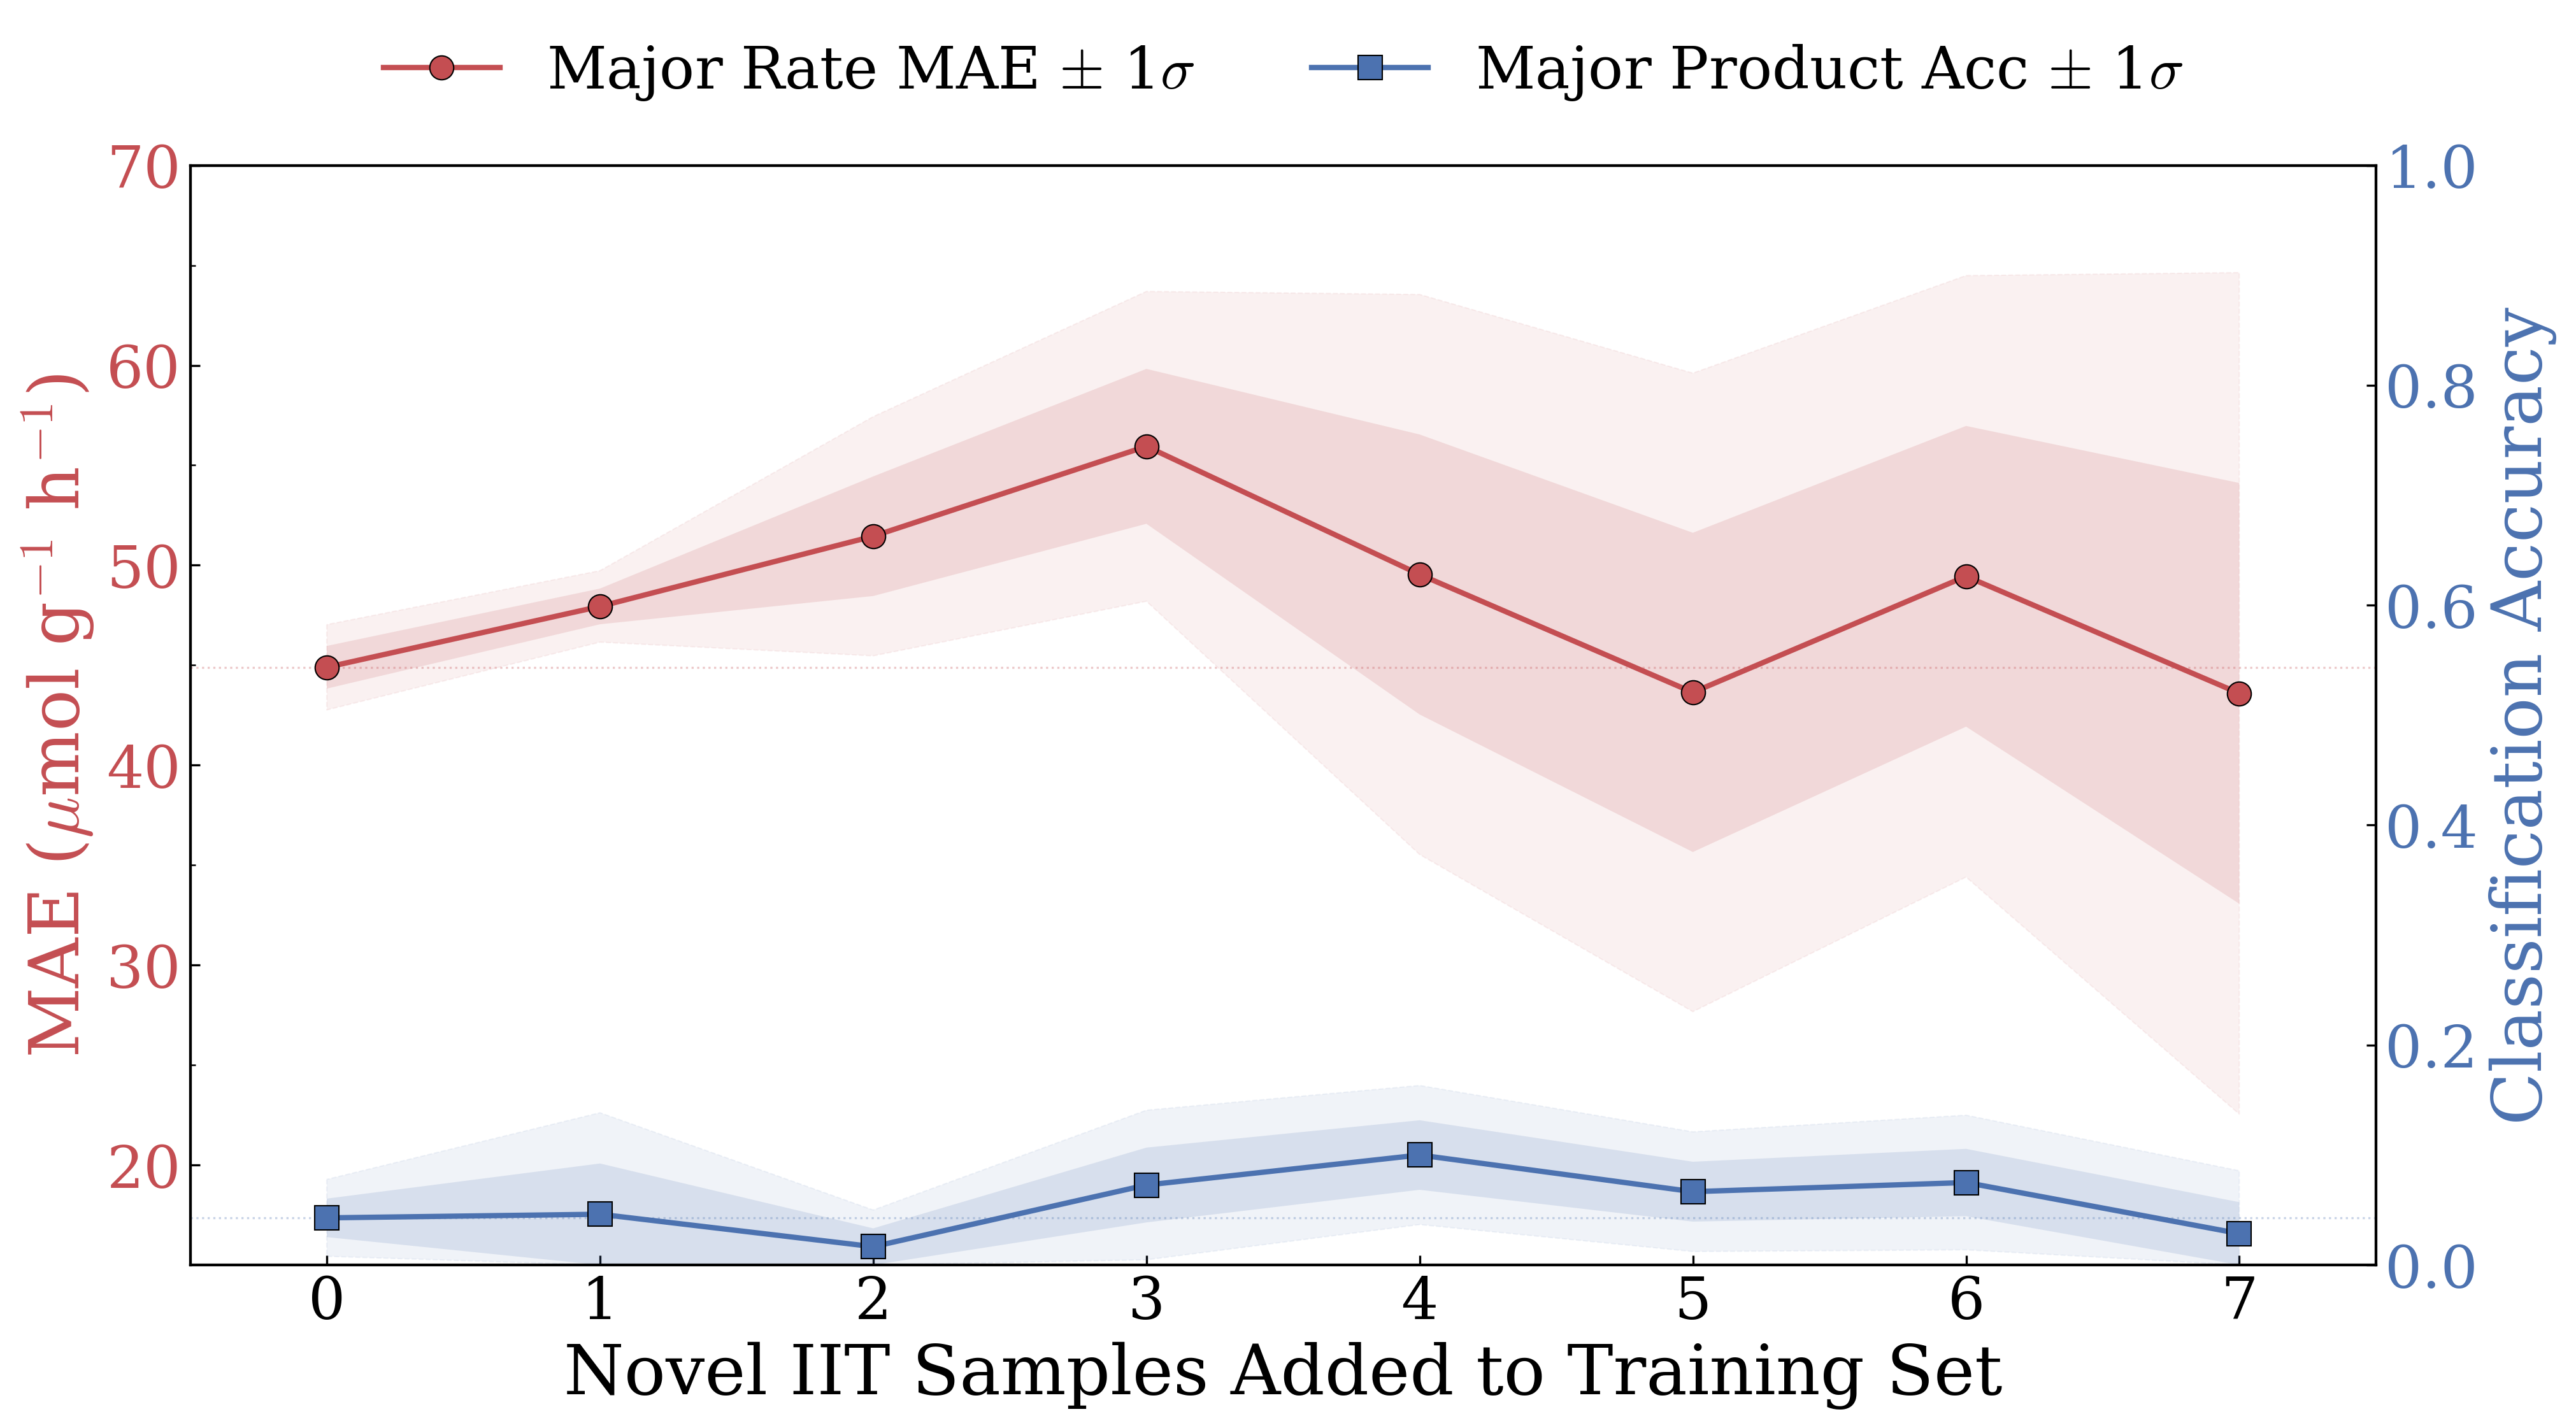

    Graph saved: IIT_VAL_fewshot_nn_minor.png/.pdf


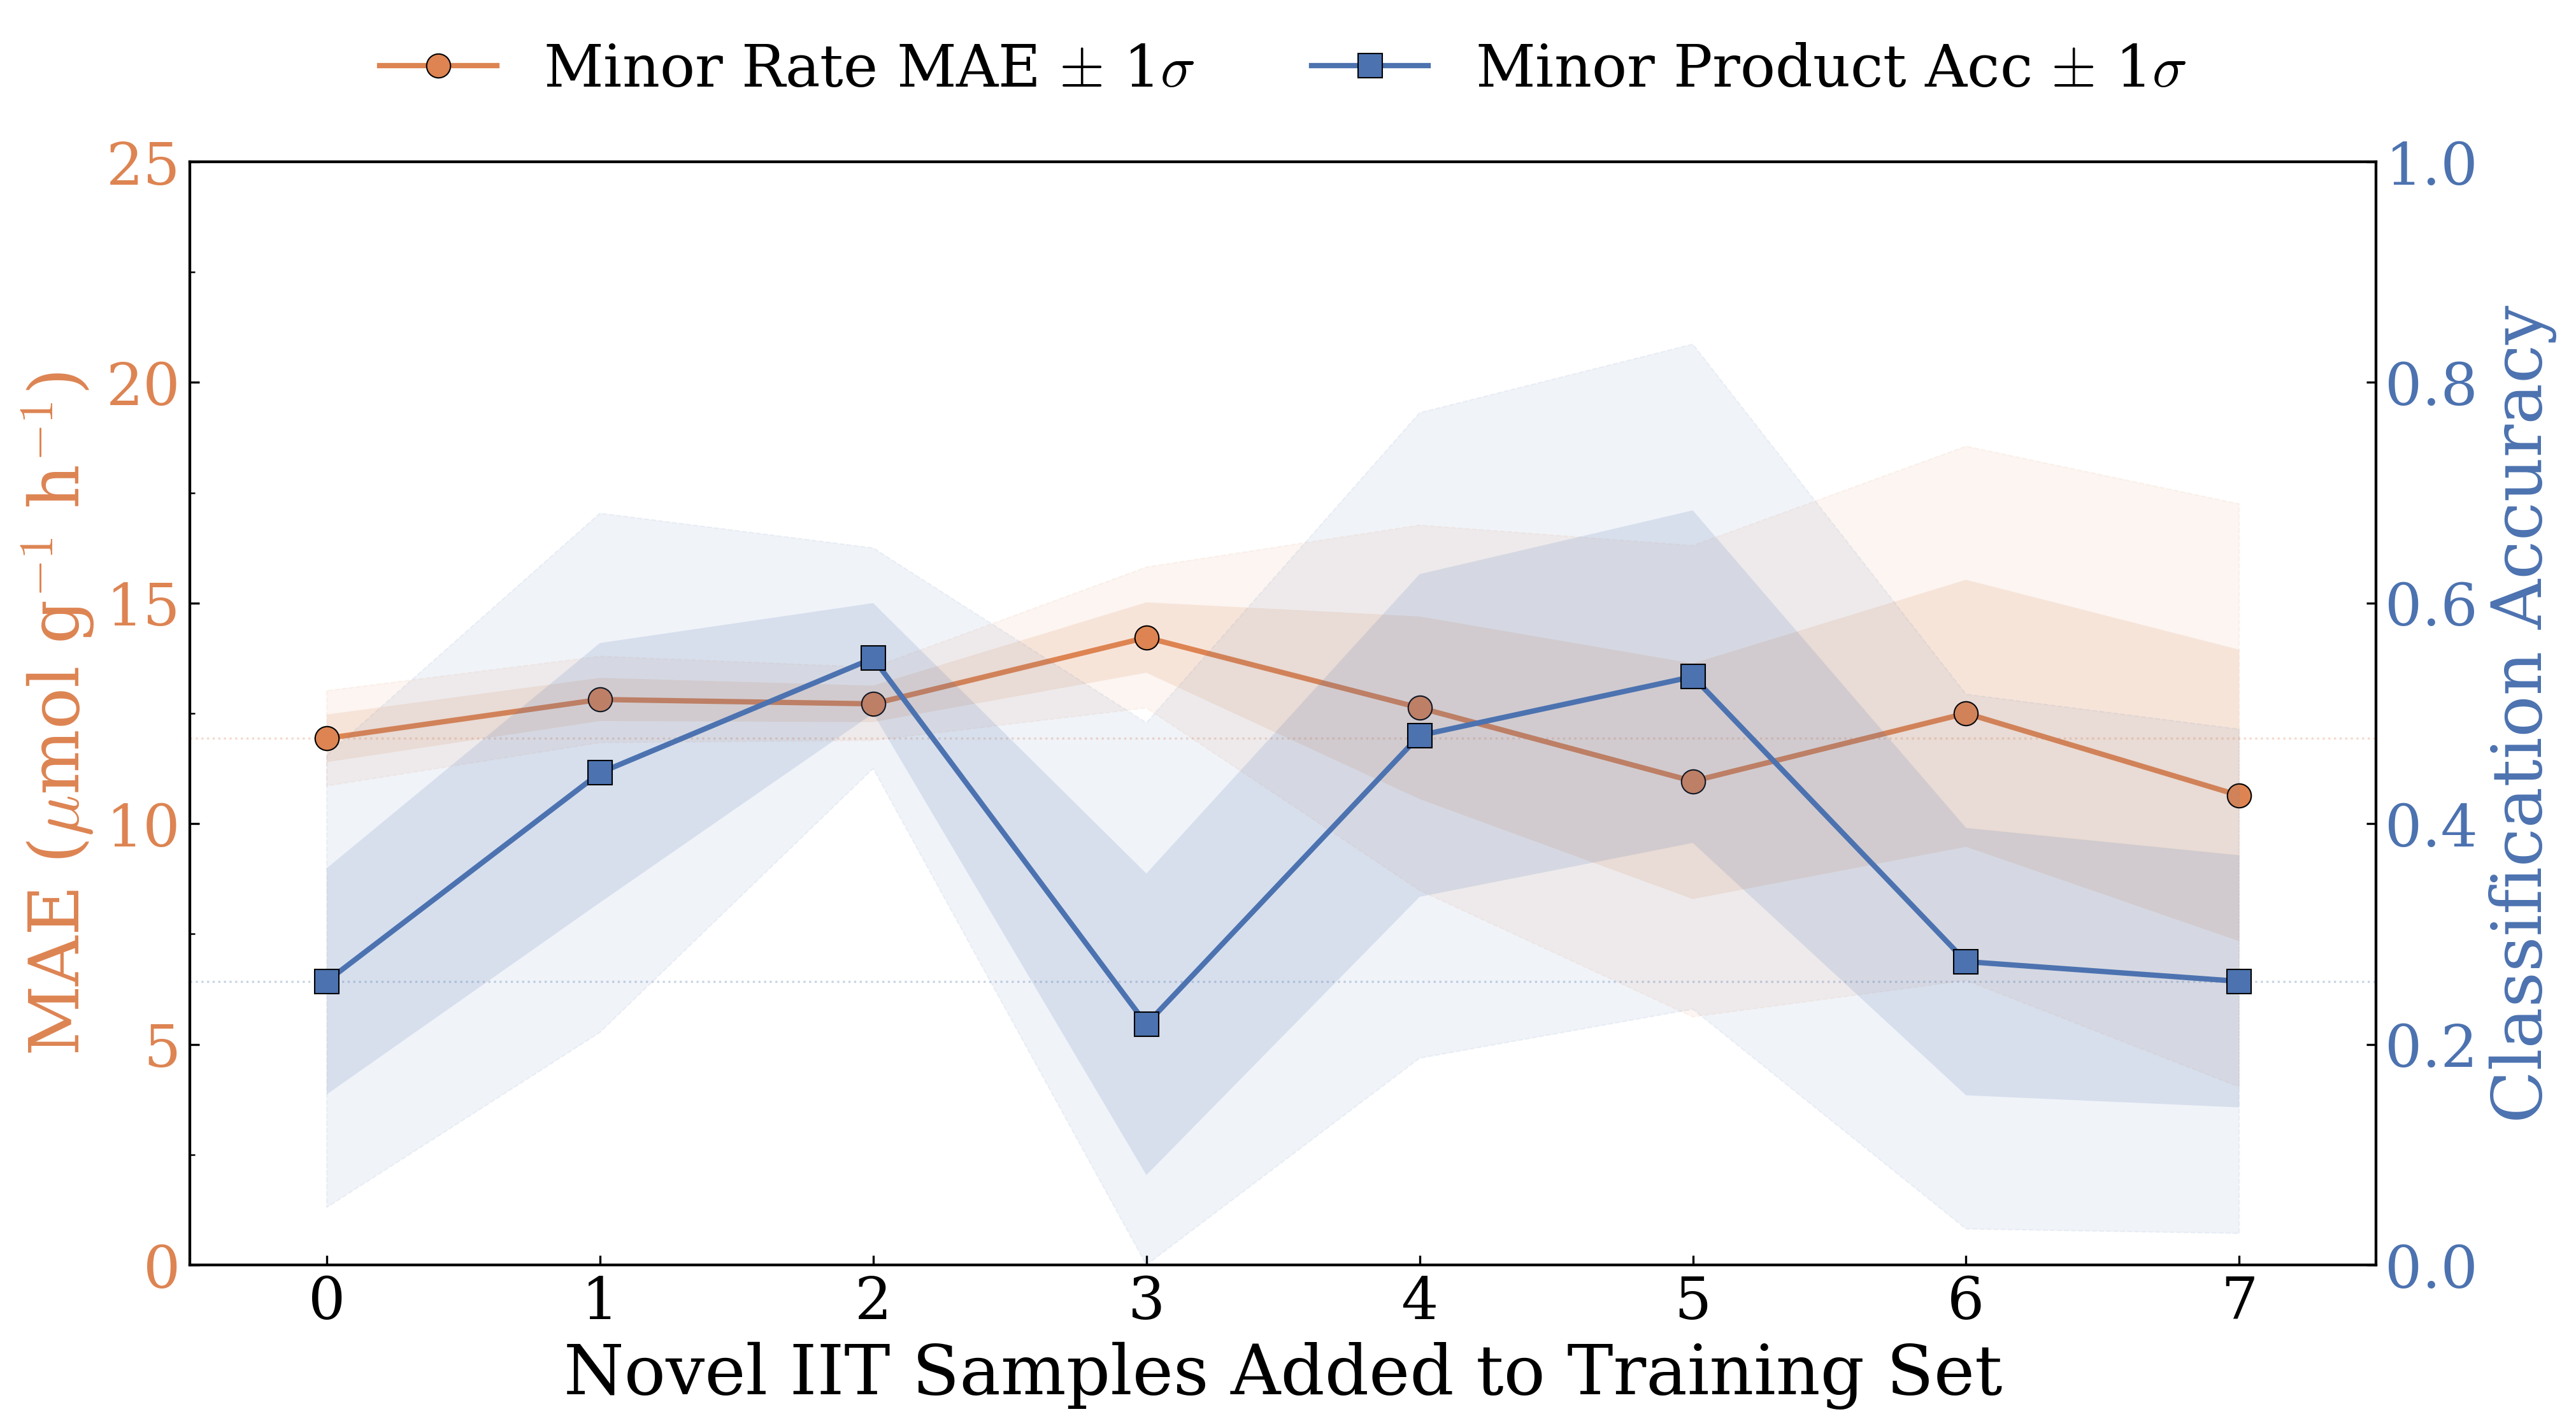


✅ NN few-shot plots saved.


In [ ]:
# ==============================================================================
# 3.4.6 NN FEW-SHOT: PLOTS
# ==============================================================================

k_vals = np.array(k_values_nn)

# ---- MAJOR PLOT ----
fig, ax1 = plt.subplots(figsize=(14, 8))

color_mae = '#C44E52'
ax1.set_xlabel('Novel IIT Samples Added to Training Set')
ax1.set_ylabel(r'MAE ($\mu$mol g$^{-1}$ h$^{-1}$)', color=color_mae)

ax1.fill_between(k_vals,
                 stats_nn['mj_mae_mean'] - stats_nn['mj_mae_std'],
                 stats_nn['mj_mae_mean'] + stats_nn['mj_mae_std'],
                 color=color_mae, alpha=0.08, edgecolor=color_mae,
                 linewidth=0.5, linestyle='--')
ax1.fill_between(k_vals,
                 stats_nn['mj_mae_mean'] - 0.5 * stats_nn['mj_mae_std'],
                 stats_nn['mj_mae_mean'] + 0.5 * stats_nn['mj_mae_std'],
                 color=color_mae, alpha=0.15, edgecolor='none')

line_mae, = ax1.plot(
    k_vals, stats_nn['mj_mae_mean'],
    marker='o', color=color_mae, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Major Rate MAE $\pm$ 1$\sigma$', zorder=5)
ax1.tick_params(axis='y', labelcolor=color_mae)

mae_lo = max(0, np.floor((stats_nn['mj_mae_mean'] - stats_nn['mj_mae_std']).min() / 5) * 5 - 5)
mae_hi = np.ceil((stats_nn['mj_mae_mean'] + stats_nn['mj_mae_std']).max() / 5) * 5 + 5
ax1.set_ylim(mae_lo, mae_hi)
ax1.yaxis.set_major_locator(plt.MultipleLocator(10))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(5))

ax2 = ax1.twinx()
color_acc = '#4C72B0'

acc_lo = np.clip(stats_nn['mj_acc_mean'] - stats_nn['mj_acc_std'], 0, 1.0)
acc_hi = np.clip(stats_nn['mj_acc_mean'] + stats_nn['mj_acc_std'], 0, 1.0)
ax2.fill_between(k_vals, acc_lo, acc_hi,
                 color=color_acc, alpha=0.08, edgecolor=color_acc,
                 linewidth=0.5, linestyle='--')
ax2.fill_between(k_vals,
                 np.clip(stats_nn['mj_acc_mean'] - 0.5 * stats_nn['mj_acc_std'], 0, 1),
                 np.clip(stats_nn['mj_acc_mean'] + 0.5 * stats_nn['mj_acc_std'], 0, 1),
                 color=color_acc, alpha=0.15, edgecolor='none')

line_acc, = ax2.plot(
    k_vals, stats_nn['mj_acc_mean'],
    marker='s', color=color_acc, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Major Product Acc $\pm$ 1$\sigma$', zorder=5)
ax2.set_ylabel('Classification Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.0)

ax1.set_xticks(k_vals)
ax1.set_xlim(-0.5, max(k_vals) + 0.5)
ax1.axhline(stats_nn['mj_mae_mean'][0], color=color_mae, linewidth=0.8, linestyle=':', alpha=0.3)
ax2.axhline(stats_nn['mj_acc_mean'][0], color=color_acc, linewidth=0.8, linestyle=':', alpha=0.3)

lines = [line_mae, line_acc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01),
           ncol=2, fontsize=TICK_SIZE, frameon=False, columnspacing=2.0)

for a in [ax1, ax2]:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
save_graph(fig, 'fewshot_nn_major', model_name=MODEL_NAME_FS)
plt.show()
plt.close('all')

# ---- MINOR PLOT ----
fig, ax1 = plt.subplots(figsize=(14, 8))

color_mae = '#DD8452'
ax1.set_xlabel('Novel IIT Samples Added to Training Set')
ax1.set_ylabel(r'MAE ($\mu$mol g$^{-1}$ h$^{-1}$)', color=color_mae)

ax1.fill_between(k_vals,
                 stats_nn['mi_mae_mean'] - stats_nn['mi_mae_std'],
                 stats_nn['mi_mae_mean'] + stats_nn['mi_mae_std'],
                 color=color_mae, alpha=0.08, edgecolor=color_mae,
                 linewidth=0.5, linestyle='--')
ax1.fill_between(k_vals,
                 stats_nn['mi_mae_mean'] - 0.5 * stats_nn['mi_mae_std'],
                 stats_nn['mi_mae_mean'] + 0.5 * stats_nn['mi_mae_std'],
                 color=color_mae, alpha=0.15, edgecolor='none')

line_mae, = ax1.plot(
    k_vals, stats_nn['mi_mae_mean'],
    marker='o', color=color_mae, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Minor Rate MAE $\pm$ 1$\sigma$', zorder=5)
ax1.tick_params(axis='y', labelcolor=color_mae)

mae_lo = max(0, np.floor((stats_nn['mi_mae_mean'] - stats_nn['mi_mae_std']).min() / 5) * 5 - 5)
mae_hi = np.ceil((stats_nn['mi_mae_mean'] + stats_nn['mi_mae_std']).max() / 5) * 5 + 5
ax1.set_ylim(mae_lo, mae_hi)
ax1.yaxis.set_major_locator(plt.MultipleLocator(5))
ax1.yaxis.set_minor_locator(plt.MultipleLocator(2.5))

ax2 = ax1.twinx()
color_acc = '#4C72B0'

acc_lo = np.clip(stats_nn['mi_acc_mean'] - stats_nn['mi_acc_std'], 0, 1.0)
acc_hi = np.clip(stats_nn['mi_acc_mean'] + stats_nn['mi_acc_std'], 0, 1.0)
ax2.fill_between(k_vals, acc_lo, acc_hi,
                 color=color_acc, alpha=0.08, edgecolor=color_acc,
                 linewidth=0.5, linestyle='--')
ax2.fill_between(k_vals,
                 np.clip(stats_nn['mi_acc_mean'] - 0.5 * stats_nn['mi_acc_std'], 0, 1),
                 np.clip(stats_nn['mi_acc_mean'] + 0.5 * stats_nn['mi_acc_std'], 0, 1),
                 color=color_acc, alpha=0.15, edgecolor='none')

line_acc, = ax2.plot(
    k_vals, stats_nn['mi_acc_mean'],
    marker='s', color=color_acc, linestyle='-',
    markersize=MARKER_SIZE, markeredgecolor='black', markeredgewidth=0.5,
    label=r'Minor Product Acc $\pm$ 1$\sigma$', zorder=5)
ax2.set_ylabel('Classification Accuracy', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(0, 1.0)

ax1.set_xticks(k_vals)
ax1.set_xlim(-0.5, max(k_vals) + 0.5)
ax1.axhline(stats_nn['mi_mae_mean'][0], color=color_mae, linewidth=0.8, linestyle=':', alpha=0.3)
ax2.axhline(stats_nn['mi_acc_mean'][0], color=color_acc, linewidth=0.8, linestyle=':', alpha=0.3)

lines = [line_mae, line_acc]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01),
           ncol=2, fontsize=TICK_SIZE, frameon=False, columnspacing=2.0)

for a in [ax1, ax2]:
    a.grid(False)
    for spine in a.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
save_graph(fig, 'fewshot_nn_minor', model_name=MODEL_NAME_FS)
plt.show()
plt.close('all')

print(f"\n✅ NN few-shot plots saved.")

### 3.4.3 TiO2 PRIDMO Data Preparation

In [ ]:
# ==============================================================================
# 3.5 INTERNAL FEW-SHOT: TiO2 HOLDOUT FROM PRIDMO
# 3.5.1 Holdout Setup
#
# Splits PRIDMO into base (non-TiO2) and holdout (TiO2) sets.
# TiO2 is selected because it's prominent in PRIDMO and matches
# the IIT validation catalyst system.
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import models

MODEL_NAME_INTFS = 'PRIDMO_FS'

target_val = 'TiO2'  # stripped formula for TiO2

print(f"{'='*70}")
print(f"INTERNAL FEW-SHOT: TiO2 HOLDOUT")
print(f"{'='*70}")

# Identify TiO2 entries via the stripped Active column
# (enrich_catalyst strips formulas, so TiO2 becomes TiO)
active_col = 'Active'
is_tio2 = merged_df[active_col].astype(str).str.strip().str.lower() == target_val.lower()

holdout_df = merged_df[is_tio2].copy()
base_df = merged_df[~is_tio2].copy()

print(f"  Total PRIDMO:     {len(merged_df)}")
print(f"  TiO2 holdout:     {len(holdout_df)}")
print(f"  Base (non-TiO2):  {len(base_df)}")

# Define drip schedule -- more granular at the start where changes are steepest
max_holdout = len(holdout_df)
drip_steps = [0, 1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90]
drip_steps = [s for s in drip_steps if s <= int(max_holdout * 0.7)]
if int(max_holdout * 0.7) not in drip_steps:
    drip_steps.append(int(max_holdout * 0.7))

print(f"  Max drip (70%):   {int(max_holdout * 0.7)}")
print(f"  Drip schedule:    {drip_steps}")

# Target columns
exclude_cols = [
    'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
    'Number', 'No', 'Exp', 'Description', 'Composite'
]

INTERNAL FEW-SHOT: TiO2 HOLDOUT
  Total PRIDMO:     375
  TiO2 holdout:     131
  Base (non-TiO2):  244
  Max drip (70%):   91
  Drip schedule:    [0, 1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 91]


### 3.4.4 PRIDMO Few Shot (TiO2) - Random Forest

In [ ]:
# ==============================================================================
# 3.5.2 RF INTERNAL FEW-SHOT EXPERIMENT
# ==============================================================================

def run_internal_fewshot_rf(base_df, holdout_df, numeric_cols, categorical_cols,
                            drip_steps, random_state=42, n_embedding_iterations=1):
    """
    Internal few-shot for chained RF. Holds out TiO2, drips it back in,
    evaluates on a fixed 30% test split of the holdout.
    """

    targets = {
        'mj': {'rate_col': 'Major_rate__umol/gh', 'prod_col': 'Major_product'},
        'mi': {'rate_col': 'Minor_rate__umol/gh', 'prod_col': 'Minor_product'},
    }

    # Fit label encoders on everything
    label_encoders = {}
    num_classes_dict = {}
    for prefix, cfg in targets.items():
        le = LabelEncoder()
        all_prods = pd.concat([
            base_df[cfg['prod_col']], holdout_df[cfg['prod_col']]
        ]).replace('NR', 'Unknown').fillna('Unknown').astype(str)
        le.fit(all_prods)
        label_encoders[prefix] = le
        num_classes_dict[prefix] = len(le.classes_)

    # Split holdout into drip pool (70%) and fixed test set (30%)
    holdout_shuffled = holdout_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n_test = max(1, int(len(holdout_shuffled) * 0.3))  # at least 1 test sample
    test_set_master = holdout_shuffled.iloc[:n_test].copy()
    drip_pool = holdout_shuffled.iloc[n_test:].copy()

    print(f"    Holdout: {len(holdout_df)}, test: {n_test}, drip pool: {len(drip_pool)}")

    exclude_cols_local = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]

    results = {'k': []}
    for prefix in targets:
        for metric in ['mae', 'r2', 'acc']:
            results[f'{prefix}_{metric}'] = []

    for k in drip_steps:
        if k > len(drip_pool):
            continue
        print(f"  k={k}: ", end='')

        # Build training set
        if k > 0:
            current_train = pd.concat([base_df, drip_pool.iloc[:k]], ignore_index=True)
        else:
            current_train = base_df.copy()

        # Fresh copy of test set each iteration to avoid column accumulation
        test_set = test_set_master.copy()

        # Preprocessing
        feature_cols = [c for c in current_train.columns if c not in exclude_cols_local]
        for c in feature_cols:
            if c not in test_set.columns:
                test_set[c] = np.nan

        X_train_raw = current_train[feature_cols].copy()
        X_test_raw = test_set[feature_cols].copy()

        num_cols = [c for c in numeric_cols if c in feature_cols]
        cat_cols = [c for c in categorical_cols if c in feature_cols]

        # Domain rules
        for phase_col in ['Reaction_Phase', 'Phase']:
            if phase_col in X_train_raw.columns:
                for pres_col in ['Reaction_pres_atm', 'Rxn_Pressure']:
                    if pres_col in X_train_raw.columns:
                        for df_tmp in [X_train_raw, X_test_raw]:
                            liq = df_tmp[phase_col].astype(str).str.lower().str.strip().isin(['liquid', 'liq'])
                            df_tmp.loc[liq & df_tmp[pres_col].isna(), pres_col] = 1.0
                break

        for c in num_cols:
            X_train_raw[c] = pd.to_numeric(X_train_raw[c], errors='coerce')
            X_test_raw[c] = pd.to_numeric(X_test_raw[c], errors='coerce')

        train_means = X_train_raw[num_cols].mean()
        X_train_raw[num_cols] = X_train_raw[num_cols].fillna(train_means).fillna(0)
        X_test_raw[num_cols] = X_test_raw[num_cols].fillna(train_means).fillna(0)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train_raw[num_cols]).astype(np.float32)
        X_te_num = scaler.transform(X_test_raw[num_cols]).astype(np.float32)

        tr_cat, te_cat, vocab_sizes = [], [], []
        for col in cat_cols:
            X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
            X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
            unique = X_train_raw[col].unique()
            mapping = {v: i + 1 for i, v in enumerate(unique)}
            vocab_sizes.append(len(unique) + 1)
            tr_cat.append(X_train_raw[col].map(mapping).fillna(0).values.astype(np.int32))
            te_cat.append(X_test_raw[col].map(mapping).fillna(0).values.astype(np.int32))

        # Prepare 4 targets
        le_mj, le_mi = label_encoders['mj'], label_encoders['mi']

        y_mj_reg = pd.to_numeric(current_train[targets['mj']['rate_col']], errors='coerce').apply(
            lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
        y_mi_reg = pd.to_numeric(current_train[targets['mi']['rate_col']], errors='coerce').apply(
            lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
        y_mj_clf = le_mj.transform(
            current_train[targets['mj']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
        y_mi_clf = le_mi.transform(
            current_train[targets['mi']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

        valid_reg = y_mj_reg.notna().values
        X_tr_list_v = [X_tr_num[valid_reg]] + [c[valid_reg] for c in tr_cat]
        y_mj_reg_v = y_mj_reg[y_mj_reg.notna()].values.astype('float32')
        y_mi_reg_v = y_mi_reg[valid_reg].fillna(0).values.astype('float32')
        y_mj_clf_v = y_mj_clf[valid_reg]
        y_mi_clf_v = y_mi_clf[valid_reg]

        print(f"(train={valid_reg.sum()}, test={len(test_set)}) ", end='')

        # Train embedding network
        best_extractor = None
        best_score = -np.inf
        for it in range(n_embedding_iterations):
            tf.keras.backend.clear_session()
            tf.random.set_seed(random_state + it)
            emb_model = build_embedding_model_4head(
                X_tr_num[valid_reg].shape[1], vocab_sizes, cat_cols,
                num_classes_dict['mj'], num_classes_dict['mi'])
            emb_model.fit(
                X_tr_list_v,
                {'out_mj_reg': y_mj_reg_v.reshape(-1, 1),
                 'out_mi_reg': y_mi_reg_v.reshape(-1, 1),
                 'out_mj_clf': y_mj_clf_v,
                 'out_mi_clf': y_mi_clf_v},
                epochs=50, batch_size=32, verbose=0, validation_split=0.1)
            extractor = models.Model(
                inputs=emb_model.input,
                outputs=emb_model.get_layer('representation_layer').output)
            X_tr_emb = extractor.predict(X_tr_list_v, verbose=0)
            rf_check = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            rf_check.fit(X_tr_emb, y_mj_reg_v)
            score = rf_check.score(X_tr_emb, y_mj_reg_v)
            if score > best_score:
                best_score = score
                best_extractor = extractor

        X_tr_emb = best_extractor.predict(X_tr_list_v, verbose=0)
        te_inputs = [tf.constant(X_te_num, dtype=tf.float32)]
        for c in te_cat:
            te_inputs.append(tf.constant(c, dtype=tf.int32))
        X_te_emb = best_extractor(te_inputs, training=False).numpy()

        # Chained RF
        rf_clf_p = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        criterion='entropy', random_state=42, n_jobs=-1)
        rf_reg_p = dict(n_estimators=300, max_depth=20, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)

        rf1 = RandomForestClassifier(**rf_clf_p)
        rf1.fit(X_tr_emb, y_mj_clf_v)
        mj_clf_tr = rf1.predict(X_tr_emb)
        mj_clf_te = rf1.predict(X_te_emb)

        X_tr_c2 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1)])
        X_te_c2 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1)])
        rf2 = RandomForestClassifier(**rf_clf_p)
        rf2.fit(X_tr_c2, y_mi_clf_v)
        mi_clf_tr = rf2.predict(X_tr_c2)
        mi_clf_te = rf2.predict(X_te_c2)

        X_tr_c3 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1), mi_clf_tr.reshape(-1, 1)])
        X_te_c3 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1), mi_clf_te.reshape(-1, 1)])
        rf3 = RandomForestRegressor(**rf_reg_p)
        rf3.fit(X_tr_c3, y_mj_reg_v)
        mj_reg_tr = rf3.predict(X_tr_c3)
        mj_reg_te = rf3.predict(X_te_c3)

        X_tr_c4 = np.column_stack([X_tr_emb, mj_clf_tr.reshape(-1, 1),
                                    mi_clf_tr.reshape(-1, 1), mj_reg_tr.reshape(-1, 1)])
        X_te_c4 = np.column_stack([X_te_emb, mj_clf_te.reshape(-1, 1),
                                    mi_clf_te.reshape(-1, 1), mj_reg_te.reshape(-1, 1)])
        rf4 = RandomForestRegressor(**rf_reg_p)
        rf4.fit(X_tr_c4, y_mi_reg_v)
        mi_reg_te = rf4.predict(X_te_c4)

        # Evaluate
        results['k'].append(k)

        y_mj_reg_test = pd.to_numeric(test_set[targets['mj']['rate_col']], errors='coerce')
        y_mi_reg_test = pd.to_numeric(test_set[targets['mi']['rate_col']], errors='coerce')
        y_mj_clf_test = le_mj.transform(
            test_set[targets['mj']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
        y_mi_clf_test = le_mi.transform(
            test_set[targets['mi']['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

        for prefix, clf_te, reg_te, y_reg_test, y_clf_test, cfg in [
            ('mj', mj_clf_te, mj_reg_te, y_mj_reg_test, y_mj_clf_test, targets['mj']),
            ('mi', mi_clf_te, mi_reg_te, y_mi_reg_test, y_mi_clf_test, targets['mi']),
        ]:
            valid_test = y_reg_test.notna()
            if valid_test.sum() > 1:
                actual_real = (10**np.log10(y_reg_test[valid_test].values + 1)) - 1
                pred_real = (10**reg_te[valid_test.values]) - 1
                mae = mean_absolute_error(actual_real, np.clip(pred_real, 0, None))
                r2 = r2_score(np.log10(y_reg_test[valid_test].values + 1),
                              reg_te[valid_test.values])
            elif valid_test.sum() == 1:
                actual_real = y_reg_test[valid_test].values
                pred_real = (10**reg_te[valid_test.values]) - 1
                mae = float(abs(actual_real[0] - pred_real[0]))
                r2 = np.nan
            else:
                mae, r2 = np.nan, np.nan

            valid_clf = (test_set[cfg['prod_col']].notna() &
                         ~test_set[cfg['prod_col']].astype(str).str.strip().isin(
                             ['NR', 'nr', 'nan', '', 'Unknown']))
            if valid_clf.sum() > 0:
                acc = accuracy_score(y_clf_test[valid_clf.values], clf_te[valid_clf.values])
            else:
                acc = np.nan

            results[f'{prefix}_mae'].append(mae)
            results[f'{prefix}_r2'].append(r2)
            results[f'{prefix}_acc'].append(acc)

            print(f"{prefix.upper()}: MAE={mae:.2f} Acc={acc*100:.1f}% | ", end='')
        print()

    return pd.DataFrame(results)

In [ ]:
# ==============================================================================
# 3.5.3 RF INTERNAL FEW-SHOT: MULTI-SEED
# ==============================================================================

n_seeds_rf_int = 10

all_results_rf_int = {}
for prefix in ['mj', 'mi']:
    for metric in ['mae', 'r2', 'acc']:
        all_results_rf_int[f'{prefix}_{metric}'] = {k: [] for k in drip_steps}

for seed in range(n_seeds_rf_int):
    print(f"\n{'='*70}")
    print(f"  RF INTERNAL SEED {seed+1}/{n_seeds_rf_int}  (random_state={seed})")
    print(f"{'='*70}")

    df_seed = run_internal_fewshot_rf(
        base_df=base_df, holdout_df=holdout_df,
        numeric_cols=numeric_cols_prod, categorical_cols=categorical_cols_prod,
        drip_steps=drip_steps, random_state=seed, n_embedding_iterations=1)

    for _, row in df_seed.iterrows():
        k = int(row['k'])
        for prefix in ['mj', 'mi']:
            for metric in ['mae', 'r2', 'acc']:
                col = f'{prefix}_{metric}'
                val = row[col]
                if k in all_results_rf_int[col] and pd.notna(val):
                    all_results_rf_int[col][k].append(val)

# Compute stats
stats_rf_int = {}
for col in all_results_rf_int:
    stats_rf_int[f'{col}_mean'] = np.array([
        np.mean(all_results_rf_int[col][k]) if all_results_rf_int[col][k] else np.nan
        for k in drip_steps
    ])
    stats_rf_int[f'{col}_std'] = np.array([
        np.std(all_results_rf_int[col][k]) if all_results_rf_int[col][k] else np.nan
        for k in drip_steps
    ])

print(f"\n{'='*70}")
print("RF INTERNAL FEW-SHOT STATS")
print(f"{'='*70}")
for k_idx, k in enumerate(drip_steps):
    print(f"  k={k:2d}: Mj MAE={stats_rf_int['mj_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_rf_int['mj_acc_mean'][k_idx]*100:5.1f}%  |  "
          f"Mi MAE={stats_rf_int['mi_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_rf_int['mi_acc_mean'][k_idx]*100:5.1f}%")

save_results(
    pd.DataFrame({'k': drip_steps,
        **{f'{c}_mean': stats_rf_int[f'{c}_mean'] for c in all_results_rf_int},
        **{f'{c}_std': stats_rf_int[f'{c}_std'] for c in all_results_rf_int}}),
    'internal_fewshot_rf_stats', model_name=MODEL_NAME_INTFS)


  RF INTERNAL SEED 1/10  (random_state=0)
    Holdout: 131, test: 39, drip pool: 92
  k=0: (train=244, test=39) MJ: MAE=95.12 Acc=41.0% | MI: MAE=20.03 Acc=56.4% | 
  k=1: (train=245, test=39) MJ: MAE=96.61 Acc=43.6% | MI: MAE=20.42 Acc=59.0% | 
  k=2: (train=246, test=39) MJ: MAE=92.39 Acc=41.0% | MI: MAE=20.03 Acc=59.0% | 
  k=3: (train=247, test=39) MJ: MAE=99.07 Acc=35.9% | MI: MAE=20.06 Acc=59.0% | 
  k=4: (train=248, test=39) MJ: MAE=92.02 Acc=43.6% | MI: MAE=20.09 Acc=61.5% | 
  k=5: (train=249, test=39) MJ: MAE=96.78 Acc=43.6% | MI: MAE=20.14 Acc=59.0% | 
  k=6: (train=250, test=39) MJ: MAE=93.78 Acc=48.7% | MI: MAE=20.09 Acc=56.4% | 
  k=8: (train=252, test=39) MJ: MAE=94.06 Acc=38.5% | MI: MAE=20.15 Acc=61.5% | 
  k=10: (train=254, test=39) MJ: MAE=88.33 Acc=35.9% | MI: MAE=20.08 Acc=61.5% | 
  k=15: (train=259, test=39) MJ: MAE=87.63 Acc=46.2% | MI: MAE=19.87 Acc=59.0% | 
  k=20: (train=264, test=39) MJ: MAE=94.83 Acc=59.0% | MI: MAE=19.75 Acc=61.5% | 
  k=30: (train=274, t

### 3.4.5 PRIDMO Few Shot (TiO2) - Neural Network

In [ ]:
# ==============================================================================
# 3.5.4 NN INTERNAL FEW-SHOT EXPERIMENT (with test_set_master fix)
# ==============================================================================

def run_internal_fewshot_nn(base_df, holdout_df, numeric_cols, categorical_cols,
                            drip_steps, random_state=42):
    """
    Internal few-shot for dual-output NN. Same holdout structure as RF.
    Trains separate major/minor models at each k.
    """

    targets = {
        'mj': {'rate_col': 'Major_rate__umol/gh', 'prod_col': 'Major_product'},
        'mi': {'rate_col': 'Minor_rate__umol/gh', 'prod_col': 'Minor_product'},
    }

    label_encoders = {}
    num_classes_dict = {}
    for prefix, cfg in targets.items():
        le = LabelEncoder()
        all_prods = pd.concat([
            base_df[cfg['prod_col']], holdout_df[cfg['prod_col']]
        ]).replace('NR', 'Unknown').fillna('Unknown').astype(str)
        le.fit(all_prods)
        label_encoders[prefix] = le
        num_classes_dict[prefix] = len(le.classes_)

    # Split holdout into fixed test (30%) and drip pool (70%)
    holdout_shuffled = holdout_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n_test = max(1, int(len(holdout_shuffled) * 0.3))
    test_set_master = holdout_shuffled.iloc[:n_test].copy()
    drip_pool = holdout_shuffled.iloc[n_test:].copy()

    print(f"    Holdout: {len(holdout_df)}, test: {n_test}, drip pool: {len(drip_pool)}")

    exclude_cols_local = [
        'Major_rate__umol/gh', 'Minor_rate__umol/gh', 'Major_product', 'Minor_product',
        'Number', 'No', 'Exp', 'Description', 'Composite'
    ]

    results = {'k': []}
    for prefix in targets:
        for metric in ['mae', 'r2', 'acc']:
            results[f'{prefix}_{metric}'] = []

    for k in drip_steps:
        if k > len(drip_pool):
            continue
        print(f"  k={k}: ", end='')

        if k > 0:
            current_train = pd.concat([base_df, drip_pool.iloc[:k]], ignore_index=True)
        else:
            current_train = base_df.copy()

        # Fresh copy each iteration to prevent column accumulation
        test_set = test_set_master.copy()

        feature_cols = [c for c in current_train.columns if c not in exclude_cols_local]
        for c in feature_cols:
            if c not in test_set.columns:
                test_set[c] = np.nan

        X_train_raw = current_train[feature_cols].copy()
        X_test_raw = test_set[feature_cols].copy()

        num_cols_use = [c for c in numeric_cols if c in feature_cols]
        cat_cols_use = [c for c in categorical_cols if c in feature_cols]

        # Domain rules
        for phase_col in ['Reaction_Phase', 'Phase']:
            if phase_col in X_train_raw.columns:
                for pres_col in ['Reaction_pres_atm', 'Rxn_Pressure']:
                    if pres_col in X_train_raw.columns:
                        for df_tmp in [X_train_raw, X_test_raw]:
                            liq = df_tmp[phase_col].astype(str).str.lower().str.strip().isin(['liquid', 'liq'])
                            df_tmp.loc[liq & df_tmp[pres_col].isna(), pres_col] = 1.0
                break

        for c in num_cols_use:
            X_train_raw[c] = pd.to_numeric(X_train_raw[c], errors='coerce')
            X_test_raw[c] = pd.to_numeric(X_test_raw[c], errors='coerce')

        train_means = X_train_raw[num_cols_use].mean()
        X_train_raw[num_cols_use] = X_train_raw[num_cols_use].fillna(train_means).fillna(0)
        X_test_raw[num_cols_use] = X_test_raw[num_cols_use].fillna(train_means).fillna(0)

        scaler = StandardScaler()
        X_tr_num = scaler.fit_transform(X_train_raw[num_cols_use]).astype('float32')
        X_te_num = scaler.transform(X_test_raw[num_cols_use]).astype('float32')

        tr_cat, te_cat, vocab_sizes = [], [], []
        cat_cols_clean = []
        for col in cat_cols_use:
            X_train_raw[col] = X_train_raw[col].fillna('Missing').astype(str)
            X_test_raw[col] = X_test_raw[col].fillna('Missing').astype(str)
            unique = X_train_raw[col].unique()
            mapping = {v: i + 1 for i, v in enumerate(unique)}
            vocab_sizes.append(len(unique) + 1)
            tr_cat.append(X_train_raw[col].map(mapping).fillna(0).values.astype('int32'))
            te_cat.append(X_test_raw[col].map(mapping).fillna(0).values.astype('int32'))
            cat_cols_clean.append(sanitize_name(col))

        X_te_list = [X_te_num] + te_cat
        results['k'].append(k)

        print(f"(train={len(current_train)}, test={len(test_set)}) ", end='')

        for prefix, cfg in targets.items():
            le = label_encoders[prefix]
            nc = num_classes_dict[prefix]

            y_reg_train = pd.to_numeric(
                current_train[cfg['rate_col']], errors='coerce').apply(
                lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)
            y_reg_test = pd.to_numeric(
                test_set[cfg['rate_col']], errors='coerce').apply(
                lambda x: np.log10(x + 1) if pd.notna(x) else np.nan)

            y_clf_train = le.transform(
                current_train[cfg['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))
            y_clf_test = le.transform(
                test_set[cfg['prod_col']].replace('NR', 'Unknown').fillna('Unknown').astype(str))

            valid_train = y_reg_train.notna().values
            X_tr_list = [X_tr_num[valid_train]] + [c[valid_train] for c in tr_cat]
            y_reg_filtered = y_reg_train[y_reg_train.notna()].values.astype('float32')
            y_clf_filtered = y_clf_train[valid_train]

            tf.keras.backend.clear_session()
            tf.random.set_seed(random_state)

            model = build_pridmo_nn(X_tr_num.shape[1], vocab_sizes, cat_cols_clean, nc)

            model.fit(
                X_tr_list,
                {'output_rate': y_reg_filtered, 'output_type': y_clf_filtered},
                validation_split=0.15, epochs=100, batch_size=32,
                callbacks=[tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=10,
                    restore_best_weights=True, verbose=0)],
                verbose=0)

            preds = model.predict(X_te_list, verbose=0)
            pred_reg_log = preds[0].flatten()
            pred_reg_real = (10**pred_reg_log) - 1
            pred_clf = np.argmax(preds[1], axis=1)

            valid_test_reg = y_reg_test.notna()
            if valid_test_reg.sum() > 1:
                actual_real = (10**y_reg_test[valid_test_reg].values) - 1
                mae = mean_absolute_error(actual_real, pred_reg_real[valid_test_reg.values])
                r2 = r2_score(y_reg_test[valid_test_reg].values,
                              pred_reg_log[valid_test_reg.values])
            elif valid_test_reg.sum() == 1:
                actual_real = (10**y_reg_test[valid_test_reg].values) - 1
                mae = float(abs(actual_real[0] - pred_reg_real[valid_test_reg.values][0]))
                r2 = np.nan
            else:
                mae, r2 = np.nan, np.nan

            valid_test_clf = (
                test_set[cfg['prod_col']].notna() &
                ~test_set[cfg['prod_col']].astype(str).str.strip().isin(
                    ['NR', 'nr', 'nan', '', 'Unknown']))
            if valid_test_clf.sum() > 0:
                acc = accuracy_score(y_clf_test[valid_test_clf.values],
                                     pred_clf[valid_test_clf.values])
            else:
                acc = np.nan

            results[f'{prefix}_mae'].append(mae)
            results[f'{prefix}_r2'].append(r2)
            results[f'{prefix}_acc'].append(acc)

            print(f"{prefix.upper()}: MAE={mae:.2f} Acc={acc*100:.1f}% | ", end='')
        print()

    return pd.DataFrame(results)

In [ ]:
# ==============================================================================
# 3.5.5 NN INTERNAL FEW-SHOT: MULTI-SEED
# ==============================================================================

n_seeds_nn_int = 5

all_results_nn_int = {}
for prefix in ['mj', 'mi']:
    for metric in ['mae', 'r2', 'acc']:
        all_results_nn_int[f'{prefix}_{metric}'] = {k: [] for k in drip_steps}

for seed in range(n_seeds_nn_int):
    print(f"\n{'='*70}")
    print(f"  NN INTERNAL SEED {seed+1}/{n_seeds_nn_int}  (random_state={seed})")
    print(f"{'='*70}")

    df_seed = run_internal_fewshot_nn(
        base_df=base_df, holdout_df=holdout_df,
        numeric_cols=numeric_cols_prod, categorical_cols=categorical_cols_prod,
        drip_steps=drip_steps, random_state=seed)

    for _, row in df_seed.iterrows():
        k = int(row['k'])
        for prefix in ['mj', 'mi']:
            for metric in ['mae', 'r2', 'acc']:
                col = f'{prefix}_{metric}'
                val = row[col]
                if k in all_results_nn_int[col] and pd.notna(val):
                    all_results_nn_int[col][k].append(val)

stats_nn_int = {}
for col in all_results_nn_int:
    stats_nn_int[f'{col}_mean'] = np.array([
        np.mean(all_results_nn_int[col][k]) if all_results_nn_int[col][k] else np.nan
        for k in drip_steps
    ])
    stats_nn_int[f'{col}_std'] = np.array([
        np.std(all_results_nn_int[col][k]) if all_results_nn_int[col][k] else np.nan
        for k in drip_steps
    ])

print(f"\n{'='*70}")
print("NN INTERNAL FEW-SHOT STATS")
print(f"{'='*70}")
for k_idx, k in enumerate(drip_steps):
    print(f"  k={k:2d}: Mj MAE={stats_nn_int['mj_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_nn_int['mj_acc_mean'][k_idx]*100:5.1f}%  |  "
          f"Mi MAE={stats_nn_int['mi_mae_mean'][k_idx]:6.2f} "
          f"Acc={stats_nn_int['mi_acc_mean'][k_idx]*100:5.1f}%")

save_results(
    pd.DataFrame({'k': drip_steps,
        **{f'{c}_mean': stats_nn_int[f'{c}_mean'] for c in all_results_nn_int},
        **{f'{c}_std': stats_nn_int[f'{c}_std'] for c in all_results_nn_int}}),
    'internal_fewshot_nn_stats', model_name=MODEL_NAME_INTFS)


  NN INTERNAL SEED 1/5  (random_state=0)
    Holdout: 131, test: 39, drip pool: 92
  k=0: (train=244, test=39) MJ: MAE=87.47 Acc=28.2% | MI: MAE=19.89 Acc=0.0% | 
  k=1: (train=245, test=39) MJ: MAE=92.91 Acc=41.0% | MI: MAE=20.02 Acc=2.6% | 
  k=2: (train=246, test=39) MJ: MAE=86.22 Acc=33.3% | MI: MAE=19.81 Acc=0.0% | 
  k=3: (train=247, test=39) MJ: MAE=119.89 Acc=35.9% | MI: MAE=19.94 Acc=0.0% | 
  k=4: (train=248, test=39) MJ: MAE=93.19 Acc=30.8% | MI: MAE=20.09 Acc=2.6% | 
  k=5: (train=249, test=39) MJ: MAE=98.00 Acc=20.5% | MI: MAE=19.94 Acc=2.6% | 
  k=6: (train=250, test=39) MJ: MAE=93.31 Acc=30.8% | MI: MAE=20.01 Acc=0.0% | 
  k=8: (train=252, test=39) MJ: MAE=94.85 Acc=10.3% | MI: MAE=20.04 Acc=0.0% | 
  k=10: (train=254, test=39) MJ: MAE=98.59 Acc=25.6% | MI: MAE=19.95 Acc=12.8% | 
  k=15: (train=259, test=39) MJ: MAE=96.82 Acc=10.3% | MI: MAE=19.97 Acc=10.3% | 
  k=20: (train=264, test=39) MJ: MAE=86.51 Acc=25.6% | MI: MAE=19.95 Acc=0.0% | 
  k=30: (train=274, test=39) M

### 3.4.6 PRIDMO Few Shot Plots and Comparison

In [ ]:
# ==============================================================================
# 3.5.6 INTERNAL FEW-SHOT: PLOTS
# ==============================================================================

FONT_SCALE = 2
TICK_SIZE = int(11 * FONT_SCALE)
MARKER_SIZE = int(4.5 * FONT_SCALE)

plt.style.use('default')
plt.rcParams.update({
    "text.usetex": False, "mathtext.fontset": "cm", "font.family": "serif",
    "axes.grid": False, "axes.linewidth": 1.0,
    "font.size": int(12 * FONT_SCALE),
    "axes.labelsize": int(13 * FONT_SCALE),
    "axes.titlesize": int(14 * FONT_SCALE),
    "xtick.labelsize": TICK_SIZE, "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": TICK_SIZE,
    "xtick.direction": "in", "ytick.direction": "in",
    "legend.frameon": False, "lines.linewidth": 2.0,
    "figure.dpi": 300, "savefig.dpi": 600, "savefig.bbox": "tight",
})

k_vals = np.array(drip_steps)
display_ticks = sorted(set([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, max(drip_steps)]))
display_ticks = [t for t in display_ticks if t <= max(drip_steps)]


def plot_fewshot_dual(k_vals, mae_mean, mae_std, acc_mean, acc_std,
                      title_suffix, filename, color_mae='#C44E52'):
    """Reusable dual-axis few-shot plot."""
    fig, ax1 = plt.subplots(figsize=(14, 8))
    color_acc = '#4C72B0'

    # MAE (left)
    ax1.set_xlabel('TiO2 Samples Added to Training Set')
    ax1.set_ylabel(r'MAE ($\mu$mol g$^{-1}$ h$^{-1}$)', color=color_mae)
    ax1.fill_between(k_vals, mae_mean - mae_std, mae_mean + mae_std,
                     color=color_mae, alpha=0.08, edgecolor=color_mae,
                     linewidth=0.5, linestyle='--')
    ax1.fill_between(k_vals, mae_mean - 0.5*mae_std, mae_mean + 0.5*mae_std,
                     color=color_mae, alpha=0.15, edgecolor='none')
    line_mae, = ax1.plot(k_vals, mae_mean, marker='o', color=color_mae,
                         markersize=MARKER_SIZE, markeredgecolor='black',
                         markeredgewidth=0.5,
                         label=r'Rate MAE $\pm$ 1$\sigma$', zorder=5)
    ax1.tick_params(axis='y', labelcolor=color_mae)
    mae_lo = max(0, np.floor(np.nanmin(mae_mean - mae_std) / 5) * 5 - 5)
    mae_hi = np.ceil(np.nanmax(mae_mean + mae_std) / 5) * 5 + 5
    ax1.set_ylim(mae_lo, mae_hi)

    # Accuracy (right)
    ax2 = ax1.twinx()
    acc_lo = np.clip(acc_mean - acc_std, 0, 1)
    acc_hi = np.clip(acc_mean + acc_std, 0, 1)
    ax2.fill_between(k_vals, acc_lo, acc_hi,
                     color=color_acc, alpha=0.08, edgecolor=color_acc,
                     linewidth=0.5, linestyle='--')
    ax2.fill_between(k_vals,
                     np.clip(acc_mean - 0.5*acc_std, 0, 1),
                     np.clip(acc_mean + 0.5*acc_std, 0, 1),
                     color=color_acc, alpha=0.15, edgecolor='none')
    line_acc, = ax2.plot(k_vals, acc_mean, marker='s', color=color_acc,
                         markersize=MARKER_SIZE, markeredgecolor='black',
                         markeredgewidth=0.5,
                         label=r'Product Acc $\pm$ 1$\sigma$', zorder=5)
    ax2.set_ylabel('Classification Accuracy', color=color_acc)
    ax2.tick_params(axis='y', labelcolor=color_acc)
    ax2.set_ylim(0, 1.0)

    ax1.set_xticks(display_ticks)
    ax1.set_xlim(-2, max(k_vals) + 2)
    ax1.axhline(mae_mean[0], color=color_mae, linewidth=0.8, linestyle=':', alpha=0.3)
    ax2.axhline(acc_mean[0], color=color_acc, linewidth=0.8, linestyle=':', alpha=0.3)

    lines = [line_mae, line_acc]
    ax1.legend(lines, [l.get_label() for l in lines],
               loc='lower center', bbox_to_anchor=(0.5, 1.01),
               ncol=2, fontsize=TICK_SIZE, frameon=False, columnspacing=2.0)

    for a in [ax1, ax2]:
        a.grid(False)
        for spine in a.spines.values():
            spine.set_linewidth(1.0)

    plt.tight_layout()
    save_graph(fig, filename, model_name=MODEL_NAME_INTFS)
    plt.show()
    plt.close('all')


# RF Major
plot_fewshot_dual(k_vals, stats_rf_int['mj_mae_mean'], stats_rf_int['mj_mae_std'],
                  stats_rf_int['mj_acc_mean'], stats_rf_int['mj_acc_std'],
                  'RF Major', 'internal_fewshot_rf_major')

# RF Minor
plot_fewshot_dual(k_vals, stats_rf_int['mi_mae_mean'], stats_rf_int['mi_mae_std'],
                  stats_rf_int['mi_acc_mean'], stats_rf_int['mi_acc_std'],
                  'RF Minor', 'internal_fewshot_rf_minor', color_mae='#DD8452')

# NN Major
plot_fewshot_dual(k_vals, stats_nn_int['mj_mae_mean'], stats_nn_int['mj_mae_std'],
                  stats_nn_int['mj_acc_mean'], stats_nn_int['mj_acc_std'],
                  'NN Major', 'internal_fewshot_nn_major')

# NN Minor
plot_fewshot_dual(k_vals, stats_nn_int['mi_mae_mean'], stats_nn_int['mi_mae_std'],
                  stats_nn_int['mi_acc_mean'], stats_nn_int['mi_acc_std'],
                  'NN Minor', 'internal_fewshot_nn_minor', color_mae='#DD8452')

# ---- RF vs NN Comparison ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# MAE comparison
for m, s, color, marker, label in [
    (stats_rf_int['mj_mae_mean'], stats_rf_int['mj_mae_std'], '#C44E52', 'o', r'RF MAE $\pm$ 1$\sigma$'),
    (stats_nn_int['mj_mae_mean'], stats_nn_int['mj_mae_std'], '#4C72B0', 's', r'NN MAE $\pm$ 1$\sigma$'),
]:
    lo = np.clip(m - s, 0, None)
    ax1.fill_between(k_vals, lo, m + s, color=color, alpha=0.08,
                     edgecolor=color, linewidth=0.5, linestyle='--')
    ax1.fill_between(k_vals, np.clip(m - 0.5*s, 0, None), m + 0.5*s,
                     color=color, alpha=0.15, edgecolor='none')
    ax1.plot(k_vals, m, marker=marker, color=color, markersize=MARKER_SIZE,
             markeredgecolor='black', markeredgewidth=0.5, label=label, zorder=5)

ax1.set_xlabel('TiO2 Samples Added')
ax1.set_ylabel(r'Major Rate MAE ($\mu$mol g$^{-1}$ h$^{-1}$)')
ax1.set_xticks(display_ticks)
ax1.set_xlim(-2, max(k_vals) + 2)
ax1.legend(fontsize=TICK_SIZE, frameon=False)

# Accuracy comparison
for m, s, color, marker, label in [
    (stats_rf_int['mj_acc_mean'], stats_rf_int['mj_acc_std'], '#C44E52', 'o', r'RF Acc $\pm$ 1$\sigma$'),
    (stats_nn_int['mj_acc_mean'], stats_nn_int['mj_acc_std'], '#4C72B0', 's', r'NN Acc $\pm$ 1$\sigma$'),
]:
    lo = np.clip(m - s, 0, 1)
    hi = np.clip(m + s, 0, 1)
    ax2.fill_between(k_vals, lo, hi, color=color, alpha=0.08,
                     edgecolor=color, linewidth=0.5, linestyle='--')
    ax2.fill_between(k_vals, np.clip(m - 0.5*s, 0, 1), np.clip(m + 0.5*s, 0, 1),
                     color=color, alpha=0.15, edgecolor='none')
    ax2.plot(k_vals, m, marker=marker, color=color, markersize=MARKER_SIZE,
             markeredgecolor='black', markeredgewidth=0.5, label=label, zorder=5)

ax2.set_xlabel('TiO2 Samples Added')
ax2.set_ylabel('Major Product Accuracy')
ax2.set_ylim(0, 1.0)
ax2.set_xticks(display_ticks)
ax2.set_xlim(-2, max(k_vals) + 2)
ax2.legend(fontsize=TICK_SIZE, frameon=False)

for ax in [ax1, ax2]:
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
save_graph(fig, 'internal_fewshot_rf_vs_nn_major', model_name=MODEL_NAME_INTFS)
plt.show()
plt.close('all')

print(f"\n✅ Internal few-shot plots complete.")

Output hidden; open in https://colab.research.google.com to view.

# **4. Inverse Design**

## 4.1 Gradient Descent (only NN)
*    reuses production_models + enrich_catalyst


### 4.1.1 Configuration and Helpers

In [ ]:
# ==============================================================================
# 4.1 GRADIENT DESCENT INVERSE DESIGN
# 3-stage optimisation through NN embedding space
#   Stage 1: classification loss only (lock onto target product)
#   Stage 2: combined loss (yield + alpha * classification)
#   Stage 3: freeze catalyst, optimise conditions only
#
# Dependencies: production_models (from NN forward prediction cell),
#               material_cache, elements_df, selected_pt_cols,
#               compute_photocatalyst_features, get_weighted_mp_properties
# ==============================================================================

import tensorflow as tf
import numpy as np

MODEL_NAME_INV = 'INV_GD'

print(f"{'='*70}")
print("GRADIENT DESCENT INVERSE DESIGN")
print(f"{'='*70}")

# ==============================================================================
# 1. TARGETS
# ==============================================================================

TARGET_PRODUCT = 'CH3OH'
TARGET_YIELD = 139.0  # umol/g*h

# Pull production model and preprocessors
inv_model = production_models['model_major']
inv_prep = production_models['prep_major']

TARGET_IDX = list(inv_prep['le_target'].classes_).index(TARGET_PRODUCT)
TARGET_LOG = np.log10(TARGET_YIELD + 1)

numerical_cols_inv = inv_prep['numerical_cols']
categorical_cols_inv = inv_prep['categorical_cols']

print(f"  Target: {TARGET_YIELD} umol/g*h of {TARGET_PRODUCT}")
print(f"  Target class index: {TARGET_IDX}")
print(f"  Target log: {TARGET_LOG:.4f}")

# ==============================================================================
# 2. MUTABLE vs DERIVED FEATURES
# ==============================================================================

mutable_numerical = [
    'Active_wt%', 'Support_wt%', 'Cocatalyst_Wt', 'Cocatalyst_wt%',
    'Sacrificial_agent_percent',
    'Light_intensity_mW/cm^2',
    'Reaction_temp', 'Reaction_pres_atm',
    'Reaction_Volume', 'CatperVol_mgpermL',
]

mutable_categorical = [
    'Active', 'Active_dimension', 'Support', 'Support_dimension',
    'Cocatalyst', 'Cocatalyst_dimension',
    'Light_type', 'Is_heterojunction', 'Is_Zscheme',
    'Is_molecular_catalyst', 'Noble_metal_present', 'NH2_present',
    'Reaction_Phase', 'Solvent', 'Sacrificial_agent_type',
]

mutable_features = mutable_numerical + mutable_categorical
physics_cols = [c for c in numerical_cols_inv if c not in mutable_numerical]

print(f"  Mutable numerical:   {len(mutable_numerical)}")
print(f"  Mutable categorical: {len(mutable_categorical)}")
print(f"  Derived (MP/PT):     {len(physics_cols)}")

# ==============================================================================
# 3. PHYSICS LOOKUP FUNCTION
# ==============================================================================

def lookup_and_inject_physics(x_num_var, active_name, support_name,
                               active_wt, mat_cache, num_feat_names,
                               phys_cols, scaler, train_means,
                               elem_df, sel_cols, mp_numeric):
    """Look up real physics for snapped materials and inject into the numerical vector."""
    support_wt = 100.0 - active_wt
    total_wt = active_wt + support_wt
    physics = {}

    # Periodic table features
    pt_features = compute_photocatalyst_features(
        [active_name, support_name],
        [active_wt, support_wt],
        elem_df, sel_cols, fill_missing=True)
    physics.update(pt_features)

    # Materials Project weighted averages
    if active_name in mat_cache and support_name in mat_cache:
        comp_data = [
            {'type': 'Active', 'formula': active_name,
             'wt_fraction': active_wt / total_wt,
             'data': mat_cache[active_name]},
            {'type': 'Support', 'formula': support_name,
             'wt_fraction': support_wt / total_wt,
             'data': mat_cache[support_name]},
        ]
        weighted_avg = get_weighted_mp_properties(comp_data, mp_numeric)
        for prop in mp_numeric:
            physics[f'avg_{prop}'] = weighted_avg.get(prop)

        physics['Active_is_gap_direct'] = mat_cache[active_name].get('is_gap_direct')
        physics['Active_is_stable'] = mat_cache[active_name].get('is_stable')
        physics['Active_crystal_system'] = mat_cache[active_name].get('crystal_system')

    # Overwrite frozen physics columns in the scaled numerical vector
    current_raw = scaler.inverse_transform(x_num_var.numpy())[0]
    for i, col in enumerate(num_feat_names):
        if col in phys_cols and col in physics:
            val = physics[col]
            current_raw[i] = val if val is not None else train_means[col]

    updated_scaled = scaler.transform(current_raw.reshape(1, -1)).astype('float32')
    x_num_var.assign(updated_scaled)
    return physics

GRADIENT DESCENT INVERSE DESIGN
  Target: 139.0 umol/g*h of CH3OH
  Target class index: 4
  Target log: 2.1461
  Mutable numerical:   10
  Mutable categorical: 15
  Derived (MP/PT):     52


### 4.1.2 Run Gradient Descent

In [ ]:
# ==============================================================================
# 4. INVERSE DESIGNER CLASS
# ==============================================================================

class PhysicsAwareInverseDesigner:

    def __init__(self, model, num_feat_names, cat_names, cat_mappings,
                 scaler, le_target, train_means,
                 num_min_scaled, num_max_scaled,
                 baseline_num_raw, baseline_cats_emb,
                 mut_numerical, mut_categorical,
                 mat_cache, elem_df, sel_cols, mp_numeric):

        self.model = model
        self.num_feat_names = num_feat_names
        self.cat_names = cat_names
        self.cat_mappings = cat_mappings
        self.scaler = scaler
        self.le_target = le_target
        self.train_means = train_means
        self.num_min_scaled = tf.constant(num_min_scaled, dtype=tf.float32)
        self.num_max_scaled = tf.constant(num_max_scaled, dtype=tf.float32)
        self.baseline_num_raw = baseline_num_raw
        self.baseline_cats_emb = baseline_cats_emb
        self.mutable_numerical = mut_numerical
        self.mutable_categorical = mut_categorical
        self.physics_cols = [c for c in num_feat_names if c not in mut_numerical]

        self.material_cache = mat_cache
        self.elements_df = elem_df
        self.selected_cols = sel_cols
        self.mp_numeric = mp_numeric

        # Gradient mask: 1.0 = mutable, 0.0 = frozen
        num_mask = [1.0 if f in mut_numerical else 0.0 for f in num_feat_names]
        self.num_mask = tf.constant([num_mask], dtype=tf.float32)

        # Embedding matrices and inverse category maps
        self.embeddings = {}
        self.inv_cat_maps = {}
        for cat in cat_names:
            safe_name = sanitize_name(cat)
            self.embeddings[cat] = model.get_layer(f'embed_{safe_name}').get_weights()[0]
            self.inv_cat_maps[cat] = {v: k for k, v in cat_mappings[cat].items()}

        # Extract layers for differentiable forward pass
        self.layers = {
            'dense1': model.get_layer('dense1'),
            'leaky1': model.get_layer('leaky1'),
            'bn1': model.get_layer('bn1'),
            'dense2': model.get_layer('dense2'),
            'leaky2': model.get_layer('leaky2'),
            'bn2': model.get_layer('bn2'),
            'reg_dense': model.get_layer('reg_dense'),
            'output_rate': model.get_layer('output_rate'),
            'clf_dense': model.get_layer('clf_dense'),
            'output_type': model.get_layer('output_type'),
        }

        # Weight constraint column indices
        self.weight_cols = ['Active_wt%', 'Support_wt%', 'Cocatalyst_Wt']
        self.weight_indices = []
        for col in self.weight_cols:
            if col in self.num_feat_names:
                self.weight_indices.append(self.num_feat_names.index(col))

    @tf.function
    def forward(self, x_num, x_cats_emb):
        x = tf.concat([x_num] + x_cats_emb, axis=-1)
        x = self.layers['dense1'](x)
        x = self.layers['leaky1'](x)
        x = self.layers['bn1'](x, training=False)
        x = self.layers['dense2'](x)
        x = self.layers['leaky2'](x)
        x = self.layers['bn2'](x, training=False)
        rate = self.layers['output_rate'](self.layers['reg_dense'](x))
        prod = self.layers['output_type'](self.layers['clf_dense'](x))
        return rate, prod

    def snap_embedding(self, cat_name, emb_var):
        vec = emb_var.numpy()
        dists = np.linalg.norm(self.embeddings[cat_name] - vec, axis=1)
        best_idx = np.argmin(dists)
        return self.inv_cat_maps[cat_name].get(best_idx, 'Unknown')

    def enforce_weight_constraint(self, x_num_var, target_sum=100.0):
        if len(self.weight_indices) != 3:
            return
        raw = self.scaler.inverse_transform(x_num_var.numpy())[0]
        vals = np.array([max(0, raw[i]) for i in self.weight_indices])
        total = vals.sum()
        if total > 0:
            vals = vals * (target_sum / total)
        else:
            vals = np.array([45.0, 45.0, 10.0])
        for idx, new_val in zip(self.weight_indices, vals):
            raw[idx] = new_val
        updated_scaled = self.scaler.transform(raw.reshape(1, -1)).astype('float32')
        x_num_var.assign(updated_scaled)

    def snap_and_enrich(self, x_num_var, x_cats_vars):
        active_wt = 50.0
        if 'Active_wt%' in self.num_feat_names:
            idx = self.num_feat_names.index('Active_wt%')
            raw = self.scaler.inverse_transform(x_num_var.numpy())
            active_wt = float(np.clip(raw[0, idx], 1.0, 99.0))

        active_name, support_name = None, None
        for i, cat in enumerate(self.cat_names):
            if cat == 'Active':
                active_name = self.snap_embedding(cat, x_cats_vars[i])
            elif cat == 'Support':
                support_name = self.snap_embedding(cat, x_cats_vars[i])

        if active_name and support_name:
            lookup_and_inject_physics(
                x_num_var, active_name, support_name, active_wt,
                self.material_cache, self.num_feat_names,
                self.physics_cols, self.scaler, self.train_means,
                self.elements_df, self.selected_cols, self.mp_numeric)

        return active_name, support_name

    def _get_wt_str(self, x_num_var):
        raw = self.scaler.inverse_transform(x_num_var.numpy())[0]
        wt_vals = [max(0, raw[i]) for i in self.weight_indices] if self.weight_indices else []
        return f" | Wt: {'/'.join(f'{w:.1f}' for w in wt_vals)}%" if wt_vals else ""

    # ------------------------------------------------------------------
    # STAGES 1 + 2
    # ------------------------------------------------------------------
    def optimize(self, target_rate, target_type_str,
                 epochs_stage1=300, epochs_stage2=300,
                 enrich_every=50, lr=0.05):

        print(f"\n  Target: {target_rate} umol/g*h of {target_type_str}")
        print(f"  Physics refresh every {enrich_every} steps")
        print(f"  Weight constraint: Active + Support + Cocatalyst = 100%\n")

        target_class_idx = self.le_target.transform([target_type_str])[0]
        target_log = np.log10(target_rate + 1)
        target_tensor = tf.constant([[target_log]], dtype=tf.float32)

        # Initialise from baseline
        init_scaled = self.scaler.transform(
            self.baseline_num_raw.reshape(1, -1)).astype('float32')
        x_num_var = tf.Variable(init_scaled, dtype=tf.float32)
        x_cats_vars = [
            tf.Variable(emb.reshape(1, -1), dtype=tf.float32)
            for emb in self.baseline_cats_emb]

        trainable = [x_num_var] + [
            x_cats_vars[i] for i, cat in enumerate(self.cat_names)
            if cat in self.mutable_categorical]

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        loss_history = []

        # Stage 1: product classification only
        print(f"--- STAGE 1: Securing {target_type_str} ---")
        for epoch in range(epochs_stage1):
            with tf.GradientTape() as tape:
                _, type_pred = self.forward(x_num_var, x_cats_vars)
                prob = type_pred[0, target_class_idx]
                loss = tf.square(1.0 - prob)

            grads = tape.gradient(loss, trainable)
            grads = [grads[0] * self.num_mask] + grads[1:]
            optimizer.apply_gradients(zip(grads, trainable))
            x_num_var.assign(tf.clip_by_value(
                x_num_var, self.num_min_scaled, self.num_max_scaled))
            self.enforce_weight_constraint(x_num_var)

            if (epoch + 1) % enrich_every == 0:
                self.snap_and_enrich(x_num_var, x_cats_vars)

            if epoch % 50 == 0 or epoch == epochs_stage1 - 1:
                act = self.snap_embedding('Active',
                    x_cats_vars[self.cat_names.index('Active')])
                sup = self.snap_embedding('Support',
                    x_cats_vars[self.cat_names.index('Support')])
                wt_str = self._get_wt_str(x_num_var)
                print(f"  Epoch {epoch:03d} | P({target_type_str}): "
                      f"{prob.numpy():.2%} | {act} / {sup}{wt_str}")

            loss_history.append(float(loss))

        # Stage 2: yield + product
        print(f"\n--- STAGE 2: Targeting {target_rate} umol/g*h ---")
        for epoch in range(epochs_stage2):
            with tf.GradientTape() as tape:
                rate_pred, type_pred = self.forward(x_num_var, x_cats_vars)
                loss_rate = tf.reduce_mean(tf.square(target_tensor - rate_pred))
                prob = type_pred[0, target_class_idx]
                loss_clf = tf.square(1.0 - prob)
                loss = loss_rate + 100.0 * loss_clf

            grads = tape.gradient(loss, trainable)
            grads = [grads[0] * self.num_mask] + grads[1:]
            optimizer.apply_gradients(zip(grads, trainable))
            x_num_var.assign(tf.clip_by_value(
                x_num_var, self.num_min_scaled, self.num_max_scaled))
            self.enforce_weight_constraint(x_num_var)

            if (epoch + 1) % enrich_every == 0:
                self.snap_and_enrich(x_num_var, x_cats_vars)

            if epoch % 50 == 0 or epoch == epochs_stage2 - 1:
                rate_real = (10 ** rate_pred.numpy()[0][0]) - 1
                act = self.snap_embedding('Active',
                    x_cats_vars[self.cat_names.index('Active')])
                sup = self.snap_embedding('Support',
                    x_cats_vars[self.cat_names.index('Support')])
                wt_str = self._get_wt_str(x_num_var)
                print(f"  Epoch {epoch:03d} | Rate: {rate_real:6.2f} "
                      f"| P({target_type_str}): {prob.numpy():.2%} "
                      f"| {act} / {sup}{wt_str}")

            loss_history.append(float(loss))

        # Final snap and decode
        print("\n--- FINAL: Snapping to real materials ---")
        active_final, support_final = self.snap_and_enrich(x_num_var, x_cats_vars)
        self.enforce_weight_constraint(x_num_var)

        num_raw = self.scaler.inverse_transform(x_num_var.numpy())[0]
        optimal = {f: float(v) for f, v in zip(self.num_feat_names, num_raw)}

        for i, cat in enumerate(self.cat_names):
            optimal[cat] = self.snap_embedding(cat, x_cats_vars[i])

        # Round-trip validation through the full model
        cat_inputs = []
        for cat in self.cat_names:
            code = self.cat_mappings[cat].get(optimal[cat], 0)
            cat_inputs.append(np.array([[code]], dtype='int32'))

        final_preds = self.model(
            [tf.constant(x_num_var.numpy())] +
            [tf.constant(ci) for ci in cat_inputs], training=False)

        final_rate = max(0, (10 ** float(final_preds[0].numpy().flatten()[0])) - 1)
        final_idx = int(np.argmax(final_preds[1].numpy()[0]))
        final_product = self.le_target.inverse_transform([final_idx])[0]
        final_conf = float(final_preds[1].numpy()[0][final_idx]) * 100

        wt_sum = sum(max(0, optimal.get(c, 0)) for c in self.weight_cols
                     if c in self.num_feat_names)

        print(f"\n{'='*60}")
        print(f"STAGES 1-2 COMPLETE")
        print(f"{'='*60}")
        print(f"  Catalyst:          {active_final} / {support_final}")
        print(f"  Predicted Product: {final_product} ({final_conf:.1f}%)")
        print(f"  Predicted Yield:   {final_rate:.2f} umol/g*h (target: {target_rate})")
        print(f"  Weight sum:        {wt_sum:.2f}%")

        return optimal, loss_history, x_num_var.numpy()

# ==============================================================================
# 5. COMPUTE BASELINE VALUES
# ==============================================================================

print(f"\n{'─'*70}")
print("COMPUTING BASELINE VALUES")
print(f"{'─'*70}")

# Use Iqbal enriched catalyst as starting point if available, otherwise training means
baseline_dict = {}
filled_from_mean = []

for col in numerical_cols_inv:
    if 'iqbal_enriched' in dir() and col in iqbal_enriched and pd.notna(iqbal_enriched.get(col)):
        baseline_dict[col] = float(iqbal_enriched[col])
    else:
        baseline_dict[col] = float(inv_prep['train_means'][col])
        filled_from_mean.append(col)

baseline_num_raw = np.array(
    [baseline_dict[col] for col in numerical_cols_inv], dtype='float32')

print(f"  Numerical baseline: {len(numerical_cols_inv)} features")
print(f"    From baseline:      {len(numerical_cols_inv) - len(filled_from_mean)}")
print(f"    From training means: {len(filled_from_mean)}")

# Categorical baseline embeddings
baseline_cats_emb = []
for cat in categorical_cols_inv:
    safe_name = sanitize_name(cat)
    embed_matrix = inv_model.get_layer(f'embed_{safe_name}').get_weights()[0]

    if 'iqbal_enriched' in dir() and cat in iqbal_enriched and pd.notna(iqbal_enriched.get(cat)):
        val = str(iqbal_enriched[cat])
    else:
        val = 'Missing'

    code = inv_prep['mappings'][cat].get(val, 0)
    baseline_cats_emb.append(embed_matrix[code].astype('float32'))

print(f"  Categorical baseline: {len(baseline_cats_emb)} embeddings")

# Scaled bounds from training data
scaled_bounds_lo, scaled_bounds_hi = [], []
for i, col in enumerate(numerical_cols_inv):
    if col in X_prod.columns:
        vals = X_prod[col].dropna()
        lo_raw, hi_raw = float(vals.min()), float(vals.max())
    else:
        mean_val = float(inv_prep['train_means'][col])
        lo_raw, hi_raw = mean_val, mean_val

    dummy = np.array([inv_prep['train_means'].values], dtype='float32')
    dummy_lo = dummy.copy(); dummy_lo[0, i] = lo_raw
    dummy_hi = dummy.copy(); dummy_hi[0, i] = hi_raw

    lo_s = inv_prep['scaler'].transform(dummy_lo)[0, i]
    hi_s = inv_prep['scaler'].transform(dummy_hi)[0, i]
    scaled_bounds_lo.append(min(lo_s, hi_s))
    scaled_bounds_hi.append(max(lo_s, hi_s))

print(f"  Bounds computed for {len(scaled_bounds_lo)} features")

# ==============================================================================
# 6. RUN STAGES 1 + 2
# ==============================================================================

designer = PhysicsAwareInverseDesigner(
    model=inv_model,
    num_feat_names=numerical_cols_inv,
    cat_names=categorical_cols_inv,
    cat_mappings=inv_prep['mappings'],
    scaler=inv_prep['scaler'],
    le_target=inv_prep['le_target'],
    train_means=inv_prep['train_means'],
    num_min_scaled=scaled_bounds_lo,
    num_max_scaled=scaled_bounds_hi,
    baseline_num_raw=baseline_num_raw,
    baseline_cats_emb=baseline_cats_emb,
    mut_numerical=mutable_numerical,
    mut_categorical=mutable_categorical,
    mat_cache=material_cache,
    elem_df=elements_df,
    sel_cols=selected_pt_cols,
    mp_numeric=MP_NUMERIC,
)

optimal_inputs, loss_history_s12, snapped_num = designer.optimize(
    target_rate=TARGET_YIELD,
    target_type_str=TARGET_PRODUCT,
    epochs_stage1=100,
    epochs_stage2=100,
    enrich_every=25,
    lr=0.05,
)

# ==============================================================================
# 7. STAGE 3: POST-SNAP CONDITION REFINEMENT
# ==============================================================================

print(f"\n{'='*70}")
print("STAGE 3: POST-SNAP CONDITION REFINEMENT")
print(f"{'='*70}")

STAGE3_STEPS = 500
STAGE3_LR = 0.02

# Build numerical vector from snapped optimal inputs
stage3_raw = np.array(
    [float(optimal_inputs.get(col, inv_prep['train_means'][col]))
     for col in numerical_cols_inv], dtype='float32').reshape(1, -1)

stage3_scaled = inv_prep['scaler'].transform(stage3_raw).astype('float32')

# Lock all categoricals as integer codes
cat_tensors = []
for cat in categorical_cols_inv:
    val = str(optimal_inputs.get(cat, 'Missing'))
    code = inv_prep['mappings'][cat].get(val, 0)
    cat_tensors.append(tf.constant([[code]], dtype=tf.int32))

num_var = tf.Variable(stage3_scaled, dtype=tf.float32)

grad_mask = tf.constant(
    np.array([[1.0 if col in mutable_numerical else 0.0
               for col in numerical_cols_inv]], dtype='float32'))

fixed_vals = tf.constant(stage3_scaled, dtype=tf.float32)
fixed_mask = tf.constant(
    np.array([[col not in mutable_numerical for col in numerical_cols_inv]]),
    dtype=tf.bool)

bounds_lo = tf.constant(np.array([scaled_bounds_lo], dtype='float32'))
bounds_hi = tf.constant(np.array([scaled_bounds_hi], dtype='float32'))
target_tensor = tf.constant([[TARGET_LOG]], dtype=tf.float32)

optimizer_s3 = tf.keras.optimizers.Adam(learning_rate=STAGE3_LR)

snapped_active = optimal_inputs.get('Active', '?')
snapped_support = optimal_inputs.get('Support', '?')
snapped_cocat = optimal_inputs.get('Cocatalyst', 'None')

print(f"  Target: {TARGET_YIELD} umol/g*h of {TARGET_PRODUCT}")
print(f"  Catalyst: {snapped_active} / {snapped_support} (Cocatalyst: {snapped_cocat})")
print(f"  Optimising {len(mutable_numerical)} experimental conditions")


def enforce_weight_constraint_stage3(nvar, scaler, num_cols, fmask, fvals,
                                      blo, bhi, target_sum=100.0):
    weight_cols = ['Active_wt%', 'Support_wt%', 'Cocatalyst_Wt']
    indices = []
    for col in weight_cols:
        if col in list(num_cols):
            indices.append(list(num_cols).index(col))
    if len(indices) != 3:
        return
    raw = scaler.inverse_transform(nvar.numpy())[0]
    vals = np.array([max(0, raw[i]) for i in indices])
    total = vals.sum()
    if total > 0:
        vals = vals * (target_sum / total)
    else:
        vals = np.array([45.0, 45.0, 10.0])
    for idx, new_val in zip(indices, vals):
        raw[idx] = new_val
    updated = scaler.transform(raw.reshape(1, -1)).astype('float32')
    nvar.assign(updated)
    nvar.assign(tf.clip_by_value(nvar, blo, bhi))
    nvar.assign(tf.where(fmask, fvals, nvar))


loss_history_s3 = []
best_rate_s3 = None
best_num_s3 = None
best_loss_s3 = float('inf')

for step in range(STAGE3_STEPS):
    with tf.GradientTape() as tape:
        num_clipped = tf.clip_by_value(num_var, bounds_lo, bounds_hi)
        num_input = tf.where(fixed_mask, fixed_vals, num_clipped)

        preds = inv_model([num_input] + cat_tensors, training=False)
        pred_rate_log = preds[0][0, 0]
        pred_proba = preds[1]

        yield_loss = tf.square(pred_rate_log - target_tensor[0, 0])
        product_loss = -tf.math.log(pred_proba[0, TARGET_IDX] + 1e-8)
        loss = yield_loss + 2.0 * product_loss

    grads = tape.gradient(loss, [num_var])
    masked_grads = [grads[0] * grad_mask]
    optimizer_s3.apply_gradients(zip(masked_grads, [num_var]))

    num_var.assign(tf.clip_by_value(num_var, bounds_lo, bounds_hi))
    num_var.assign(tf.where(fixed_mask, fixed_vals, num_var))
    enforce_weight_constraint_stage3(
        num_var, inv_prep['scaler'], numerical_cols_inv,
        fixed_mask, fixed_vals, bounds_lo, bounds_hi)

    current_loss = float(loss)
    loss_history_s3.append(current_loss)
    rate_real = max(0, (10 ** float(pred_rate_log)) - 1)
    prob = float(pred_proba[0, TARGET_IDX]) * 100

    if current_loss < best_loss_s3:
        best_loss_s3 = current_loss
        best_rate_s3 = rate_real
        best_num_s3 = num_var.numpy().copy()

    if step % 100 == 0 or step == STAGE3_STEPS - 1:
        print(f"  Step {step:03d} | Rate: {rate_real:8.2f} umol/g*h "
              f"| P({TARGET_PRODUCT}): {prob:.1f}% | Loss: {current_loss:.4f}")

# ==============================================================================
# 8. DECODE + ROUND-TRIP VALIDATION
# ==============================================================================

print(f"\n{'='*70}")
print("STAGE 3 COMPLETE -- ROUND-TRIP VALIDATION")
print(f"{'='*70}")

final_raw = inv_prep['scaler'].inverse_transform(best_num_s3.reshape(1, -1))[0]

# Update optimal inputs with refined conditions
optimal_refined = optimal_inputs.copy()
for i, col in enumerate(numerical_cols_inv):
    optimal_refined[col] = float(final_raw[i])

# Forward pass to confirm
final_preds = inv_model(
    [tf.constant(best_num_s3)] + cat_tensors, training=False)
final_rate = max(0, (10 ** float(final_preds[0].numpy().flatten()[0])) - 1)
final_idx = int(np.argmax(final_preds[1].numpy()[0]))
final_product = inv_prep['le_target'].inverse_transform([final_idx])[0]
final_conf = float(final_preds[1].numpy()[0][final_idx]) * 100

# Weight check
wt_cols_check = ['Active_wt%', 'Support_wt%', 'Cocatalyst_Wt']
wt_sum = sum(max(0, optimal_refined.get(c, 0))
             for c in wt_cols_check if c in list(numerical_cols_inv))
if abs(wt_sum - 100.0) > 0.5 and wt_sum > 0:
    for c in wt_cols_check:
        if c in list(numerical_cols_inv):
            optimal_refined[c] *= (100.0 / wt_sum)

yield_gap = abs(final_rate - TARGET_YIELD)
yield_gap_pct = (yield_gap / TARGET_YIELD) * 100

print(f"  Catalyst:         {snapped_active} / {snapped_support}")
print(f"  Cocatalyst:       {snapped_cocat}")
print(f"  Product:          {final_product} ({final_conf:.1f}%)")
print(f"  Yield:            {final_rate:.2f} umol/g*h (target: {TARGET_YIELD})")
print(f"  Yield gap:        {yield_gap:.2f} umol/g*h ({yield_gap_pct:.1f}%)")
print(f"  Weight sum:       {wt_sum:.2f}%")

# Conditions changed
print(f"\n  Optimised conditions (before -> after):")
for i, col in enumerate(numerical_cols_inv):
    if col in mutable_numerical:
        before = stage3_raw[0, i]
        after = final_raw[i]
        diff = after - before
        if abs(diff) > 0.01:
            arrow = "+" if diff > 0 else "-"
            print(f"    {arrow} {col:<28}: {before:>10.2f} -> {after:>10.2f}")

# Full recipe
print(f"\n{'─'*50}")
print("FINAL RECIPE")
print(f"{'─'*50}")
print(f"  Active:     {optimal_refined.get('Active', '?')}")
print(f"  Support:    {optimal_refined.get('Support', '?')}")
print(f"  Cocatalyst: {optimal_refined.get('Cocatalyst', 'None')}")
for col in mutable_numerical:
    if col not in wt_cols_check:
        val = optimal_refined.get(col, 0)
        print(f"  {col:<30}: {val:.4f}")

for col in mutable_categorical:
    if col not in ['Active', 'Support', 'Cocatalyst']:
        val = optimal_refined.get(col, 'N/A')
        print(f"  {col:<30}: {val}")


──────────────────────────────────────────────────────────────────────
COMPUTING BASELINE VALUES
──────────────────────────────────────────────────────────────────────
  Numerical baseline: 62 features
    From baseline:      54
    From training means: 8
  Categorical baseline: 17 embeddings
  Bounds computed for 62 features

  Target: 139.0 umol/g*h of CH3OH
  Physics refresh every 25 steps
  Weight constraint: Active + Support + Cocatalyst = 100%

--- STAGE 1: Securing CH3OH ---
  Epoch 000 | P(CH3OH): 20.43% | CdSe / TiO2 | Wt: 63.7/35.2/1.1%
  Epoch 050 | P(CH3OH): 100.00% | C9OH2 / ZnC8H10N4 | Wt: 53.2/46.8/0.0%
  Epoch 099 | P(CH3OH): 100.00% | C9OH2 / ZnC8H10N4 | Wt: 53.2/46.8/0.0%

--- STAGE 2: Targeting 139.0 umol/g*h ---
  Epoch 000 | Rate:   1.48 | P(CH3OH): 100.00% | C9OH2 / ZnC8H10N4 | Wt: 53.3/46.5/0.2%
  Epoch 050 | Rate: 120.04 | P(CH3OH): 100.00% | Cu0.12Ag0.30In0.38Zn1.22S2 / C9OH2 | Wt: 60.2/39.8/0.0%
  Epoch 099 | Rate: 140.36 | P(CH3OH): 100.00% | Cu0.12Ag0.30In0

### 4.1.3 Plots and Save

    Graph saved: INV_GD_inverse_gd_loss_convergence.png/.pdf


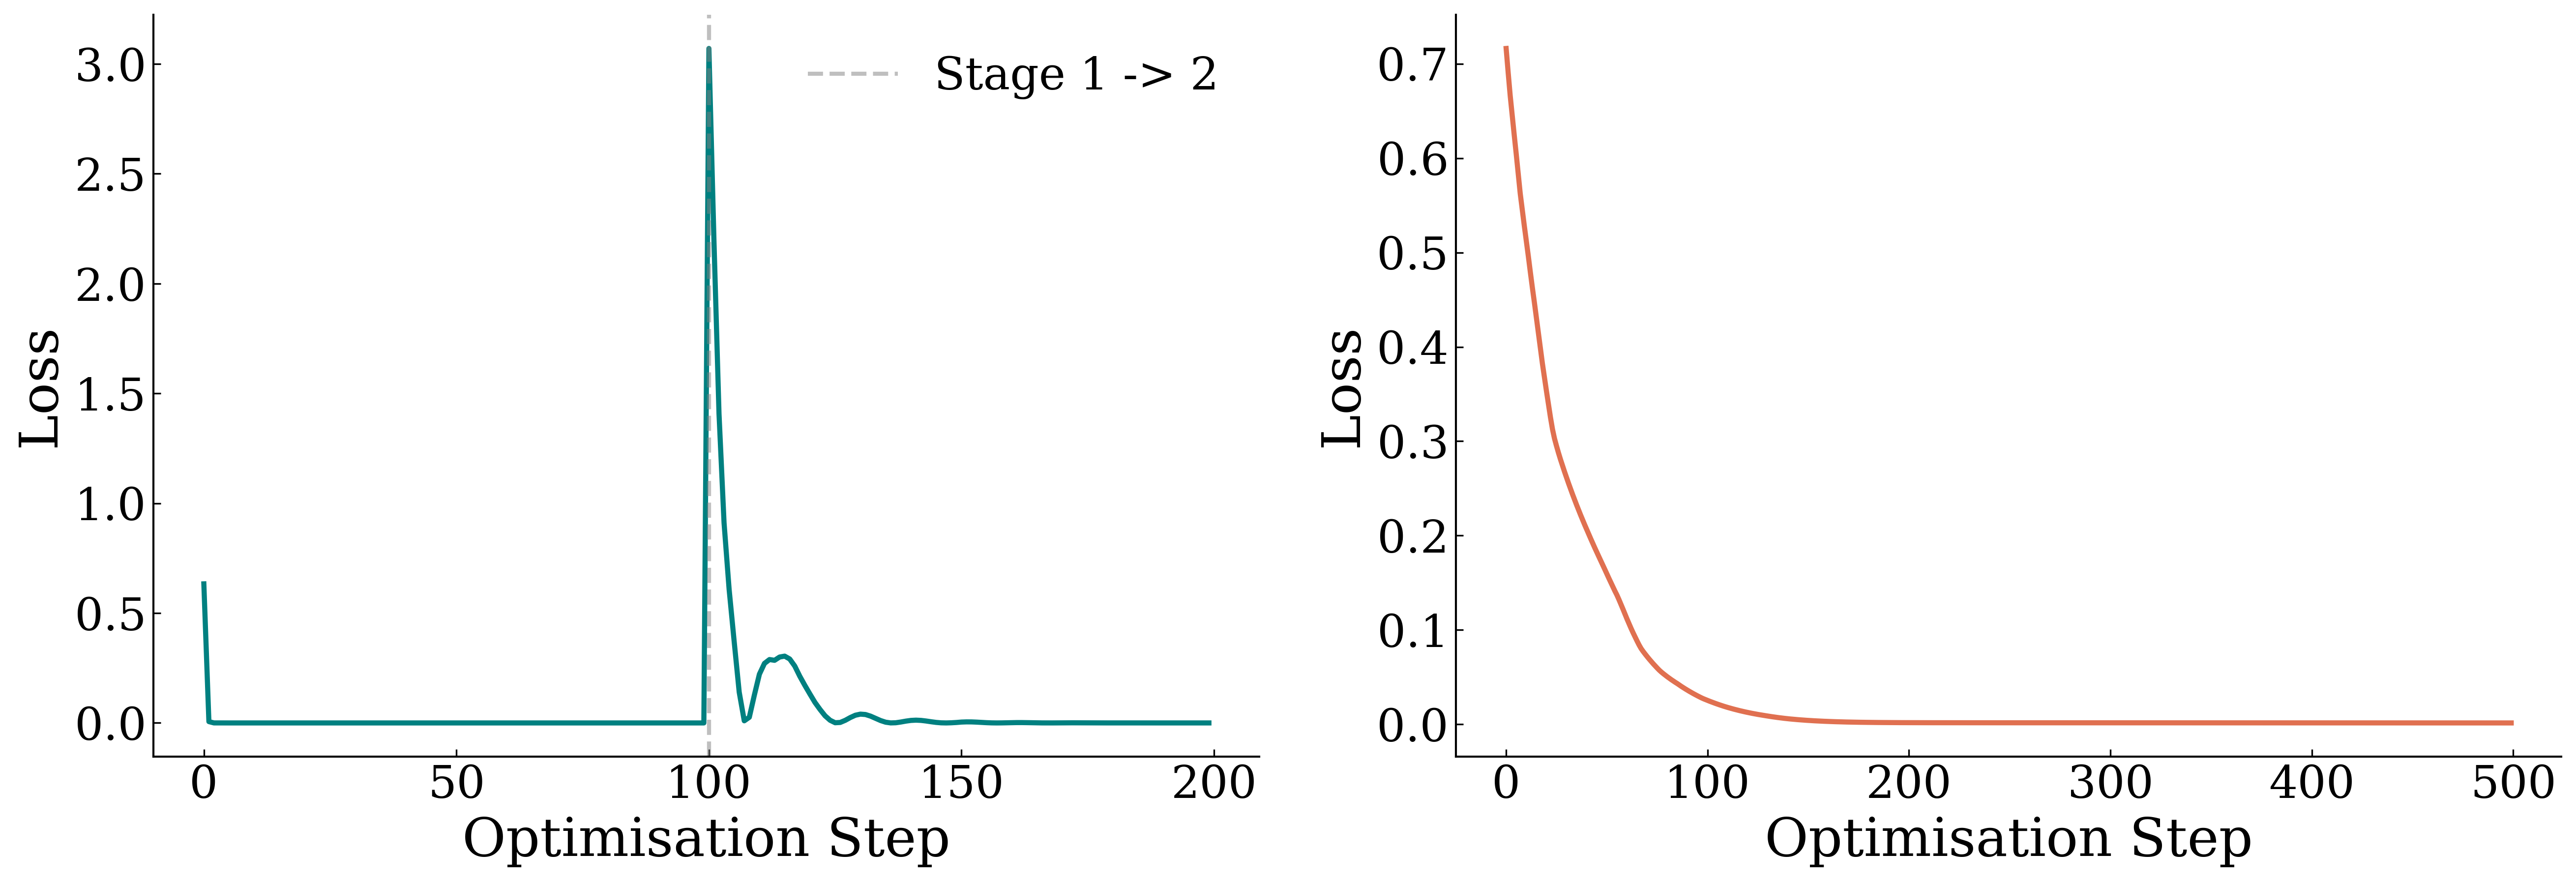

    Graph saved: INV_GD_inverse_gd_yield_progression.png/.pdf


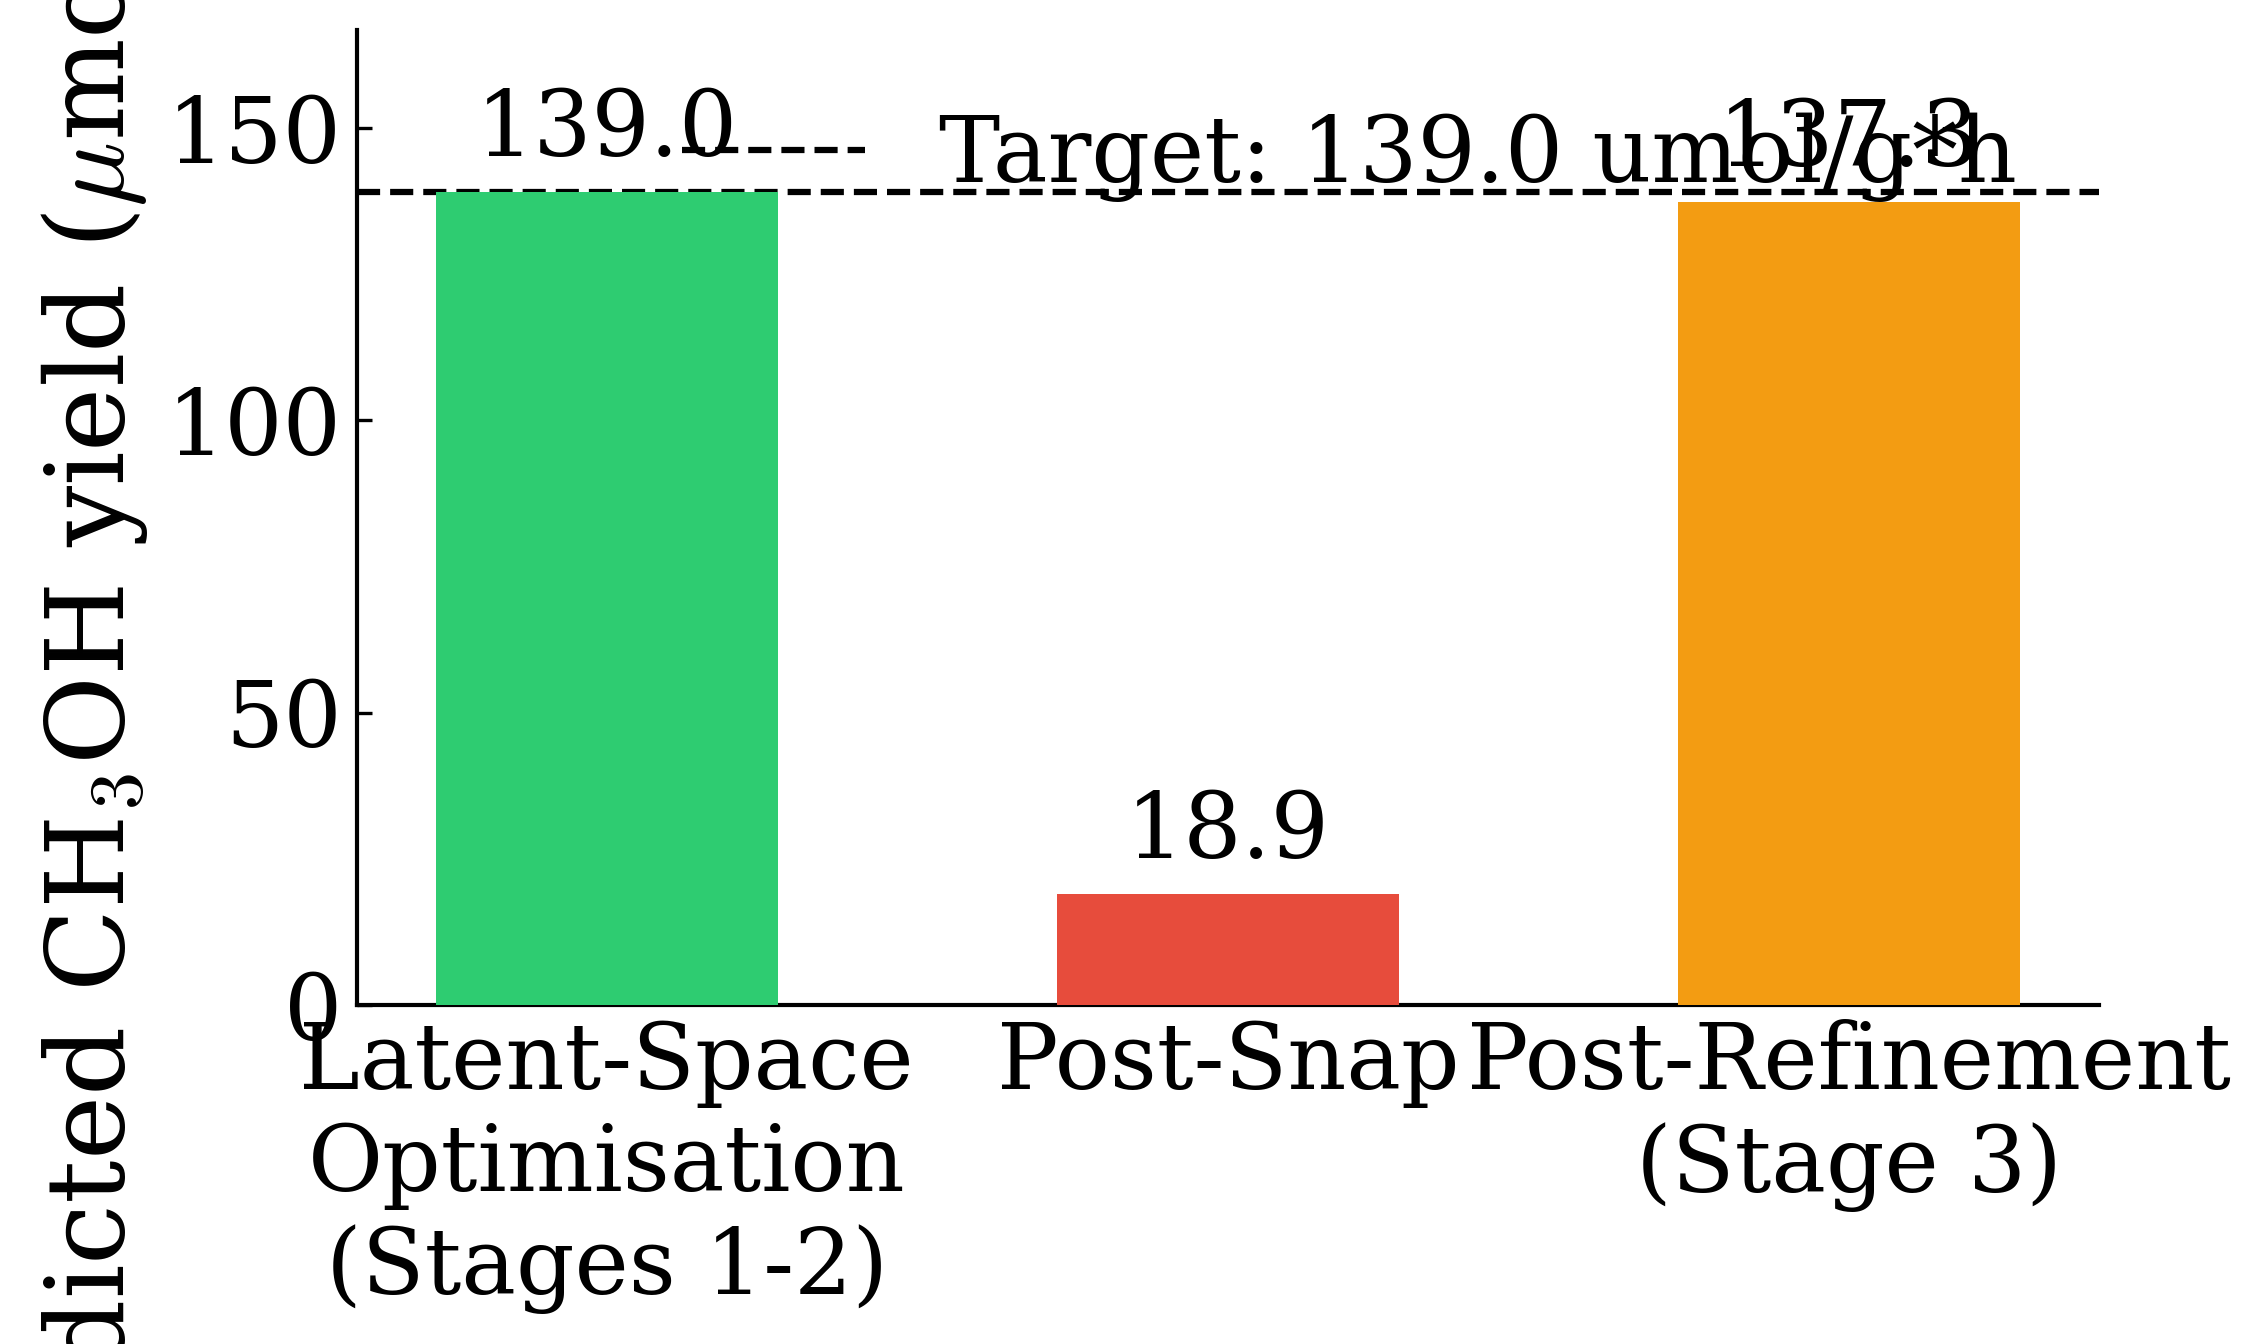

    Data saved: INV_GD_inverse_gd_optimal_recipe.json
    Data saved: INV_GD_inverse_gd_summary.json
    Graph data saved: INV_GD_inverse_gd_loss_s12.csv
    Graph data saved: INV_GD_inverse_gd_loss_s3.csv

✅ Gradient descent inverse design complete.


In [ ]:
# ==============================================================================
# 9. LOSS CURVES + YIELD PROGRESSION
# ==============================================================================

FONT_SCALE = 2
plt.style.use('default')
plt.rcParams.update({
    "text.usetex": False, "mathtext.fontset": "cm", "font.family": "serif",
    "axes.grid": False, "axes.linewidth": 1.0,
    "font.size": int(12 * FONT_SCALE),
    "axes.labelsize": int(13 * FONT_SCALE),
    "axes.titlesize": int(14 * FONT_SCALE),
    "xtick.labelsize": int(11 * FONT_SCALE),
    "ytick.labelsize": int(11 * FONT_SCALE),
    "legend.fontsize": int(11 * FONT_SCALE),
    "xtick.direction": "in", "ytick.direction": "in",
    "legend.frameon": False, "lines.linewidth": 2.0,
    "figure.dpi": 300, "savefig.dpi": 600, "savefig.bbox": "tight",
})

# Two-panel loss convergence
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

axes[0].plot(loss_history_s12, lw=2.5, color='#008080')
axes[0].axvline(x=100, color='grey', ls='--', alpha=0.5, label='Stage 1 -> 2')
axes[0].set_xlabel('Optimisation Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(loss_history_s3, lw=2.5, color='#E07050')
axes[1].set_xlabel('Optimisation Step')
axes[1].set_ylabel('Loss')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
save_graph(fig, 'inverse_gd_loss_convergence', model_name=MODEL_NAME_INV)
plt.show()
plt.close('all')

# Yield progression bar chart
# Pre-snap yield from stages 1-2
presnap_preds = inv_model(
    [tf.constant(snapped_num)] + cat_tensors, training=False)
presnap_rate = max(0, (10 ** float(presnap_preds[0].numpy().flatten()[0])) - 1)

stages = ['Latent-Space\nOptimisation\n(Stages 1-2)', 'Post-Snap', 'Post-Refinement\n(Stage 3)']
yields = [TARGET_YIELD, presnap_rate, final_rate]
colors = ['#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages, yields, width=0.55, color=colors, edgecolor='none', zorder=3)
ax.axhline(y=TARGET_YIELD, color='black', linestyle='--', linewidth=1.5,
           label=f'Target: {TARGET_YIELD} umol/g*h')
for bar, val in zip(bars, yields):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=int(11 * FONT_SCALE))
ax.set_ylabel(r'Predicted CH$_3$OH yield ($\mu$mol g$^{-1}$ h$^{-1}$)')
ax.set_ylim(0, max(yields) * 1.2)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
save_graph(fig, 'inverse_gd_yield_progression', model_name=MODEL_NAME_INV)
plt.show()
plt.close('all')

# ==============================================================================
# 10. SAVE
# ==============================================================================

save_results(optimal_refined, 'inverse_gd_optimal_recipe', model_name=MODEL_NAME_INV, fmt='json')
save_results(
    {'target_product': TARGET_PRODUCT, 'target_yield': TARGET_YIELD,
     'final_product': final_product, 'final_confidence': final_conf,
     'final_yield': final_rate, 'yield_gap_pct': yield_gap_pct,
     'active': snapped_active, 'support': snapped_support,
     'cocatalyst': snapped_cocat},
    'inverse_gd_summary', model_name=MODEL_NAME_INV, fmt='json')
save_graph_data(
    pd.DataFrame({'step': range(len(loss_history_s12)), 'loss': loss_history_s12}),
    'inverse_gd_loss_s12', model_name=MODEL_NAME_INV)
save_graph_data(
    pd.DataFrame({'step': range(len(loss_history_s3)), 'loss': loss_history_s3}),
    'inverse_gd_loss_s3', model_name=MODEL_NAME_INV)

print(f"\n✅ Gradient descent inverse design complete.")

## 4.2 Differential Evolution
*    reuses production_models + enrich_catalyst

### 4.2.1 Random Forest


In [ ]:
# ==============================================================================
# 4.2 DIFFERENTIAL EVOLUTION INVERSE DESIGN -- RF
# ==============================================================================
# Evolutionary optimisation over discrete materials + continuous conditions.
# Uses the PRODUCTION chained RF pipeline from Section 3 (no retraining).
#
# Runs 2 experiments:
#   1. DE + RF (unconstrained)
#   2. DE + RF (constrained -- photocatalytic regime)
#
# Dependencies: rf_production_models,
#               material_cache, elements_df, selected_pt_cols, MP_NUMERIC,
#               compute_photocatalyst_features, get_weighted_mp_properties,
#               sanitize_name, X_prod (training features for bounds)
# ==============================================================================

import numpy as np
import pandas as pd
import re
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings('ignore')

MODEL_NAME = 'INV_DE'

print(f"{'='*70}")
print("DIFFERENTIAL EVOLUTION INVERSE DESIGN -- CHAINED RF")
print(f"{'='*70}")

# ==============================================================================
# 1. TARGET CONFIGURATION
# ==============================================================================

TARGET_PRODUCT = 'CH3OH'
TARGET_YIELD = 139.0
TARGET_LOG = np.log10(TARGET_YIELD + 1)

# Get class index from the RF pipeline's label encoder
le_major_rf = rf_production_models['le_major']
le_minor_rf = rf_production_models['le_minor']
TARGET_IDX_RF = list(le_major_rf.classes_).index(TARGET_PRODUCT)

print(f"  Target: {TARGET_YIELD} umol/g*h of {TARGET_PRODUCT}")
print(f"  Target class index: {TARGET_IDX_RF}")
print(f"  Target log yield: {TARGET_LOG:.4f}")

# ==============================================================================
# 2. SEARCH SPACE DEFINITION
# ==============================================================================

mutable_numerical = [
    'Active_wt%', 'Support_wt%', 'Cocatalyst_Wt', 'Cocatalyst_wt%',
    'Sacrificial_agent_percent',
    'Light_intensity_mW/cm^2',
    'Reaction_temp', 'Reaction_pres_atm',
    'Reaction_Volume', 'CatperVol_mgpermL',
]

mutable_categorical = [
    'Active', 'Active_dimension', 'Support', 'Support_dimension',
    'Cocatalyst', 'Cocatalyst_dimension',
    'Light_type', 'Is_heterojunction', 'Is_Zscheme',
    'Is_molecular_catalyst', 'Noble_metal_present', 'NH2_present',
    'Reaction_Phase', 'Solvent', 'Sacrificial_agent_type',
]

# Extract unique categorical values from training data
cat_search_space = {}
cat_cols_ordered = []

for col in mutable_categorical:
    if col in X_prod.columns:
        unique_vals = sorted(X_prod[col].dropna().astype(str).unique().tolist())
        unique_vals = [v for v in unique_vals if v not in ('nan', '')]
        if len(unique_vals) > 0:
            cat_search_space[col] = unique_vals
            cat_cols_ordered.append(col)

print(f"\n  Categorical dimensions: {len(cat_cols_ordered)}")
for col in cat_cols_ordered:
    print(f"    {col:<35s}: {len(cat_search_space[col])} options")

# Numerical bounds from training data (percentile clipped)
LOWER_PCTILE = 1
UPPER_PCTILE = 99

num_search_space = {}
num_cols_ordered = []

for col in mutable_numerical:
    if col in X_prod.columns:
        vals = pd.to_numeric(X_prod[col], errors='coerce').dropna()
        if len(vals) > 0:
            lo = max(0, np.percentile(vals, LOWER_PCTILE))
            hi = np.percentile(vals, UPPER_PCTILE)
            if lo == hi:
                hi = lo + 1.0
            num_search_space[col] = (lo, hi)
            num_cols_ordered.append(col)

print(f"\n  Numerical dimensions: {len(num_cols_ordered)}")
for col in num_cols_ordered:
    lo, hi = num_search_space[col]
    print(f"    {col:<35s}: [{lo:.2f}, {hi:.2f}]")

# Build unconstrained bounds: categoricals as float indices, then numericals
ga_bounds_unconstrained = []
for col in cat_cols_ordered:
    n = len(cat_search_space[col])
    ga_bounds_unconstrained.append((0, n - 0.01))
for col in num_cols_ordered:
    ga_bounds_unconstrained.append(num_search_space[col])

print(f"\n  Total search dimensions: {len(ga_bounds_unconstrained)}")

# ==============================================================================
# 3. CONSTRAINED BOUNDS (PHOTOCATALYTIC REGIME)
# ==============================================================================
# The unconstrained search can exploit thermocatalytic regimes (high temp,
# no light). Constrained bounds enforce photocatalytically realistic conditions.

CONSTRAINED_OVERRIDES = {
    'Reaction_temp': (0.0, 200.0),
    'Reaction_pres_atm': (0.5, 10.0),
    'Cocatalyst_Wt': (0.0, 15.0),
    'Cocatalyst_wt%': (0.0, 15.0),
    'Light_intensity_mW/cm^2': (10.0, 500.0),
}

CONSTRAINED_CAT_EXCLUSIONS = {
    'Light_type': ['Dark'],
}

constrained_cat_space = {}


def build_constrained_bounds():
    bounds = []
    for col in cat_cols_ordered:
        vals = cat_search_space[col].copy()
        if col in CONSTRAINED_CAT_EXCLUSIONS:
            vals = [v for v in vals if v not in CONSTRAINED_CAT_EXCLUSIONS[col]]
        constrained_cat_space[col] = vals
        bounds.append((0, len(vals) - 0.01))
    for col in num_cols_ordered:
        if col in CONSTRAINED_OVERRIDES:
            bounds.append(CONSTRAINED_OVERRIDES[col])
        else:
            bounds.append(num_search_space[col])
    return bounds


ga_bounds_constrained = build_constrained_bounds()

print(f"\n  Constrained overrides:")
for col, (lo, hi) in CONSTRAINED_OVERRIDES.items():
    if col in num_search_space:
        orig = num_search_space[col]
        print(f"    {col:<35s}: [{orig[0]:.1f}, {orig[1]:.1f}] -> [{lo:.1f}, {hi:.1f}]")
for col, excluded in CONSTRAINED_CAT_EXCLUSIONS.items():
    print(f"    {col:<35s}: excluded {excluded}")

# ==============================================================================
# 4. PHYSICS AND CONSISTENCY HELPERS
# ==============================================================================

NOBLE_METALS = {'Pt', 'Au', 'Ag', 'Pd', 'Rh', 'Ru', 'Ir', 'Os'}
NA_VALUES = {'NA', 'NA_CATEGORY', 'Missing', 'nan', 'None', 'none', '', 'NR'}
MATERIAL_DIMENSION_PAIRS = [
    ('Active', 'Active_dimension'),
    ('Support', 'Support_dimension'),
    ('Cocatalyst', 'Cocatalyst_dimension'),
]

BASE_DICT = {
    'Number': 9999,
    'Description': 'DE_Optimised',
    'Characteristic_size_nm': 130.0,
    'Light_wavelength_min_nm': 400.0,
}


def contains_noble_metal(formula):
    elements = set(re.findall(r'[A-Z][a-z]?', str(formula)))
    return bool(elements & NOBLE_METALS)


def get_na_value(col, space):
    for v in space.get(col, []):
        if v in NA_VALUES:
            return v
    return None


def get_non_na_fallback(col, space):
    for v in space.get(col, []):
        if v not in NA_VALUES:
            return v
    return None


def decode_genome(genome, use_constrained=False):
    space = constrained_cat_space if use_constrained else cat_search_space
    hypo = BASE_DICT.copy()
    idx = 0

    # Decode categoricals
    for col in cat_cols_ordered:
        options = space.get(col, cat_search_space[col])
        cat_idx = int(np.floor(genome[idx]))
        cat_idx = min(max(cat_idx, 0), len(options) - 1)
        hypo[col] = options[cat_idx]
        idx += 1

    # Decode numericals
    for col in num_cols_ordered:
        hypo[col] = genome[idx]
        idx += 1

    # Weight constraint: Active + Support + Cocatalyst = 100%
    act_wt = hypo.get('Active_wt%', 50.0)
    sup_wt = hypo.get('Support_wt%', 50.0)
    cocat_wt = hypo.get('Cocatalyst_wt%', hypo.get('Cocatalyst_Wt', 0.0)) or 0.0
    cocat_wt = np.clip(cocat_wt, 0.0, 100.0)

    remaining = max(0.0, 100.0 - cocat_wt)
    total = act_wt + sup_wt
    if total > 0:
        hypo['Active_wt%'] = remaining * (act_wt / total)
        hypo['Support_wt%'] = remaining * (sup_wt / total)
    else:
        hypo['Active_wt%'] = remaining / 2.0
        hypo['Support_wt%'] = remaining / 2.0
    hypo['Cocatalyst_wt%'] = cocat_wt
    hypo['Cocatalyst_Wt'] = cocat_wt

    # Material-dimension consistency: if material is NA, dimension must be NA
    # and vice versa
    for mat_col, dim_col in MATERIAL_DIMENSION_PAIRS:
        if mat_col not in hypo or dim_col not in hypo:
            continue
        mat_is_na = hypo[mat_col] in NA_VALUES
        dim_is_na = hypo[dim_col] in NA_VALUES
        if mat_is_na and not dim_is_na:
            na_val = get_na_value(dim_col, space)
            if na_val is not None:
                hypo[dim_col] = na_val
        elif not mat_is_na and dim_is_na:
            fallback = get_non_na_fallback(dim_col, space)
            if fallback is not None:
                hypo[dim_col] = fallback

    # Prevent Active == Support (would not be a heterojunction)
    if (hypo.get('Active') == hypo.get('Support')
            and hypo.get('Active') not in NA_VALUES):
        for alt in space.get('Support', cat_search_space.get('Support', [])):
            if alt != hypo['Active'] and alt not in NA_VALUES:
                hypo['Support'] = alt
                break

    # Heterojunction / Z-scheme / molecular catalyst mutual exclusivity
    is_hj = hypo.get('Is_heterojunction', 'No')
    is_zs = hypo.get('Is_Zscheme', 'No')
    is_mc = hypo.get('Is_molecular_catalyst', 'No')
    if is_hj == 'Yes' or is_zs == 'Yes':
        hypo['Is_molecular_catalyst'] = 'No'
    elif is_mc == 'Yes':
        hypo['Is_heterojunction'] = 'No'
        hypo['Is_Zscheme'] = 'No'

    # Noble metal consistency -- derived from composition, not a free choice
    has_noble = (contains_noble_metal(hypo.get('Active', '')) or
                 contains_noble_metal(hypo.get('Support', '')) or
                 contains_noble_metal(hypo.get('Cocatalyst', '')))
    hypo['Noble_metal_present'] = 'Yes' if has_noble else 'No'

    return hypo


def inject_physics(hypo):
    """Inject periodic table and Materials Project features from pre-cached data."""
    active_mat = hypo.get('Active', '')
    support_mat = hypo.get('Support', '')
    act_wt = hypo.get('Active_wt%', 50.0)
    sup_wt = hypo.get('Support_wt%', 50.0)
    total_wt = act_wt + sup_wt if (act_wt + sup_wt) > 0 else 1.0

    # Periodic table features (weighted by component fractions)
    compounds = []
    weights = []
    if active_mat not in NA_VALUES:
        compounds.append(active_mat)
        weights.append(act_wt)
    if support_mat not in NA_VALUES:
        compounds.append(support_mat)
        weights.append(sup_wt)

    if compounds:
        pt_features = compute_photocatalyst_features(
            compounds, weights, elements_df, selected_pt_cols, fill_missing=True)
        if pt_features:
            hypo.update(pt_features)

    # Materials Project features (weighted averages)
    act_data = material_cache.get(active_mat, {}) if active_mat not in NA_VALUES else {}
    sup_data = material_cache.get(support_mat, {}) if support_mat not in NA_VALUES else {}

    comp_list = []
    if act_data:
        comp_list.append({
            'type': 'Active', 'formula': active_mat,
            'wt_fraction': act_wt / total_wt, 'data': act_data})
    if sup_data:
        comp_list.append({
            'type': 'Support', 'formula': support_mat,
            'wt_fraction': sup_wt / total_wt, 'data': sup_data})

    if comp_list:
        weighted_avg = get_weighted_mp_properties(comp_list, MP_NUMERIC)
        for prop in MP_NUMERIC:
            hypo[f'avg_{prop}'] = weighted_avg.get(prop)
        if act_data:
            hypo['Active_is_gap_direct'] = act_data.get('is_gap_direct')
            hypo['Active_is_stable'] = act_data.get('is_stable')
            hypo['Active_crystal_system'] = act_data.get('crystal_system')

    return hypo


# ==============================================================================
# 5. RF PREDICTION WRAPPER
# ==============================================================================

def predict_rf(feature_dict):
    """Forward pass through the production chained RF pipeline."""
    pipeline = rf_production_models
    df = pd.DataFrame([feature_dict])
    num_cols = pipeline['numerical_cols']
    cat_cols = pipeline['categorical_cols']

    for col in num_cols + cat_cols:
        if col not in df.columns:
            df[col] = np.nan

    df[num_cols] = df[num_cols].apply(
        pd.to_numeric, errors='coerce').fillna(pipeline['train_means'])
    X_num = pipeline['scaler'].transform(df[num_cols]).astype('float32')

    cat_inputs = []
    for col in cat_cols:
        val = str(df[col].iloc[0]) if pd.notna(df[col].iloc[0]) else 'Missing'
        cat_inputs.append(
            np.array([pipeline['cat_mappings'][col].get(val, 0)], dtype='int32'))

    X_emb = pipeline['extractor'].predict([X_num] + cat_inputs, verbose=0)

    mj_clf_pred = pipeline['rf_mj_clf'].predict(X_emb)
    mj_clf_proba = pipeline['rf_mj_clf'].predict_proba(X_emb)

    X_c2 = np.column_stack([X_emb, mj_clf_pred.reshape(-1, 1)])
    mi_clf_pred = pipeline['rf_mi_clf'].predict(X_c2)
    mi_clf_proba = pipeline['rf_mi_clf'].predict_proba(X_c2)

    X_c3 = np.column_stack([X_emb, mj_clf_pred.reshape(-1, 1),
                            mi_clf_pred.reshape(-1, 1)])
    mj_reg_pred = pipeline['rf_mj_reg'].predict(X_c3)

    X_c4 = np.column_stack([X_emb, mj_clf_pred.reshape(-1, 1),
                            mi_clf_pred.reshape(-1, 1),
                            mj_reg_pred.reshape(-1, 1)])
    mi_reg_pred = pipeline['rf_mi_reg'].predict(X_c4)

    return {
        'mj_clf_idx': int(mj_clf_pred[0]),
        'mi_clf_idx': int(mi_clf_pred[0]),
        'mj_clf_proba': mj_clf_proba[0],
        'mi_clf_proba': mi_clf_proba[0],
        'mj_reg_log': float(mj_reg_pred[0]),
        'mi_reg_log': float(mi_reg_pred[0]),
    }


# ==============================================================================
# 6. OBJECTIVE FUNCTION (Equation 3 from paper)
# ==============================================================================
# L = |y_hat_log - log10(y* + 1)| + lambda * I[c_hat != c*]
#     - beta * P(c_hat = c*) * I[c_hat = c*]
#
# lambda = 100 (misclassification penalty)
# beta = 0.5  (confidence bonus when correct)
# ==============================================================================

LAMBDA_PENALTY = 100.0
BETA_BONUS = 0.5


def objective_rf(genome, use_constrained=False, return_full=False):
    hypo = decode_genome(genome, use_constrained=use_constrained)
    hypo = inject_physics(hypo)
    result = predict_rf(hypo)

    if return_full:
        return result, hypo

    # Equation 3 loss
    rate_loss = abs(result['mj_reg_log'] - TARGET_LOG)
    correct_class = (result['mj_clf_idx'] == TARGET_IDX_RF)
    class_penalty = 0.0 if correct_class else LAMBDA_PENALTY
    conf_bonus = (-BETA_BONUS * result['mj_clf_proba'][TARGET_IDX_RF]
                  if correct_class else 0.0)

    return rate_loss + class_penalty + conf_bonus


# Wrappers for scipy -- differential_evolution only passes the genome vector
def objective_rf_unconstrained(genome):
    return objective_rf(genome, use_constrained=False)

def objective_rf_constrained(genome):
    return objective_rf(genome, use_constrained=True)


# ==============================================================================
# 7. EARLY STOPPING
# ==============================================================================

class StagnationStopper:
    """Stops differential_evolution if best fitness stagnates."""
    def __init__(self, obj_fn, patience=4, min_delta=1e-4):
        self.obj_fn = obj_fn
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.stagnant = 0

    def __call__(self, xk, convergence):
        current = self.obj_fn(xk)
        if current < self.best - self.min_delta:
            self.best = current
            self.stagnant = 0
        else:
            self.stagnant += 1
        if self.stagnant >= self.patience:
            print(f"  Early stop: no improvement for {self.patience} iterations "
                  f"(best={self.best:.4f})")
            return True
        return False


# ==============================================================================
# 8. RUN BOTH EXPERIMENTS
# ==============================================================================

de_rf_results = {}

experiments = [
    ('DE+RF (U)', ga_bounds_unconstrained, objective_rf_unconstrained, False),
    ('DE+RF (C)', ga_bounds_constrained,   objective_rf_constrained,   True),
]

for exp_name, bounds, obj_fn, constrained in experiments:
    print(f"\n{'='*70}")
    print(f"  RUNNING: {exp_name}")
    print(f"{'='*70}")
    print(f"  Dimensions: {len(bounds)}")
    print(f"  Constrained: {constrained}")

    stopper = StagnationStopper(
        obj_fn=obj_fn, patience=4, min_delta=1e-4)

    result = differential_evolution(
        func=obj_fn,
        bounds=bounds,
        strategy='best1bin',
        maxiter=20,
        popsize=15,
        mutation=(0.5, 1.0),
        recombination=0.7,
        seed=42,
        disp=True,
        tol=1e-4,
        callback=stopper,
        polish=False,
    )

    # Decode the winning genome
    best_pred, best_hypo = objective_rf(
        result.x, use_constrained=constrained, return_full=True)

    major_product = le_major_rf.inverse_transform([best_pred['mj_clf_idx']])[0]
    minor_product = le_minor_rf.inverse_transform([best_pred['mi_clf_idx']])[0]
    major_rate = max(0, (10 ** best_pred['mj_reg_log']) - 1)
    minor_rate = max(0, (10 ** best_pred['mi_reg_log']) - 1)
    mj_conf = best_pred['mj_clf_proba'][best_pred['mj_clf_idx']] * 100
    mi_conf = best_pred['mi_clf_proba'][best_pred['mi_clf_idx']] * 100

    yield_gap = major_rate - TARGET_YIELD
    yield_gap_pct = (yield_gap / TARGET_YIELD) * 100

    wt_sum = (best_hypo.get('Active_wt%', 0) +
              best_hypo.get('Support_wt%', 0) +
              best_hypo.get('Cocatalyst_wt%', 0))

    print(f"\n  {'─'*50}")
    print(f"  RESULT: {exp_name}")
    print(f"  {'─'*50}")
    print(f"  Major Product:  {major_product} ({mj_conf:.1f}%)")
    print(f"  Major Rate:     {major_rate:.2f} umol/g*h (target: {TARGET_YIELD})")
    print(f"  Yield gap:      {yield_gap:+.2f} umol/g*h ({yield_gap_pct:+.1f}%)")
    print(f"  Minor Product:  {minor_product} ({mi_conf:.1f}%)")
    print(f"  Minor Rate:     {minor_rate:.2f} umol/g*h")
    print(f"  Weight sum:     {wt_sum:.2f}%")
    print(f"  GA fitness:     {result.fun:.4f}")

    print(f"\n  Catalyst:")
    print(f"    Active:     {best_hypo.get('Active', '?')}")
    print(f"    Support:    {best_hypo.get('Support', '?')}")
    print(f"    Cocatalyst: {best_hypo.get('Cocatalyst', 'None')}")

    print(f"\n  Conditions:")
    for col in num_cols_ordered:
        print(f"    {col:<35s}: {best_hypo[col]:.4f}")

    # Store for comparison table
    de_rf_results[exp_name] = {
        'predicted_product': f"{major_product} ({mj_conf:.1f}%)",
        'predicted_yield': major_rate,
        'yield_gap_pct': yield_gap_pct,
        'active': best_hypo.get('Active', '?'),
        'support': best_hypo.get('Support', '?'),
        'cocatalyst': best_hypo.get('Cocatalyst', 'None'),
        'temperature': best_hypo.get('Reaction_temp', 0),
        'pressure': best_hypo.get('Reaction_pres_atm', 0),
        'light_type': best_hypo.get('Light_type', '?'),
        'minor_product': f"{minor_product} ({mi_conf:.1f}%)",
        'minor_rate': minor_rate,
        'fitness': result.fun,
        'full_hypo': best_hypo,
        'full_pred': best_pred,
    }

    # Save individual recipe
    tag = 'unconstrained' if not constrained else 'constrained'
    recipe_data = {
        'Target_Product': TARGET_PRODUCT,
        'Target_Rate': TARGET_YIELD,
        'Predicted_Product': major_product,
        'Predicted_Rate': major_rate,
        'Confidence_pct': mj_conf,
        'Yield_Gap_Pct': yield_gap_pct,
        'Constrained': constrained,
    }
    recipe_data.update(
        {f'cat_{col}': best_hypo.get(col, '') for col in cat_cols_ordered})
    recipe_data.update(
        {f'num_{col}': best_hypo.get(col, 0) for col in num_cols_ordered})

    save_results(
        pd.DataFrame([recipe_data]),
        f'de_rf_{tag}_recipe',
        model_name=MODEL_NAME)

# ==============================================================================
# 9. SAVE COMPARISON TABLE
# ==============================================================================

print(f"\n{'='*70}")
print("DE + RF COMPARISON")
print(f"{'='*70}")

comparison_rows = []
for name, res in de_rf_results.items():
    comparison_rows.append({
        'Experiment': name,
        'Product (Confidence)': res['predicted_product'],
        'Yield (umol/g*h)': f"{res['predicted_yield']:.2f}",
        'Yield Gap': f"{res['yield_gap_pct']:+.1f}%",
        'Active': res['active'],
        'Support': res['support'],
        'Cocatalyst': res['cocatalyst'],
        'Temperature (C)': f"{res['temperature']:.0f}",
        'Pressure (atm)': f"{res['pressure']:.1f}",
        'Light Type': res['light_type'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

save_results(comparison_df, 'de_rf_comparison', model_name=MODEL_NAME)
save_graph_data(comparison_df, 'de_rf_comparison', model_name=MODEL_NAME)

print(f"\n{'='*70}")
print("DE + RF INVERSE DESIGN COMPLETE")
print(f"{'='*70}")

DIFFERENTIAL EVOLUTION INVERSE DESIGN -- CHAINED RF
  Target: 139.0 umol/g*h of CH3OH
  Target class index: 4
  Target log yield: 2.1461

  Categorical dimensions: 15
    Active                             : 52 options
    Active_dimension                   : 5 options
    Support                            : 32 options
    Support_dimension                  : 6 options
    Cocatalyst                         : 27 options
    Cocatalyst_dimension               : 5 options
    Light_type                         : 7 options
    Is_heterojunction                  : 2 options
    Is_Zscheme                         : 2 options
    Is_molecular_catalyst              : 2 options
    Noble_metal_present                : 2 options
    NH2_present                        : 2 options
    Reaction_Phase                     : 2 options
    Solvent                            : 10 options
    Sacrificial_agent_type             : 13 options

  Numerical dimensions: 10
    Active_wt%                     

### 4.2.2 Neural Network

In [ ]:
# ==============================================================================
# 4.3 DIFFERENTIAL EVOLUTION INVERSE DESIGN -- NN
# ==============================================================================
# Evolutionary optimisation over discrete materials + continuous conditions.
# Uses the PRODUCTION NN major model from Section 3 (no retraining).
#
# Runs 2 experiments:
#   1. DE + NN (unconstrained)
#   2. DE + NN (constrained -- photocatalytic regime)
#
# Dependencies: production_models,
#               material_cache, elements_df, selected_pt_cols, MP_NUMERIC,
#               compute_photocatalyst_features, get_weighted_mp_properties,
#               sanitize_name, X_prod (training features for bounds)
# ==============================================================================

import numpy as np
import pandas as pd
import re
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings('ignore')

MODEL_NAME = 'INV_DE'

print(f"{'='*70}")
print("DIFFERENTIAL EVOLUTION INVERSE DESIGN -- NN")
print(f"{'='*70}")

# ==============================================================================
# 1. TARGET CONFIGURATION
# ==============================================================================

TARGET_PRODUCT = 'CH3OH'
TARGET_YIELD = 139.0
TARGET_LOG = np.log10(TARGET_YIELD + 1)

# Pull production model and preprocessors
nn_model = production_models['model_major']
nn_prep = production_models['prep_major']

le_target_nn = nn_prep['le_target']
TARGET_IDX_NN = list(le_target_nn.classes_).index(TARGET_PRODUCT)

print(f"  Target: {TARGET_YIELD} umol/g*h of {TARGET_PRODUCT}")
print(f"  Target class index: {TARGET_IDX_NN}")
print(f"  Target log yield: {TARGET_LOG:.4f}")

# ==============================================================================
# 2. SEARCH SPACE DEFINITION
# ==============================================================================

mutable_numerical = [
    'Active_wt%', 'Support_wt%', 'Cocatalyst_Wt', 'Cocatalyst_wt%',
    'Sacrificial_agent_percent',
    'Light_intensity_mW/cm^2',
    'Reaction_temp', 'Reaction_pres_atm',
    'Reaction_Volume', 'CatperVol_mgpermL',
]

mutable_categorical = [
    'Active', 'Active_dimension', 'Support', 'Support_dimension',
    'Cocatalyst', 'Cocatalyst_dimension',
    'Light_type', 'Is_heterojunction', 'Is_Zscheme',
    'Is_molecular_catalyst', 'Noble_metal_present', 'NH2_present',
    'Reaction_Phase', 'Solvent', 'Sacrificial_agent_type',
]

# Extract unique categorical values from training data
cat_search_space_nn = {}
cat_cols_ordered_nn = []

for col in mutable_categorical:
    if col in X_prod.columns:
        unique_vals = sorted(X_prod[col].dropna().astype(str).unique().tolist())
        unique_vals = [v for v in unique_vals if v not in ('nan', '')]
        if len(unique_vals) > 0:
            cat_search_space_nn[col] = unique_vals
            cat_cols_ordered_nn.append(col)

print(f"\n  Categorical dimensions: {len(cat_cols_ordered_nn)}")
for col in cat_cols_ordered_nn:
    print(f"    {col:<35s}: {len(cat_search_space_nn[col])} options")

# Numerical bounds from training data (percentile clipped)
LOWER_PCTILE = 1
UPPER_PCTILE = 99

num_search_space_nn = {}
num_cols_ordered_nn = []

for col in mutable_numerical:
    if col in X_prod.columns:
        vals = pd.to_numeric(X_prod[col], errors='coerce').dropna()
        if len(vals) > 0:
            lo = max(0, np.percentile(vals, LOWER_PCTILE))
            hi = np.percentile(vals, UPPER_PCTILE)
            if lo == hi:
                hi = lo + 1.0
            num_search_space_nn[col] = (lo, hi)
            num_cols_ordered_nn.append(col)

print(f"\n  Numerical dimensions: {len(num_cols_ordered_nn)}")
for col in num_cols_ordered_nn:
    lo, hi = num_search_space_nn[col]
    print(f"    {col:<35s}: [{lo:.2f}, {hi:.2f}]")

# Build unconstrained bounds: categoricals as float indices, then numericals
ga_bounds_unconstrained_nn = []
for col in cat_cols_ordered_nn:
    n = len(cat_search_space_nn[col])
    ga_bounds_unconstrained_nn.append((0, n - 0.01))
for col in num_cols_ordered_nn:
    ga_bounds_unconstrained_nn.append(num_search_space_nn[col])

print(f"\n  Total search dimensions: {len(ga_bounds_unconstrained_nn)}")

# ==============================================================================
# 3. CONSTRAINED BOUNDS (PHOTOCATALYTIC REGIME)
# ==============================================================================

CONSTRAINED_OVERRIDES_NN = {
    'Reaction_temp': (0.0, 200.0),
    'Reaction_pres_atm': (0.5, 10.0),
    'Cocatalyst_Wt': (0.0, 15.0),
    'Cocatalyst_wt%': (0.0, 15.0),
    'Light_intensity_mW/cm^2': (10.0, 500.0),
}

CONSTRAINED_CAT_EXCLUSIONS_NN = {
    'Light_type': ['Dark'],
}

constrained_cat_space_nn = {}


def build_constrained_bounds_nn():
    bounds = []
    for col in cat_cols_ordered_nn:
        vals = cat_search_space_nn[col].copy()
        if col in CONSTRAINED_CAT_EXCLUSIONS_NN:
            vals = [v for v in vals if v not in CONSTRAINED_CAT_EXCLUSIONS_NN[col]]
        constrained_cat_space_nn[col] = vals
        bounds.append((0, len(vals) - 0.01))
    for col in num_cols_ordered_nn:
        if col in CONSTRAINED_OVERRIDES_NN:
            bounds.append(CONSTRAINED_OVERRIDES_NN[col])
        else:
            bounds.append(num_search_space_nn[col])
    return bounds


ga_bounds_constrained_nn = build_constrained_bounds_nn()

print(f"\n  Constrained overrides:")
for col, (lo, hi) in CONSTRAINED_OVERRIDES_NN.items():
    if col in num_search_space_nn:
        orig = num_search_space_nn[col]
        print(f"    {col:<35s}: [{orig[0]:.1f}, {orig[1]:.1f}] -> [{lo:.1f}, {hi:.1f}]")
for col, excluded in CONSTRAINED_CAT_EXCLUSIONS_NN.items():
    print(f"    {col:<35s}: excluded {excluded}")

# ==============================================================================
# 4. PHYSICS AND CONSISTENCY HELPERS
# ==============================================================================

NOBLE_METALS = {'Pt', 'Au', 'Ag', 'Pd', 'Rh', 'Ru', 'Ir', 'Os'}
NA_VALUES = {'NA', 'NA_CATEGORY', 'Missing', 'nan', 'None', 'none', '', 'NR'}
MATERIAL_DIMENSION_PAIRS = [
    ('Active', 'Active_dimension'),
    ('Support', 'Support_dimension'),
    ('Cocatalyst', 'Cocatalyst_dimension'),
]

BASE_DICT = {
    'Number': 9999,
    'Description': 'DE_Optimised',
    'Characteristic_size_nm': 130.0,
    'Light_wavelength_min_nm': 400.0,
}


def contains_noble_metal(formula):
    elements = set(re.findall(r'[A-Z][a-z]?', str(formula)))
    return bool(elements & NOBLE_METALS)


def get_na_value_nn(col, space):
    for v in space.get(col, []):
        if v in NA_VALUES:
            return v
    return None


def get_non_na_fallback_nn(col, space):
    for v in space.get(col, []):
        if v not in NA_VALUES:
            return v
    return None


def decode_genome_nn(genome, use_constrained=False):
    space = constrained_cat_space_nn if use_constrained else cat_search_space_nn
    hypo = BASE_DICT.copy()
    idx = 0

    # Decode categoricals
    for col in cat_cols_ordered_nn:
        options = space.get(col, cat_search_space_nn[col])
        cat_idx = int(np.floor(genome[idx]))
        cat_idx = min(max(cat_idx, 0), len(options) - 1)
        hypo[col] = options[cat_idx]
        idx += 1

    # Decode numericals
    for col in num_cols_ordered_nn:
        hypo[col] = genome[idx]
        idx += 1

    # Weight constraint: Active + Support + Cocatalyst = 100%
    act_wt = hypo.get('Active_wt%', 50.0)
    sup_wt = hypo.get('Support_wt%', 50.0)
    cocat_wt = hypo.get('Cocatalyst_wt%', hypo.get('Cocatalyst_Wt', 0.0)) or 0.0
    cocat_wt = np.clip(cocat_wt, 0.0, 100.0)

    remaining = max(0.0, 100.0 - cocat_wt)
    total = act_wt + sup_wt
    if total > 0:
        hypo['Active_wt%'] = remaining * (act_wt / total)
        hypo['Support_wt%'] = remaining * (sup_wt / total)
    else:
        hypo['Active_wt%'] = remaining / 2.0
        hypo['Support_wt%'] = remaining / 2.0
    hypo['Cocatalyst_wt%'] = cocat_wt
    hypo['Cocatalyst_Wt'] = cocat_wt

    # Material-dimension consistency
    for mat_col, dim_col in MATERIAL_DIMENSION_PAIRS:
        if mat_col not in hypo or dim_col not in hypo:
            continue
        mat_is_na = hypo[mat_col] in NA_VALUES
        dim_is_na = hypo[dim_col] in NA_VALUES
        if mat_is_na and not dim_is_na:
            na_val = get_na_value_nn(dim_col, space)
            if na_val is not None:
                hypo[dim_col] = na_val
        elif not mat_is_na and dim_is_na:
            fallback = get_non_na_fallback_nn(dim_col, space)
            if fallback is not None:
                hypo[dim_col] = fallback

    # Prevent Active == Support
    if (hypo.get('Active') == hypo.get('Support')
            and hypo.get('Active') not in NA_VALUES):
        for alt in space.get('Support', cat_search_space_nn.get('Support', [])):
            if alt != hypo['Active'] and alt not in NA_VALUES:
                hypo['Support'] = alt
                break

    # Heterojunction / Z-scheme / molecular catalyst mutual exclusivity
    is_hj = hypo.get('Is_heterojunction', 'No')
    is_zs = hypo.get('Is_Zscheme', 'No')
    is_mc = hypo.get('Is_molecular_catalyst', 'No')
    if is_hj == 'Yes' or is_zs == 'Yes':
        hypo['Is_molecular_catalyst'] = 'No'
    elif is_mc == 'Yes':
        hypo['Is_heterojunction'] = 'No'
        hypo['Is_Zscheme'] = 'No'

    # Noble metal consistency
    has_noble = (contains_noble_metal(hypo.get('Active', '')) or
                 contains_noble_metal(hypo.get('Support', '')) or
                 contains_noble_metal(hypo.get('Cocatalyst', '')))
    hypo['Noble_metal_present'] = 'Yes' if has_noble else 'No'

    return hypo


def inject_physics_nn(hypo):
    """Inject periodic table and Materials Project features from pre-cached data."""
    active_mat = hypo.get('Active', '')
    support_mat = hypo.get('Support', '')
    act_wt = hypo.get('Active_wt%', 50.0)
    sup_wt = hypo.get('Support_wt%', 50.0)
    total_wt = act_wt + sup_wt if (act_wt + sup_wt) > 0 else 1.0

    # Periodic table features (weighted by component fractions)
    compounds = []
    weights = []
    if active_mat not in NA_VALUES:
        compounds.append(active_mat)
        weights.append(act_wt)
    if support_mat not in NA_VALUES:
        compounds.append(support_mat)
        weights.append(sup_wt)

    if compounds:
        pt_features = compute_photocatalyst_features(
            compounds, weights, elements_df, selected_pt_cols, fill_missing=True)
        if pt_features:
            hypo.update(pt_features)

    # Materials Project features (weighted averages)
    act_data = material_cache.get(active_mat, {}) if active_mat not in NA_VALUES else {}
    sup_data = material_cache.get(support_mat, {}) if support_mat not in NA_VALUES else {}

    comp_list = []
    if act_data:
        comp_list.append({
            'type': 'Active', 'formula': active_mat,
            'wt_fraction': act_wt / total_wt, 'data': act_data})
    if sup_data:
        comp_list.append({
            'type': 'Support', 'formula': support_mat,
            'wt_fraction': sup_wt / total_wt, 'data': sup_data})

    if comp_list:
        weighted_avg = get_weighted_mp_properties(comp_list, MP_NUMERIC)
        for prop in MP_NUMERIC:
            hypo[f'avg_{prop}'] = weighted_avg.get(prop)
        if act_data:
            hypo['Active_is_gap_direct'] = act_data.get('is_gap_direct')
            hypo['Active_is_stable'] = act_data.get('is_stable')
            hypo['Active_crystal_system'] = act_data.get('crystal_system')

    return hypo


# ==============================================================================
# 5. NN PREDICTION WRAPPER
# ==============================================================================

def predict_nn(feature_dict):
    """Forward pass through the production NN major model.
    All outputs are forced to plain numpy/python types to avoid TF tensor
    issues when called inside scipy's differential_evolution."""
    df = pd.DataFrame([feature_dict])
    num_cols = nn_prep['numerical_cols']
    cat_cols = nn_prep['categorical_cols']

    for col in num_cols + cat_cols:
        if col not in df.columns:
            df[col] = np.nan

    df[num_cols] = df[num_cols].apply(
        pd.to_numeric, errors='coerce').fillna(nn_prep['train_means'])
    X_num = nn_prep['scaler'].transform(df[num_cols]).astype('float32')

    cat_inputs = []
    for col in cat_cols:
        val = str(df[col].iloc[0]) if pd.notna(df[col].iloc[0]) else 'Missing'
        cat_inputs.append(
            np.array([[nn_prep['mappings'][col].get(val, 0)]], dtype='int32'))

    # Call the model and immediately convert everything to numpy.
    # Using __call__ with numpy inputs avoids TF graph tracing issues
    # that occur with model.predict() inside tight loops.
    inputs = [X_num] + cat_inputs
    preds = nn_model(inputs, training=False)

    # Force to numpy -- preds is a list of tensors [rate_tensor, class_tensor]
    rate_np = preds[0].numpy()
    class_np = preds[1].numpy()

    rate_log = float(rate_np.flatten()[0])
    class_proba = class_np[0].astype(float)  # plain numpy float64 array
    class_idx = int(np.argmax(class_proba))

    return {
        'mj_clf_idx': class_idx,
        'mj_clf_proba': class_proba,
        'mj_reg_log': rate_log,
    }


# ==============================================================================
# 6. OBJECTIVE FUNCTION (Equation 3 from paper)
# ==============================================================================
# L = |y_hat_log - log10(y* + 1)| + lambda * I[c_hat != c*]
#     - beta * P(c_hat = c*) * I[c_hat = c*]
#
# lambda = 100 (misclassification penalty)
# beta = 0.5  (confidence bonus when correct)
# ==============================================================================

LAMBDA_PENALTY = 100.0
BETA_BONUS = 0.5


def objective_nn(genome, use_constrained=False, return_full=False):
    hypo = decode_genome_nn(genome, use_constrained=use_constrained)
    hypo = inject_physics_nn(hypo)
    result = predict_nn(hypo)

    if return_full:
        return result, hypo

    # Equation 3 loss -- all values are plain python floats at this point
    rate_loss = abs(result['mj_reg_log'] - TARGET_LOG)
    correct_class = (result['mj_clf_idx'] == TARGET_IDX_NN)
    class_penalty = 0.0 if correct_class else LAMBDA_PENALTY
    conf_bonus = (-BETA_BONUS * float(result['mj_clf_proba'][TARGET_IDX_NN])
                  if correct_class else 0.0)

    return float(rate_loss + class_penalty + conf_bonus)


# Wrappers for scipy -- differential_evolution only passes the genome vector
def objective_nn_unconstrained(genome):
    return objective_nn(genome, use_constrained=False)

def objective_nn_constrained(genome):
    return objective_nn(genome, use_constrained=True)


# ==============================================================================
# 7. EARLY STOPPING
# ==============================================================================

class StagnationStopperNN:
    """Stops differential_evolution if best fitness stagnates."""
    def __init__(self, obj_fn, patience=4, min_delta=1e-4):
        self.obj_fn = obj_fn
        self.patience = patience
        self.min_delta = min_delta
        self.best = np.inf
        self.stagnant = 0

    def __call__(self, xk, convergence):
        current = self.obj_fn(xk)
        if current < self.best - self.min_delta:
            self.best = current
            self.stagnant = 0
        else:
            self.stagnant += 1
        if self.stagnant >= self.patience:
            print(f"  Early stop: no improvement for {self.patience} iterations "
                  f"(best={self.best:.4f})")
            return True
        return False


# ==============================================================================
# 8. RUN BOTH EXPERIMENTS
# ==============================================================================

de_nn_results = {}

experiments_nn = [
    ('DE+NN (U)', ga_bounds_unconstrained_nn, objective_nn_unconstrained, False),
    ('DE+NN (C)', ga_bounds_constrained_nn,   objective_nn_constrained,   True),
]

for exp_name, bounds, obj_fn, constrained in experiments_nn:
    print(f"\n{'='*70}")
    print(f"  RUNNING: {exp_name}")
    print(f"{'='*70}")
    print(f"  Dimensions: {len(bounds)}")
    print(f"  Constrained: {constrained}")

    stopper = StagnationStopperNN(
        obj_fn=obj_fn, patience=4, min_delta=1e-4)

    result = differential_evolution(
        func=obj_fn,
        bounds=bounds,
        strategy='best1bin',
        maxiter=20,
        popsize=15,
        mutation=(0.5, 1.0),
        recombination=0.7,
        seed=42,
        disp=True,
        tol=1e-4,
        callback=stopper,
        polish=False,
    )

    # Decode the winning genome
    best_pred, best_hypo = objective_nn(
        result.x, use_constrained=constrained, return_full=True)

    major_product = le_target_nn.inverse_transform([best_pred['mj_clf_idx']])[0]
    major_rate = max(0, (10 ** best_pred['mj_reg_log']) - 1)
    mj_conf = float(best_pred['mj_clf_proba'][best_pred['mj_clf_idx']]) * 100

    yield_gap = major_rate - TARGET_YIELD
    yield_gap_pct = (yield_gap / TARGET_YIELD) * 100

    wt_sum = (best_hypo.get('Active_wt%', 0) +
              best_hypo.get('Support_wt%', 0) +
              best_hypo.get('Cocatalyst_wt%', 0))

    print(f"\n  {'─'*50}")
    print(f"  RESULT: {exp_name}")
    print(f"  {'─'*50}")
    print(f"  Major Product:  {major_product} ({mj_conf:.1f}%)")
    print(f"  Major Rate:     {major_rate:.2f} umol/g*h (target: {TARGET_YIELD})")
    print(f"  Yield gap:      {yield_gap:+.2f} umol/g*h ({yield_gap_pct:+.1f}%)")
    print(f"  Weight sum:     {wt_sum:.2f}%")
    print(f"  GA fitness:     {result.fun:.4f}")

    print(f"\n  Catalyst:")
    print(f"    Active:     {best_hypo.get('Active', '?')}")
    print(f"    Support:    {best_hypo.get('Support', '?')}")
    print(f"    Cocatalyst: {best_hypo.get('Cocatalyst', 'None')}")

    print(f"\n  Conditions:")
    for col in num_cols_ordered_nn:
        print(f"    {col:<35s}: {best_hypo[col]:.4f}")

    # Store for comparison table
    de_nn_results[exp_name] = {
        'predicted_product': f"{major_product} ({mj_conf:.1f}%)",
        'predicted_yield': major_rate,
        'yield_gap_pct': yield_gap_pct,
        'active': best_hypo.get('Active', '?'),
        'support': best_hypo.get('Support', '?'),
        'cocatalyst': best_hypo.get('Cocatalyst', 'None'),
        'temperature': best_hypo.get('Reaction_temp', 0),
        'pressure': best_hypo.get('Reaction_pres_atm', 0),
        'light_type': best_hypo.get('Light_type', '?'),
        'fitness': result.fun,
        'full_hypo': best_hypo,
        'full_pred': best_pred,
    }

    # Save individual recipe
    tag = 'unconstrained' if not constrained else 'constrained'
    recipe_data = {
        'Target_Product': TARGET_PRODUCT,
        'Target_Rate': TARGET_YIELD,
        'Predicted_Product': major_product,
        'Predicted_Rate': major_rate,
        'Confidence_pct': mj_conf,
        'Yield_Gap_Pct': yield_gap_pct,
        'Constrained': constrained,
    }
    recipe_data.update(
        {f'cat_{col}': best_hypo.get(col, '') for col in cat_cols_ordered_nn})
    recipe_data.update(
        {f'num_{col}': best_hypo.get(col, 0) for col in num_cols_ordered_nn})

    save_results(
        pd.DataFrame([recipe_data]),
        f'de_nn_{tag}_recipe',
        model_name=MODEL_NAME)

# ==============================================================================
# 9. SAVE COMPARISON TABLE
# ==============================================================================

print(f"\n{'='*70}")
print("DE + NN COMPARISON")
print(f"{'='*70}")

comparison_rows_nn = []
for name, res in de_nn_results.items():
    comparison_rows_nn.append({
        'Experiment': name,
        'Product (Confidence)': res['predicted_product'],
        'Yield (umol/g*h)': f"{res['predicted_yield']:.2f}",
        'Yield Gap': f"{res['yield_gap_pct']:+.1f}%",
        'Active': res['active'],
        'Support': res['support'],
        'Cocatalyst': res['cocatalyst'],
        'Temperature (C)': f"{res['temperature']:.0f}",
        'Pressure (atm)': f"{res['pressure']:.1f}",
        'Light Type': res['light_type'],
    })

comparison_df_nn = pd.DataFrame(comparison_rows_nn)
print(comparison_df_nn.to_string(index=False))

save_results(comparison_df_nn, 'de_nn_comparison', model_name=MODEL_NAME)
save_graph_data(comparison_df_nn, 'de_nn_comparison', model_name=MODEL_NAME)

# ==============================================================================
# 10. COMBINED TABLE (RF + NN) -- Table VII from paper
# ==============================================================================
# Merges the RF results (from the previous cell) with the NN results
# into a single comparison table matching Table VII.

print(f"\n{'='*70}")
print("COMBINED DE COMPARISON (Table VII)")
print(f"{'='*70}")

combined_rows = []

# Pull RF results if they exist from the previous cell
if 'de_rf_results' in dir() and de_rf_results:
    for name, res in de_rf_results.items():
        combined_rows.append({
            'Experiment': name,
            'Product (Confidence)': res['predicted_product'],
            'Yield (umol/g*h)': f"{res['predicted_yield']:.2f}",
            'Yield Gap': f"{res['yield_gap_pct']:+.1f}%",
            'Active': res['active'],
            'Support': res['support'],
            'Cocatalyst': res['cocatalyst'],
            'Temperature (C)': f"{res['temperature']:.0f}",
            'Pressure (atm)': f"{res['pressure']:.1f}",
            'Light Type': res['light_type'],
        })

for name, res in de_nn_results.items():
    combined_rows.append({
        'Experiment': name,
        'Product (Confidence)': res['predicted_product'],
        'Yield (umol/g*h)': f"{res['predicted_yield']:.2f}",
        'Yield Gap': f"{res['yield_gap_pct']:+.1f}%",
        'Active': res['active'],
        'Support': res['support'],
        'Cocatalyst': res['cocatalyst'],
        'Temperature (C)': f"{res['temperature']:.0f}",
        'Pressure (atm)': f"{res['pressure']:.1f}",
        'Light Type': res['light_type'],
    })

combined_df = pd.DataFrame(combined_rows)
print(combined_df.to_string(index=False))

save_results(combined_df, 'de_combined_comparison', model_name=MODEL_NAME)
save_graph_data(combined_df, 'de_combined_comparison', model_name=MODEL_NAME)

print(f"\n{'='*70}")
print("DE + NN INVERSE DESIGN COMPLETE")
print(f"{'='*70}")

DIFFERENTIAL EVOLUTION INVERSE DESIGN -- NN
  Target: 139.0 umol/g*h of CH3OH
  Target class index: 4
  Target log yield: 2.1461

  Categorical dimensions: 15
    Active                             : 52 options
    Active_dimension                   : 5 options
    Support                            : 32 options
    Support_dimension                  : 6 options
    Cocatalyst                         : 27 options
    Cocatalyst_dimension               : 5 options
    Light_type                         : 7 options
    Is_heterojunction                  : 2 options
    Is_Zscheme                         : 2 options
    Is_molecular_catalyst              : 2 options
    Noble_metal_present                : 2 options
    NH2_present                        : 2 options
    Reaction_Phase                     : 2 options
    Solvent                            : 10 options
    Sacrificial_agent_type             : 13 options

  Numerical dimensions: 10
    Active_wt%                         : [0

### 4.2.3

# **PRIDMO Dataset Characterisation (Distribution Plots)**

PRIDMO DATASET CHARACTERISATION

  Observations: 375
  Columns:      88
  Numerical:    54
  Categorical:  34
    Data saved: column_summary
    Data saved: descriptive_statistics
  Column summary and descriptive statistics saved.

──────────────────────────────────────────────────────────────────────
TARGET YIELD DISTRIBUTIONS
──────────────────────────────────────────────────────────────────────

  Major rate: 375 valid entries
    Mean:   74.7 umol/g*h
    Median: 13.8 umol/g*h
    Std:    149.6
    Max:    983.0 umol/g*h
    Min:    0.0 umol/g*h
    Graph saved: fig2a_major_yield_raw.png/.pdf
    Data saved: fig2a_major_yield_raw


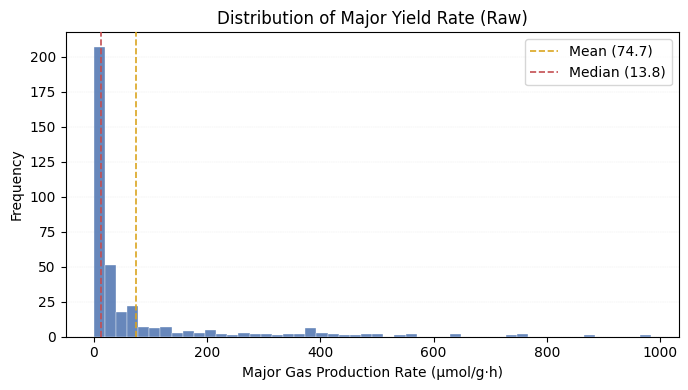

    Graph saved: fig2b_major_yield_log.png/.pdf
    Data saved: fig2b_major_yield_log


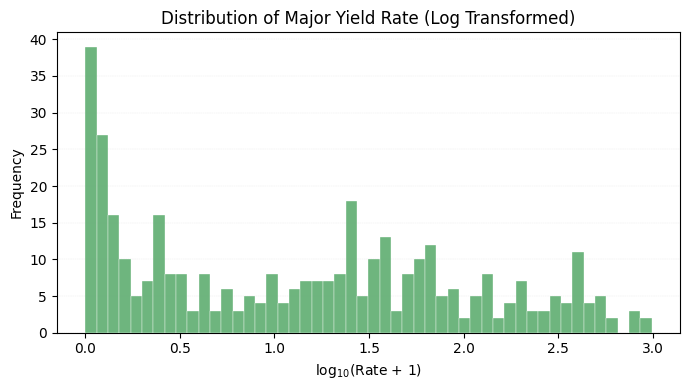

    Graph saved: fig2ab_yield_distributions_combined.png/.pdf


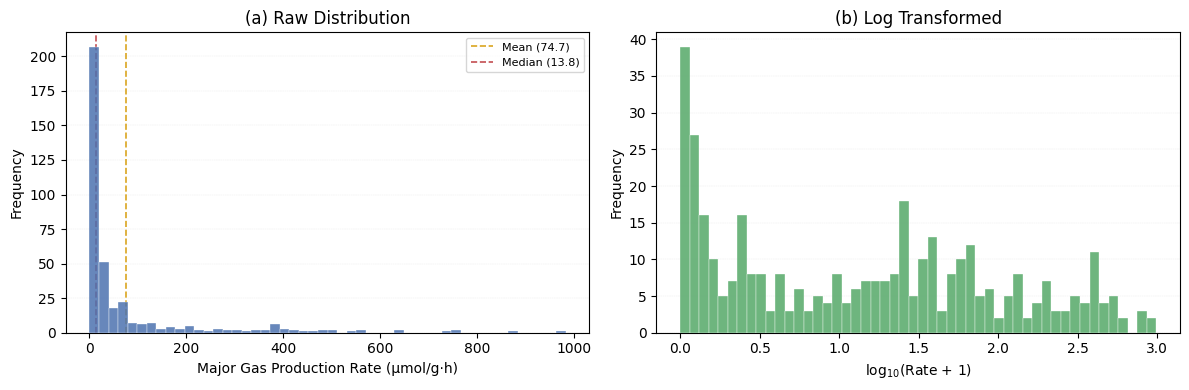


  Minor rate: 190 valid entries
    Mean:   28.1, Median: 1.8
    Graph saved: minor_yield_distributions.png/.pdf


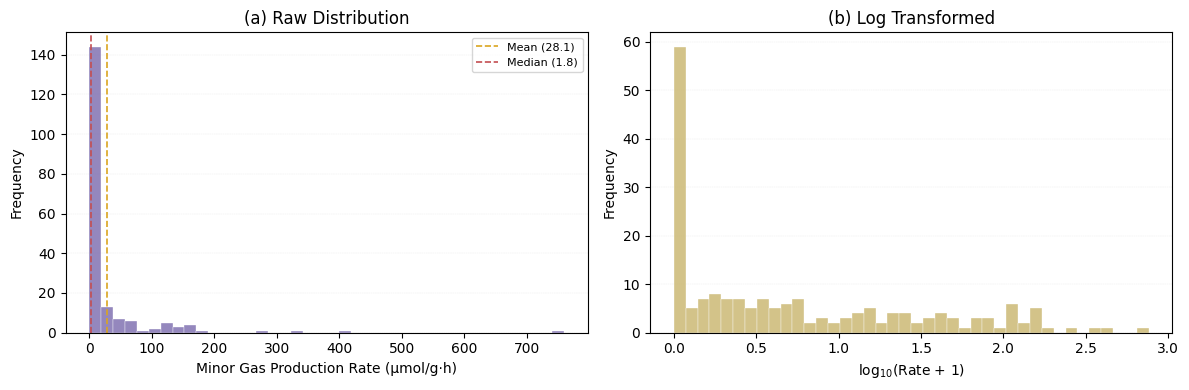


──────────────────────────────────────────────────────────────────────
PRODUCT CLASS DISTRIBUTIONS (Table IV)
──────────────────────────────────────────────────────────────────────
    Data saved: table_iv_class_distributions
 Product  Major_Count  Major_Pct  Minor_Count  Minor_Pct
   CH3OH          177       47.2           35        9.3
      CO           66       17.6           29        7.7
     CH4           62       16.5           52       13.9
      H2           31        8.3           18        4.8
    C2H4           13        3.5            2        0.5
   HCOOH           10        2.7           34        9.1
    HCHO            4        1.1            2        0.5
CH3CH2OH            4        1.1            9        2.4
  C2H5OH            4        1.1            6        1.6
 HCOOCH3            2        0.5            0        0.0
    C3H6            2        0.5            0        0.0
    C2H6            0        0.0            3        0.8
      NA            0        0.0

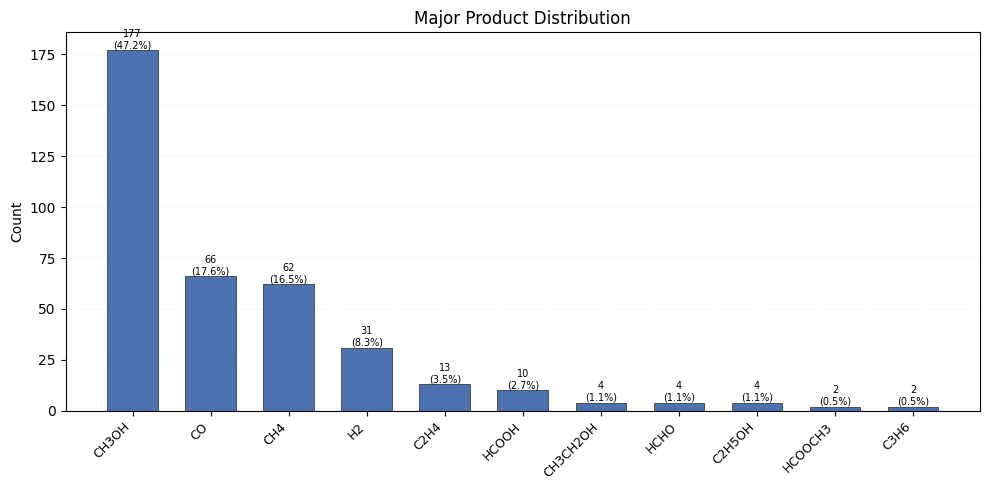

    Graph saved: minor_product_distribution.png/.pdf


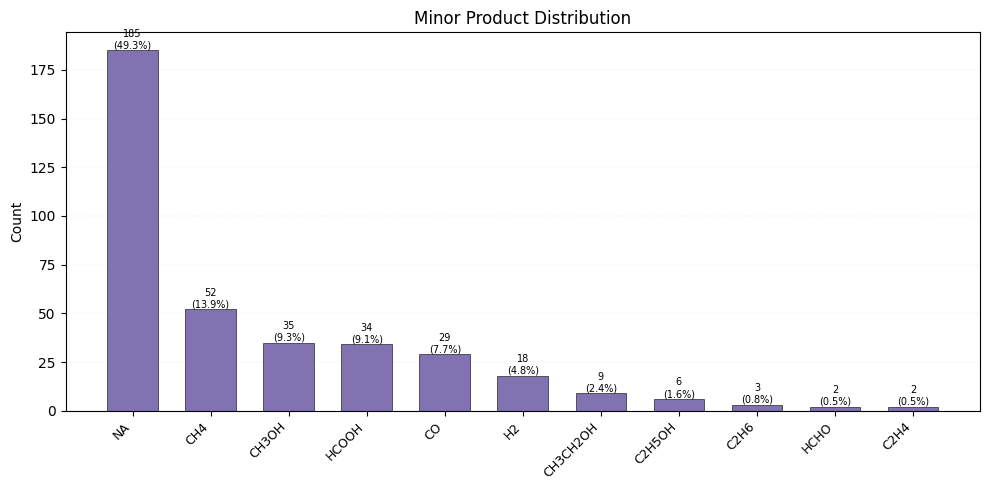

    Graph saved: product_distributions_combined.png/.pdf


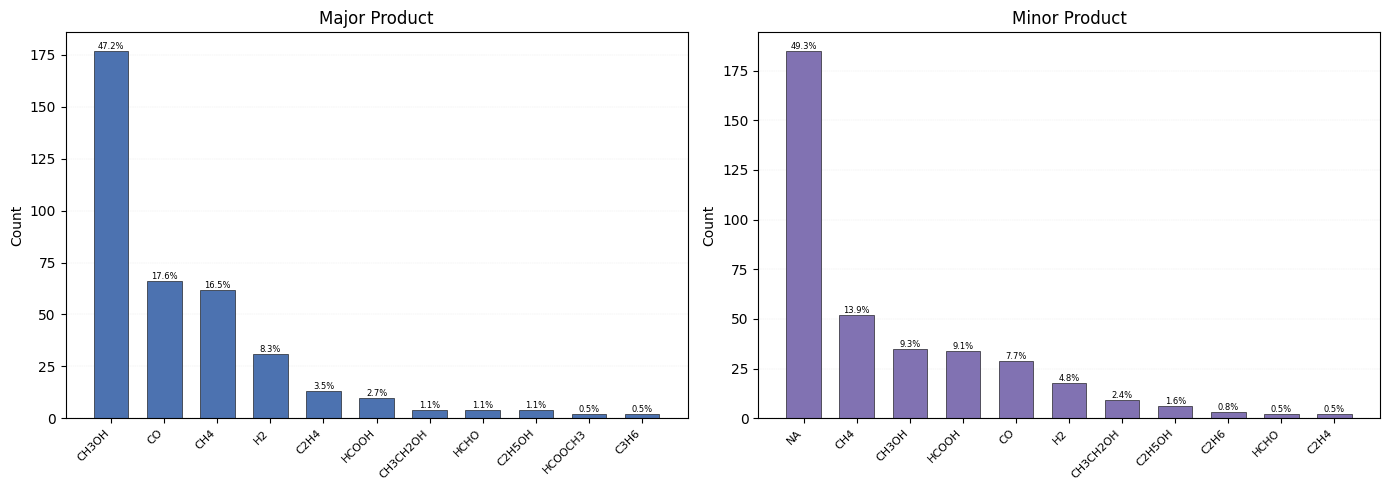


──────────────────────────────────────────────────────────────────────
MISSING VALUE ANALYSIS (Figure 2c)
──────────────────────────────────────────────────────────────────────
    Data saved: missing_value_summary
    Graph saved: fig2c_missing_values.png/.pdf
    Data saved: fig2c_missing_values


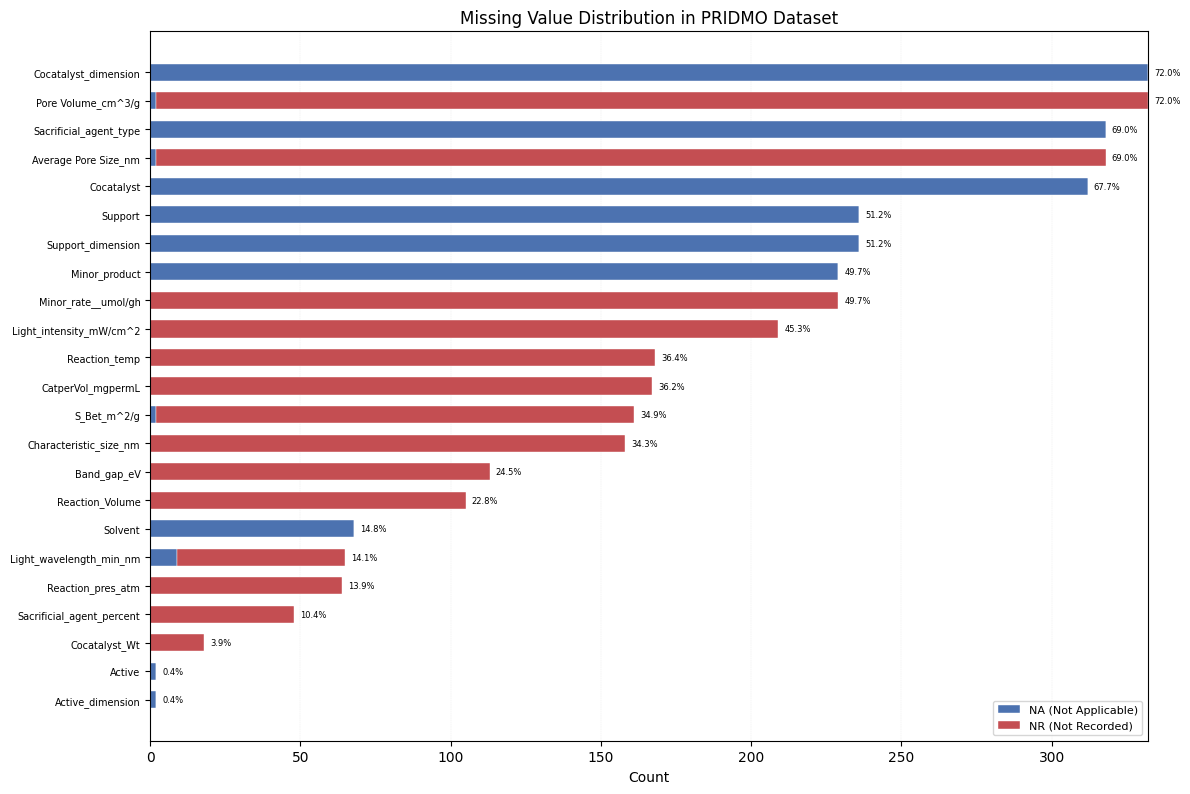


  Features with >30% missing:
    Cocatalyst_dimension            72.0% (NA: 332, NR: 0)
    Pore Volume_cm^3/g              72.0% (NA: 2, NR: 330)
    Sacrificial_agent_type          69.0% (NA: 318, NR: 0)
    Average Pore Size_nm            69.0% (NA: 2, NR: 316)
    Cocatalyst                      67.7% (NA: 312, NR: 0)
    Support                         51.2% (NA: 236, NR: 0)
    Support_dimension               51.2% (NA: 236, NR: 0)
    Minor_product                   49.7% (NA: 229, NR: 0)
    Minor_rate__umol/gh             49.7% (NA: 0, NR: 229)
    Light_intensity_mW/cm^2         45.3% (NA: 0, NR: 209)
    Reaction_temp                   36.4% (NA: 0, NR: 168)
    CatperVol_mgpermL               36.2% (NA: 0, NR: 167)
    S_Bet_m^2/g                     34.9% (NA: 2, NR: 159)
    Characteristic_size_nm          34.3% (NA: 0, NR: 158)

──────────────────────────────────────────────────────────────────────
HETEROJUNCTION ANALYSIS
───────────────────────────────────────────────

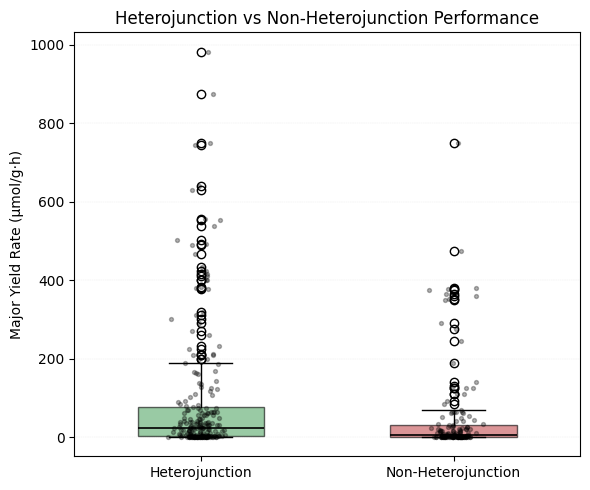

    Graph saved: heterojunction_mean_comparison.png/.pdf


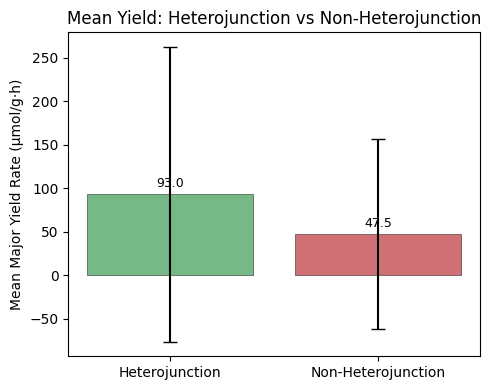


──────────────────────────────────────────────────────────────────────
BINARY FEATURE ANALYSIS
──────────────────────────────────────────────────────────────────────
    Data saved: binary_feature_yield_analysis
              Feature  Yes_Count  No_Count  Yes_Mean_Rate  No_Mean_Rate  Enhancement
    Is_heterojunction        224       151          93.02         47.47         1.96
Is_molecular_catalyst         13       362         122.81         72.95         1.68
  Noble_metal_present         85       290          85.34         71.55         1.19
          NH2_present         12       363         342.44         65.83         5.20

──────────────────────────────────────────────────────────────────────
TOP 10 PERFORMING CATALYSTS
──────────────────────────────────────────────────────────────────────
    Active Support Cocatalyst  Major_rate__umol/gh Major_product Is_heterojunction
      TiO2      NA         Ag                983.0            CO               Yes
    ZnV2O6    C3N4       

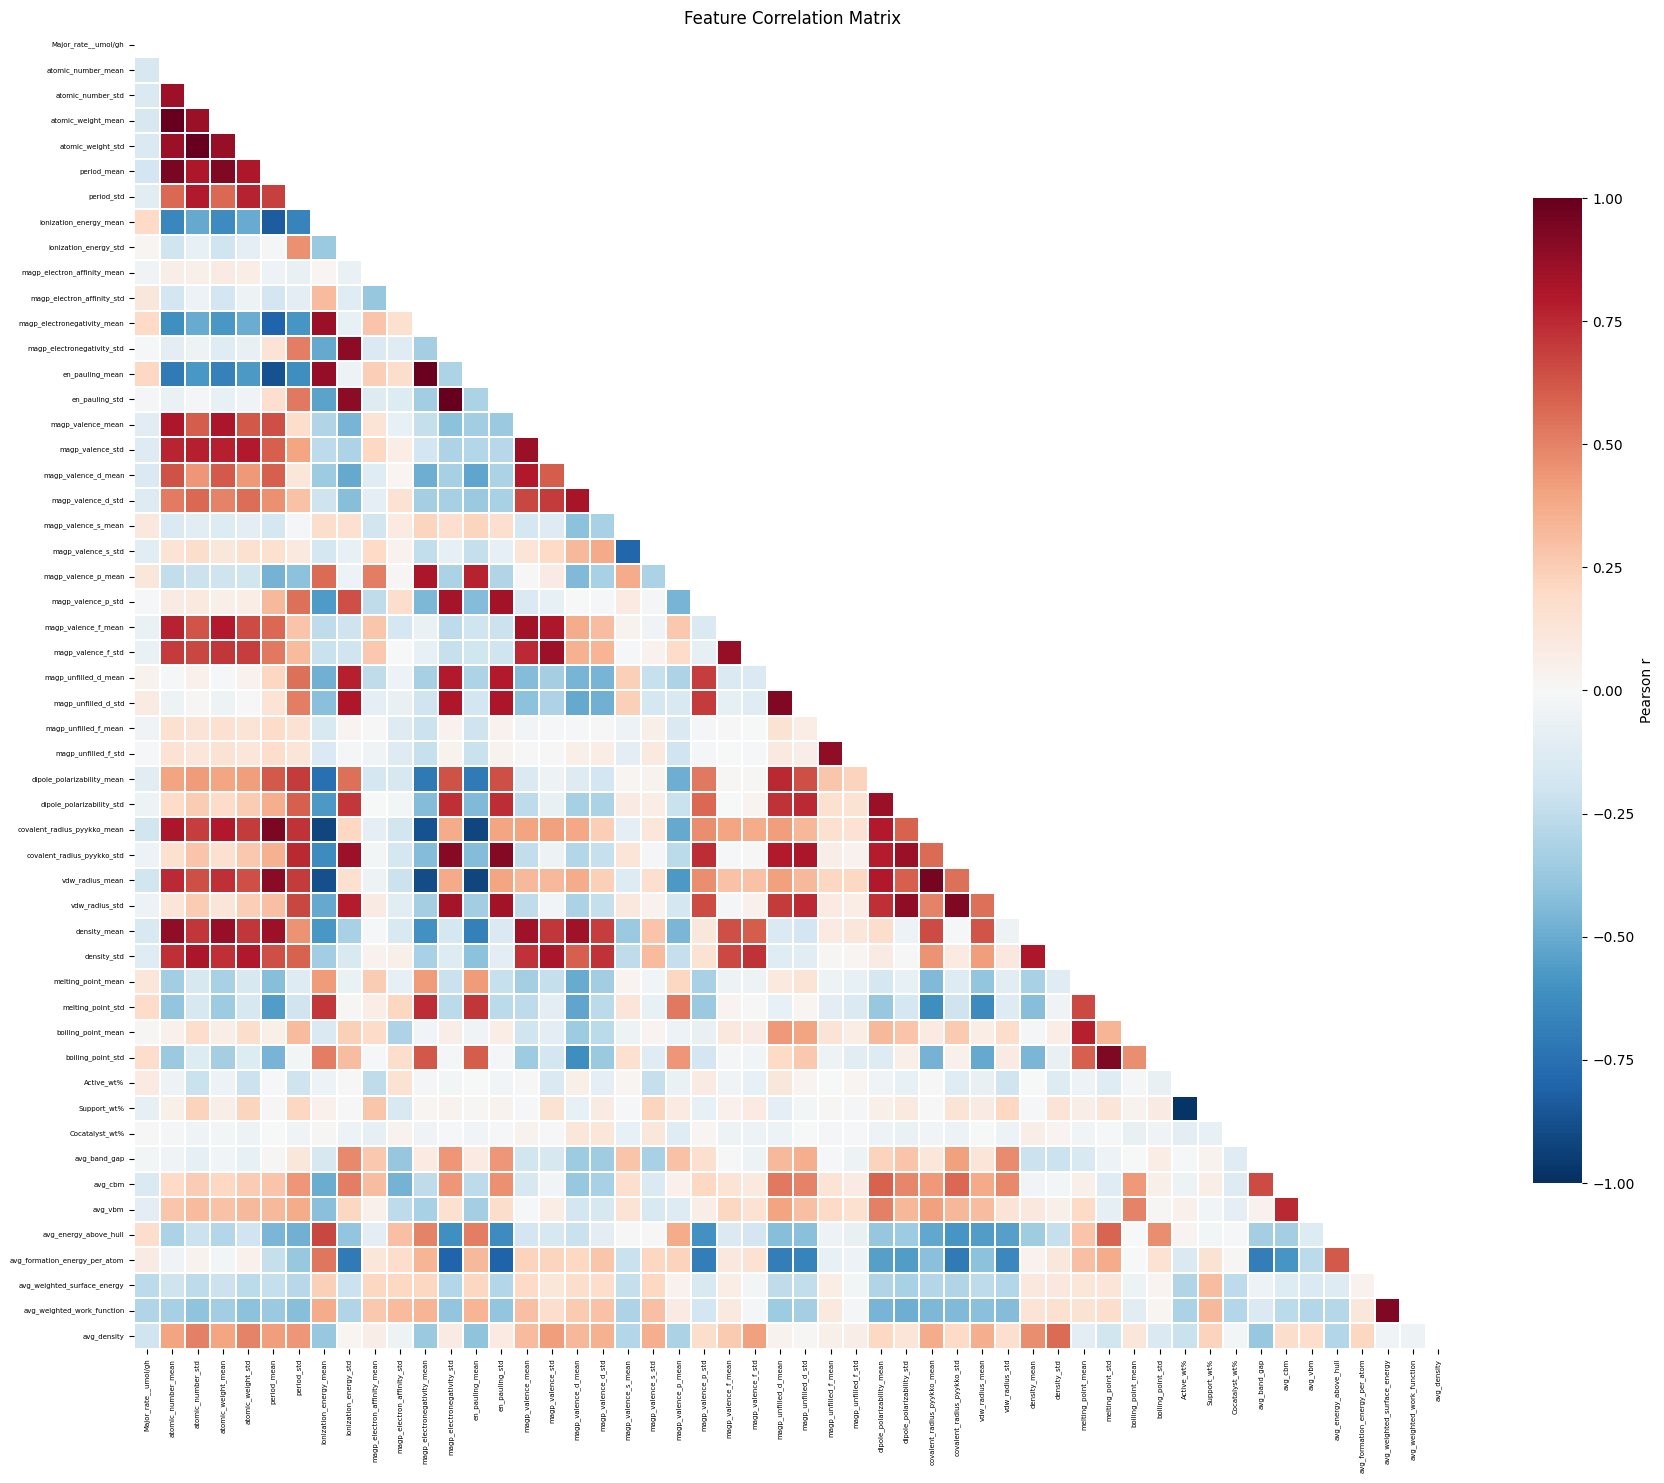


──────────────────────────────────────────────────────────────────────
NUMERICAL FEATURE DISTRIBUTIONS
──────────────────────────────────────────────────────────────────────
    Graph saved: numerical_feature_distributions.png/.pdf


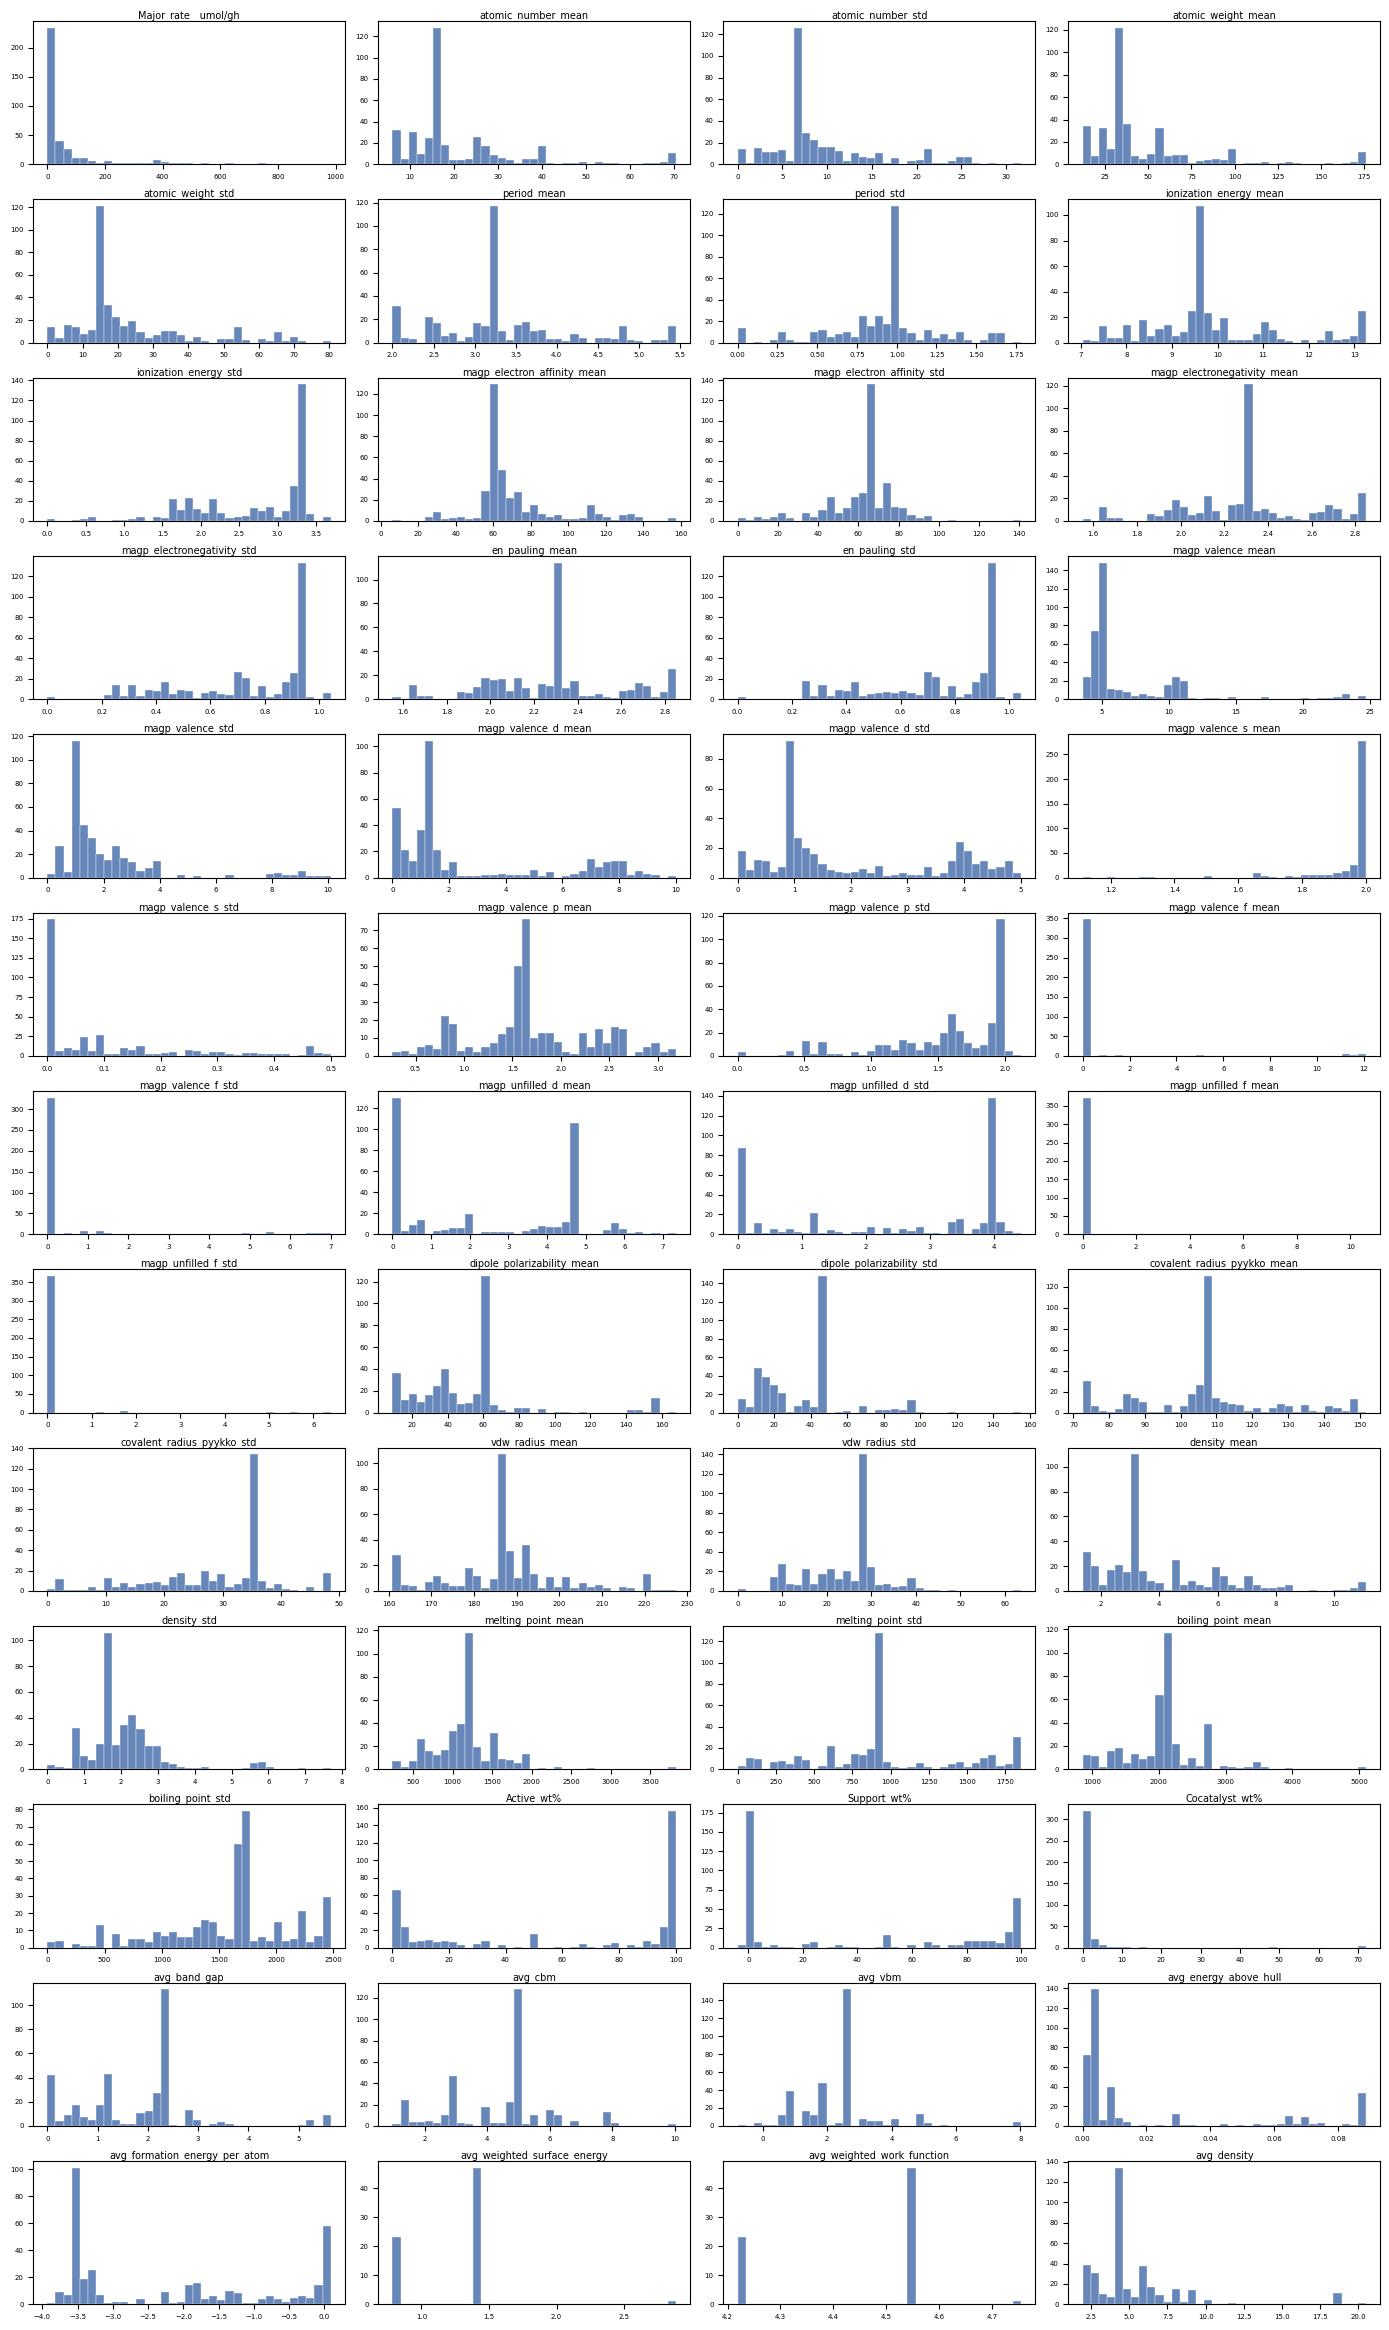

  Plotted 52 numerical features.

──────────────────────────────────────────────────────────────────────
CATEGORICAL FEATURE DISTRIBUTIONS
──────────────────────────────────────────────────────────────────────
    Graph saved: cat_dist_Active.png/.pdf


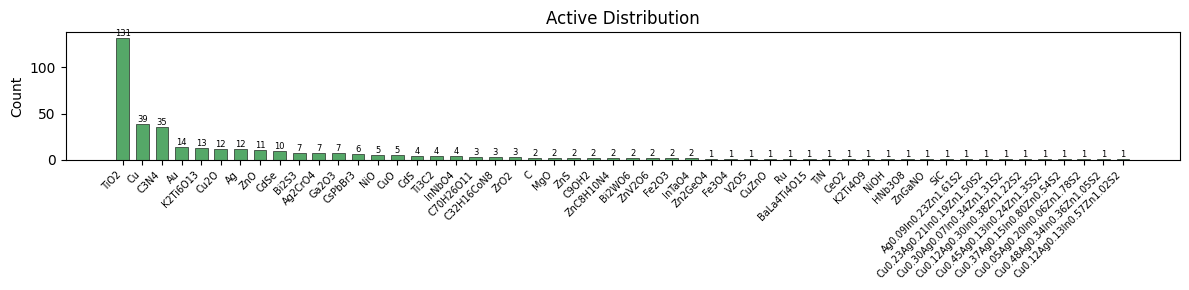

    Graph saved: cat_dist_Active_dimension.png/.pdf


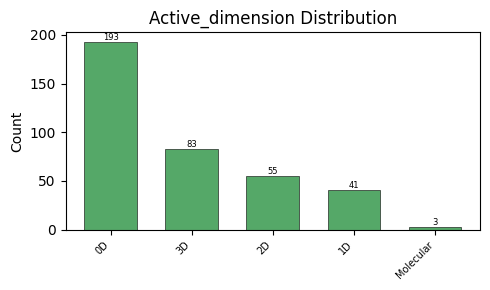

    Graph saved: cat_dist_Support.png/.pdf


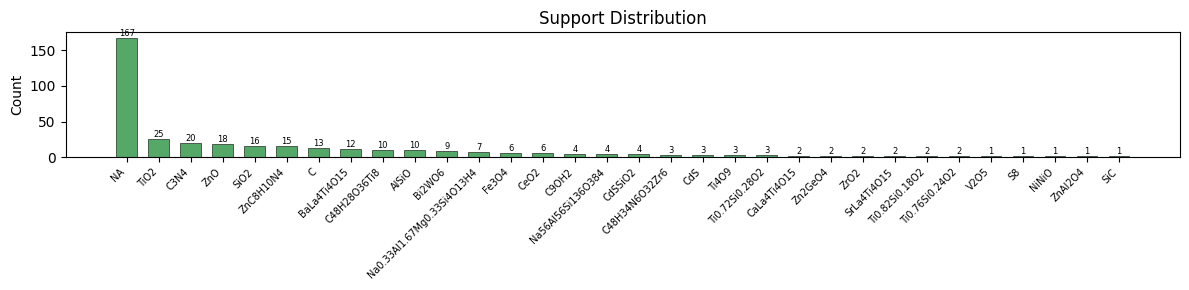

    Graph saved: cat_dist_Support_dimension.png/.pdf


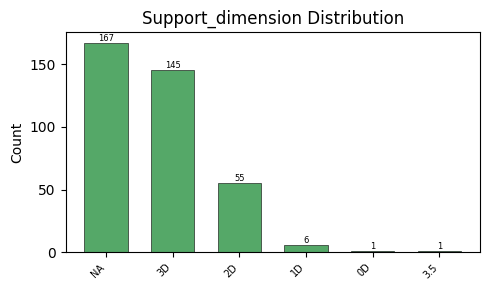

    Graph saved: cat_dist_Cocatalyst.png/.pdf


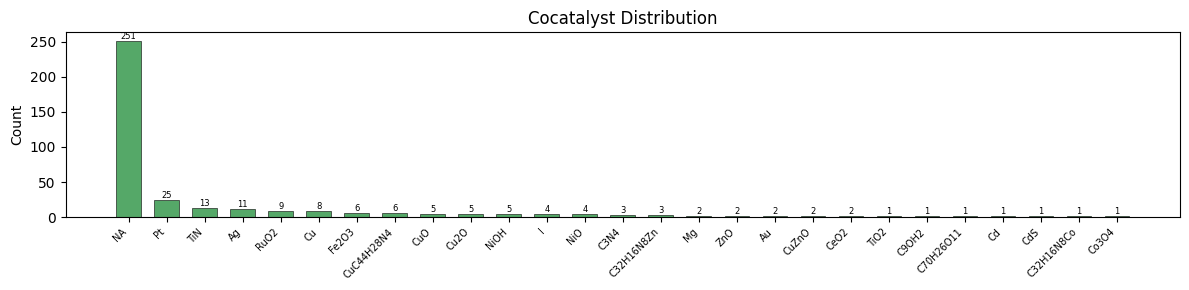

    Graph saved: cat_dist_Cocatalyst_Wt.png/.pdf


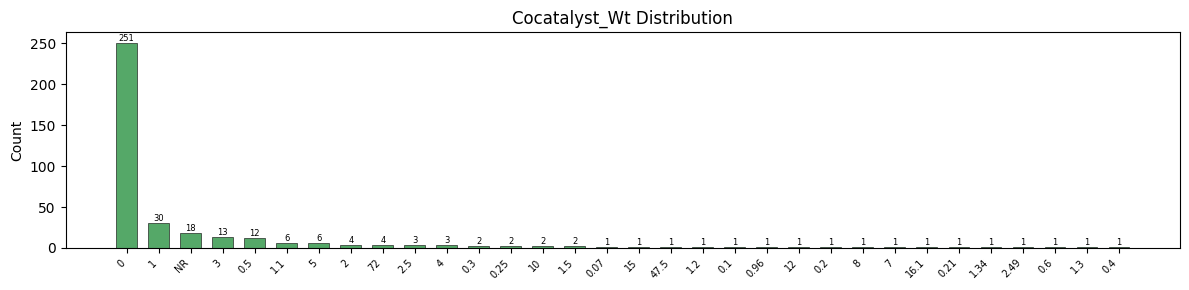

    Graph saved: cat_dist_Cocatalyst_dimension.png/.pdf


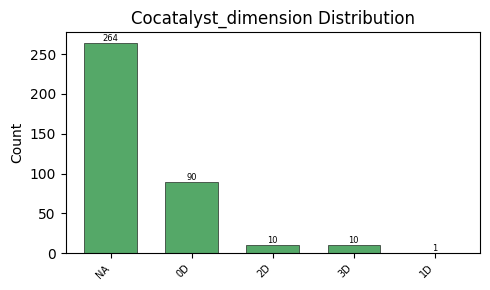

    Graph saved: cat_dist_Is_heterojunction.png/.pdf


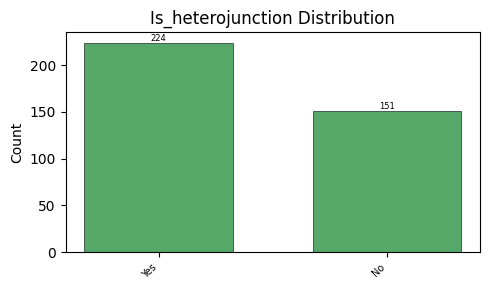

    Graph saved: cat_dist_Is_Zscheme.png/.pdf


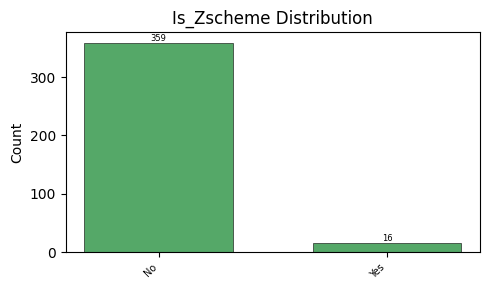

    Graph saved: cat_dist_Is_molecular_catalyst.png/.pdf


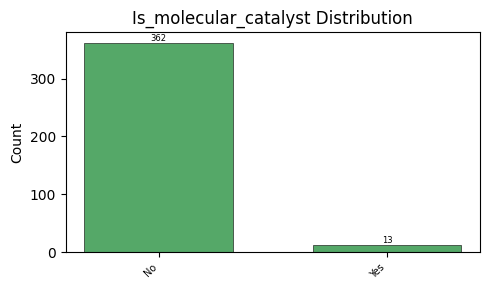

    Graph saved: cat_dist_Noble_metal_present.png/.pdf


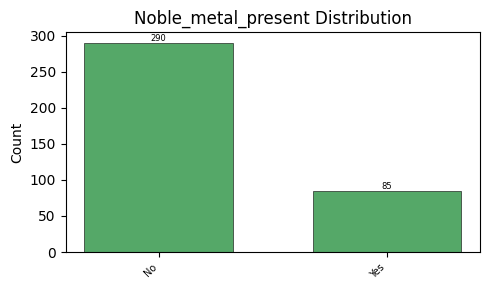

    Graph saved: cat_dist_Reaction_Phase.png/.pdf


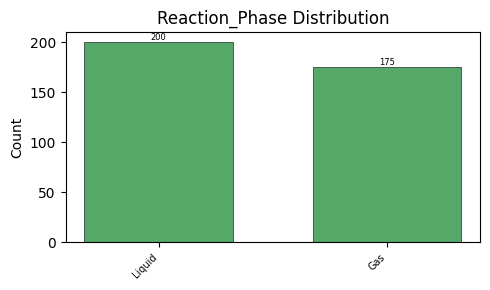

    Graph saved: cat_dist_Solvent.png/.pdf


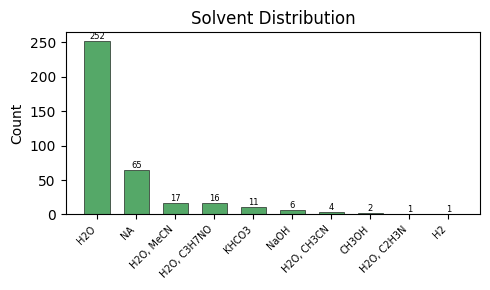

    Graph saved: cat_dist_NH2_present.png/.pdf


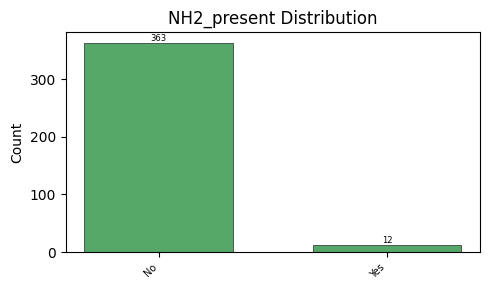

    Graph saved: cat_dist_Sacrificial_agent_percent.png/.pdf


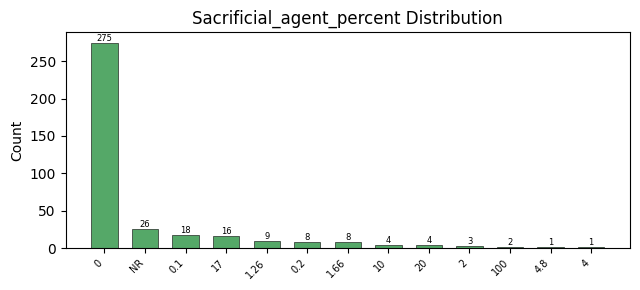

    Graph saved: cat_dist_Sacrificial_agent_type.png/.pdf


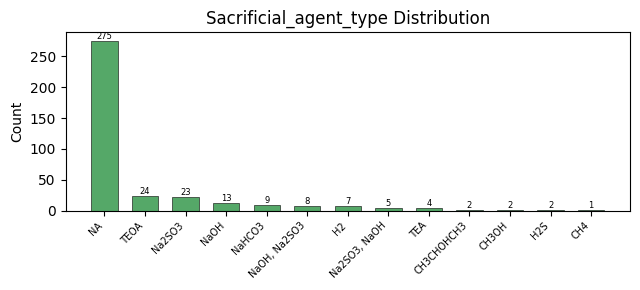

    Graph saved: cat_dist_Band_gap_eV.png/.pdf


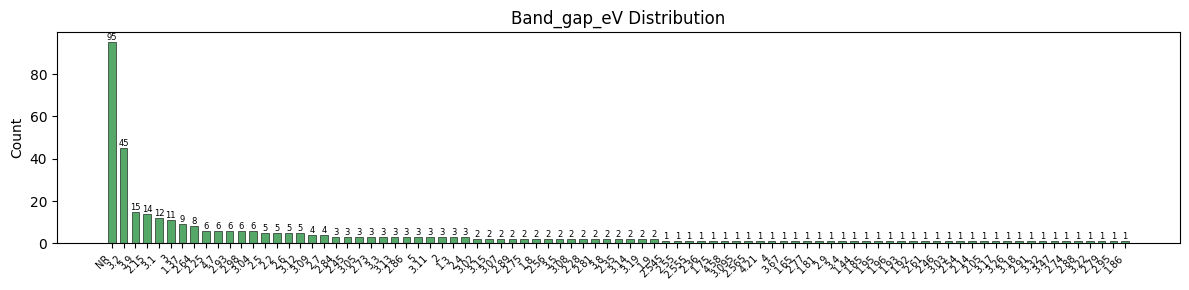

    Graph saved: cat_dist_S_Bet_m^2_g.png/.pdf


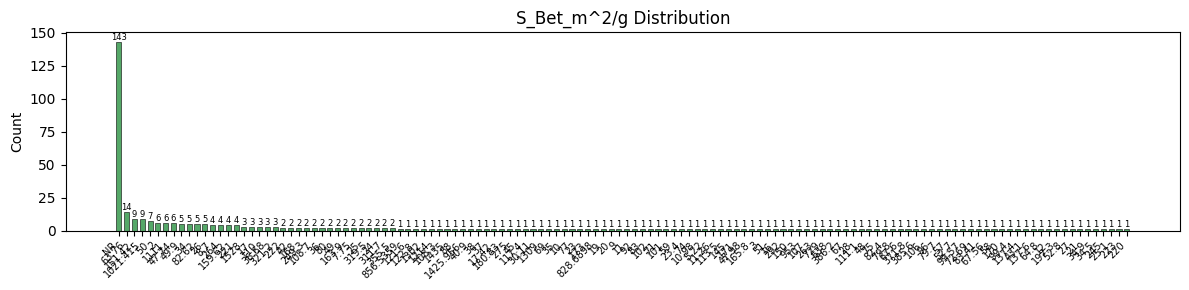

    Graph saved: cat_dist_Pore_Volume_cm^3_g.png/.pdf


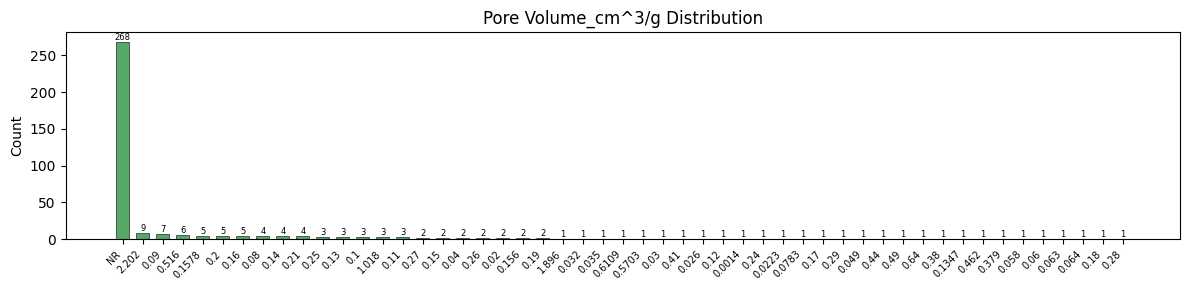

    Graph saved: cat_dist_Average_Pore_Size_nm.png/.pdf


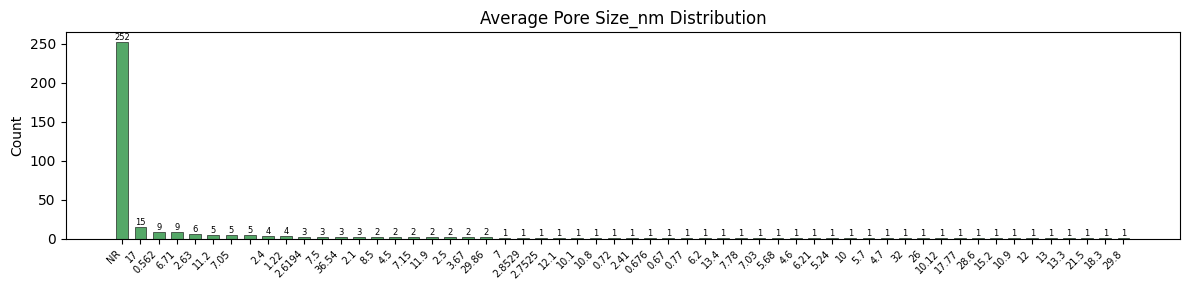

    Graph saved: cat_dist_Light_type.png/.pdf


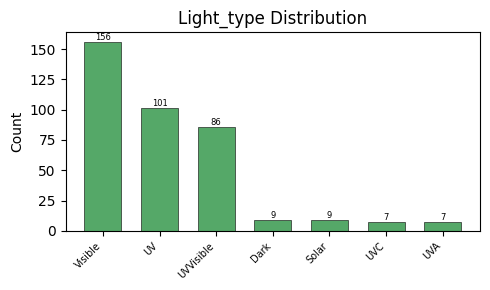

    Graph saved: cat_dist_Light_wavelength_min_nm.png/.pdf


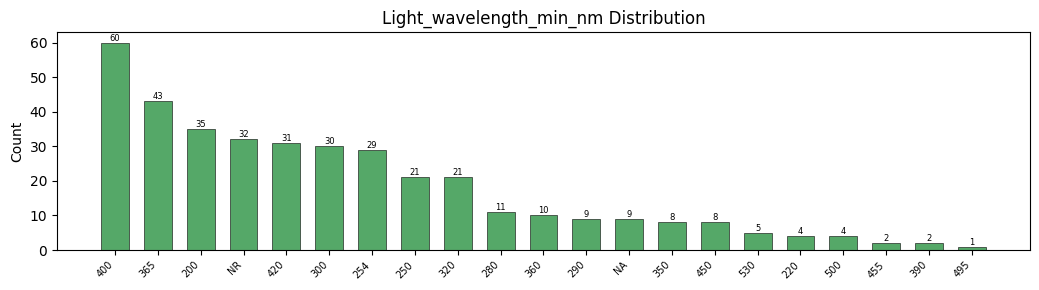

    Graph saved: cat_dist_Light_intensity_mW_cm^2.png/.pdf


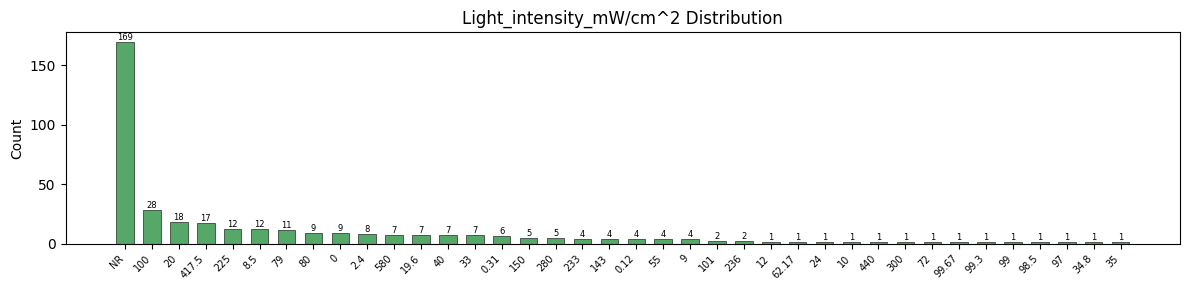

    Graph saved: cat_dist_Reaction_temp.png/.pdf


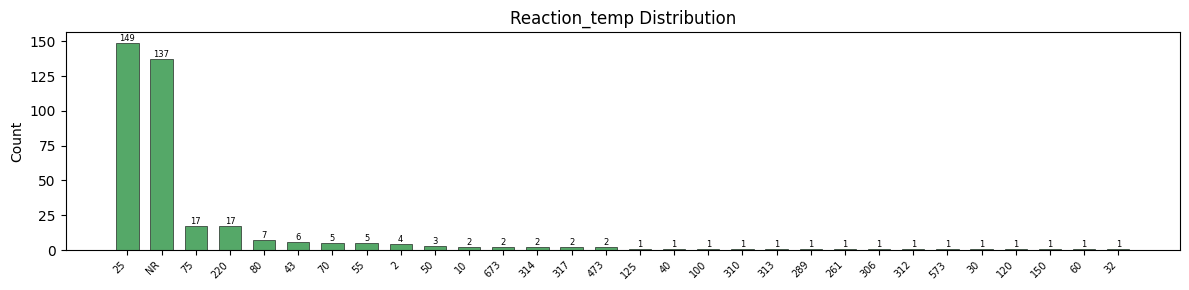

    Graph saved: cat_dist_Reaction_pres_atm.png/.pdf


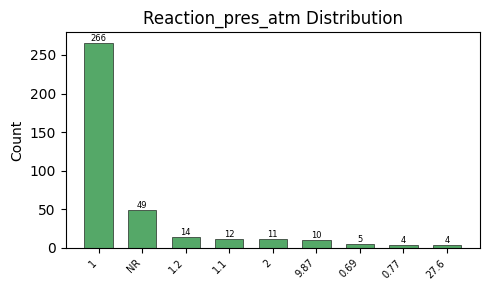

    Graph saved: cat_dist_Reaction_Volume.png/.pdf


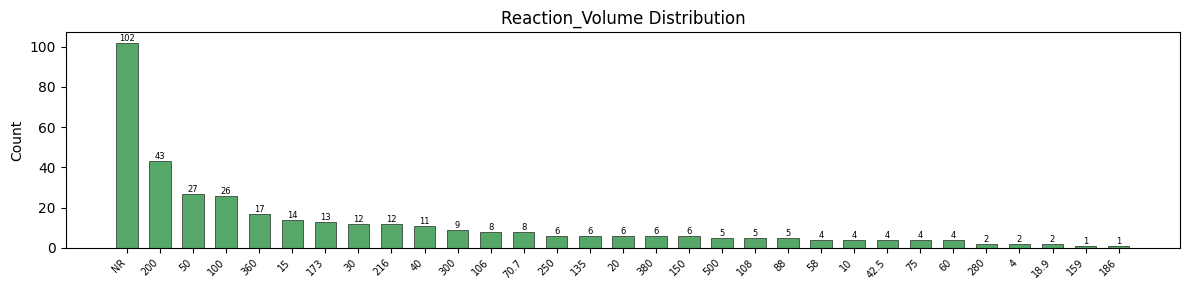

    Graph saved: cat_dist_CatperVol_mgpermL.png/.pdf


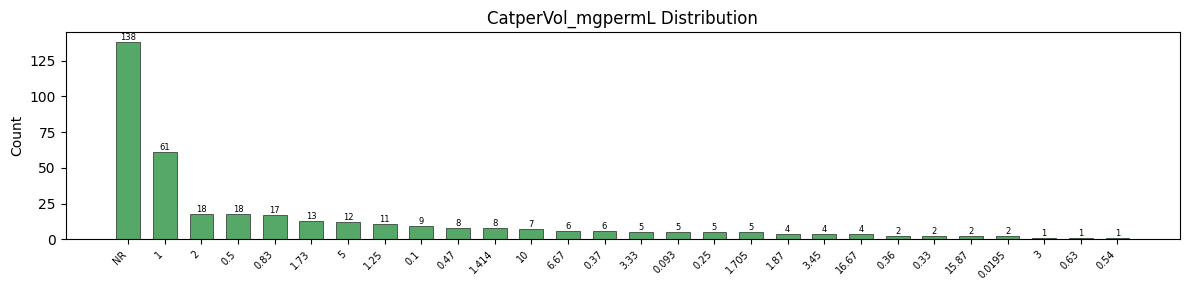

    Graph saved: cat_dist_Major_product.png/.pdf


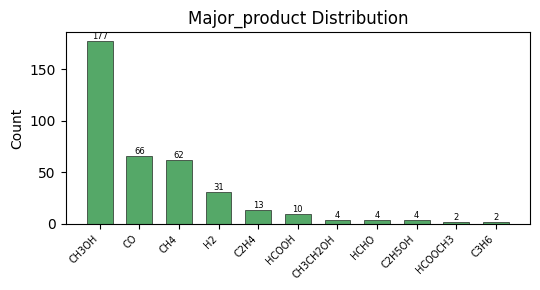

    Graph saved: cat_dist_Minor_rate__umol_gh.png/.pdf


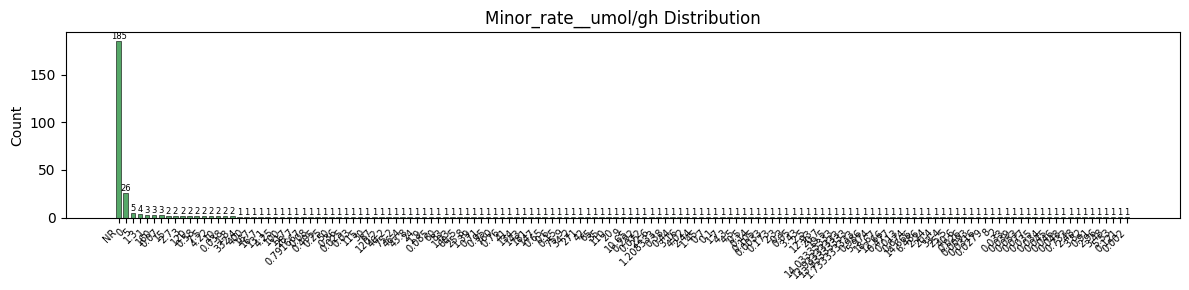

    Graph saved: cat_dist_Minor_product.png/.pdf


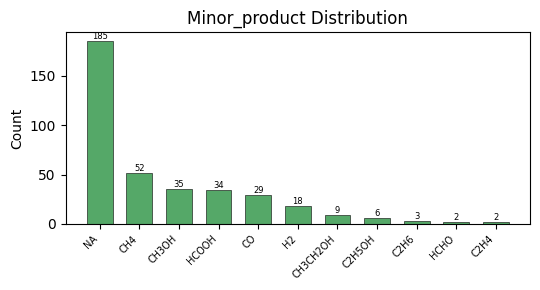

    Graph saved: cat_dist_Active_is_gap_direct.png/.pdf


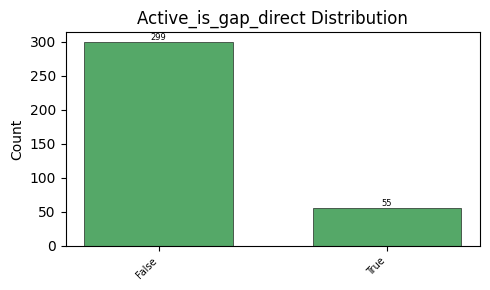

    Graph saved: cat_dist_Active_is_stable.png/.pdf


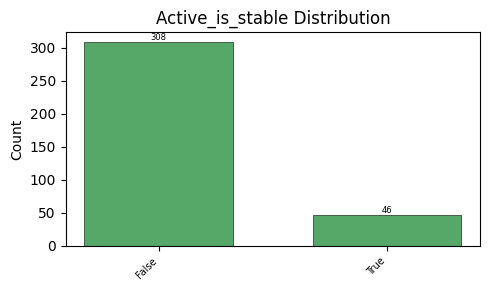

    Graph saved: cat_dist_Active_crystal_system.png/.pdf


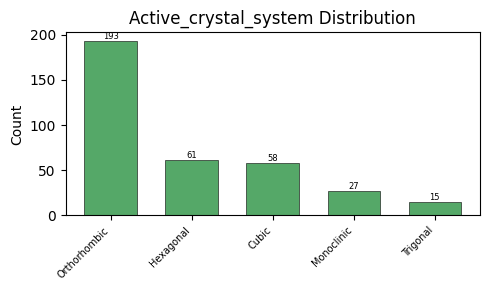

  Plotted 33 categorical features.

──────────────────────────────────────────────────────────────────────
QQ PLOTS (Normality check)
──────────────────────────────────────────────────────────────────────
    Graph saved: qq_plot_major_rate.png/.pdf


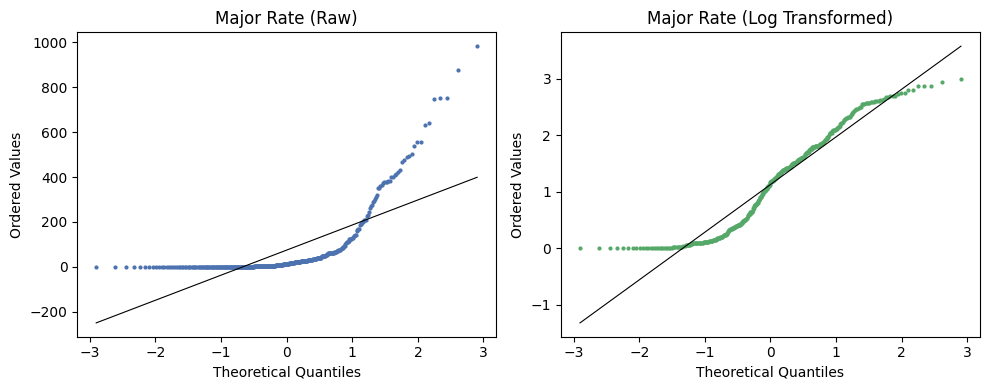

    Graph saved: qq_plot_minor_rate.png/.pdf


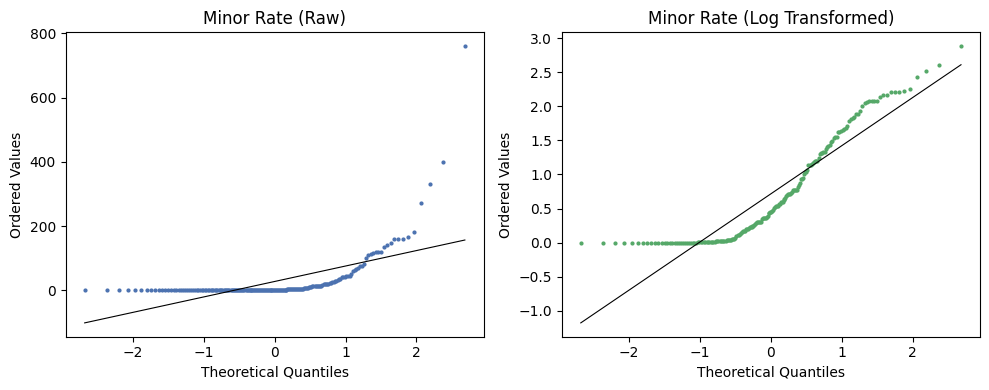


──────────────────────────────────────────────────────────────────────
DATASET SUMMARY
──────────────────────────────────────────────────────────────────────
    Data saved: dataset_summary
                        Metric            Value
                 Total entries              375
                Total features               88
                Source studies               56
            Numerical features               54
          Categorical features               34
    Major rate - valid entries              375
  Major rate - mean (umol/g*h)             74.7
Major rate - median (umol/g*h)             13.8
   Major rate - max (umol/g*h)            983.0
    Minor rate - valid entries              190
    Major products - n classes               11
    Minor products - n classes               11
       Minor data availability 375/375 (100.0%)

PRIDMO DATASET CHARACTERISATION COMPLETE

  Graphs saved to: /content/drive/MyDrive/Dissertation/Final Code/Results/PRIDMO Dataset Chara

In [ ]:
# ==============================================================================
# PRIDMO DATASET CHARACTERISATION
# Reproduces all figures and tables referenced in Section III-B1 of the report.
# Saves to Results/PRIDMO Dataset Characterisation/
# ==============================================================================

from scipy import stats

# --- Output directory (separate from the main Results folder) ---
CHAR_DIR = f'{RESULTS_DIR}/PRIDMO Dataset Characterisation'
CHAR_GRAPHS = f'{CHAR_DIR}/Graphs'
CHAR_DATA = f'{CHAR_DIR}/Data'
for d in [CHAR_GRAPHS, CHAR_DATA]:
    os.makedirs(d, exist_ok=True)

def save_char_graph(fig, filename):
    """Save figure to the characterisation graphs folder."""
    for ext in ['png', 'pdf']:
        fig.savefig(f'{CHAR_GRAPHS}/{filename}.{ext}', dpi=300, bbox_inches='tight')
    print(f"    Graph saved: {filename}.png/.pdf")

def save_char_data(data, filename):
    """Save CSV or array to the characterisation data folder."""
    if isinstance(data, pd.DataFrame):
        data.to_csv(f'{CHAR_DATA}/{filename}.csv', index=False)
    elif isinstance(data, np.ndarray):
        np.save(f'{CHAR_DATA}/{filename}.npy', data)
    print(f"    Data saved: {filename}")

df = merged_df.copy()

# ==============================================================================
# 1. BASIC SHAPE AND SUMMARY
# ==============================================================================

print(f"{'='*70}")
print("PRIDMO DATASET CHARACTERISATION")
print(f"{'='*70}")

print(f"\n  Observations: {df.shape[0]}")
print(f"  Columns:      {df.shape[1]}")

numerical_cols_char = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_char = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"  Numerical:    {len(numerical_cols_char)}")
print(f"  Categorical:  {len(categorical_cols_char)}")

# Column summary
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
})
save_char_data(col_summary.reset_index().rename(columns={'index': 'column'}),
               'column_summary')

# Descriptive statistics
desc = df[numerical_cols_char].describe().T
desc['skewness'] = df[numerical_cols_char].skew()
desc['kurtosis'] = df[numerical_cols_char].kurtosis()
desc['IQR'] = desc['75%'] - desc['25%']
save_char_data(desc.reset_index().rename(columns={'index': 'feature'}),
               'descriptive_statistics')

print(f"  Column summary and descriptive statistics saved.")

# ==============================================================================
# 2. TARGET DISTRIBUTIONS (Figures 2a, 2b from the report)
# ==============================================================================

print(f"\n{'─'*70}")
print("TARGET YIELD DISTRIBUTIONS")
print(f"{'─'*70}")

# Get the raw yield columns
major_rate_raw = pd.to_numeric(df['Major_rate__umol/gh'], errors='coerce')
minor_rate_raw = pd.to_numeric(df['Minor_rate__umol/gh'], errors='coerce')

# Stats for the report
valid_mj = major_rate_raw.dropna()
print(f"\n  Major rate: {len(valid_mj)} valid entries")
print(f"    Mean:   {valid_mj.mean():.1f} umol/g*h")
print(f"    Median: {valid_mj.median():.1f} umol/g*h")
print(f"    Std:    {valid_mj.std():.1f}")
print(f"    Max:    {valid_mj.max():.1f} umol/g*h")
print(f"    Min:    {valid_mj.min():.1f} umol/g*h")

# --- Figure 2a: Major yield before log transform ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(valid_mj, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.3,
        alpha=0.85, zorder=3)
ax.axvline(valid_mj.mean(), color='#DAA520', linestyle='--', linewidth=1.2,
           label=f'Mean ({valid_mj.mean():.1f})', zorder=4)
ax.axvline(valid_mj.median(), color='#C44E52', linestyle='--', linewidth=1.2,
           label=f'Median ({valid_mj.median():.1f})', zorder=4)
ax.set_xlabel('Major Gas Production Rate (µmol/g·h)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Major Yield Rate (Raw)')
ax.legend()
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'fig2a_major_yield_raw')
save_char_data(pd.DataFrame({'major_rate': valid_mj.values}),
               'fig2a_major_yield_raw')
plt.show()
plt.close('all')

# --- Figure 2b: Major yield after log10(x+1) transform ---
major_rate_log = np.log10(valid_mj + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(major_rate_log, bins=50, color='#55A868', edgecolor='white',
        linewidth=0.3, alpha=0.85, zorder=3)
ax.set_xlabel('log$_{10}$(Rate + 1)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Major Yield Rate (Log Transformed)')
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'fig2b_major_yield_log')
save_char_data(pd.DataFrame({'major_rate_log': major_rate_log.values}),
               'fig2b_major_yield_log')
plt.show()
plt.close('all')

# --- Side-by-side version (as it appears in the report: Fig 2a + 2b) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(valid_mj, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.3,
        alpha=0.85, zorder=3)
ax.axvline(valid_mj.mean(), color='#DAA520', linestyle='--', linewidth=1.2,
           label=f'Mean ({valid_mj.mean():.1f})')
ax.axvline(valid_mj.median(), color='#C44E52', linestyle='--', linewidth=1.2,
           label=f'Median ({valid_mj.median():.1f})')
ax.set_xlabel('Major Gas Production Rate (µmol/g·h)')
ax.set_ylabel('Frequency')
ax.set_title('(a) Raw Distribution')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(major_rate_log, bins=50, color='#55A868', edgecolor='white',
        linewidth=0.3, alpha=0.85, zorder=3)
ax.set_xlabel('log$_{10}$(Rate + 1)')
ax.set_ylabel('Frequency')
ax.set_title('(b) Log Transformed')

for a in axes:
    a.set_axisbelow(True)
    a.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'fig2ab_yield_distributions_combined')
plt.show()
plt.close('all')

# --- Minor yield distribution (for completeness) ---
valid_mi = minor_rate_raw.dropna()
if len(valid_mi) > 0:
    print(f"\n  Minor rate: {len(valid_mi)} valid entries")
    print(f"    Mean:   {valid_mi.mean():.1f}, Median: {valid_mi.median():.1f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(valid_mi, bins=40, color='#8172B2', edgecolor='white',
                 linewidth=0.3, alpha=0.85)
    axes[0].axvline(valid_mi.mean(), color='#DAA520', linestyle='--', linewidth=1.2,
                    label=f'Mean ({valid_mi.mean():.1f})')
    axes[0].axvline(valid_mi.median(), color='#C44E52', linestyle='--', linewidth=1.2,
                    label=f'Median ({valid_mi.median():.1f})')
    axes[0].set_xlabel('Minor Gas Production Rate (µmol/g·h)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('(a) Raw Distribution')
    axes[0].legend(fontsize=8)

    minor_rate_log = np.log10(valid_mi + 1)
    axes[1].hist(minor_rate_log, bins=40, color='#CCB974', edgecolor='white',
                 linewidth=0.3, alpha=0.85)
    axes[1].set_xlabel('log$_{10}$(Rate + 1)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('(b) Log Transformed')

    for a in axes:
        a.set_axisbelow(True)
        a.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
    fig.tight_layout()
    save_char_graph(fig, 'minor_yield_distributions')
    plt.show()
    plt.close('all')

# ==============================================================================
# 3. PRODUCT CLASS DISTRIBUTIONS (Table IV from the report)
# ==============================================================================

print(f"\n{'─'*70}")
print("PRODUCT CLASS DISTRIBUTIONS (Table IV)")
print(f"{'─'*70}")

major_products = df['Major_product'].dropna().astype(str)
minor_products = df['Minor_product'].dropna().astype(str)
# Filter out anything that looks like a missing placeholder
major_products = major_products[~major_products.isin(['nan', 'NR', ''])]
minor_products = minor_products[~minor_products.isin(['nan', 'NR', ''])]

mj_counts = major_products.value_counts()
mi_counts = minor_products.value_counts()

# Build Table IV
all_products = sorted(set(mj_counts.index) | set(mi_counts.index))
table_iv_rows = []
for prod in all_products:
    mj_n = mj_counts.get(prod, 0)
    mi_n = mi_counts.get(prod, 0)
    table_iv_rows.append({
        'Product': prod,
        'Major_Count': mj_n,
        'Major_Pct': round(mj_n / mj_counts.sum() * 100, 1) if mj_counts.sum() > 0 else 0,
        'Minor_Count': mi_n,
        'Minor_Pct': round(mi_n / mi_counts.sum() * 100, 1) if mi_counts.sum() > 0 else 0,
    })

table_iv = pd.DataFrame(table_iv_rows).sort_values('Major_Count', ascending=False)
table_iv.loc[len(table_iv)] = ['Total', mj_counts.sum(), 100.0, mi_counts.sum(), 100.0]
save_char_data(table_iv, 'table_iv_class_distributions')

print(table_iv.to_string(index=False))
print(f"\n  Class imbalance (major): {mj_counts.max()}x / {mj_counts.min()}x "
      f"= {mj_counts.max()/max(mj_counts.min(),1):.0f}x")

# --- Major product bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
colours_mj = ['#4C72B0'] * len(mj_counts)
bars = ax.bar(range(len(mj_counts)), mj_counts.values, color=colours_mj,
              edgecolor='black', linewidth=0.4, width=0.65)
ax.set_xticks(range(len(mj_counts)))
ax.set_xticklabels(mj_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Major Product Distribution')
for b in bars:
    pct = b.get_height() / mj_counts.sum() * 100
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f'{int(b.get_height())}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=7)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'major_product_distribution')
plt.show()
plt.close('all')

# --- Minor product bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(mi_counts)), mi_counts.values, color='#8172B2',
              edgecolor='black', linewidth=0.4, width=0.65)
ax.set_xticks(range(len(mi_counts)))
ax.set_xticklabels(mi_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Minor Product Distribution')
for b in bars:
    pct = b.get_height() / mi_counts.sum() * 100
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f'{int(b.get_height())}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=7)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'minor_product_distribution')
plt.show()
plt.close('all')

# --- Side-by-side product distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, counts, title, colour in [
    (axes[0], mj_counts, 'Major Product', '#4C72B0'),
    (axes[1], mi_counts, 'Minor Product', '#8172B2')
]:
    bars = ax.bar(range(len(counts)), counts.values, color=colour,
                  edgecolor='black', linewidth=0.4, width=0.65)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    ax.set_title(title)
    for b in bars:
        pct = b.get_height() / counts.sum() * 100
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=6)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
fig.tight_layout()
save_char_graph(fig, 'product_distributions_combined')
plt.show()
plt.close('all')

# ==============================================================================
# 4. MISSING VALUE DISTRIBUTION (Figure 2c from the report)
# ==============================================================================

print(f"\n{'─'*70}")
print("MISSING VALUE ANALYSIS (Figure 2c)")
print(f"{'─'*70}")

# We need to go back to the raw PRIDMO data to distinguish NR from NA,
# since merged_df has already been preprocessed. Use df_pridmo_raw.

raw = df_pridmo_raw.copy()

# Columns of interest (the tabular features, not targets or IDs)
exclude_for_missing = ['Number', 'No', 'Exp', 'Description']
feature_cols_raw = [c for c in raw.columns if c not in exclude_for_missing]

missing_summary = []
for col in feature_cols_raw:
    col_str = raw[col].astype(str).str.strip()

    # NA = structurally not applicable (e.g. no cocatalyst)
    n_na = col_str.isin(['NA', 'na', 'N/A']).sum()
    # NR = not recorded (genuine missing data)
    n_nr = col_str.isin(['NR', 'nr', '']).sum() + raw[col].isna().sum()
    # Subtract any overlap (pandas NaN already counted in isna)
    n_nr = n_nr - col_str.isin(['nan']).sum()  # don't double count
    n_valid = len(raw) - n_na - n_nr

    missing_summary.append({
        'Feature': col,
        'Valid': max(n_valid, 0),
        'NA (Not Applicable)': n_na,
        'NR (Not Recorded)': max(n_nr, 0),
        'Total Missing': n_na + max(n_nr, 0),
        'Pct Missing': round((n_na + max(n_nr, 0)) / len(raw) * 100, 1)
    })

missing_df = pd.DataFrame(missing_summary).sort_values(
    'Total Missing', ascending=False)
save_char_data(missing_df, 'missing_value_summary')

# Only plot features that have some missing data
missing_plot = missing_df[missing_df['Total Missing'] > 0].copy()
if len(missing_plot) > 0:
    fig, ax = plt.subplots(figsize=(12, max(5, len(missing_plot) * 0.35)))

    y_pos = range(len(missing_plot))
    # Stacked horizontal bars: NA in one colour, NR in another
    bars_na = ax.barh(y_pos, missing_plot['NA (Not Applicable)'].values,
                      color='#4C72B0', edgecolor='white', linewidth=0.3,
                      label='NA (Not Applicable)', height=0.6)
    bars_nr = ax.barh(y_pos, missing_plot['NR (Not Recorded)'].values,
                      left=missing_plot['NA (Not Applicable)'].values,
                      color='#C44E52', edgecolor='white', linewidth=0.3,
                      label='NR (Not Recorded)', height=0.6)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(missing_plot['Feature'].values, fontsize=7)
    ax.set_xlabel('Count')
    ax.set_title('Missing Value Distribution in PRIDMO Dataset')
    ax.legend(loc='lower right', fontsize=8)
    ax.invert_yaxis()
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')

    # Percentage labels at the end of each bar
    for i, (_, row) in enumerate(missing_plot.iterrows()):
        total = row['Total Missing']
        if total > 0:
            ax.text(total + 2, i, f"{row['Pct Missing']}%",
                    va='center', fontsize=6)

    fig.tight_layout()
    save_char_graph(fig, 'fig2c_missing_values')
    save_char_data(missing_plot, 'fig2c_missing_values')
    plt.show()
    plt.close('all')

    # Print the worst offenders
    print(f"\n  Features with >30% missing:")
    high_missing = missing_plot[missing_plot['Pct Missing'] > 30]
    for _, row in high_missing.iterrows():
        print(f"    {row['Feature']:30s} {row['Pct Missing']:5.1f}% "
              f"(NA: {row['NA (Not Applicable)']}, NR: {row['NR (Not Recorded)']})")

# ==============================================================================
# 5. HETEROJUNCTION ANALYSIS (mentioned in Section III-B1)
# ==============================================================================

print(f"\n{'─'*70}")
print("HETEROJUNCTION ANALYSIS")
print(f"{'─'*70}")

if 'Is_Heterojunction' in df.columns:
    het_col = 'Is_Heterojunction'
elif 'Heterojunction' in df.columns:
    het_col = 'Heterojunction'
else:
    # Search for any column that might contain heterojunction info
    het_candidates = [c for c in df.columns if 'eterojunction' in c.lower()]
    het_col = het_candidates[0] if het_candidates else None

if het_col is not None:
    het_data = df[[het_col, 'Major_rate__umol/gh']].copy()
    het_data['rate'] = pd.to_numeric(het_data['Major_rate__umol/gh'], errors='coerce')
    het_data = het_data.dropna(subset=['rate'])
    het_data[het_col] = het_data[het_col].astype(str).str.strip()

    # Map to Yes/No if needed
    yes_vals = ['Yes', 'yes', '1', '1.0', 'True', 'true']
    no_vals = ['No', 'no', '0', '0.0', 'False', 'false']
    het_data['is_het'] = het_data[het_col].apply(
        lambda x: 'Heterojunction' if x in yes_vals
        else ('Non-Heterojunction' if x in no_vals else 'Unknown'))
    het_data = het_data[het_data['is_het'] != 'Unknown']

    het_stats = het_data.groupby('is_het')['rate'].agg(['mean', 'median', 'std', 'count'])
    print(f"\n  Heterojunction yield comparison:")
    print(het_stats.to_string())

    het_pct = het_data[het_data['is_het'] == 'Heterojunction'].shape[0] / len(het_data) * 100
    print(f"\n  Heterojunction fraction: {het_pct:.1f}%")

    if 'Heterojunction' in het_stats.index and 'Non-Heterojunction' in het_stats.index:
        ratio = het_stats.loc['Heterojunction', 'mean'] / het_stats.loc['Non-Heterojunction', 'mean']
        print(f"  Mean yield ratio: {ratio:.1f}x enhancement")

    # Box + strip plot
    fig, ax = plt.subplots(figsize=(6, 5))
    groups = ['Heterojunction', 'Non-Heterojunction']
    group_data = [het_data[het_data['is_het'] == g]['rate'].values for g in groups
                  if g in het_data['is_het'].values]
    group_labels = [g for g in groups if g in het_data['is_het'].values]

    bp = ax.boxplot(group_data, labels=group_labels, patch_artist=True,
                    widths=0.5, notch=False,
                    medianprops=dict(color='black', linewidth=1.2))

    colours_het = ['#55A868', '#C44E52']
    for patch, colour in zip(bp['boxes'], colours_het[:len(group_data)]):
        patch.set_facecolor(colour)
        patch.set_alpha(0.6)

    for i, data_arr in enumerate(group_data):
        jitter = np.random.normal(0, 0.04, len(data_arr))
        ax.scatter(np.full_like(data_arr, i + 1) + jitter, data_arr,
                   s=8, alpha=0.3, color='black', zorder=3)

    ax.set_ylabel('Major Yield Rate (µmol/g·h)')
    ax.set_title('Heterojunction vs Non-Heterojunction Performance')
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')
    fig.tight_layout()
    save_char_graph(fig, 'heterojunction_comparison')
    save_char_data(het_stats.reset_index(), 'heterojunction_comparison')
    plt.show()
    plt.close('all')

    # Bar chart of mean yields
    fig, ax = plt.subplots(figsize=(5, 4))
    means = [het_stats.loc[g, 'mean'] for g in group_labels if g in het_stats.index]
    stds = [het_stats.loc[g, 'std'] for g in group_labels if g in het_stats.index]
    bars = ax.bar(group_labels, means, yerr=stds, color=colours_het[:len(means)],
                  edgecolor='black', linewidth=0.4, capsize=5, alpha=0.8)
    for b, m in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
                f'{m:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Mean Major Yield Rate (µmol/g·h)')
    ax.set_title('Mean Yield: Heterojunction vs Non-Heterojunction')
    fig.tight_layout()
    save_char_graph(fig, 'heterojunction_mean_comparison')
    plt.show()
    plt.close('all')
else:
    print("  Heterojunction column not found in merged_df. Skipping.")

# ==============================================================================
# 6. BINARY FEATURE ANALYSIS (Z-Scheme, NH2, Noble Metal, etc.)
# ==============================================================================

print(f"\n{'─'*70}")
print("BINARY FEATURE ANALYSIS")
print(f"{'─'*70}")

binary_candidates = ['Is_Heterojunction', 'Is_Z_Scheme', 'Is_Molecular_Catalyst',
                     'Noble_Metal_Present', 'NH2_Present',
                     'Heterojunction', 'Z_Scheme', 'Molecular_Catalyst',
                     'Noble_Metal', 'NH2']
# Find whichever actually exist in the dataframe
binary_cols_found = [c for c in df.columns
                     if any(b.lower() in c.lower() for b in binary_candidates)]

if binary_cols_found:
    binary_stats = []
    for col in binary_cols_found:
        rate = pd.to_numeric(df['Major_rate__umol/gh'], errors='coerce')
        col_str = df[col].astype(str).str.strip()
        yes_mask = col_str.isin(['Yes', 'yes', '1', '1.0', 'True', 'true'])
        no_mask = col_str.isin(['No', 'no', '0', '0.0', 'False', 'false'])

        yes_rate = rate[yes_mask].dropna()
        no_rate = rate[no_mask].dropna()

        binary_stats.append({
            'Feature': col,
            'Yes_Count': yes_mask.sum(),
            'No_Count': no_mask.sum(),
            'Yes_Mean_Rate': yes_rate.mean() if len(yes_rate) > 0 else np.nan,
            'No_Mean_Rate': no_rate.mean() if len(no_rate) > 0 else np.nan,
            'Enhancement': (yes_rate.mean() / no_rate.mean()
                           if len(yes_rate) > 0 and len(no_rate) > 0
                           and no_rate.mean() > 0 else np.nan)
        })

    binary_df = pd.DataFrame(binary_stats)
    save_char_data(binary_df, 'binary_feature_yield_analysis')
    print(binary_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

# ==============================================================================
# 7. TOP PERFORMING CATALYSTS (Table S3 from the report)
# ==============================================================================

print(f"\n{'─'*70}")
print("TOP 10 PERFORMING CATALYSTS")
print(f"{'─'*70}")

rate_col = 'Major_rate__umol/gh'
df['_rate_numeric'] = pd.to_numeric(df[rate_col], errors='coerce')

# Pick columns that identify the catalyst
id_cols = ['Active', 'Support', 'Cocatalyst']
id_cols = [c for c in id_cols if c in df.columns]
display_cols = id_cols + [rate_col, 'Major_product']
# Add heterojunction if available
if het_col and het_col in df.columns:
    display_cols.append(het_col)

top10 = (df.dropna(subset=['_rate_numeric'])
         .nlargest(10, '_rate_numeric')[display_cols])
print(top10.to_string(index=False))
save_char_data(top10, 'top10_catalysts')
df.drop(columns=['_rate_numeric'], inplace=True)

# ==============================================================================
# 8. CORRELATION HEATMAP
# ==============================================================================

print(f"\n{'─'*70}")
print("CORRELATION HEATMAP")
print(f"{'─'*70}")

# Only use the features that are genuinely numeric and non-ID
corr_cols = [c for c in numerical_cols_char
             if c not in ['Number', 'No', 'Exp', 'System_ID']]

if len(corr_cols) > 1:
    corr = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    n_features = len(corr_cols)
    fig_size = min(18, max(8, n_features * 0.4))
    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

    sns.heatmap(corr, mask=mask,
                annot=(n_features <= 15), fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.3, ax=ax,
                cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
                annot_kws={'fontsize': 5})
    ax.tick_params(labelsize=5)
    ax.set_title('Feature Correlation Matrix', fontsize=12)
    fig.tight_layout()
    save_char_graph(fig, 'correlation_heatmap')
    save_char_data(corr.reset_index().rename(columns={'index': 'feature'}),
                   'correlation_matrix')
    plt.show()
    plt.close('all')

# ==============================================================================
# 9. NUMERICAL FEATURE DISTRIBUTIONS (ALL)
# ==============================================================================

print(f"\n{'─'*70}")
print("NUMERICAL FEATURE DISTRIBUTIONS")
print(f"{'─'*70}")

plot_num_cols = [c for c in numerical_cols_char
                 if c not in ['Number', 'No', 'Exp', 'System_ID']]
n_num = len(plot_num_cols)
ncols_grid = min(4, n_num)
nrows_grid = int(np.ceil(n_num / ncols_grid))

fig, axes = plt.subplots(nrows_grid, ncols_grid,
                          figsize=(14, 1.8 * nrows_grid))
axes = np.atleast_2d(axes)

for idx, col in enumerate(plot_num_cols):
    ax = axes[idx // ncols_grid, idx % ncols_grid]
    data = df[col].dropna()
    ax.hist(data, bins=35, color='#4C72B0', edgecolor='white',
            linewidth=0.3, alpha=0.85)
    ax.set_title(col, fontsize=7, pad=2)
    ax.tick_params(labelsize=5)

# Hide unused subplots
for idx in range(n_num, nrows_grid * ncols_grid):
    axes[idx // ncols_grid, idx % ncols_grid].set_visible(False)

fig.tight_layout(h_pad=0.6, w_pad=0.4)
save_char_graph(fig, 'numerical_feature_distributions')
plt.show()
plt.close('all')

print(f"  Plotted {n_num} numerical features.")

# ==============================================================================
# 10. CATEGORICAL FEATURE DISTRIBUTIONS
# ==============================================================================

print(f"\n{'─'*70}")
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print(f"{'─'*70}")

cat_cols_plot = [c for c in categorical_cols_char
                 if c not in ['Description', 'Composite']]

for col in cat_cols_plot:
    vc = df[col].value_counts()
    fig_w = min(12, max(5, len(vc) * 0.5))
    fig, ax = plt.subplots(figsize=(fig_w, 3))
    bars = ax.bar(range(len(vc)), vc.values, color='#55A868',
                  edgecolor='black', linewidth=0.4, width=0.65)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} Distribution')
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{int(b.get_height())}', ha='center', va='bottom', fontsize=6)
    fig.tight_layout()

    # Sanitise the column name for the filename (remove slashes etc.)
    safe_name = col.replace('/', '_').replace('\\', '_').replace(' ', '_')
    save_char_graph(fig, f'cat_dist_{safe_name}')
    plt.show()
    plt.close('all')

print(f"  Plotted {len(cat_cols_plot)} categorical features.")

# ==============================================================================
# 11. QQ PLOTS FOR REGRESSION TARGETS
# ==============================================================================

print(f"\n{'─'*70}")
print("QQ PLOTS (Normality check)")
print(f"{'─'*70}")

for label, rate_series in [('Major', major_rate_raw), ('Minor', minor_rate_raw)]:
    valid = rate_series.dropna()
    if len(valid) < 10:
        continue
    rate_log = np.log10(valid + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Raw QQ
    stats.probplot(valid, dist='norm', plot=axes[0])
    axes[0].get_lines()[0].set(marker='o', markersize=2, color='#4C72B0')
    axes[0].get_lines()[1].set(color='black', linewidth=0.8)
    axes[0].set_title(f'{label} Rate (Raw)')
    axes[0].set_xlabel('Theoretical Quantiles')
    axes[0].set_ylabel('Ordered Values')

    # Log-transformed QQ
    stats.probplot(rate_log, dist='norm', plot=axes[1])
    axes[1].get_lines()[0].set(marker='o', markersize=2, color='#55A868')
    axes[1].get_lines()[1].set(color='black', linewidth=0.8)
    axes[1].set_title(f'{label} Rate (Log Transformed)')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Ordered Values')

    fig.tight_layout()
    save_char_graph(fig, f'qq_plot_{label.lower()}_rate')
    plt.show()
    plt.close('all')

# ==============================================================================
# 12. DATASET SUMMARY TABLE (for the report)
# ==============================================================================

print(f"\n{'─'*70}")
print("DATASET SUMMARY")
print(f"{'─'*70}")

summary_rows = [
    ('Total entries', df.shape[0]),
    ('Total features', df.shape[1]),
    ('Source studies', df['Exp'].nunique() if 'Exp' in df.columns else 'N/A'),
    ('Numerical features', len(numerical_cols_char)),
    ('Categorical features', len(categorical_cols_char)),
    ('Major rate - valid entries', major_rate_raw.notna().sum()),
    ('Major rate - mean (umol/g*h)', f'{valid_mj.mean():.1f}'),
    ('Major rate - median (umol/g*h)', f'{valid_mj.median():.1f}'),
    ('Major rate - max (umol/g*h)', f'{valid_mj.max():.1f}'),
    ('Minor rate - valid entries', minor_rate_raw.notna().sum()),
    ('Major products - n classes', major_products.nunique()),
    ('Minor products - n classes', minor_products.nunique()),
    ('Minor data availability', f'{len(minor_products)}/{len(df)} ({len(minor_products)/len(df)*100:.1f}%)'),
]

summary_df = pd.DataFrame(summary_rows, columns=['Metric', 'Value'])
save_char_data(summary_df, 'dataset_summary')
print(summary_df.to_string(index=False))

# ==============================================================================
# DONE
# ==============================================================================

print(f"\n{'='*70}")
print("PRIDMO DATASET CHARACTERISATION COMPLETE")
print(f"{'='*70}")

# List everything we saved
print(f"\n  Graphs saved to: {CHAR_GRAPHS}")
graph_files = sorted([f for f in os.listdir(CHAR_GRAPHS) if f.endswith('.png')])
print(f"  Total graphs: {len(graph_files)}")
for f in graph_files:
    print(f"    {f}")

print(f"\n  Data saved to: {CHAR_DATA}")
data_files = sorted(os.listdir(CHAR_DATA))
print(f"  Total data files: {len(data_files)}")
for f in data_files:
    print(f"    {f}")

print("\n✅ All characterisation figures and tables saved.")

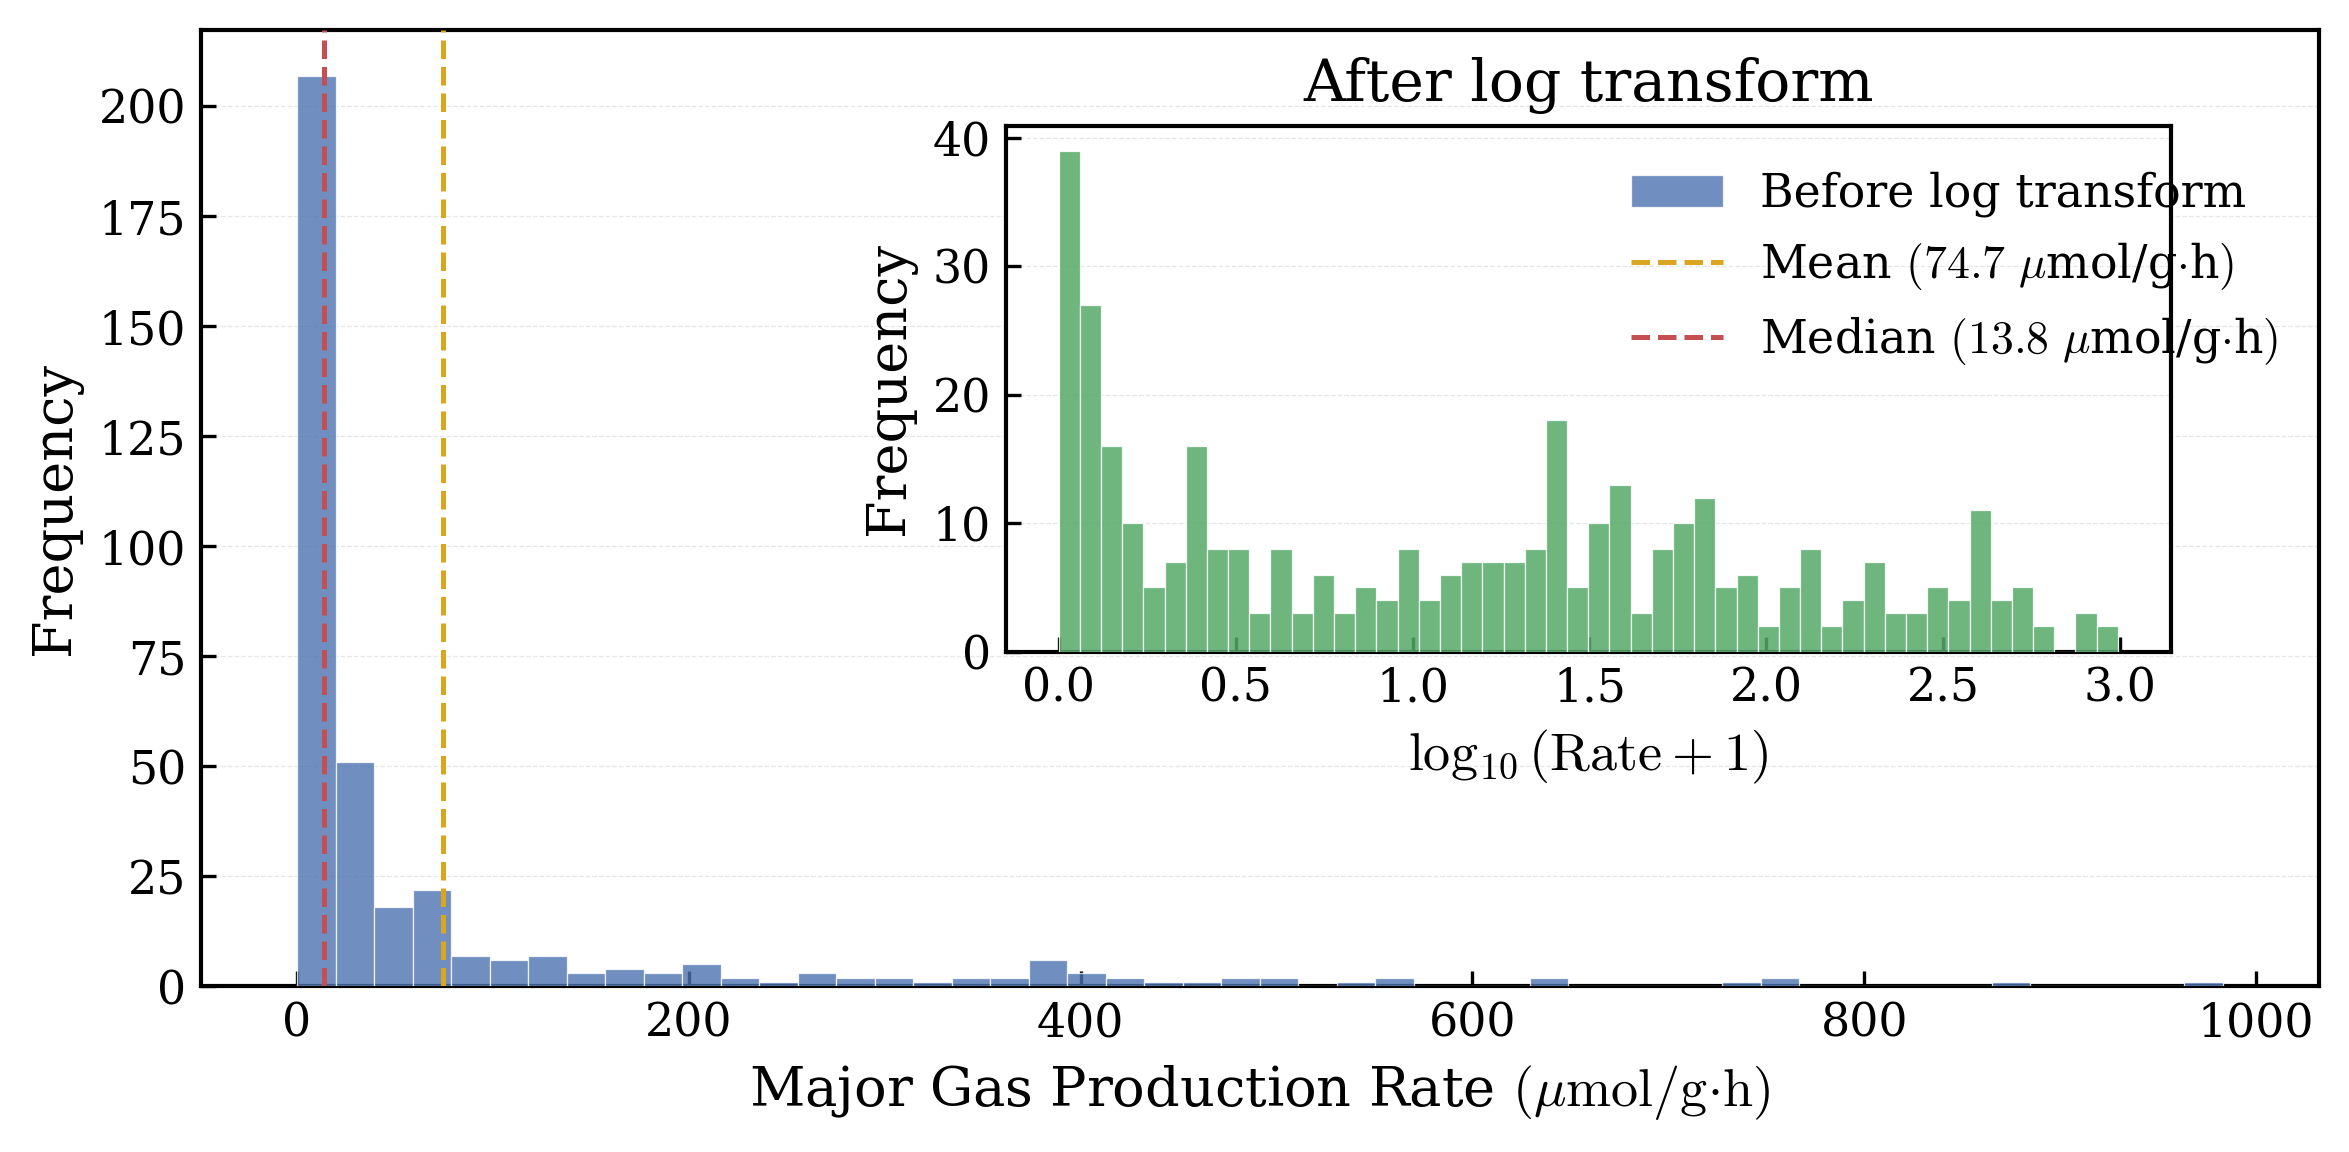

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Apply your global style first
FONT_SCALE = 1
plt.style.use('default')
plt.rcParams.update({
    "text.usetex": False, "mathtext.fontset": "cm", "font.family": "serif",
    "axes.grid": False, "axes.linewidth": 1.0,
    "font.size": int(12 * FONT_SCALE),
    "axes.labelsize": int(13 * FONT_SCALE),
    "axes.titlesize": int(14 * FONT_SCALE),
    "xtick.labelsize": int(11 * FONT_SCALE),
    "ytick.labelsize": int(11 * FONT_SCALE),
    "legend.fontsize": int(11 * FONT_SCALE),
    "xtick.direction": "in", "ytick.direction": "in",
    "legend.frameon": False, "lines.linewidth": 2.0,
    "figure.dpi": 300, "savefig.dpi": 600, "savefig.bbox": "tight",
})

major_rate_raw = pd.to_numeric(merged_df['Major_rate__umol/gh'], errors='coerce')
valid_mj       = major_rate_raw.dropna()
major_rate_log = np.log10(valid_mj + 1)

fig, ax1 = plt.subplots(figsize=(8, 4))

# Main plot — raw distribution
ax1.hist(valid_mj, bins=50, color='#4C72B0', edgecolor='white',
         linewidth=0.3, alpha=0.8, zorder=3, label='Before log transform')
ax1.axvline(valid_mj.mean(), color='#DAA520', linestyle='--', linewidth=1.2,
            label=rf'Mean $({valid_mj.mean():.1f}\ \mu$mol/g$\cdot$h$)$', zorder=4)
ax1.axvline(valid_mj.median(), color='#C44E52', linestyle='--', linewidth=1.2,
            label=rf'Median $({valid_mj.median():.1f}\ \mu$mol/g$\cdot$h$)$', zorder=4)

# All labels in math mode so CM font applies throughout
ax1.set_xlabel(r'Major Gas Production Rate $(\mu\mathrm{mol/g{\cdot}h})$')
ax1.set_ylabel(r'Frequency')
ax1.legend(loc='right', bbox_to_anchor=(1, 0.75))
ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')

# Inset — log-transformed distribution
ax_inset = ax1.inset_axes([0.38, 0.35, 0.55, 0.55])
ax_inset.hist(major_rate_log, bins=50, color='#55A868', edgecolor='white',
              linewidth=0.3, alpha=0.85, zorder=3)
ax_inset.set_xlabel(r'$\log_{10}(\mathrm{Rate} + 1)$')
ax_inset.set_ylabel(r'Frequency')
ax_inset.set_title(r'After log transform')
ax_inset.set_axisbelow(True)
ax_inset.yaxis.grid(True, linewidth=0.3, alpha=0.3, linestyle='--')

fig.tight_layout()
fig.savefig(f'{CHAR_GRAPHS}/fig2ab_combined_inset.png')
fig.savefig(f'{CHAR_GRAPHS}/fig2ab_combined_inset.pdf')
plt.show()
plt.close('all')